In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import sys
ROOT_PATH = "/content/drive/MyDrive/chiliSummerProject/src"
print(os.listdir(ROOT_PATH))
sys.path.append(ROOT_PATH)

['skel_cap_ipmg_map_logic.ipynb', '__pycache__', 'helpers', 'data_stats.ipynb', 'model_eval.ipynb', 'generate_data.ipynb', 'data_exploration.ipynb', 'define_model.py', 'model_train.ipynb']


In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import pprint as p
from define_model import *
from helpers.data_helpers import *
from helpers.metrics_helpers import *
from helpers.plot_helpers import *
from itertools import zip_longest
from tensorflow.keras.optimizers import Adam
from keras.callbacks import EarlyStopping
from keras.callbacks import ReduceLROnPlateau

In [14]:
p.pprint(tf.test.is_built_with_cuda())
print('*'*50)
p.pprint(tf.config.list_physical_devices('GPU'))
print('*'*50)
p.pprint(tf.test.gpu_device_name())

True
**************************************************
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
**************************************************
'/device:GPU:0'


In [15]:
#set random seeds
seed = 0
random.seed(seed)
np.random.seed(seed)
tf.keras.utils.set_random_seed(seed)
#data paths
drive = 1 # 1 if on google drive, 0 if not
data_dir = "/content/drive/MyDrive/chiliSummerProject/data/" if drive else "../data/"
model_path = "/content/drive/MyDrive/chiliSummerProject/models/" if drive else "../models/"
chili_models = model_path + "chili_models/"
identifier_eth = "TouchPose_crossGestures"
data_path_eth = data_dir + "eth_data/"
data_path_chili= data_dir + "processed/native_mapped/map_7ms/"

In [16]:
def plot_training(history) :
  fig, axes = plt.subplots(3, 2, figsize=(15, 8))
  for i,x in enumerate(['loss','gesture_acc','gesture_f1_score','end_point_error','auc_pck']) :
    train_metric = history.history[f'{x}']
    val_metric =  history.history[f'val_{x}']
    axes[i//2][i%2].plot(train_metric, label=f'Training {x}')
    axes[i//2][i%2].plot(val_metric, label=f'Validation {x}')
    axes[i//2][i%2].set_title(f'Training vs. Validation {x}')
    axes[i//2][i%2].set_xlabel('Epochs')
    axes[i//2][i%2].set_ylabel(x)
    axes[i//2][i%2].legend()

  plt.tight_layout()
  plt.show()

# Stratified train test validation split on gesture

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel = 'joint')
chili_data

Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965329342540703, 1.9027405870399752, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006504695151888, 1.9187705270010709, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7039149014654771, 1.9252372815573264, 0.76...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7089235671027683, 1.9150542333662095, 0.74...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066690632599103, 1.8860879012098815, 0.73...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.3153943945499922, -0.07197214812135938, 0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210017653788158, -0.050239470526614594, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.30962253455480937, -0.14323042079736256, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.3238865162425982, -0.14073655423866607, 1...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)

data=load_data(chili_data, 'tr_test_split', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha,beta),
                  metrics=[un_epe(mean,std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/tr_test_split_0.6_0.2_0.2.h5')

Epoch 1/200
2024/2024 [==============================] - 30s 7ms/step - loss: 170.5044 - end_point_error: 121.9304 - auc_pck: 0.2998 - gesture_acc: 0.3028 - gesture_f1_score: 0.1501 - val_loss: 78.5164 - val_end_point_error: 81.5339 - val_auc_pck: 4.6231 - val_gesture_acc: 0.3841 - val_gesture_f1_score: 0.1250 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 14s 7ms/step - loss: 75.5569 - end_point_error: 80.8576 - auc_pck: 3.9550 - gesture_acc: 0.3894 - gesture_f1_score: 0.2062 - val_loss: 45.8886 - val_end_point_error: 60.7728 - val_auc_pck: 18.0230 - val_gesture_acc: 0.4729 - val_gesture_f1_score: 0.2137 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 14s 7ms/step - loss: 52.9572 - end_point_error: 67.2271 - auc_pck: 10.7926 - gesture_acc: 0.4605 - gesture_f1_score: 0.2714 - val_loss: 38.3897 - val_end_point_error: 53.2177 - val_auc_pck: 30.2424 - val_gesture_acc: 0.5280 - val_gesture_f1_score: 0.2924 - lr: 1.0000e-04
Epoch 4/200
20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


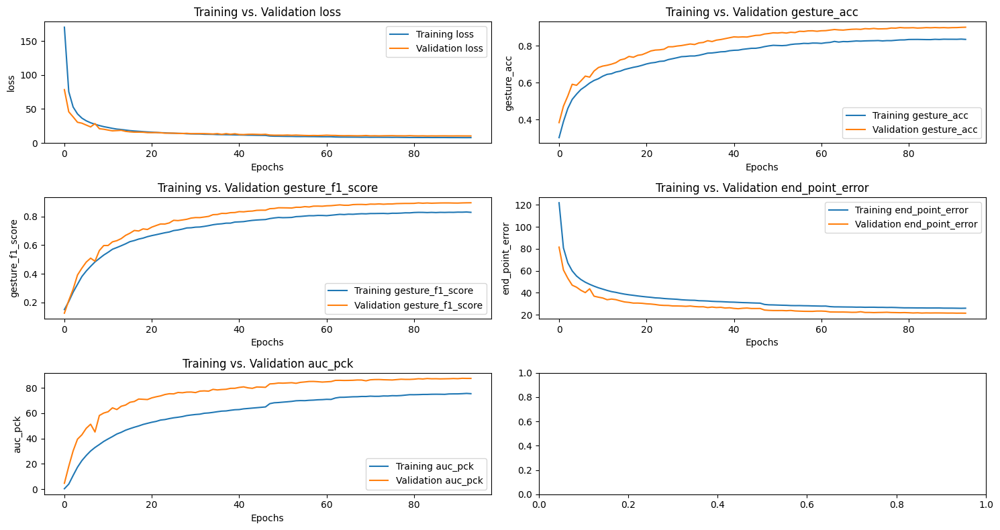

253/253 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.9004447
Gesture F1 Score:  0.8966043967478631
AucPCK :  [70.30633  81.90464  87.57411  90.538536 92.44071  93.67589  94.565216]
End point error  21.81637874697689
**************************************************
Validation Evaluation
Gesture Accuracy:  0.89624506
Gesture F1 Score:  0.8940173700840921
AucPCK :  [70.35573  81.71937  87.660576 90.81027  92.749504 94.071144 95.02223 ]
End point error  21.545729345510697
**************************************************
Worst joints : 


{'wrist_x': 5.280293625621741,
 'wrist_z': 4.052147864997479,
 'Index_3_z': 3.451079544703968,
 'Ring_3_z': 3.388422741714694,
 'Middle_3_z': 3.354013455959076,
 'Thumb_3_x': 3.263196427070223,
 'Pinky_3_x': 2.939892928491717,
 'Ring_3_x': 2.9264806531305667,
 'Thumb_3_y': 2.898330006377639,
 'Ring_2_x': 2.858609407364017,
 'Index_3_x': 2.8557675380949195,
 'Pinky_2_x': 2.8486725926877097,
 'wrist_y': 2.8425427663154936,
 'Middle_3_x': 2.8344269276948997,
 'Pinky_3_z': 2.832247307463601,
 'Thumb_3_z': 2.6793051146896487,
 'Middle_2_x': 2.675285933536024,
 'Index_2_x': 2.5932293802031405,
 'Middle_2_z': 2.3532750311757527,
 'Index_3_y': 2.336053555453461,
 'Index_2_z': 2.309418880685953,
 'Pinky_1_x': 2.27429113703861,
 'Middle_3_y': 2.242475184888637,
 'Ring_2_z': 2.237209502360792,
 'Index_1_x': 2.221410965796967,
 'Ring_3_y': 2.164928908155209,
 'Ring_1_x': 2.159267723593781,
 'Pinky_2_y': 2.145966163715831,
 'Ring_2_y': 2.1335999790385376,
 'Index_2_y': 2.130093522528505,
 'Middle_2

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

# Cross gesture model

In [8]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel = 'joint')
chili_data

Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965329342540703, 1.9027405870399752, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006504695151888, 1.9187705270010709, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7039149014654771, 1.9252372815573264, 0.76...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7089235671027683, 1.9150542333662095, 0.74...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066690632599103, 1.8860879012098815, 0.73...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.3153943945499922, -0.07197214812135938, 0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210017653788158, -0.050239470526614594, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.30962253455480937, -0.14323042079736256, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.3238865162425982, -0.14073655423866607, 1...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [9]:
for g in chili_data.gesture.unique() :
    print('Fold '+str(g))
    model = create_skeleton_gesture_3dmodel(41, 72, 1)
    data=load_data(chili_data, 'cross_gesture', None, seed, fold=g)

    optimizer = Adam(learning_rate=0.0001)
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor= 0.5, patience = 5, min_lr=1e-7)
    alpha, beta = 0.4 , 0.6
    model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                      metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

    history = model.fit(data['train']['X'], data['train']['y'] , epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

    model.save(chili_models+'3d_models/keep_wrist/crossGesture/cross'+str(g)+'.h5')
    print('*'*50)

Fold DQ
Epoch 1/200
1831/1831 [==============================] - 28s 7ms/step - loss: 160.6071 - end_point_error: 117.8837 - auc_pck: 0.3060 - gesture_acc: 0.4023 - gesture_f1_score: 0.2890 - lr: 1.0000e-04
Epoch 2/200
1831/1831 [==============================] - 13s 7ms/step - loss: 68.4113 - end_point_error: 76.9643 - auc_pck: 4.8235 - gesture_acc: 0.5215 - gesture_f1_score: 0.4106 - lr: 1.0000e-04
Epoch 3/200
1831/1831 [==============================] - 13s 7ms/step - loss: 48.3848 - end_point_error: 64.1871 - auc_pck: 12.4797 - gesture_acc: 0.5905 - gesture_f1_score: 0.4972 - lr: 1.0000e-04
Epoch 4/200
1831/1831 [==============================] - 13s 7ms/step - loss: 38.9635 - end_point_error: 57.3530 - auc_pck: 19.3513 - gesture_acc: 0.6341 - gesture_f1_score: 0.5578 - lr: 1.0000e-04
Epoch 5/200
1831/1831 [==============================] - 12s 7ms/step - loss: 33.4896 - end_point_error: 53.0762 - auc_pck: 24.6058 - gesture_acc: 0.6640 - gesture_f1_score: 0.6020 - lr: 1.0000e-04
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**************************************************
Fold DT
Epoch 1/200
1707/1707 [==============================] - 16s 7ms/step - loss: 166.3164 - end_point_error: 119.8990 - auc_pck: 0.2168 - gesture_acc: 0.4023 - gesture_f1_score: 0.2803 - lr: 1.0000e-04
Epoch 2/200
1707/1707 [==============================] - 12s 7ms/step - loss: 73.1780 - end_point_error: 79.4793 - auc_pck: 4.2229 - gesture_acc: 0.5130 - gesture_f1_score: 0.3811 - lr: 1.0000e-04
Epoch 3/200
1707/1707 [==============================] - 12s 7ms/step - loss: 50.6814 - end_point_error: 65.5942 - auc_pck: 11.9089 - gesture_acc: 0.5879 - gesture_f1_score: 0.4890 - lr: 1.0000e-04
Epoch 4/200
1707/1707 [==============================] - 12s 7ms/step - loss: 40.8462 - end_point_error: 58.5229 - auc_pck: 18.7610 - gesture_acc: 0.6346 - gesture_f1_score: 0.5659 - lr: 1.0000e-04
Epoch 5/200
1707/1707 [==============================] - 12s 7ms/step - loss: 34.8248 - end_point_error: 53.8730 - auc_pck: 24.4241 - gesture_acc: 0.

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**************************************************
Fold LQ
Epoch 1/200
2126/2126 [==============================] - 19s 7ms/step - loss: 165.5292 - end_point_error: 119.7095 - auc_pck: 0.4057 - gesture_acc: 0.3763 - gesture_f1_score: 0.2393 - lr: 1.0000e-04
Epoch 2/200
2126/2126 [==============================] - 15s 7ms/step - loss: 70.6266 - end_point_error: 78.0842 - auc_pck: 4.9582 - gesture_acc: 0.4607 - gesture_f1_score: 0.3230 - lr: 1.0000e-04
Epoch 3/200
2126/2126 [==============================] - 15s 7ms/step - loss: 50.3255 - end_point_error: 65.4378 - auc_pck: 12.2224 - gesture_acc: 0.5110 - gesture_f1_score: 0.3773 - lr: 1.0000e-04
Epoch 4/200
2126/2126 [==============================] - 15s 7ms/step - loss: 41.1941 - end_point_error: 58.9382 - auc_pck: 18.1725 - gesture_acc: 0.5528 - gesture_f1_score: 0.4306 - lr: 1.0000e-04
Epoch 5/200
2126/2126 [==============================] - 15s 7ms/step - loss: 35.5374 - end_point_error: 54.5011 - auc_pck: 23.4948 - gesture_acc: 0.

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**************************************************
Fold LT
Epoch 1/200
1928/1928 [==============================] - 18s 7ms/step - loss: 158.3328 - end_point_error: 118.8531 - auc_pck: 0.2767 - gesture_acc: 0.3891 - gesture_f1_score: 0.2689 - lr: 1.0000e-04
Epoch 2/200
1928/1928 [==============================] - 13s 7ms/step - loss: 67.8302 - end_point_error: 77.5678 - auc_pck: 4.4776 - gesture_acc: 0.5143 - gesture_f1_score: 0.4100 - lr: 1.0000e-04
Epoch 3/200
1928/1928 [==============================] - 13s 7ms/step - loss: 47.9522 - end_point_error: 64.5851 - auc_pck: 11.7778 - gesture_acc: 0.5745 - gesture_f1_score: 0.4873 - lr: 1.0000e-04
Epoch 4/200
1928/1928 [==============================] - 13s 7ms/step - loss: 38.6316 - end_point_error: 57.4119 - auc_pck: 18.9169 - gesture_acc: 0.6118 - gesture_f1_score: 0.5416 - lr: 1.0000e-04
Epoch 5/200
1928/1928 [==============================] - 13s 7ms/step - loss: 32.6815 - end_point_error: 52.5423 - auc_pck: 24.9485 - gesture_acc: 0.

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**************************************************


# Cross subject model

In [17]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel = 'joint')
chili_data

Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965329342540703, 1.9027405870399752, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006504695151888, 1.9187705270010709, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7039149014654771, 1.9252372815573264, 0.76...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7089235671027683, 1.9150542333662095, 0.74...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066690632599103, 1.8860879012098815, 0.73...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.3153943945499922, -0.07197214812135938, 0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210017653788158, -0.050239470526614594, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.30962253455480937, -0.14323042079736256, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.3238865162425982, -0.14073655423866607, 1...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
for s in chili_data.subject.unique() :
    print('Fold '+str(s))
    model = create_skeleton_gesture_3dmodel(41, 72, 1)
    data=load_data(chili_data, 'cross_subject', None, seed, fold=s)

    optimizer = Adam(learning_rate=0.0001)
    early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='loss', factor= 0.5, patience = 5, min_lr=1e-7)
    alpha, beta = 0.4 , 0.6
    model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                      metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

    history = model.fit(data['train']['X'], data['train']['y'] , epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

    model.save(chili_models+'3d_models/keep_wrist/crossSubject/cross'+str(s)+'.h5')
    print('*'*50)

Fold 1
Epoch 1/200
2530/2530 [==============================] - 23s 7ms/step - loss: 154.6166 - end_point_error: 115.2692 - auc_pck: 0.5642 - gesture_acc: 0.3116 - gesture_f1_score: 0.1515 - lr: 1.0000e-04
Epoch 2/200
2530/2530 [==============================] - 18s 7ms/step - loss: 66.0689 - end_point_error: 75.1652 - auc_pck: 6.4168 - gesture_acc: 0.4234 - gesture_f1_score: 0.2397 - lr: 1.0000e-04
Epoch 3/200
2530/2530 [==============================] - 18s 7ms/step - loss: 47.1733 - end_point_error: 62.9808 - auc_pck: 14.5828 - gesture_acc: 0.4858 - gesture_f1_score: 0.3087 - lr: 1.0000e-04
Epoch 4/200
2530/2530 [==============================] - 18s 7ms/step - loss: 38.5141 - end_point_error: 56.5461 - auc_pck: 21.2930 - gesture_acc: 0.5311 - gesture_f1_score: 0.3662 - lr: 1.0000e-04
Epoch 5/200
2530/2530 [==============================] - 18s 7ms/step - loss: 33.3673 - end_point_error: 52.4756 - auc_pck: 26.3565 - gesture_acc: 0.5636 - gesture_f1_score: 0.4223 - lr: 1.0000e-04
Epo

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


**************************************************
Fold 2
Epoch 1/200
2472/2472 [==============================] - 22s 7ms/step - loss: 153.1360 - end_point_error: 114.8417 - auc_pck: 0.5538 - gesture_acc: 0.3142 - gesture_f1_score: 0.1598 - lr: 1.0000e-04
Epoch 2/200
2472/2472 [==============================] - 17s 7ms/step - loss: 67.1661 - end_point_error: 75.8607 - auc_pck: 6.1452 - gesture_acc: 0.4071 - gesture_f1_score: 0.2111 - lr: 1.0000e-04
Epoch 3/200
2472/2472 [==============================] - 17s 7ms/step - loss: 48.1524 - end_point_error: 63.6272 - auc_pck: 14.1316 - gesture_acc: 0.4746 - gesture_f1_score: 0.2764 - lr: 1.0000e-04
Epoch 4/200
2472/2472 [==============================] - 17s 7ms/step - loss: 39.4106 - end_point_error: 57.2427 - auc_pck: 20.5492 - gesture_acc: 0.5167 - gesture_f1_score: 0.3447 - lr: 1.0000e-04
Epoch 5/200
2472/2472 [==============================] - 17s 7ms/step - loss: 33.9397 - end_point_error: 52.9311 - auc_pck: 25.9268 - gesture_acc: 0.5

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/200
2523/2523 [==============================] - 22s 7ms/step - loss: 156.4854 - end_point_error: 116.1045 - auc_pck: 0.5245 - gesture_acc: 0.3250 - gesture_f1_score: 0.1632 - lr: 1.0000e-04
Epoch 2/200
2523/2523 [==============================] - 18s 7ms/step - loss: 66.1582 - end_point_error: 75.3730 - auc_pck: 6.1941 - gesture_acc: 0.4305 - gesture_f1_score: 0.2405 - lr: 1.0000e-04
Epoch 3/200
2523/2523 [==============================] - 18s 7ms/step - loss: 47.2025 - end_point_error: 63.1263 - auc_pck: 14.2772 - gesture_acc: 0.4963 - gesture_f1_score: 0.3191 - lr: 1.0000e-04
Epoch 4/200
2523/2523 [==============================] - 18s 7ms/step - loss: 38.7034 - end_point_error: 56.7373 - auc_pck: 21.0475 - gesture_acc: 0.5276 - gesture_f1_score: 0.3720 - lr: 1.0000e-04
Epoch 5/200
2523/2523 [==============================] - 18s 7ms/step - loss: 33.4050 - end_point_error: 52.5234 - auc_pck: 26.3293 - gesture_acc: 0.5586 - gesture_f1_score: 0.4248 - lr: 1.0000e-04
Epoch 6/20

...

Epoch 1/200
2233/2233 [==============================] - 20s 7ms/step - loss: 151.6575 - end_point_error: 113.8750 - auc_pck: 0.5462 - gesture_acc: 0.3365 - gesture_f1_score: 0.1980 - lr: 1.0000e-04
Epoch 2/200
2233/2233 [==============================] - 16s 7ms/step - loss: 67.1397 - end_point_error: 75.6652 - auc_pck: 6.2245 - gesture_acc: 0.4473 - gesture_f1_score: 0.2865 - lr: 1.0000e-04
Epoch 3/200
2233/2233 [==============================] - 16s 7ms/step - loss: 47.3232 - end_point_error: 63.1056 - auc_pck: 14.5385 - gesture_acc: 0.5090 - gesture_f1_score: 0.3551 - lr: 1.0000e-04
Epoch 4/200
2233/2233 [==============================] - 16s 7ms/step - loss: 38.1858 - end_point_error: 56.3891 - auc_pck: 21.4852 - gesture_acc: 0.5539 - gesture_f1_score: 0.4140 - lr: 1.0000e-04
Epoch 5/200
2233/2233 [==============================] - 16s 7ms/step - loss: 32.8412 - end_point_error: 52.1338 - auc_pck: 26.8733 - gesture_acc: 0.5796 - gesture_f1_score: 0.4573 - lr: 1.0000e-04
Epoch 6/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/200
2285/2285 [==============================] - 21s 7ms/step - loss: 155.5755 - end_point_error: 115.5041 - auc_pck: 0.4562 - gesture_acc: 0.3122 - gesture_f1_score: 0.1559 - lr: 1.0000e-04
Epoch 2/200
2285/2285 [==============================] - 16s 7ms/step - loss: 66.6349 - end_point_error: 75.6624 - auc_pck: 5.6549 - gesture_acc: 0.4205 - gesture_f1_score: 0.2297 - lr: 1.0000e-04
Epoch 3/200
2285/2285 [==============================] - 16s 7ms/step - loss: 47.1169 - end_point_error: 63.1886 - auc_pck: 13.7537 - gesture_acc: 0.4972 - gesture_f1_score: 0.3278 - lr: 1.0000e-04
Epoch 4/200
2285/2285 [==============================] - 16s 7ms/step - loss: 38.2043 - end_point_error: 56.4004 - auc_pck: 21.0988 - gesture_acc: 0.5542 - gesture_f1_score: 0.4143 - lr: 1.0000e-04
Epoch 5/200
2285/2285 [==============================] - 16s 7ms/step - loss: 32.8298 - end_point_error: 52.1070 - auc_pck: 26.6833 - gesture_acc: 0.5808 - gesture_f1_score: 0.4741 - lr: 1.0000e-04
Epoch 6/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Epoch 1/200
2529/2529 [==============================] - 22s 7ms/step - loss: 156.7280 - end_point_error: 116.2062 - auc_pck: 0.5911 - gesture_acc: 0.3184 - gesture_f1_score: 0.1634 - lr: 1.0000e-04
Epoch 2/200
2529/2529 [==============================] - 18s 7ms/step - loss: 67.7222 - end_point_error: 76.1113 - auc_pck: 6.2564 - gesture_acc: 0.4094 - gesture_f1_score: 0.2084 - lr: 1.0000e-04
Epoch 3/200
2529/2529 [==============================] - 18s 7ms/step - loss: 48.5657 - end_point_error: 63.8608 - auc_pck: 14.2061 - gesture_acc: 0.4750 - gesture_f1_score: 0.2862 - lr: 1.0000e-04
Epoch 4/200
2529/2529 [==============================] - 18s 7ms/step - loss: 39.7946 - end_point_error: 57.4810 - auc_pck: 20.4788 - gesture_acc: 0.5233 - gesture_f1_score: 0.3616 - lr: 1.0000e-04
Epoch 5/200
2529/2529 [==============================] - 18s 7ms/step - loss: 34.5730 - end_point_error: 53.3667 - auc_pck: 25.4162 - gesture_acc: 0.5477 - gesture_f1_score: 0.4096 - lr: 1.0000e-04
Epoch 6/20

In [ ]:
for s in [2,10,11,12,22,24,25] :
    model = load_model(chili_models+'/crossSubject/crossmulti_beta0.2_'+str(s)+'.h5',compile=False)
    print('test set on subject '+str(s))
    test = shuffle(chili_data[chili_data.subject==s].copy(),random_state=42)
    test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
    X_test, y_test_skeleton, y_test_gesture = data_multiload(test)
    y_out_gesture, y_out_skeleton = model.predict(X_test, batch_size=32)
    skeleton_error = np.mean(abs(y_test_skeleton - y_out_skeleton))
    auc = auc_pck(y_test_skeleton,y_out_skeleton).numpy()
    epe = end_point_error(y_test_skeleton,y_out_skeleton).numpy()
    y_out_gesture_labels = np.argmax(y_out_gesture, axis=1)
    y_test_gesture_labels = np.argmax(y_test_gesture, axis=1)
    gesture_accuracy = np.mean(y_out_gesture_labels == y_test_gesture_labels)
    gesture_f1_score = f1_score(y_test_gesture_labels, y_out_gesture_labels, average='weighted')
    print("Gesture Accuracy: ", gesture_accuracy)
    print("Gesture F1 Score: ", gesture_f1_score)
    print("Mean Error: ",skeleton_error)
    print("AucPCK : ", auc)
    print("End point error ", epe)
    print('*'*50)

# Time model (60/20/20 and 80/10/10 each trial)

## 2d Models (always remove x axis and use joint normalization)

### Keeping wrist

base 2d

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[1.9029354711708684, 0.7795498971441778], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[1.9189654108251444, 0.7710513558682875], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[1.9254321652576158, 0.7604587532195456], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[1.9152491172614103, 0.7475449684553396], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[1.88628278565952, 0.7331453508544011], [-0.9...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.07177722619295937, 0.9775049234994947], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.050044549014194604, 0.9704471159504442], ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.14303549750502492, 0.9721109074370231], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.14054163099406292, 1.3141819677964832], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/base.h5')

Epoch 1/200
1518/1518 [==============================] - 19s 10ms/step - loss: 66.8121 - end_point_error: 76.6968 - auc_pck: 5.2510 - gesture_acc: 0.2888 - gesture_f1_score: 0.1445 - val_loss: 69.3429 - val_end_point_error: 74.6873 - val_auc_pck: 10.7046 - val_gesture_acc: 0.3409 - val_gesture_f1_score: 0.0124 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 13s 9ms/step - loss: 30.7658 - end_point_error: 51.7047 - auc_pck: 23.9433 - gesture_acc: 0.3765 - gesture_f1_score: 0.1829 - val_loss: 69.0840 - val_end_point_error: 73.2058 - val_auc_pck: 15.1319 - val_gesture_acc: 0.3759 - val_gesture_f1_score: 0.0732 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 13s 8ms/step - loss: 21.8064 - end_point_error: 43.0773 - auc_pck: 38.6895 - gesture_acc: 0.4565 - gesture_f1_score: 0.2369 - val_loss: 66.4092 - val_end_point_error: 71.2032 - val_auc_pck: 17.5666 - val_gesture_acc: 0.4252 - val_gesture_f1_score: 0.1536 - lr: 1.0000e-04
Epoch 4/200
1

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


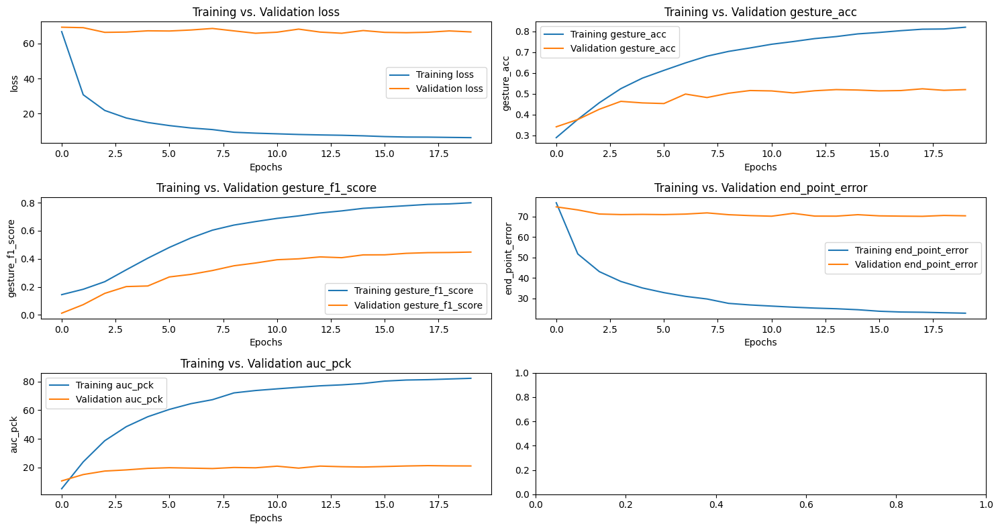

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.37976405
Gesture F1 Score:  0.21190450347499598
AucPCK :  [ 0.9574402  2.6808326  5.5840383  9.735005  14.546914  18.72259
 23.151524 ]
End point error  100.48934683745351
**************************************************
Validation Evaluation
Gesture Accuracy:  0.5162406
Gesture F1 Score:  0.37468529247342613
AucPCK :  [ 3.5753984  6.9902434 11.72039   18.191923  25.737926  32.83932
 39.669014 ]
End point error  70.4790834190251
**************************************************
Worst joints : 


{'wrist_y': 31.651173129069274,
 'Index_3_y': 21.83656239726345,
 'Ring_3_y': 21.515788210251728,
 'Middle_3_y': 20.783629565972902,
 'Pinky_3_y': 16.5262624233325,
 'Ring_2_y': 16.071817000399758,
 'Ring_3_z': 16.00998903140596,
 'Pinky_3_z': 15.862110947753981,
 'Middle_2_y': 15.476117310899077,
 'Index_2_y': 14.949001441714929,
 'Thumb_3_y': 14.702469383135297,
 'Middle_3_z': 14.498585877236275,
 'Pinky_2_z': 14.484349955725285,
 'Index_3_z': 14.130867661906981,
 'Ring_2_z': 14.121148242021315,
 'Index_2_z': 13.97622719076174,
 'Index_1_z': 13.892619389927095,
 'Pinky_2_y': 13.29548170081009,
 'Middle_2_z': 12.07216174462234,
 'Middle_1_z': 11.523145422962626,
 'Thumb_3_z': 11.337778684239225,
 'wrist_z': 10.776493808128436,
 'Thumb_2_y': 10.469788610070543,
 'Pinky_1_y': 9.726413157249432,
 'Pinky_1_z': 9.511103057615538,
 'Ring_1_z': 9.475395745974295,
 'Thumb_2_z': 8.954470659148871,
 'Ring_1_y': 8.639159566330521,
 'Index_0_z': 8.336670807870991,
 'Middle_1_y': 7.424653694448021

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80

In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/base_80.h5')

Epoch 1/200
2024/2024 [==============================] - 22s 8ms/step - loss: 64.0723 - end_point_error: 74.3965 - auc_pck: 7.2409 - gesture_acc: 0.3369 - gesture_f1_score: 0.1684 - val_loss: 113.2736 - val_end_point_error: 90.2634 - val_auc_pck: 11.2890 - val_gesture_acc: 0.3823 - val_gesture_f1_score: 0.0604 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 16s 8ms/step - loss: 28.7878 - end_point_error: 49.6276 - auc_pck: 27.8935 - gesture_acc: 0.4164 - gesture_f1_score: 0.2108 - val_loss: 113.8013 - val_end_point_error: 87.4857 - val_auc_pck: 15.6496 - val_gesture_acc: 0.3930 - val_gesture_f1_score: 0.0826 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 16s 8ms/step - loss: 20.5635 - end_point_error: 41.5367 - auc_pck: 42.0711 - gesture_acc: 0.4827 - gesture_f1_score: 0.2769 - val_loss: 116.4612 - val_end_point_error: 87.5331 - val_auc_pck: 18.7623 - val_gesture_acc: 0.3983 - val_gesture_f1_score: 0.1482 - lr: 1.0000e-04
Epoch 4/200

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


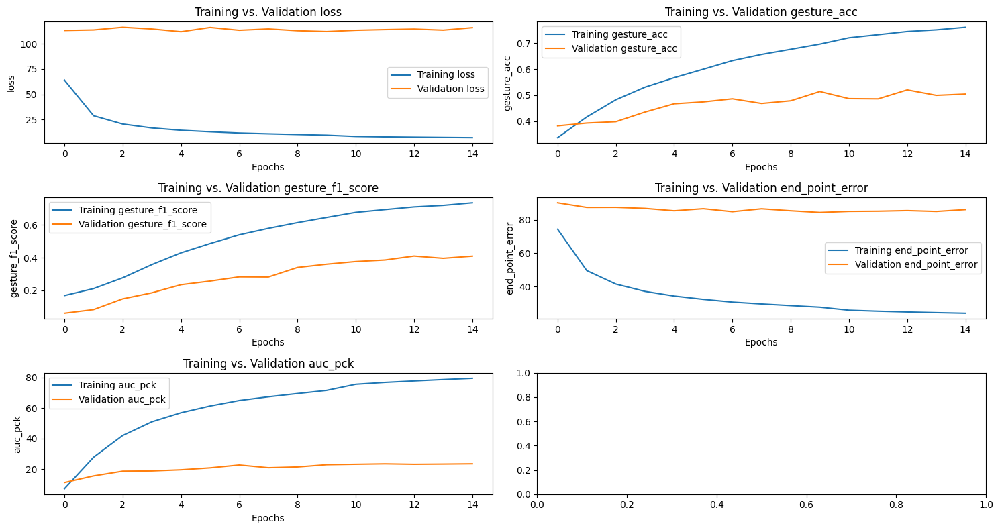

254/254 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.39836997
Gesture F1 Score:  0.15850472484593006
AucPCK :  [ 0.41985676  2.0745862   4.6184244   8.026673   12.3734255  17.86861
 24.042973  ]
End point error  100.08218496103217
**************************************************
Validation Evaluation
Gesture Accuracy:  0.46888122
Gesture F1 Score:  0.2388360987492464
AucPCK :  [ 3.4699924  7.940232  13.336626  19.449247  24.932081  31.760927
 37.25611  ]
End point error  85.1604876663917
**************************************************
Worst joints : 


{'wrist_y': 32.17184300304929,
 'Index_3_y': 20.959255029263566,
 'Middle_3_y': 20.69210276591434,
 'Ring_3_y': 20.117631035671856,
 'Pinky_3_z': 16.219009549479978,
 'Ring_3_z': 15.9779362296564,
 'Pinky_3_y': 15.583120247531324,
 'Ring_2_y': 15.050305574629878,
 'Pinky_2_z': 15.046648650053886,
 'Thumb_3_y': 14.820107413238615,
 'Middle_2_y': 14.74770540850467,
 'Index_2_y': 14.505044204544845,
 'Middle_3_z': 14.405947273970199,
 'Ring_2_z': 14.343150170755093,
 'Index_3_z': 14.31142521960995,
 'Index_2_z': 14.174858976698008,
 'Index_1_z': 13.924131280305572,
 'Middle_2_z': 12.583239966922198,
 'Pinky_2_y': 12.475469068365125,
 'Middle_1_z': 11.795370011002454,
 'Thumb_3_z': 11.743310026801725,
 'wrist_z': 11.526837338029644,
 'Thumb_2_y': 10.64200110574184,
 'Pinky_1_z': 9.84117804721025,
 'Ring_1_z': 9.755002245205777,
 'Thumb_2_z': 9.175653070986842,
 'Pinky_1_y': 9.069713002540729,
 'Index_0_z': 8.348978436667808,
 'Ring_1_y': 8.096356729530008,
 'Middle_1_y': 7.17869445368672,


In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

reg 2d

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/base_reg.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 12ms/step - loss: 66.3363 - end_point_error: 74.1008 - auc_pck: 9.5204 - gesture_acc: 0.3024 - gesture_f1_score: 0.0325 - val_loss: 75.3139 - val_end_point_error: 78.1980 - val_auc_pck: 8.6767 - val_gesture_acc: 0.3431 - val_gesture_f1_score: 0.0250 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 16s 10ms/step - loss: 52.9277 - end_point_error: 65.8469 - auc_pck: 14.0856 - gesture_acc: 0.3457 - gesture_f1_score: 0.0807 - val_loss: 71.5912 - val_end_point_error: 74.4823 - val_auc_pck: 13.2027 - val_gesture_acc: 0.3112 - val_gesture_f1_score: 0.1105 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 16s 10ms/step - loss: 41.4312 - end_point_error: 57.9208 - auc_pck: 20.4608 - gesture_acc: 0.3561 - gesture_f1_score: 0.1163 - val_loss: 70.8608 - val_end_point_error: 72.5444 - val_auc_pck: 18.0526 - val_gesture_acc: 0.3346 - val_gesture_f1_score: 0.1188 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


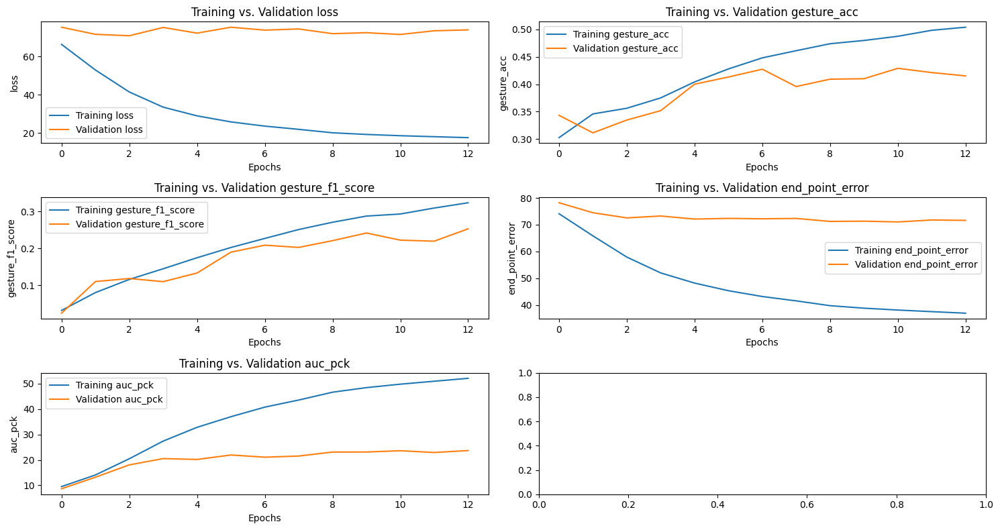

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.33442461
Gesture F1 Score:  0.2064495481153364
AucPCK :  [ 0.11736364  1.266292    3.5826795   6.757675   12.471432   18.26549
 23.732164  ]
End point error  99.95365119970633
**************************************************
Validation Evaluation
Gesture Accuracy:  0.33333334
Gesture F1 Score:  0.12170995764812725
AucPCK :  [ 1.2597258  3.5506978  7.8362355 15.227861  23.97184   33.129555
 41.5339   ]
End point error  72.58560603880863
**************************************************
Worst joints : 


{'wrist_y': 33.31033286940681,
 'Ring_3_y': 21.081197997795165,
 'Index_3_y': 20.493524251329188,
 'Middle_3_y': 20.27406317300311,
 'Pinky_3_y': 17.004873066096277,
 'Ring_2_y': 16.235552909552432,
 'Pinky_3_z': 16.220417994210372,
 'Ring_3_z': 16.145453715893222,
 'Middle_2_y': 15.211087516397518,
 'Pinky_2_z': 15.118462276174547,
 'Index_1_z': 14.768996353228545,
 'Middle_3_z': 14.525740391522287,
 'Ring_2_z': 14.358746138893833,
 'Thumb_3_y': 13.897651401441424,
 'Index_2_y': 13.740461483872007,
 'Pinky_2_y': 13.581917238020573,
 'Index_2_z': 13.39263863486785,
 'Index_3_z': 13.120878030441952,
 'Middle_1_z': 12.167478034743848,
 'Middle_2_z': 11.841805883164746,
 'Thumb_3_z': 11.063593652763856,
 'wrist_z': 10.553944551707906,
 'Pinky_1_y': 10.186978002123897,
 'Pinky_1_z': 10.136250253324492,
 'Ring_1_z': 10.010905609052124,
 'Thumb_2_y': 9.884570306821214,
 'Ring_1_y': 8.943400032210858,
 'Index_0_z': 8.84345297925573,
 'Thumb_2_z': 8.70059425745077,
 'Middle_1_y': 7.54988363591

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80 reg2d

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/base_80_reg.h5')

Epoch 1/200
2024/2024 [==============================] - 27s 10ms/step - loss: 66.9994 - end_point_error: 74.6289 - auc_pck: 8.6580 - gesture_acc: 0.2990 - gesture_f1_score: 0.0252 - val_loss: 122.9099 - val_end_point_error: 94.7612 - val_auc_pck: 8.6948 - val_gesture_acc: 0.3300 - val_gesture_f1_score: 0.0240 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 19s 10ms/step - loss: 51.2643 - end_point_error: 64.5235 - auc_pck: 15.1452 - gesture_acc: 0.3461 - gesture_f1_score: 0.1249 - val_loss: 117.5977 - val_end_point_error: 88.7707 - val_auc_pck: 14.4439 - val_gesture_acc: 0.3559 - val_gesture_f1_score: 0.1629 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 19s 10ms/step - loss: 38.7223 - end_point_error: 55.9837 - auc_pck: 22.9872 - gesture_acc: 0.3652 - gesture_f1_score: 0.1515 - val_loss: 116.9936 - val_end_point_error: 87.3992 - val_auc_pck: 17.0522 - val_gesture_acc: 0.3788 - val_gesture_f1_score: 0.1322 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


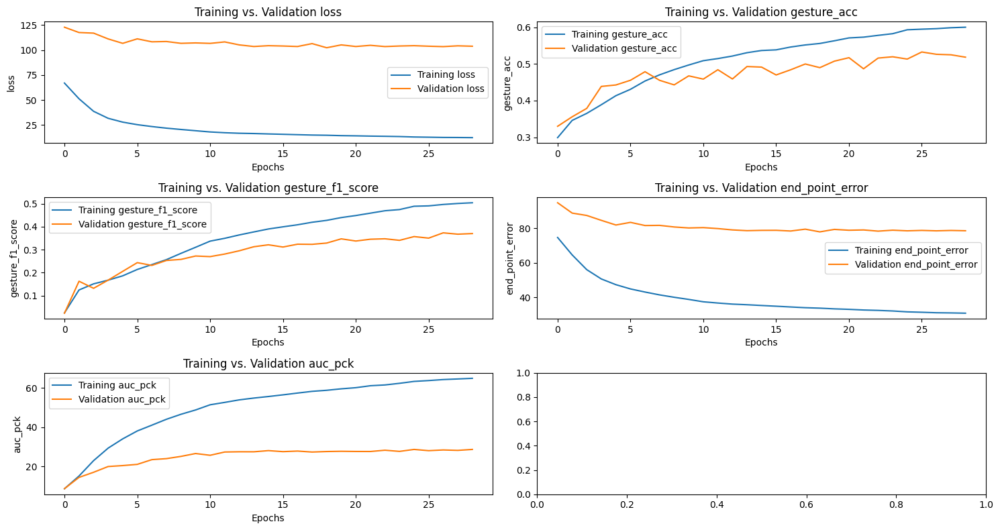

254/254 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.48085946
Gesture F1 Score:  0.25814320956593656
AucPCK :  [ 1.1978266  3.5193875  7.619165  13.311929  18.214373  22.72166
 26.697952 ]
End point error  98.22351345607134
**************************************************
Validation Evaluation
Gesture Accuracy:  0.49172634
Gesture F1 Score:  0.3337865623517935
AucPCK :  [ 8.508274 14.386268 20.86935  27.66115  34.26772  40.824898 47.592   ]
End point error  77.51110843377138
**************************************************
Worst joints : 


{'wrist_y': 30.412321701913303,
 'Index_3_y': 20.444019633000448,
 'Ring_3_y': 19.935779165215518,
 'Middle_3_y': 19.7772009405875,
 'Index_3_z': 15.273514462344568,
 'Ring_3_z': 15.2628066342851,
 'Pinky_3_y': 15.232657898465865,
 'Pinky_3_z': 15.193334905482603,
 'Thumb_3_y': 14.886240081085365,
 'Ring_2_y': 14.67211565828124,
 'Index_2_z': 14.655987712448969,
 'Middle_2_y': 14.235950256312899,
 'Middle_3_z': 14.21527541997254,
 'Pinky_2_z': 14.196980596632509,
 'Index_2_y': 13.758962137391569,
 'Ring_2_z': 13.735768244196196,
 'Index_1_z': 13.40254674751568,
 'Middle_2_z': 12.465154963068734,
 'Pinky_2_y': 12.30116676374731,
 'Thumb_3_z': 11.887083674290356,
 'Middle_1_z': 11.383497461281015,
 'wrist_z': 11.17899447494798,
 'Thumb_2_y': 10.755137727086465,
 'Ring_1_z': 9.88699481241694,
 'Pinky_1_z': 9.7788294689377,
 'Thumb_2_z': 9.417515338216424,
 'Pinky_1_y': 8.737159733149705,
 'Index_0_z': 7.935978551722489,
 'Ring_1_y': 7.774815537709488,
 'Middle_1_y': 6.876860938606624,
 'I

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

try some filterings of capactive images

In [ ]:
# try with cap_img in mean +- 2 std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=2))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  78910
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[1.884585986112203, 0.7727926404062342], [-0....","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
1,1.679995e+12,"[[1.9004753160631227, 0.7642491692882407], [-0...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
2,1.679995e+12,"[[1.906885346113467, 0.7536005659743233], [-0....","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
3,1.679995e+12,"[[1.8967916206842135, 0.7406185089864998], [-0...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
4,1.679995e+12,"[[1.8680793728394487, 0.7261427639038969], [-1...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
78905,1.680527e+12,"[[-0.07280513845856727, 0.9717942096668504], [...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78906,1.680527e+12,"[[-0.05126309364381299, 0.9646990891050746], [...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78907,1.680527e+12,"[[-0.14343835411808795, 0.9663716766763412], [...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78908,1.680527e+12,"[[-0.14096636303759413, 1.3102511884195256], [...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_2_std.h5')

Epoch 1/200
1480/1480 [==============================] - 19s 9ms/step - loss: 66.7312 - end_point_error: 76.7886 - auc_pck: 5.1368 - gesture_acc: 0.2934 - gesture_f1_score: 0.1578 - val_loss: 74.5517 - val_end_point_error: 76.1431 - val_auc_pck: 11.4810 - val_gesture_acc: 0.3022 - val_gesture_f1_score: 0.0250 - lr: 1.0000e-04
Epoch 2/200
1480/1480 [==============================] - 13s 9ms/step - loss: 31.1635 - end_point_error: 52.0538 - auc_pck: 23.5543 - gesture_acc: 0.3836 - gesture_f1_score: 0.1939 - val_loss: 73.0138 - val_end_point_error: 74.4572 - val_auc_pck: 14.5706 - val_gesture_acc: 0.3705 - val_gesture_f1_score: 0.0684 - lr: 1.0000e-04
Epoch 3/200
1480/1480 [==============================] - 13s 9ms/step - loss: 22.0947 - end_point_error: 43.4283 - auc_pck: 37.8530 - gesture_acc: 0.4624 - gesture_f1_score: 0.2498 - val_loss: 72.4261 - val_end_point_error: 73.7168 - val_auc_pck: 16.2940 - val_gesture_acc: 0.4308 - val_gesture_f1_score: 0.1353 - lr: 1.0000e-04
Epoch 4/200
14

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


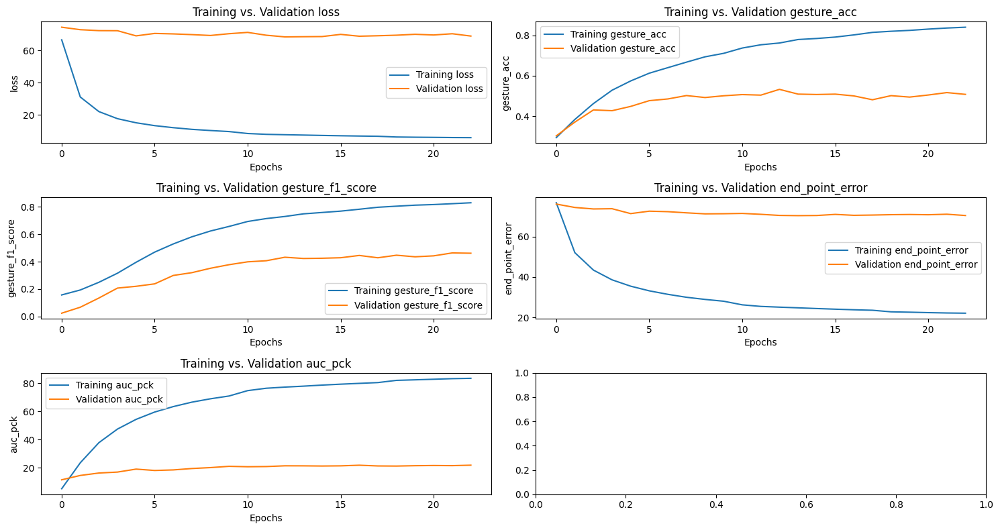

494/494 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.3569301
Gesture F1 Score:  0.2730978406647504
AucPCK :  [ 0.9759807  3.1370811  6.375562   9.930921  14.234109  19.285126
 24.323467 ]
End point error  100.31531652224132
**************************************************
Validation Evaluation
Gesture Accuracy:  0.5325984
Gesture F1 Score:  0.43539062597055705
AucPCK :  [ 5.0940886  8.787937  14.230501  20.091238  26.731295  33.903564
 40.930115 ]
End point error  70.49531660244557
**************************************************
Worst joints : 


{'wrist_y': 32.01433997461628,
 'Index_3_y': 21.628756601270833,
 'Ring_3_y': 21.17144151947024,
 'Middle_3_y': 20.131601326622796,
 'Pinky_3_y': 16.57307155308273,
 'Ring_3_z': 15.918875959650158,
 'Ring_2_y': 15.909312299621373,
 'Pinky_3_z': 15.854912905827737,
 'Middle_2_y': 15.175893664632495,
 'Index_2_y': 14.615176863119412,
 'Middle_3_z': 14.493043402763647,
 'Pinky_2_z': 14.488658569125661,
 'Thumb_3_y': 14.374124076109057,
 'Ring_2_z': 14.179247972224154,
 'Index_1_z': 14.068431943830555,
 'Index_3_z': 13.916104459831624,
 'Index_2_z': 13.889152509132225,
 'Pinky_2_y': 13.15104790881466,
 'Middle_2_z': 12.038316745362321,
 'Middle_1_z': 11.742572560143598,
 'Thumb_3_z': 11.092967339441618,
 'wrist_z': 10.65883190757793,
 'Thumb_2_y': 10.171029744874255,
 'Pinky_1_y': 9.593277465697891,
 'Pinky_1_z': 9.56776811056655,
 'Ring_1_z': 9.562574525562392,
 'Thumb_2_z': 8.990429367664474,
 'Ring_1_y': 8.456631589405825,
 'Index_0_z': 8.40115326493478,
 'Middle_1_y': 7.389682165247874

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img = mean +- std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=1))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  57303
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[-2.6938882, -1.1785294], [-1.026487, 1.78830...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
1,1.680001e+12,"[[-2.3661559, -1.1730675], [-1.0423855, 1.7852...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
2,1.680001e+12,"[[-1.8592466, -1.1731712], [-1.0774983, 1.7853...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
3,1.680001e+12,"[[-0.99239254, -1.1397897], [-1.074615, 1.8182...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
4,1.680001e+12,"[[-0.76474214, -1.1257862], [-1.041257, 1.8219...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
57298,1.680527e+12,"[[0.04855211, -1.0296844], [-0.7489003, 0.3619...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57299,1.680527e+12,"[[0.07090858, -1.0294086], [-0.7462087, 0.3815...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57300,1.680527e+12,"[[0.04593951, -1.0236228], [-0.731834, 0.38951...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57301,1.680527e+12,"[[0.010563506, -1.0188345], [-0.7119733, 0.395...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)

data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_std.h5')

Epoch 1/200
1074/1074 [==============================] - 15s 10ms/step - loss: 73.5308 - end_point_error: 81.1074 - auc_pck: 3.4188 - gesture_acc: 0.2919 - gesture_f1_score: 0.1695 - val_loss: 69.4929 - val_end_point_error: 74.8743 - val_auc_pck: 10.8225 - val_gesture_acc: 0.2877 - val_gesture_f1_score: 0.1544 - lr: 1.0000e-04
Epoch 2/200
1074/1074 [==============================] - 9s 9ms/step - loss: 34.0847 - end_point_error: 55.0612 - auc_pck: 18.5519 - gesture_acc: 0.3700 - gesture_f1_score: 0.2169 - val_loss: 64.2872 - val_end_point_error: 71.1411 - val_auc_pck: 14.9232 - val_gesture_acc: 0.3332 - val_gesture_f1_score: 0.1323 - lr: 1.0000e-04
Epoch 3/200
1074/1074 [==============================] - 9s 9ms/step - loss: 23.3577 - end_point_error: 45.3664 - auc_pck: 32.9299 - gesture_acc: 0.4197 - gesture_f1_score: 0.2534 - val_loss: 63.2209 - val_end_point_error: 70.6756 - val_auc_pck: 15.4661 - val_gesture_acc: 0.3860 - val_gesture_f1_score: 0.1642 - lr: 1.0000e-04
Epoch 4/200
107

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


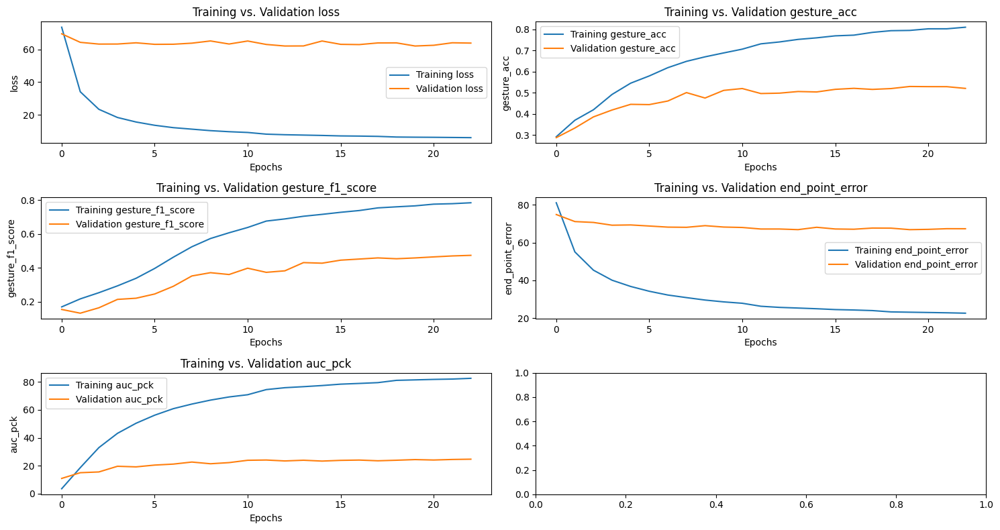

359/359 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.3975399
Gesture F1 Score:  0.27667826
AucPCK :  [ 1.2125971  3.053302   6.516619  10.826137  15.493326  20.718834
 25.316235 ]
End point error  101.31114
**************************************************
Validation Evaluation
Gesture Accuracy:  0.49803683
Gesture F1 Score:  0.38546023
AucPCK :  [ 5.94189  11.630748 17.092749 22.607103 28.688595 35.35468  42.08184 ]
End point error  67.18524
**************************************************
Worst joints : 


{'wrist_y': 30.444582,
 'Ring_3_y': 22.05539,
 'Index_3_y': 21.526173,
 'Middle_3_y': 20.157982,
 'Pinky_3_y': 17.012426,
 'Ring_2_y': 16.460281,
 'Ring_3_z': 16.376005,
 'Pinky_3_z': 15.980691,
 'Middle_3_z': 15.374861,
 'Middle_2_y': 15.368697,
 'Index_2_z': 14.893936,
 'Index_3_z': 14.7835045,
 'Index_1_z': 14.69609,
 'Index_2_y': 14.598463,
 'Pinky_2_z': 14.565987,
 'Ring_2_z': 14.457979,
 'Thumb_3_y': 13.8274,
 'Pinky_2_y': 13.678695,
 'Middle_2_z': 12.51933,
 'Middle_1_z': 12.253816,
 'Thumb_3_z': 11.628233,
 'wrist_z': 10.635714,
 'Pinky_1_y': 9.994761,
 'Ring_1_z': 9.89382,
 'Thumb_2_y': 9.637012,
 'Pinky_1_z': 9.61648,
 'Thumb_2_z': 9.374699,
 'Ring_1_y': 8.912088,
 'Index_0_z': 8.443003,
 'Middle_1_y': 7.6674314,
 'Index_1_y': 7.1008973,
 'Middle_0_z': 7.0175853,
 'Thumb_0_z': 6.7654834,
 'Thumb_1_z': 6.751151,
 'Thumb_0_y': 5.3769517,
 'Thumb_1_y': 5.3302226,
 'Ring_0_z': 5.3247848,
 'Pinky_0_y': 3.6238308,
 'Pinky_0_z': 3.5364232,
 'Index_0_y': 2.9381254,
 'Ring_0_y': 2.644

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 2 std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=2,lower=True))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[1.9029354711708684, 0.7795498971441778], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[1.9189654108251444, 0.7710513558682875], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[1.9254321652576158, 0.7604587532195456], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[1.9152491172614103, 0.7475449684553396], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[1.88628278565952, 0.7331453508544011], [-0.9...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.07177722619295937, 0.9775049234994947], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.050044549014194604, 0.9704471159504442], ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.14303549750502492, 0.9721109074370231], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.14054163099406292, 1.3141819677964832], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower_2std.h5')

Epoch 1/200
1518/1518 [==============================] - 18s 9ms/step - loss: 66.1033 - end_point_error: 76.4649 - auc_pck: 5.2543 - gesture_acc: 0.3245 - gesture_f1_score: 0.1864 - val_loss: 69.4421 - val_end_point_error: 74.2383 - val_auc_pck: 12.3935 - val_gesture_acc: 0.3227 - val_gesture_f1_score: 0.1044 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 13s 9ms/step - loss: 30.3928 - end_point_error: 51.5455 - auc_pck: 23.8145 - gesture_acc: 0.4238 - gesture_f1_score: 0.2475 - val_loss: 69.0155 - val_end_point_error: 74.3053 - val_auc_pck: 12.2834 - val_gesture_acc: 0.3902 - val_gesture_f1_score: 0.1353 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 13s 9ms/step - loss: 21.4041 - end_point_error: 42.7647 - auc_pck: 39.0245 - gesture_acc: 0.5027 - gesture_f1_score: 0.3048 - val_loss: 67.3484 - val_end_point_error: 71.9840 - val_auc_pck: 17.2672 - val_gesture_acc: 0.4292 - val_gesture_f1_score: 0.1887 - lr: 1.0000e-04
Epoch 4/200
15

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=1,lower=True))
chili_data

In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower_std.h5')

Epoch 1/200
1286/1286 [==============================] - 15s 8ms/step - loss: 68.8543 - end_point_error: 78.0975 - auc_pck: 4.4136 - gesture_acc: 0.3170 - gesture_f1_score: 0.1837 - val_loss: 65.3343 - val_end_point_error: 73.6962 - val_auc_pck: 9.6116 - val_gesture_acc: 0.3408 - val_gesture_f1_score: 0.1489 - lr: 1.0000e-04
Epoch 2/200
1286/1286 [==============================] - 10s 8ms/step - loss: 30.7594 - end_point_error: 52.1008 - auc_pck: 22.5356 - gesture_acc: 0.3876 - gesture_f1_score: 0.2121 - val_loss: 67.4830 - val_end_point_error: 75.1658 - val_auc_pck: 9.7933 - val_gesture_acc: 0.3361 - val_gesture_f1_score: 0.1033 - lr: 1.0000e-04
Epoch 3/200
1286/1286 [==============================] - 10s 8ms/step - loss: 21.1344 - end_point_error: 43.0044 - auc_pck: 37.4983 - gesture_acc: 0.4575 - gesture_f1_score: 0.2700 - val_loss: 64.1622 - val_end_point_error: 71.7200 - val_auc_pck: 14.3298 - val_gesture_acc: 0.3773 - val_gesture_f1_score: 0.1391 - lr: 1.0000e-04
Epoch 4/200
1286

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


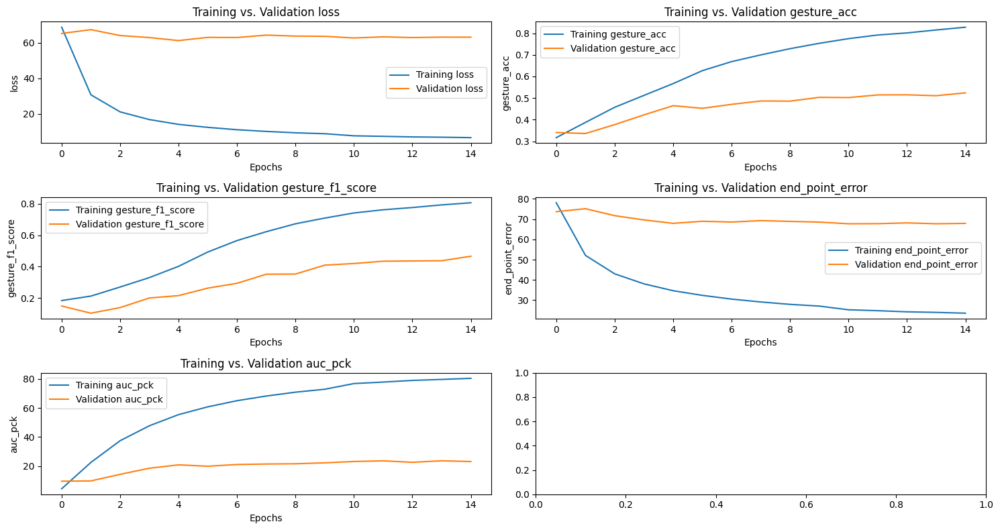

429/429 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.37107468
Gesture F1 Score:  0.13532813536413063
AucPCK :  [ 0.3205829  1.7632058  5.136612   9.224044  14.571948  20.036428
 25.668488 ]
End point error  98.70059832412898
**************************************************
Validation Evaluation
Gesture Accuracy:  0.46479592
Gesture F1 Score:  0.21887012617395984
AucPCK :  [ 2.2886298  8.068513  14.395043  20.721575  26.683674  33.28717
 40.597668 ]
End point error  67.94249717737002
**************************************************
Worst joints : 


{'wrist_y': 29.09565499432174,
 'Ring_3_y': 21.1000759554993,
 'Index_3_y': 20.38152304050522,
 'Middle_3_y': 19.17221325237961,
 'Pinky_3_y': 16.75850878529134,
 'Ring_3_z': 16.34864258794897,
 'Pinky_3_z': 16.255653938411353,
 'Ring_2_y': 15.965394943456822,
 'Middle_3_z': 15.120429321033614,
 'Pinky_2_z': 14.811520384088508,
 'Ring_2_z': 14.717317623515811,
 'Middle_2_y': 14.637484509722572,
 'Index_1_z': 14.468683811093724,
 'Index_3_z': 14.316764948887542,
 'Index_2_z': 14.087629770860884,
 'Thumb_3_y': 13.888037390337658,
 'Index_2_y': 13.752282019564243,
 'Pinky_2_y': 13.457098068147024,
 'Middle_2_z': 12.419739403176212,
 'Middle_1_z': 12.068645620824967,
 'Thumb_3_z': 11.43782481618629,
 'Pinky_1_y': 9.912407068913563,
 'Thumb_2_y': 9.861792967755658,
 'wrist_z': 9.861728294047355,
 'Pinky_1_z': 9.790596771171046,
 'Ring_1_z': 9.666119709667626,
 'Thumb_2_z': 9.239569375680158,
 'Index_0_z': 8.750060247507713,
 'Ring_1_y': 8.706410146774639,
 'Middle_1_y': 7.289478879578581,
 

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 15
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_val(x,val=15))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  49154
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[1.0082511, -1.5718896], [-0.13135907, 1.9626...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
1,1.680001e+12,"[[1.0926499, -1.60793], [-0.16874242, 1.895202...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
2,1.680001e+12,"[[1.2312788, -1.6151862], [-0.20157327, 1.8827...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
3,1.680001e+12,"[[1.2879181, -1.6159675], [-0.21515574, 1.8807...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
4,1.680001e+12,"[[1.3440188, -1.6159626], [-0.26781934, 1.8629...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
49149,1.680527e+12,"[[0.07189924, -0.3915418], [0.26646084, 1.2513...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304
49150,1.680527e+12,"[[0.0543037, -0.38932773], [0.27352452, 1.2437...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304
49151,1.680527e+12,"[[0.032298498, -0.38678697], [0.28964972, 1.23...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304
49152,1.680527e+12,"[[-0.10598868, -0.3739974], [0.33679745, 1.346...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower15.h5')

Epoch 1/200
922/922 [==============================] - 24s 9ms/step - loss: 70.7203 - end_point_error: 80.1769 - auc_pck: 3.1090 - gesture_acc: 0.3147 - gesture_f1_score: 0.1956 - val_loss: 67.1371 - val_end_point_error: 72.7125 - val_auc_pck: 12.4031 - val_gesture_acc: 0.3147 - val_gesture_f1_score: 0.1082 - lr: 1.0000e-04
Epoch 2/200
922/922 [==============================] - 8s 8ms/step - loss: 32.2867 - end_point_error: 54.0597 - auc_pck: 18.8425 - gesture_acc: 0.3890 - gesture_f1_score: 0.2339 - val_loss: 63.1896 - val_end_point_error: 69.1454 - val_auc_pck: 17.8923 - val_gesture_acc: 0.3084 - val_gesture_f1_score: 0.0809 - lr: 1.0000e-04
Epoch 3/200
922/922 [==============================] - 8s 8ms/step - loss: 22.0656 - end_point_error: 44.3399 - auc_pck: 33.9660 - gesture_acc: 0.4687 - gesture_f1_score: 0.2887 - val_loss: 58.7323 - val_end_point_error: 66.1209 - val_auc_pck: 22.0297 - val_gesture_acc: 0.3988 - val_gesture_f1_score: 0.0962 - lr: 1.0000e-04
Epoch 4/200
922/922 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


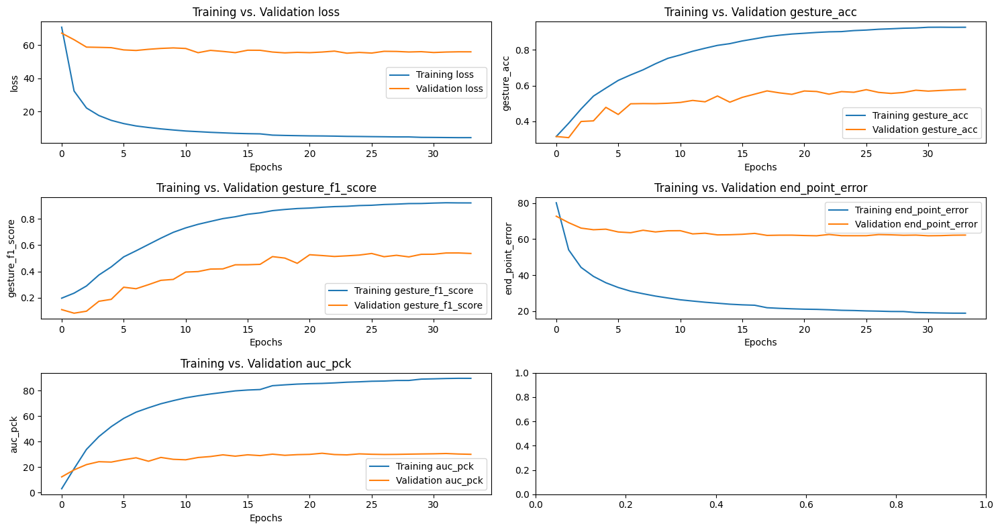

308/308 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.44615072
Gesture F1 Score:  0.37447026
AucPCK :  [ 1.1288518  3.2746873  7.942642  13.739449  19.749823  25.790703
 31.353605 ]
End point error  93.87323
**************************************************
Validation Evaluation
Gesture Accuracy:  0.56546044
Gesture F1 Score:  0.5203708
AucPCK :  [ 8.751779 15.186013 21.19333  28.4814   36.9384   44.98882  52.083755]
End point error  61.91552
**************************************************
Worst joints : 


{'wrist_z': 26.402454,
 'Ring_3_z': 19.648874,
 'Index_3_z': 19.265274,
 'Middle_3_z': 17.160652,
 'Pinky_3_y': 16.58531,
 'Ring_3_y': 16.545988,
 'Pinky_3_z': 15.855707,
 'Pinky_2_y': 15.621723,
 'Middle_3_y': 15.232483,
 'Ring_2_z': 15.0774765,
 'Ring_2_y': 14.865269,
 'Index_1_y': 14.843281,
 'Middle_2_z': 13.566984,
 'Index_3_y': 13.515019,
 'Index_2_y': 13.343652,
 'Pinky_2_z': 12.85018,
 'Index_2_z': 12.790974,
 'Thumb_3_z': 12.460468,
 'Middle_1_y': 12.213347,
 'Middle_2_y': 11.953616,
 'Thumb_3_y': 10.643351,
 'Pinky_1_y': 10.265184,
 'Ring_1_y': 9.735147,
 'Pinky_1_z': 9.553874,
 'Index_0_y': 9.157453,
 'Thumb_2_y': 8.959595,
 'Thumb_2_z': 8.955375,
 'wrist_y': 8.935735,
 'Ring_1_z': 8.23129,
 'Middle_0_y': 7.4452934,
 'Thumb_1_y': 6.9443784,
 'Thumb_0_y': 6.918451,
 'Middle_1_z': 6.6718774,
 'Index_1_z': 5.8990197,
 'Ring_0_y': 5.451236,
 'Thumb_0_z': 5.1107345,
 'Thumb_1_z': 5.079494,
 'Pinky_0_y': 3.8944209,
 'Pinky_0_z': 3.557697,
 'Index_0_z': 2.7597835,
 'Ring_0_z': 2.61

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 5
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_val(x,val=5))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  40762
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[1.3543193, -1.6481364], [-0.1797276, 1.94852...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
1,1.680001e+12,"[[1.4136245, -1.6489409], [-0.19332968, 1.9464...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
2,1.680001e+12,"[[1.4723657, -1.6489359], [-0.24606933, 1.9280...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
3,1.680001e+12,"[[1.5500914, -1.644482], [-0.31235173, 1.91018...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
4,1.680001e+12,"[[1.5937405, -1.6338611], [-0.37292445, 1.9034...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
40757,1.680524e+12,"[[-2.2979398, -2.2340846], [-0.8922566, 1.6347...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40758,1.680524e+12,"[[-2.3739061, -2.3248444], [-0.94931805, 1.748...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40759,1.680524e+12,"[[-2.3567905, -2.327781], [-0.9383652, 1.75756...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40760,1.680524e+12,"[[-2.3371553, -2.3265288], [-0.9449666, 1.7560...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower5.h5')

Epoch 1/200
764/764 [==============================] - 11s 9ms/step - loss: 68.5204 - end_point_error: 78.8452 - auc_pck: 3.1320 - gesture_acc: 0.3189 - gesture_f1_score: 0.1945 - val_loss: 59.9704 - val_end_point_error: 70.5992 - val_auc_pck: 12.8772 - val_gesture_acc: 0.3333 - val_gesture_f1_score: 0.0509 - lr: 1.0000e-04
Epoch 2/200
764/764 [==============================] - 6s 8ms/step - loss: 33.0694 - end_point_error: 54.8804 - auc_pck: 17.4808 - gesture_acc: 0.4141 - gesture_f1_score: 0.2535 - val_loss: 55.1678 - val_end_point_error: 66.7944 - val_auc_pck: 16.0611 - val_gesture_acc: 0.3438 - val_gesture_f1_score: 0.0624 - lr: 1.0000e-04
Epoch 3/200
764/764 [==============================] - 6s 8ms/step - loss: 22.7095 - end_point_error: 45.2295 - auc_pck: 32.1382 - gesture_acc: 0.4728 - gesture_f1_score: 0.3148 - val_loss: 53.6940 - val_end_point_error: 64.5906 - val_auc_pck: 21.0969 - val_gesture_acc: 0.3280 - val_gesture_f1_score: 0.0621 - lr: 1.0000e-04
Epoch 4/200
764/764 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


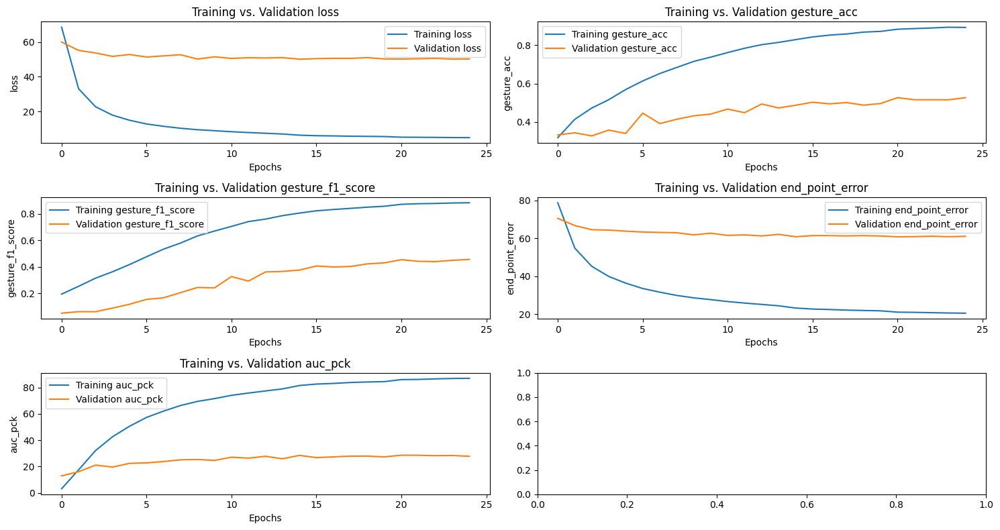

255/255 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.42764288
Gesture F1 Score:  0.30968413
AucPCK :  [ 1.6433653  4.280108   9.063037  14.606328  20.24773   26.588177
 32.094677 ]
End point error  93.24857
**************************************************
Validation Evaluation
Gesture Accuracy:  0.48748466
Gesture F1 Score:  0.37848297
AucPCK :  [ 6.674846 13.006134 20.26994  27.766872 35.90184  43.938652 51.44785 ]
End point error  60.866627
**************************************************
Worst joints : 


{'wrist_z': 24.69096,
 'Ring_3_z': 19.25105,
 'Index_3_z': 19.10063,
 'Ring_3_y': 17.678368,
 'Pinky_3_y': 17.205313,
 'Middle_3_z': 16.594309,
 'Middle_3_y': 15.983829,
 'Pinky_2_y': 15.5565,
 'Index_1_y': 15.552253,
 'Ring_2_y': 15.408659,
 'Pinky_3_z': 15.346478,
 'Ring_2_z': 14.879341,
 'Index_3_y': 13.794222,
 'Index_2_y': 13.597431,
 'Middle_2_z': 12.8923855,
 'Pinky_2_z': 12.676549,
 'Index_2_z': 12.504676,
 'Middle_1_y': 12.429705,
 'Middle_2_y': 12.406034,
 'Thumb_3_z': 11.822704,
 'Thumb_3_y': 10.71944,
 'Index_0_y': 9.932202,
 'Pinky_1_y': 9.818209,
 'Pinky_1_z': 9.680935,
 'Ring_1_y': 9.664513,
 'Thumb_2_y': 9.055922,
 'Thumb_2_z': 8.456279,
 'Ring_1_z': 8.245218,
 'wrist_y': 8.228628,
 'Middle_0_y': 7.878139,
 'Thumb_1_y': 7.0842257,
 'Thumb_0_y': 6.9330273,
 'Middle_1_z': 6.5012746,
 'Ring_0_y': 5.7443366,
 'Index_1_z': 5.512259,
 'Thumb_1_z': 4.9763865,
 'Thumb_0_z': 4.939087,
 'Pinky_0_y': 3.7184942,
 'Pinky_0_z': 3.6022706,
 'Index_0_z': 2.7186708,
 'Ring_0_z': 2.63358

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_val(x,val=0))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  36943
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[1.5160878, -1.6898174], [-0.24507298, 1.9679...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
1,1.680001e+12,"[[1.5946171, -1.6852285], [-0.31090355, 1.9497...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
2,1.680001e+12,"[[1.6387175, -1.6742854], [-0.37106332, 1.9429...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
3,1.680001e+12,"[[1.633242, -1.6628658], [-0.40273175, 1.94686...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
4,1.680001e+12,"[[1.5936763, -1.6379184], [-0.41742316, 1.9150...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
...,...,...,...,...,...,...,...
36938,1.680524e+12,"[[-1.892744, -2.5074465], [-0.8986857, 1.68363...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36939,1.680524e+12,"[[-1.8575631, -2.5037532], [-0.89620376, 1.687...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36940,1.680524e+12,"[[-1.850118, -2.5017238], [-0.8636007, 1.69748...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36941,1.680524e+12,"[[-2.29125, -2.287694], [-0.88309497, 1.670310...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower.h5')

Epoch 1/200
693/693 [==============================] - 11s 9ms/step - loss: 67.9945 - end_point_error: 78.6705 - auc_pck: 3.1128 - gesture_acc: 0.3091 - gesture_f1_score: 0.1945 - val_loss: 61.5728 - val_end_point_error: 71.7137 - val_auc_pck: 11.5377 - val_gesture_acc: 0.2529 - val_gesture_f1_score: 0.0343 - lr: 1.0000e-04
Epoch 2/200
693/693 [==============================] - 6s 8ms/step - loss: 33.0901 - end_point_error: 55.0096 - auc_pck: 16.9372 - gesture_acc: 0.3920 - gesture_f1_score: 0.2514 - val_loss: 58.0642 - val_end_point_error: 67.1845 - val_auc_pck: 19.1920 - val_gesture_acc: 0.3007 - val_gesture_f1_score: 0.0369 - lr: 1.0000e-04
Epoch 3/200
693/693 [==============================] - 6s 8ms/step - loss: 22.5755 - end_point_error: 45.2662 - auc_pck: 31.5972 - gesture_acc: 0.4502 - gesture_f1_score: 0.2911 - val_loss: 56.2544 - val_end_point_error: 66.6910 - val_auc_pck: 19.4099 - val_gesture_acc: 0.3242 - val_gesture_f1_score: 0.0885 - lr: 1.0000e-04
Epoch 4/200
693/693 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


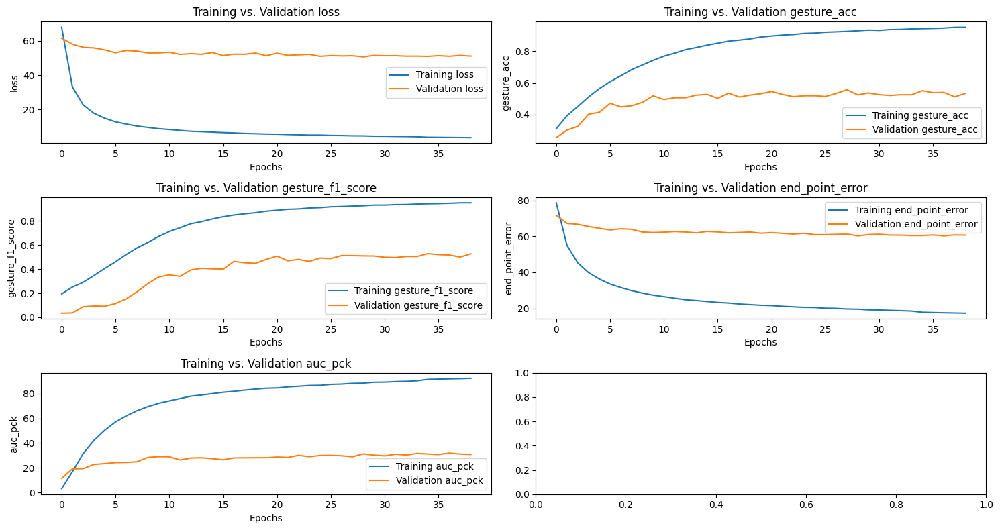

231/231 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.41683584
Gesture F1 Score:  0.36336848
AucPCK :  [ 2.016511   4.8179727  9.311138  16.199757  23.26431   29.66572
 35.850586 ]
End point error  90.56474
**************************************************
Validation Evaluation
Gesture Accuracy:  0.52437043
Gesture F1 Score:  0.5114698
AucPCK :  [10.587599 16.693745 23.503927 29.542377 37.58462  46.642296 54.589767]
End point error  60.25974
**************************************************
Worst joints : 


{'wrist_z': 25.408144,
 'Index_3_z': 18.329725,
 'Ring_3_z': 17.28388,
 'Pinky_3_y': 16.879736,
 'Ring_3_y': 16.787508,
 'Index_1_y': 15.830872,
 'Pinky_2_y': 15.731804,
 'Ring_2_y': 15.023791,
 'Middle_3_y': 14.783835,
 'Middle_3_z': 14.7277565,
 'Pinky_3_z': 14.287566,
 'Index_3_y': 13.822175,
 'Index_2_y': 13.757651,
 'Ring_2_z': 13.439716,
 'Middle_1_y': 12.483924,
 'Middle_2_z': 11.691625,
 'Index_2_z': 11.68185,
 'Pinky_2_z': 11.679593,
 'Thumb_3_z': 11.613978,
 'Middle_2_y': 11.586261,
 'Thumb_3_y': 11.085442,
 'Index_0_y': 10.141246,
 'Pinky_1_y': 9.873413,
 'Thumb_2_y': 9.78025,
 'Ring_1_y': 9.452499,
 'Pinky_1_z': 9.193864,
 'Thumb_2_z': 8.673518,
 'Middle_0_y': 7.950143,
 'Ring_1_z': 7.692833,
 'wrist_y': 7.5033674,
 'Thumb_0_y': 7.488895,
 'Thumb_1_y': 7.4620476,
 'Middle_1_z': 6.051925,
 'Ring_0_y': 5.6707892,
 'Index_1_z': 5.4264674,
 'Thumb_1_z': 5.248786,
 'Thumb_0_z': 5.229101,
 'Pinky_0_y': 3.8405054,
 'Pinky_0_z': 3.5642142,
 'Index_0_z': 2.7460232,
 'Ring_0_z': 2.56

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**Best performing was filtering val with mean. Try with reg model**

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower_reg.h5')

Epoch 1/200
693/693 [==============================] - 31s 19ms/step - loss: 61.7429 - end_point_error: 72.4989 - auc_pck: 7.8671 - gesture_acc: 0.2921 - gesture_f1_score: 0.0216 - val_loss: 65.8578 - val_end_point_error: 73.1020 - val_auc_pck: 12.2183 - val_gesture_acc: 0.2775 - val_gesture_f1_score: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/200
693/693 [==============================] - 12s 17ms/step - loss: 49.3113 - end_point_error: 64.6582 - auc_pck: 13.3188 - gesture_acc: 0.3151 - gesture_f1_score: 0.0423 - val_loss: 60.4291 - val_end_point_error: 70.5199 - val_auc_pck: 13.0420 - val_gesture_acc: 0.2965 - val_gesture_f1_score: 0.0260 - lr: 1.0000e-04
Epoch 3/200
693/693 [==============================] - 12s 17ms/step - loss: 41.8199 - end_point_error: 59.4270 - auc_pck: 17.5119 - gesture_acc: 0.3292 - gesture_f1_score: 0.0747 - val_loss: 58.1009 - val_end_point_error: 68.0032 - val_auc_pck: 16.3509 - val_gesture_acc: 0.2839 - val_gesture_f1_score: 0.0347 - lr: 1.0000e-04
Epoch 4/200
6

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


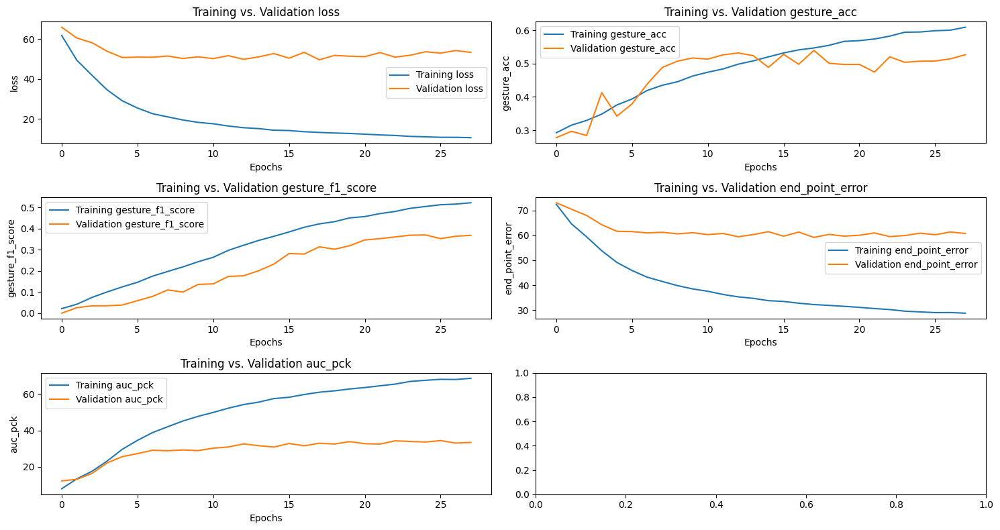

231/231 [==============================] - 1s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.46082014
Gesture F1 Score:  0.23503643
AucPCK :  [ 1.3262959  4.872107  10.975775  18.053864  24.225199  30.125862
 36.012993 ]
End point error  88.95399
**************************************************
Validation Evaluation
Gesture Accuracy:  0.53980505
Gesture F1 Score:  0.31753314
AucPCK :  [ 9.00352  17.099918 26.604387 34.606014 41.348495 47.95559  54.386677]
End point error  59.18404
**************************************************
Worst joints : 


{'wrist_z': 24.20758,
 'Index_3_z': 18.613306,
 'Ring_3_z': 17.549894,
 'Pinky_3_y': 15.784477,
 'Middle_3_z': 15.495268,
 'Index_1_y': 15.35624,
 'Ring_3_y': 15.209495,
 'Pinky_2_y': 15.154313,
 'Pinky_3_z': 14.295964,
 'Ring_2_y': 13.887378,
 'Ring_2_z': 13.58466,
 'Middle_3_y': 13.417908,
 'Index_3_y': 13.361426,
 'Index_2_y': 13.264777,
 'Middle_2_z': 12.273523,
 'Middle_1_y': 12.12758,
 'Thumb_3_z': 12.069125,
 'Index_2_z': 11.8891115,
 'Pinky_2_z': 11.716933,
 'Thumb_3_y': 11.021122,
 'Middle_2_y': 10.847565,
 'Pinky_1_y': 10.159437,
 'Thumb_2_y': 9.648768,
 'Index_0_y': 9.618543,
 'Ring_1_y': 9.397982,
 'Thumb_2_z': 8.935311,
 'Pinky_1_z': 8.568538,
 'wrist_y': 7.5731673,
 'Middle_0_y': 7.540976,
 'Ring_1_z': 7.244835,
 'Thumb_1_y': 7.1434407,
 'Thumb_0_y': 7.115222,
 'Middle_1_z': 5.840788,
 'Ring_0_y': 5.3878856,
 'Index_1_z': 5.343778,
 'Thumb_1_z': 5.1804695,
 'Thumb_0_z': 5.1085534,
 'Pinky_0_y': 3.964814,
 'Pinky_0_z': 3.362142,
 'Index_0_z': 2.5737054,
 'Ring_0_z': 2.5683

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**Try with 80/10/10**

In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower80.h5')

Epoch 1/200
924/924 [==============================] - 12s 8ms/step - loss: 64.7246 - end_point_error: 76.4442 - auc_pck: 4.1866 - gesture_acc: 0.3211 - gesture_f1_score: 0.1952 - val_loss: 77.1182 - val_end_point_error: 77.1291 - val_auc_pck: 11.8804 - val_gesture_acc: 0.3256 - val_gesture_f1_score: 0.0364 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 7s 8ms/step - loss: 29.0532 - end_point_error: 51.3506 - auc_pck: 22.0205 - gesture_acc: 0.4032 - gesture_f1_score: 0.2193 - val_loss: 70.7823 - val_end_point_error: 71.4585 - val_auc_pck: 18.9099 - val_gesture_acc: 0.3907 - val_gesture_f1_score: 0.0498 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 7s 8ms/step - loss: 20.2816 - end_point_error: 42.7519 - auc_pck: 36.4738 - gesture_acc: 0.4866 - gesture_f1_score: 0.3053 - val_loss: 67.8329 - val_end_point_error: 69.1342 - val_auc_pck: 23.6496 - val_gesture_acc: 0.4602 - val_gesture_f1_score: 0.1027 - lr: 1.0000e-04
Epoch 4/200
924/924 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


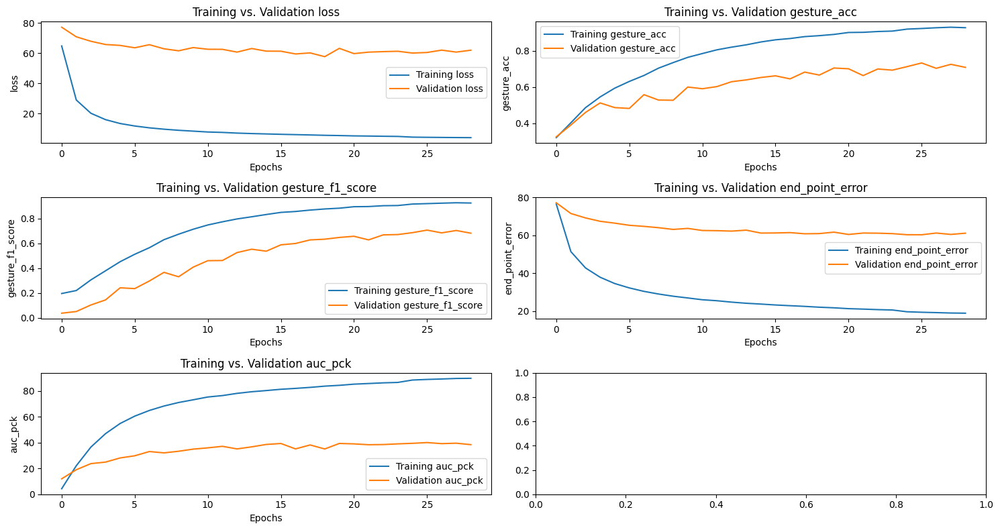

116/116 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.55543506
Gesture F1 Score:  0.48456046
AucPCK :  [ 1.0571971  3.7137434  7.1021957 12.062889  18.460287  25.155869
 32.122524 ]
End point error  95.68825
**************************************************
Validation Evaluation
Gesture Accuracy:  0.6665763
Gesture F1 Score:  0.6359023
AucPCK :  [ 9.840065 17.159122 27.487123 36.73082  45.73055  52.182163 56.600708]
End point error  60.786964
**************************************************
Worst joints : 


{'wrist_z': 27.110044,
 'Ring_3_z': 20.410185,
 'Index_3_z': 20.092146,
 'Middle_3_z': 17.552118,
 'Pinky_3_z': 16.657806,
 'Ring_3_y': 16.558723,
 'Pinky_3_y': 16.510384,
 'Ring_2_z': 16.050684,
 'Index_1_y': 15.606899,
 'Pinky_2_y': 15.4001045,
 'Middle_3_y': 14.659496,
 'Index_3_y': 14.429344,
 'Ring_2_y': 14.354572,
 'Middle_2_z': 14.155006,
 'Pinky_2_z': 13.945963,
 'Index_2_z': 13.642755,
 'Index_2_y': 13.434006,
 'Middle_1_y': 12.569699,
 'Thumb_3_z': 12.566288,
 'Middle_2_y': 11.752402,
 'Thumb_3_y': 11.5945425,
 'Pinky_1_y': 10.043359,
 'Ring_1_y': 9.790454,
 'Pinky_1_z': 9.786519,
 'Index_0_y': 9.532691,
 'Thumb_2_y': 9.4153385,
 'Thumb_2_z': 9.276685,
 'wrist_y': 9.098413,
 'Ring_1_z': 8.613045,
 'Middle_0_y': 7.822262,
 'Middle_1_z': 7.319963,
 'Thumb_0_y': 6.9038696,
 'Thumb_1_y': 6.840149,
 'Index_1_z': 6.623381,
 'Ring_0_y': 5.6014132,
 'Thumb_1_z': 5.3432784,
 'Thumb_0_z': 5.3330755,
 'Pinky_0_y': 3.8216228,
 'Pinky_0_z': 3.467266,
 'Index_0_z': 2.8091247,
 'Ring_0_z': 

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**try with reg model on 80/10/10**

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/filter_cap_img/mean_lower80_reg.h5')

Epoch 1/200
924/924 [==============================] - 23s 18ms/step - loss: 63.4114 - end_point_error: 73.6080 - auc_pck: 7.0896 - gesture_acc: 0.2956 - gesture_f1_score: 0.0331 - val_loss: 90.6689 - val_end_point_error: 81.4722 - val_auc_pck: 13.4065 - val_gesture_acc: 0.2942 - val_gesture_f1_score: 0.0160 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 15s 16ms/step - loss: 51.1788 - end_point_error: 65.7594 - auc_pck: 12.9164 - gesture_acc: 0.3282 - gesture_f1_score: 0.0570 - val_loss: 85.0078 - val_end_point_error: 78.6117 - val_auc_pck: 14.9588 - val_gesture_acc: 0.3104 - val_gesture_f1_score: 0.0250 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 15s 16ms/step - loss: 41.5089 - end_point_error: 58.9817 - auc_pck: 18.4406 - gesture_acc: 0.3552 - gesture_f1_score: 0.0832 - val_loss: 74.4550 - val_end_point_error: 72.8360 - val_auc_pck: 19.5732 - val_gesture_acc: 0.3486 - val_gesture_f1_score: 0.0644 - lr: 1.0000e-04
Epoch 4/200
924/9

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


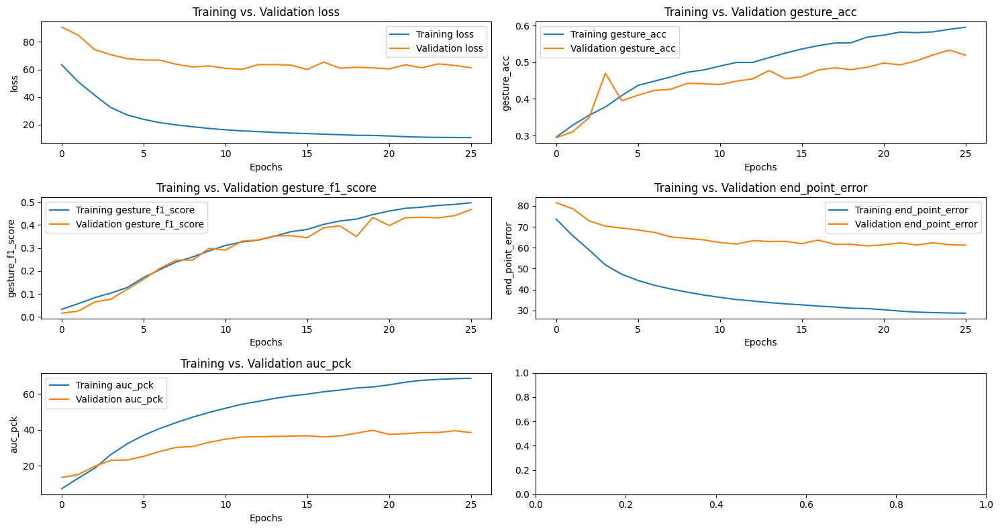

116/116 [==============================] - 0s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.44998646
Gesture F1 Score:  0.29570675
AucPCK :  [ 1.9517485  5.9907837 13.038763  19.517485  26.321497  33.47791
 40.688534 ]
End point error  92.0532
**************************************************
Validation Evaluation
Gesture Accuracy:  0.45893195
Gesture F1 Score:  0.3459562
AucPCK :  [12.686364 22.17403  29.465979 37.67959  45.16129  52.34481  57.685013]
End point error  61.885597
**************************************************
Worst joints : 


{'wrist_z': 27.392603,
 'Ring_3_z': 20.389465,
 'Index_3_z': 18.439743,
 'Middle_3_z': 18.158957,
 'Ring_2_z': 15.723613,
 'Pinky_3_z': 15.676785,
 'Index_1_y': 15.3596945,
 'Pinky_3_y': 14.939539,
 'Ring_3_y': 14.765151,
 'Middle_2_z': 14.034884,
 'Pinky_2_y': 14.016337,
 'Middle_3_y': 13.658651,
 'Pinky_2_z': 13.1586,
 'Thumb_3_z': 12.95461,
 'Ring_2_y': 12.916848,
 'Index_3_y': 12.875876,
 'Index_2_z': 12.638564,
 'Middle_1_y': 12.268402,
 'Index_2_y': 11.951318,
 'Thumb_3_y': 11.3553505,
 'Middle_2_y': 10.791091,
 'Pinky_1_y': 9.530337,
 'Pinky_1_z': 9.519053,
 'Ring_1_y': 9.467733,
 'Thumb_2_y': 9.405181,
 'Thumb_2_z': 9.373966,
 'Index_0_y': 9.019093,
 'wrist_y': 8.627265,
 'Ring_1_z': 8.273139,
 'Middle_0_y': 7.221894,
 'Middle_1_z': 6.965911,
 'Thumb_1_y': 6.687638,
 'Thumb_0_y': 6.66842,
 'Index_1_z': 6.301332,
 'Thumb_1_z': 5.3486485,
 'Thumb_0_z': 5.331144,
 'Ring_0_y': 5.213801,
 'Pinky_0_y': 3.6196058,
 'Pinky_0_z': 3.4116538,
 'Index_0_z': 2.7318573,
 'Ring_0_z': 2.555084

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

### Without wrist

base 2d

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-0.8411842005698658, -0.66334736...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-0.856800939635355, -0.657283824...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-0.8854490513350487, -0.63328413...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-0.9201524691708463, -0.60498760...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-0.9846097152982555, -0.53409194...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [-0.5701268248332824, 0.537976303...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [-0.5423914319203718, 0.558567730...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [-0.6134668944488612, 0.495033001...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [-0.1553705208110349, 0.293269562...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/base.h5')

Epoch 1/200
1518/1518 [==============================] - 19s 9ms/step - loss: 53.0662 - end_point_error: 67.6727 - auc_pck: 10.5921 - gesture_acc: 0.3189 - gesture_f1_score: 0.1724 - val_loss: 58.7022 - val_end_point_error: 66.8457 - val_auc_pck: 19.8260 - val_gesture_acc: 0.3041 - val_gesture_f1_score: 0.0560 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 12s 8ms/step - loss: 24.0857 - end_point_error: 45.4014 - auc_pck: 34.2770 - gesture_acc: 0.3991 - gesture_f1_score: 0.2044 - val_loss: 58.0660 - val_end_point_error: 65.6869 - val_auc_pck: 22.7758 - val_gesture_acc: 0.3545 - val_gesture_f1_score: 0.0802 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 12s 8ms/step - loss: 17.3528 - end_point_error: 38.1812 - auc_pck: 48.4725 - gesture_acc: 0.4720 - gesture_f1_score: 0.2617 - val_loss: 57.1467 - val_end_point_error: 65.0296 - val_auc_pck: 23.5639 - val_gesture_acc: 0.3923 - val_gesture_f1_score: 0.1453 - lr: 1.0000e-04
Epoch 4/200
1

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


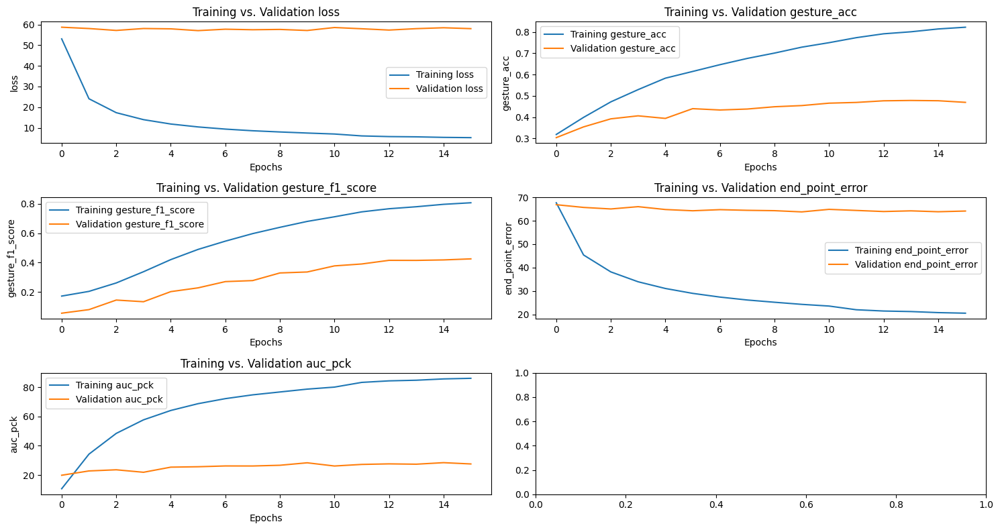

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.3642597
Gesture F1 Score:  0.10316937849630611
AucPCK :  [ 2.0816603  5.3493114 10.3897705 15.714375  21.354006  28.327877
 34.4802   ]
End point error  88.5512467045933
**************************************************
Validation Evaluation
Gesture Accuracy:  0.43997777
Gesture F1 Score:  0.23244966392783875
AucPCK :  [ 5.644066 10.954675 17.673212 25.206867 32.518215 39.94072  47.468197]
End point error  64.30485726403195
**************************************************
Worst joints : 


{'Index_3_z': 21.242773902565197,
 'Ring_3_z': 20.630242413492216,
 'Middle_3_z': 19.721802274442496,
 'Pinky_3_z': 16.30740465095373,
 'Pinky_3_y': 15.754755743479508,
 'Ring_3_y': 15.556191275763958,
 'Ring_2_z': 15.378029887543727,
 'Pinky_2_y': 14.84137061385857,
 'Middle_2_z': 14.75950085732771,
 'Index_2_z': 14.55355001839925,
 'Thumb_3_z': 14.409211322183557,
 'Middle_3_y': 14.29741266717229,
 'Ring_2_y': 14.23964161753153,
 'Index_3_y': 14.051581394585048,
 'Index_2_y': 13.924930342954598,
 'Index_1_y': 13.81379047447494,
 'Pinky_2_z': 12.733475576472976,
 'Middle_2_y': 11.91494955424176,
 'Middle_1_y': 11.757253831413035,
 'Thumb_3_y': 11.292406013393325,
 'Thumb_2_z': 10.273323987721783,
 'Pinky_1_y': 9.994085402305243,
 'Ring_1_y': 9.713601210029646,
 'Pinky_1_z': 9.268781398315303,
 'Thumb_2_y': 9.000570811664035,
 'Index_0_y': 8.306597568867955,
 'Ring_1_z': 8.191228804816426,
 'Middle_1_z': 7.255447644872375,
 'Index_1_z': 7.003440818276775,
 'Middle_0_y': 6.7336180818112

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80

In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/base_80.h5')

Epoch 1/200
2024/2024 [==============================] - 21s 8ms/step - loss: 52.3076 - end_point_error: 66.7058 - auc_pck: 12.4065 - gesture_acc: 0.3196 - gesture_f1_score: 0.1619 - val_loss: 101.4182 - val_end_point_error: 82.3853 - val_auc_pck: 17.5953 - val_gesture_acc: 0.3968 - val_gesture_f1_score: 0.0599 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 15s 8ms/step - loss: 23.2404 - end_point_error: 44.1449 - auc_pck: 37.6249 - gesture_acc: 0.4313 - gesture_f1_score: 0.2138 - val_loss: 101.7458 - val_end_point_error: 80.0806 - val_auc_pck: 22.6606 - val_gesture_acc: 0.4393 - val_gesture_f1_score: 0.0737 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 15s 8ms/step - loss: 16.6630 - end_point_error: 36.9837 - auc_pck: 51.6472 - gesture_acc: 0.5049 - gesture_f1_score: 0.2925 - val_loss: 101.3359 - val_end_point_error: 78.8803 - val_auc_pck: 25.4025 - val_gesture_acc: 0.4657 - val_gesture_f1_score: 0.1235 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


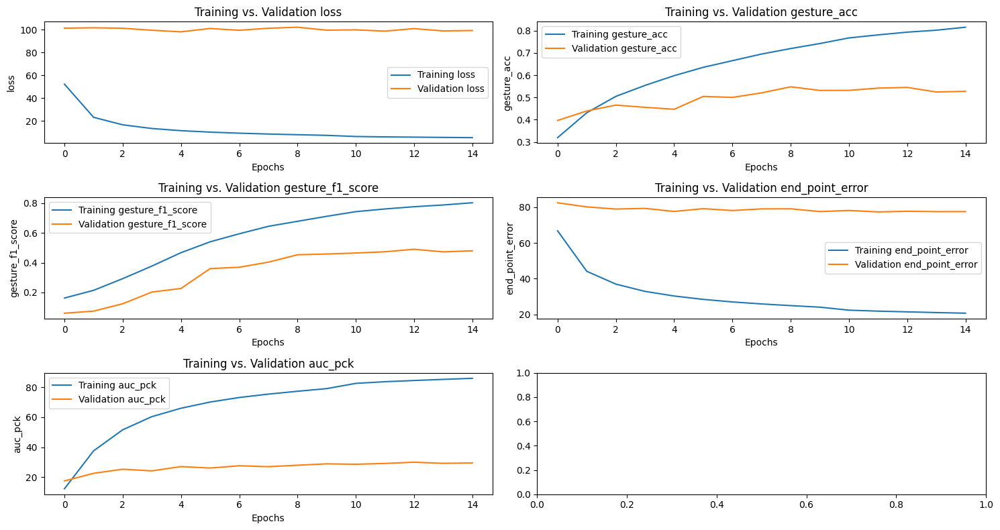

254/254 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.39367744
Gesture F1 Score:  0.13974866893395024
AucPCK :  [ 2.3462584  5.6186714  9.990121  15.23833   21.16572   28.1551
 33.662632 ]
End point error  89.38138417208276
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4487528
Gesture F1 Score:  0.2316081380847342
AucPCK :  [ 6.334898 14.102247 21.474438 28.229193 34.218327 40.367992 46.048405]
End point error  77.23190721324428
**************************************************
Worst joints : 


{'Index_3_z': 21.68768652548472,
 'Middle_3_z': 20.933696714231033,
 'Ring_3_z': 20.377026976889372,
 'Pinky_3_y': 16.334801923783314,
 'Ring_3_y': 16.00774689999202,
 'Pinky_3_z': 16.001524130925237,
 'Pinky_2_y': 15.48978415408706,
 'Ring_2_z': 15.213869245797742,
 'Middle_2_z': 15.008513853863866,
 'Thumb_3_z': 14.791969861473083,
 'Ring_2_y': 14.560134109276806,
 'Index_2_z': 14.496161410713013,
 'Middle_3_y': 14.387769219700779,
 'Index_3_y': 14.344227897572269,
 'Index_2_y': 14.142355874165315,
 'Index_1_y': 13.608155354523614,
 'Pinky_2_z': 12.535728232348548,
 'Middle_2_y': 12.456415197566706,
 'Middle_1_y': 11.75809404291758,
 'Thumb_3_y': 11.704691309406638,
 'Thumb_2_z': 10.576702165007976,
 'Pinky_1_y': 10.066201418803361,
 'Ring_1_y': 9.710617309402966,
 'Thumb_2_y': 9.444944365065226,
 'Pinky_1_z': 8.958431548113126,
 'Ring_1_z': 8.193096310078431,
 'Index_0_y': 8.168227554207363,
 'Middle_1_z': 7.212900426607014,
 'Index_1_z': 7.0036795043786215,
 'Thumb_1_y': 6.72139200

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

reg 2d

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/base_reg.h5')

Epoch 1/200
1518/1518 [==============================] - 46s 19ms/step - loss: 52.9700 - end_point_error: 64.8352 - auc_pck: 17.4065 - gesture_acc: 0.3028 - gesture_f1_score: 0.0232 - val_loss: 60.3265 - val_end_point_error: 67.8562 - val_auc_pck: 18.3899 - val_gesture_acc: 0.3352 - val_gesture_f1_score: 0.0185 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 27s 18ms/step - loss: 40.5912 - end_point_error: 56.4085 - auc_pck: 24.5104 - gesture_acc: 0.3340 - gesture_f1_score: 0.0905 - val_loss: 57.9123 - val_end_point_error: 65.5893 - val_auc_pck: 21.6936 - val_gesture_acc: 0.3680 - val_gesture_f1_score: 0.1054 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 26s 17ms/step - loss: 31.1958 - end_point_error: 49.5448 - auc_pck: 31.9526 - gesture_acc: 0.3516 - gesture_f1_score: 0.1306 - val_loss: 59.3284 - val_end_point_error: 65.0815 - val_auc_pck: 24.7825 - val_gesture_acc: 0.3722 - val_gesture_f1_score: 0.1344 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


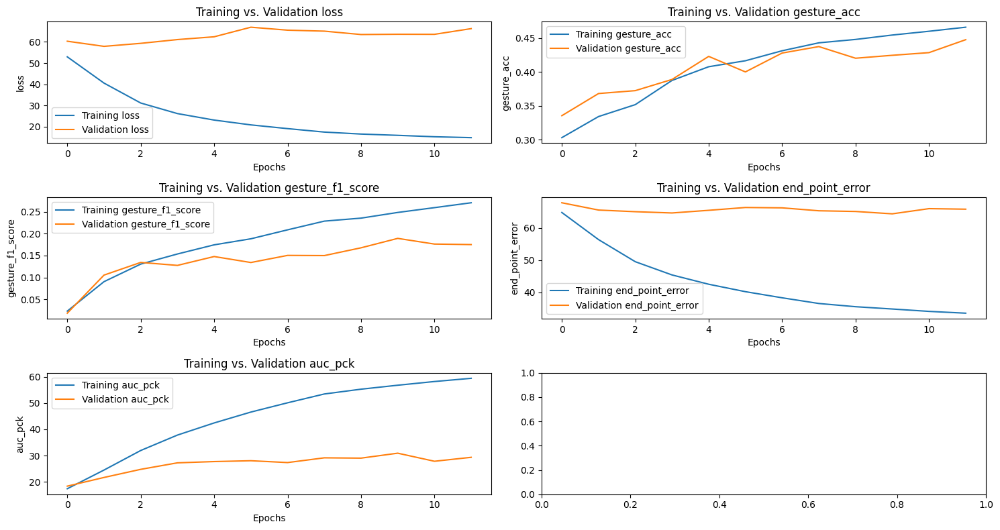

507/507 [==============================] - 2s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.32367656
Gesture F1 Score:  0.1571232302957895
AucPCK :  [ 0.34591392  3.4220767   7.220952   13.157082   19.513248   26.542715
 33.75749   ]
End point error  87.8079271868004
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3677288
Gesture F1 Score:  0.10833427533807995
AucPCK :  [ 1.7537359  5.4835124 11.257256  19.890083  28.739038  37.47067
 47.449673 ]
End point error  65.60194416389737
**************************************************
Worst joints : 


{'Ring_3_y': 21.14245133480778,
 'Index_3_y': 20.361636764580552,
 'Middle_3_y': 20.020069964253885,
 'Pinky_3_y': 16.73869303209448,
 'Ring_3_z': 16.16293936677817,
 'Pinky_3_z': 16.043348587078718,
 'Ring_2_y': 15.880284226148769,
 'Middle_2_y': 14.878367752584822,
 'Pinky_2_z': 14.838065935727819,
 'Index_1_z': 14.395914748551546,
 'Middle_3_z': 14.327996946878327,
 'Ring_2_z': 14.272822758923903,
 'Index_2_y': 13.840069515062872,
 'Thumb_3_y': 13.668670062025296,
 'Pinky_2_y': 13.565126768721552,
 'Index_2_z': 13.502964280672312,
 'Index_3_z': 12.944366015347661,
 'Middle_1_z': 12.303022464775577,
 'Middle_2_z': 11.918200565510958,
 'Thumb_3_z': 11.167721553685555,
 'Pinky_1_y': 9.925608252992253,
 'Ring_1_z': 9.874166655354841,
 'Pinky_1_z': 9.830868771994645,
 'Thumb_2_y': 9.723772045669469,
 'Thumb_2_z': 8.71513137042207,
 'Ring_1_y': 8.670677975759258,
 'Index_0_z': 8.565064885631767,
 'Middle_1_y': 7.246971470159414,
 'Middle_0_z': 6.95334263698411,
 'Thumb_0_z': 6.55205590700

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80 reg2d

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/base_80_reg.h5')

Epoch 1/200
2024/2024 [==============================] - 50s 16ms/step - loss: 54.1524 - end_point_error: 65.5783 - auc_pck: 16.7628 - gesture_acc: 0.3055 - gesture_f1_score: 0.0234 - val_loss: 111.9933 - val_end_point_error: 86.7788 - val_auc_pck: 15.4528 - val_gesture_acc: 0.3498 - val_gesture_f1_score: 0.0213 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 32s 16ms/step - loss: 40.7836 - end_point_error: 56.4555 - auc_pck: 24.4500 - gesture_acc: 0.3376 - gesture_f1_score: 0.1020 - val_loss: 99.2496 - val_end_point_error: 79.6856 - val_auc_pck: 20.6640 - val_gesture_acc: 0.3912 - val_gesture_f1_score: 0.0997 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 32s 16ms/step - loss: 30.6070 - end_point_error: 49.1357 - auc_pck: 32.6569 - gesture_acc: 0.3612 - gesture_f1_score: 0.1383 - val_loss: 100.9829 - val_end_point_error: 79.5579 - val_auc_pck: 22.6677 - val_gesture_acc: 0.4216 - val_gesture_f1_score: 0.1161 - lr: 1.0000e-04
Epoch 4/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


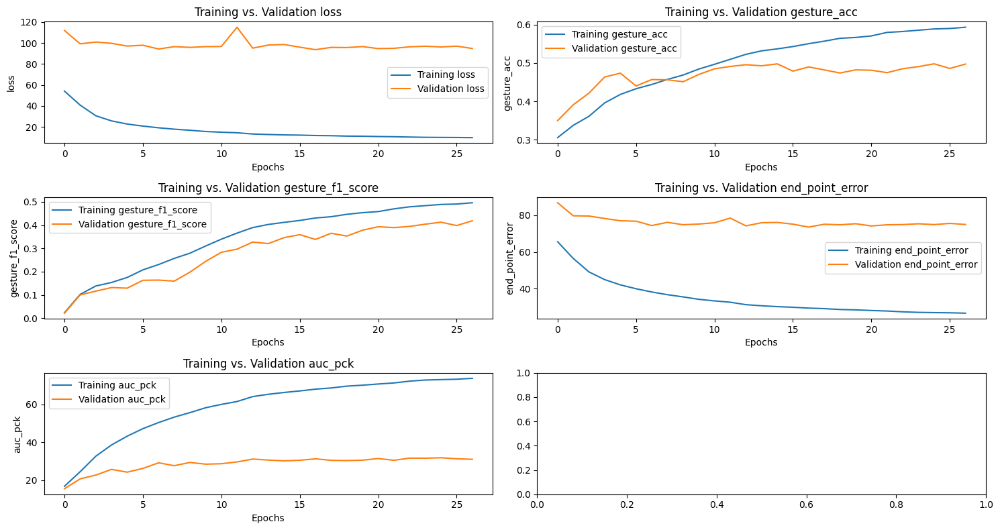

254/254 [==============================] - 1s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.4252902
Gesture F1 Score:  0.2737606785724978
AucPCK :  [ 2.729069   6.7053595 12.126451  16.843664  23.746603  29.958015
 36.688072 ]
End point error  89.0071454993602
**************************************************
Validation Evaluation
Gesture Accuracy:  0.49160287
Gesture F1 Score:  0.34343609866250274
AucPCK :  [ 8.113114 16.31267  24.857988 32.637688 39.849346 46.159546 51.667076]
End point error  73.18891649636139
**************************************************
Worst joints : 


{'Index_3_y': 21.345730833208783,
 'Middle_3_y': 20.64045302671549,
 'Ring_3_y': 20.41748719045397,
 'Pinky_3_z': 15.771593912196735,
 'Ring_3_z': 15.674496189566735,
 'Pinky_3_y': 15.522475125895348,
 'Ring_2_y': 15.160804703004061,
 'Thumb_3_y': 14.999813640140166,
 'Index_3_z': 14.835956334168673,
 'Pinky_2_z': 14.832686970154905,
 'Middle_2_y': 14.759469682866644,
 'Index_2_z': 14.527717684815045,
 'Index_2_y': 14.37741393468542,
 'Ring_2_z': 14.286275474469937,
 'Middle_3_z': 14.265405281926585,
 'Index_1_z': 13.690027753586083,
 'Pinky_2_y': 12.550133972585126,
 'Middle_2_z': 12.501909922640118,
 'Thumb_3_z': 11.70672348032989,
 'Middle_1_z': 11.618040237866037,
 'Thumb_2_y': 10.808318768264119,
 'Pinky_1_z': 9.847619390453696,
 'Ring_1_z': 9.756600535752563,
 'Thumb_2_z': 9.416997970738837,
 'Pinky_1_y': 9.149109244147894,
 'Ring_1_y': 8.198070169383307,
 'Index_0_z': 8.083904483696726,
 'Middle_1_y': 7.07177199403117,
 'Index_1_y': 6.74776952835647,
 'Thumb_1_z': 6.641345218178

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

try some filterings of capactive images

In [ ]:
# try with cap_img in mean +- 2 std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=2))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  78910
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-0.8687748708199673, -0.64612795...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-0.8844354351377788, -0.64008988...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-0.9131639420287179, -0.61619100...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-0.9479647480603942, -0.58801333...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-1.0126028805472214, -0.51741545...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
78905,1.680527e+12,"[[0.0, 0.0], [-0.5969568268135444, 0.550149720...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78906,1.680527e+12,"[[0.0, 0.0], [-0.569143600071973, 0.5706546552...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78907,1.680527e+12,"[[0.0, 0.0], [-0.6404185216594998, 0.507386794...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78908,1.680527e+12,"[[0.0, 0.0], [-0.18103659224217156, 0.30647083...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_2_std.h5')

Epoch 1/200
1480/1480 [==============================] - 18s 9ms/step - loss: 54.3302 - end_point_error: 68.3217 - auc_pck: 10.7576 - gesture_acc: 0.2968 - gesture_f1_score: 0.1431 - val_loss: 61.8861 - val_end_point_error: 68.4102 - val_auc_pck: 17.4844 - val_gesture_acc: 0.3089 - val_gesture_f1_score: 0.0470 - lr: 1.0000e-04
Epoch 2/200
1480/1480 [==============================] - 12s 8ms/step - loss: 24.9077 - end_point_error: 45.9825 - auc_pck: 33.8926 - gesture_acc: 0.3759 - gesture_f1_score: 0.1673 - val_loss: 60.6068 - val_end_point_error: 66.8462 - val_auc_pck: 21.9346 - val_gesture_acc: 0.3453 - val_gesture_f1_score: 0.0773 - lr: 1.0000e-04
Epoch 3/200
1480/1480 [==============================] - 12s 8ms/step - loss: 18.0075 - end_point_error: 38.7743 - auc_pck: 47.5671 - gesture_acc: 0.4493 - gesture_f1_score: 0.2267 - val_loss: 59.0966 - val_end_point_error: 66.1912 - val_auc_pck: 22.9456 - val_gesture_acc: 0.4167 - val_gesture_f1_score: 0.1294 - lr: 1.0000e-04
Epoch 4/200
1

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


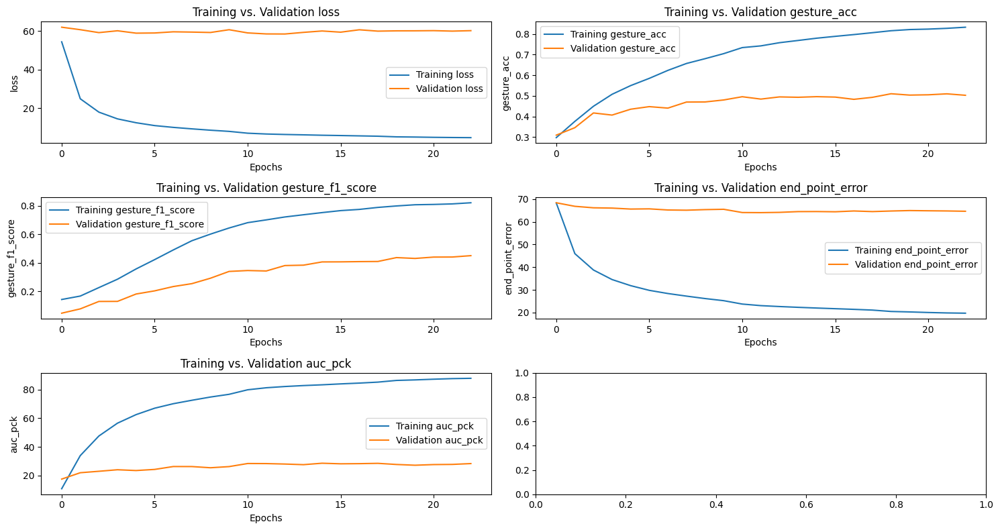

494/494 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.34336776
Gesture F1 Score:  0.2207054111410058
AucPCK :  [ 3.0610304  6.45795   11.001965  16.921225  23.062298  29.17802
 34.43184  ]
End point error  89.67086172328243
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4943927
Gesture F1 Score:  0.3846551736071856
AucPCK :  [ 6.728759 12.526135 19.977192 27.846416 35.47488  43.312424 49.958817]
End point error  64.15462109953695
**************************************************
Worst joints : 


{'Index_3_y': 21.629858988745415,
 'Ring_3_y': 21.349284211261722,
 'Middle_3_y': 20.29254803457601,
 'Pinky_3_y': 16.53215756251457,
 'Pinky_3_z': 16.03585315028209,
 'Ring_3_z': 15.962787365389346,
 'Ring_2_y': 15.762401664783344,
 'Middle_2_y': 15.181913349000553,
 'Pinky_2_z': 14.761625295329756,
 'Middle_3_z': 14.608064266750684,
 'Index_2_y': 14.561191183234238,
 'Ring_2_z': 14.274130814964748,
 'Index_1_z': 14.207708864304537,
 'Index_3_z': 14.167005282492692,
 'Index_2_z': 14.166028264914258,
 'Thumb_3_y': 14.143251321696447,
 'Pinky_2_y': 13.107626192948924,
 'Middle_2_z': 12.127854603007908,
 'Middle_1_z': 11.835294236003032,
 'Thumb_3_z': 11.365589678578626,
 'Thumb_2_y': 10.072731861773905,
 'Pinky_1_z': 9.920457565344666,
 'Pinky_1_y': 9.61300529404972,
 'Ring_1_z': 9.577490216740404,
 'Thumb_2_z': 9.18861762449624,
 'Ring_1_y': 8.52847223828762,
 'Index_0_z': 8.472959333050126,
 'Middle_1_y': 7.452814775601082,
 'Index_1_y': 6.9798122204926205,
 'Thumb_0_z': 6.82718468187

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img = mean +- std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=1))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  57303
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0], [-1.0264869928359985, 1.788309931...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0], [-1.042385458946228, 1.7852127552...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0], [-1.0774983167648315, 1.785398721...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0], [-1.0746150016784668, 1.818293213...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0], [-1.0412570238113403, 1.821938157...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
57298,1.680527e+12,"[[0.0, 0.0], [-0.748900294303894, 0.3619967103...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57299,1.680527e+12,"[[0.0, 0.0], [-0.7462087273597717, 0.381501197...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57300,1.680527e+12,"[[0.0, 0.0], [-0.7318339943885803, 0.389512509...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57301,1.680527e+12,"[[0.0, 0.0], [-0.7119733095169067, 0.395059555...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)

data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_std.h5')

Epoch 1/200
1074/1074 [==============================] - 14s 9ms/step - loss: 61.8021 - end_point_error: 73.6735 - auc_pck: 6.8387 - gesture_acc: 0.3043 - gesture_f1_score: 0.1849 - val_loss: 58.3472 - val_end_point_error: 68.4290 - val_auc_pck: 14.3392 - val_gesture_acc: 0.3078 - val_gesture_f1_score: 0.1406 - lr: 1.0000e-04
Epoch 2/200
1074/1074 [==============================] - 9s 8ms/step - loss: 28.2277 - end_point_error: 49.6322 - auc_pck: 26.8389 - gesture_acc: 0.3783 - gesture_f1_score: 0.2285 - val_loss: 56.9278 - val_end_point_error: 66.1391 - val_auc_pck: 20.1915 - val_gesture_acc: 0.3439 - val_gesture_f1_score: 0.1022 - lr: 1.0000e-04
Epoch 3/200
1074/1074 [==============================] - 9s 8ms/step - loss: 19.1932 - end_point_error: 40.7057 - auc_pck: 42.4153 - gesture_acc: 0.4468 - gesture_f1_score: 0.2589 - val_loss: 55.0868 - val_end_point_error: 64.6934 - val_auc_pck: 22.6107 - val_gesture_acc: 0.3964 - val_gesture_f1_score: 0.1757 - lr: 1.0000e-04
Epoch 4/200
1074

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


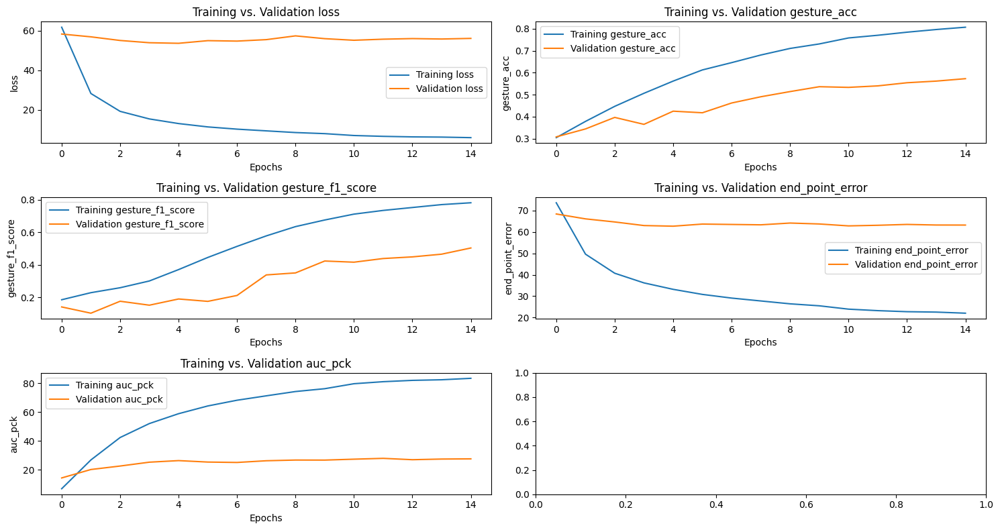

359/359 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.39221844
Gesture F1 Score:  0.13523821326353302
AucPCK :  [ 1.1602547  4.989968  10.328884  15.632907  21.460352  27.785048
 33.813137 ]
End point error  90.96995511873281
**************************************************
Validation Evaluation
Gesture Accuracy:  0.42439577
Gesture F1 Score:  0.19258283148092897
AucPCK :  [ 4.8948607 11.569672  18.951225  26.489836  33.749237  40.97374
 47.875404 ]
End point error  62.721854069890696
**************************************************
Worst joints : 


{'Index_3_y': 21.886197847443054,
 'Ring_3_y': 21.457276127548308,
 'Middle_3_y': 20.201596568025675,
 'Pinky_3_y': 17.12468748186872,
 'Ring_2_y': 16.359697071466165,
 'Ring_3_z': 16.18281026980291,
 'Pinky_3_z': 16.170770992378465,
 'Middle_3_z': 15.211003100755107,
 'Middle_2_y': 15.18874649300934,
 'Index_1_z': 14.832704912833822,
 'Index_2_z': 14.764768840820553,
 'Index_2_y': 14.622565145643158,
 'Pinky_2_z': 14.498073914980107,
 'Index_3_z': 14.37967159964002,
 'Ring_2_z': 14.369144424029985,
 'Thumb_3_y': 14.210271380073333,
 'Pinky_2_y': 13.907517618632081,
 'Middle_1_z': 12.67498126521044,
 'Middle_2_z': 12.310114350603751,
 'Thumb_3_z': 11.881987011954488,
 'Ring_1_z': 10.281310504852305,
 'Thumb_2_y': 10.114382303547412,
 'Pinky_1_y': 9.901042673270933,
 'Pinky_1_z': 9.467650000828627,
 'Thumb_2_z': 9.463979010245003,
 'Ring_1_y': 8.787156390915207,
 'Index_0_z': 8.659880353771596,
 'Middle_1_y': 7.4829625550489665,
 'Index_1_y': 7.2618830714186675,
 'Middle_0_z': 6.9630790

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 2 std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=2,lower=True))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-0.8411842005698658, -0.66334736...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-0.856800939635355, -0.657283824...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-0.8854490513350487, -0.63328413...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-0.9201524691708463, -0.60498760...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-0.9846097152982555, -0.53409194...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [-0.5701268248332824, 0.537976303...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [-0.5423914319203718, 0.558567730...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [-0.6134668944488612, 0.495033001...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [-0.1553705208110349, 0.293269562...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower_2std.h5')

Epoch 1/200
1518/1518 [==============================] - 18s 9ms/step - loss: 55.0482 - end_point_error: 68.9823 - auc_pck: 9.9342 - gesture_acc: 0.3253 - gesture_f1_score: 0.1897 - val_loss: 62.5089 - val_end_point_error: 69.2421 - val_auc_pck: 16.4694 - val_gesture_acc: 0.3315 - val_gesture_f1_score: 0.0798 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 12s 8ms/step - loss: 24.8845 - end_point_error: 46.0058 - auc_pck: 33.7001 - gesture_acc: 0.4040 - gesture_f1_score: 0.2103 - val_loss: 59.6075 - val_end_point_error: 67.4474 - val_auc_pck: 18.5475 - val_gesture_acc: 0.3694 - val_gesture_f1_score: 0.0836 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 13s 8ms/step - loss: 17.8023 - end_point_error: 38.6116 - auc_pck: 47.6853 - gesture_acc: 0.4840 - gesture_f1_score: 0.2699 - val_loss: 58.3976 - val_end_point_error: 66.2591 - val_auc_pck: 21.8178 - val_gesture_acc: 0.3958 - val_gesture_f1_score: 0.1457 - lr: 1.0000e-04
Epoch 4/200
15

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


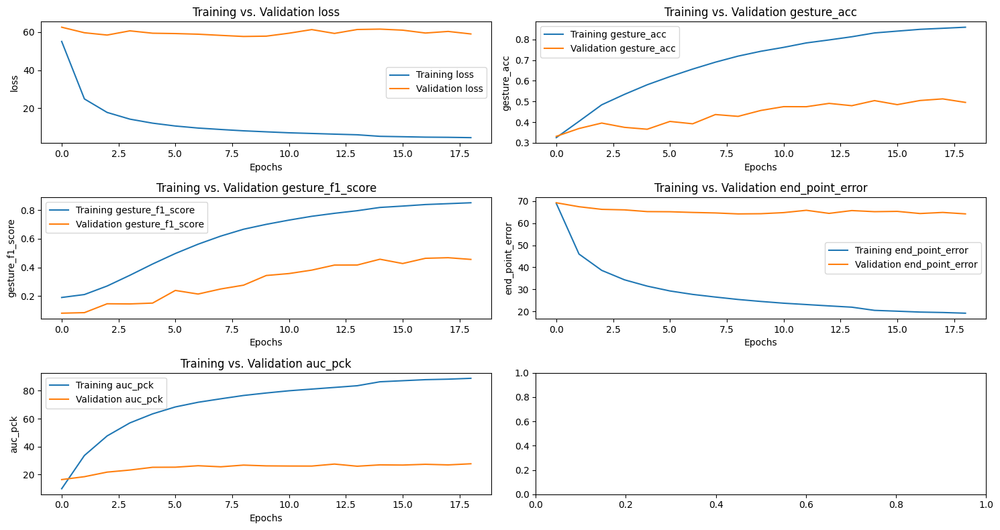

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.31410217
Gesture F1 Score:  0.16058832372274767
AucPCK :  [ 2.9587991  6.998579  12.3911295 18.26549   24.769905  30.205694
 35.52412  ]
End point error  88.73944708407956
**************************************************
Validation Evaluation
Gesture Accuracy:  0.42799804
Gesture F1 Score:  0.28008122554445103
AucPCK :  [ 6.4344816 11.127579  17.278004  25.435347  34.413982  43.13326
 49.715946 ]
End point error  64.24293448175864
**************************************************
Worst joints : 


{'Index_3_y': 21.326014861381747,
 'Ring_3_y': 21.11038828006399,
 'Middle_3_y': 20.22111236886739,
 'Pinky_3_y': 16.48857206643246,
 'Pinky_3_z': 15.798969551543427,
 'Ring_2_y': 15.782568420693298,
 'Ring_3_z': 15.616318227355514,
 'Middle_2_y': 15.014336065804253,
 'Pinky_2_z': 14.578193981813293,
 'Index_2_y': 14.390542819813444,
 'Middle_3_z': 14.293609737065715,
 'Index_2_z': 14.107768192786557,
 'Ring_2_z': 14.046424252251056,
 'Index_3_z': 13.927726789562954,
 'Thumb_3_y': 13.905905969189298,
 'Index_1_z': 13.892258048983924,
 'Pinky_2_y': 13.079157977159342,
 'Middle_2_z': 11.992375711268847,
 'Middle_1_z': 11.78596561905226,
 'Thumb_3_z': 11.329639979912065,
 'Pinky_1_y': 9.889533908617802,
 'Thumb_2_y': 9.819805385224129,
 'Ring_1_z': 9.729344526838402,
 'Pinky_1_z': 9.64290177840573,
 'Thumb_2_z': 9.218416749486474,
 'Ring_1_y': 8.628837506499119,
 'Index_0_z': 8.175085580390919,
 'Middle_1_y': 7.361440470421748,
 'Index_1_y': 6.920317920381506,
 'Thumb_0_z': 6.740639144288

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_std(x,m=1,lower=True))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  68619
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0], [-0.9491683405502318, 1.808641689...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0], [-0.9652297847722106, 1.805437980...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0], [-1.0007027171446303, 1.805630418...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0], [-0.9977898958742926, 1.839655305...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0], [-0.9640898115402963, 1.843425575...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
68614,1.680527e+12,"[[0.0, 0.0], [-0.668734925499336, 0.3333125203...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68615,1.680527e+12,"[[0.0, 0.0], [-0.6660157599268891, 0.353487282...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68616,1.680527e+12,"[[0.0, 0.0], [-0.6514935790355687, 0.361773920...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68617,1.680527e+12,"[[0.0, 0.0], [-0.6314292515736811, 0.367511568...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower_std.h5')

Epoch 1/200
1286/1286 [==============================] - 15s 8ms/step - loss: 55.7160 - end_point_error: 69.7088 - auc_pck: 8.7710 - gesture_acc: 0.3163 - gesture_f1_score: 0.1848 - val_loss: 54.4269 - val_end_point_error: 66.5935 - val_auc_pck: 15.8078 - val_gesture_acc: 0.3736 - val_gesture_f1_score: 0.0613 - lr: 1.0000e-04
Epoch 2/200
1286/1286 [==============================] - 10s 7ms/step - loss: 23.9878 - end_point_error: 45.6926 - auc_pck: 32.9677 - gesture_acc: 0.4092 - gesture_f1_score: 0.2252 - val_loss: 54.1909 - val_end_point_error: 65.5765 - val_auc_pck: 18.6848 - val_gesture_acc: 0.3843 - val_gesture_f1_score: 0.0974 - lr: 1.0000e-04
Epoch 3/200
1286/1286 [==============================] - 10s 7ms/step - loss: 16.5768 - end_point_error: 37.7397 - auc_pck: 48.5913 - gesture_acc: 0.4780 - gesture_f1_score: 0.2823 - val_loss: 53.5514 - val_end_point_error: 64.1519 - val_auc_pck: 21.9295 - val_gesture_acc: 0.3757 - val_gesture_f1_score: 0.1402 - lr: 1.0000e-04
Epoch 4/200
12

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


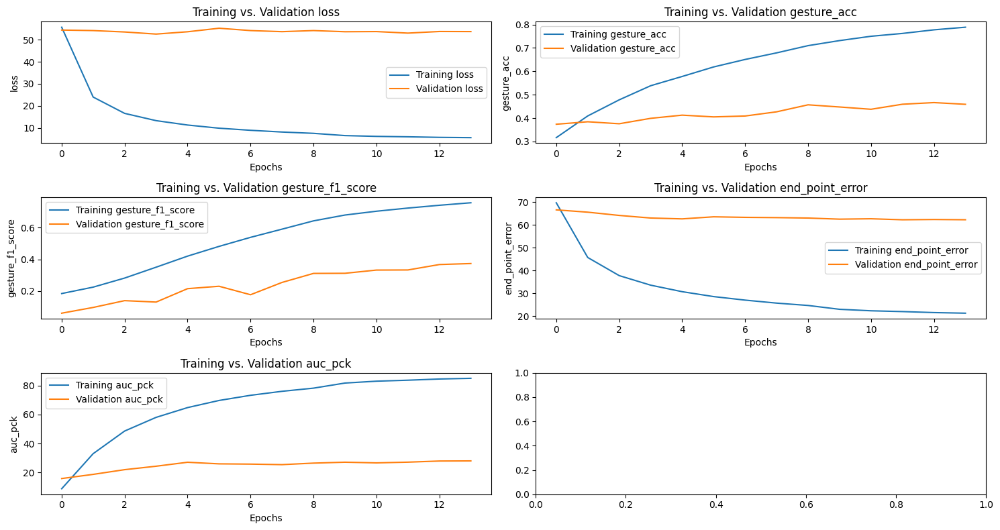

429/429 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.32218578
Gesture F1 Score:  0.057976991610412774
AucPCK :  [ 1.690346  6.076503 11.599272 17.471767 22.528233 28.743168 34.907104]
End point error  87.89824963770468
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3989796
Gesture F1 Score:  0.13432351870898104
AucPCK :  [ 3.994169  9.555393 15.058309 22.50729  31.304663 39.46793  48.323616]
End point error  63.01085873174289
**************************************************
Worst joints : 


{'Ring_3_y': 20.31260055758721,
 'Index_3_y': 20.307510154316212,
 'Middle_3_y': 18.495530049949647,
 'Pinky_3_y': 16.20754591893779,
 'Ring_3_z': 16.008803787567167,
 'Pinky_3_z': 15.851915235781304,
 'Ring_2_y': 15.4387239119301,
 'Middle_3_z': 14.967885467645132,
 'Index_1_z': 14.949041653262402,
 'Pinky_2_z': 14.577942842829446,
 'Middle_2_y': 14.352674985335318,
 'Ring_2_z': 14.267537707959043,
 'Index_3_z': 13.96652387587365,
 'Index_2_z': 13.946782662030712,
 'Index_2_y': 13.904809750942142,
 'Thumb_3_y': 13.721647541356926,
 'Pinky_2_y': 13.064870410634155,
 'Middle_1_z': 12.197211216676394,
 'Middle_2_z': 11.942564994191677,
 'Thumb_3_z': 11.26704401654886,
 'Ring_1_z': 9.773387915656452,
 'Pinky_1_y': 9.68341445162629,
 'Thumb_2_y': 9.679803572869325,
 'Pinky_1_z': 9.567862925637131,
 'Thumb_2_z': 9.202446667438242,
 'Index_0_z': 8.887127027436197,
 'Ring_1_y': 8.34333780012243,
 'Middle_0_z': 7.178798085351037,
 'Middle_1_y': 7.033079581223388,
 'Index_1_y': 6.84987946534528

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 15
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_val(x,val=15))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  49154
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0], [-0.1313590705394745, 1.962600946...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0], [-0.16874241828918457, 1.89520251...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0], [-0.20157326757907867, 1.88271176...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0], [-0.2151557356119156, 1.880742073...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0], [-0.267819344997406, 1.8629012107...","[[-0.14558112002368284, -0.14558112002368284, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
49149,1.680527e+12,"[[0.0, 0.0], [0.2664608359336853, 1.2513891458...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304
49150,1.680527e+12,"[[0.0, 0.0], [0.27352452278137207, 1.243718504...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304
49151,1.680527e+12,"[[0.0, 0.0], [0.28964972496032715, 1.234804511...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304
49152,1.680527e+12,"[[0.0, 0.0], [0.33679744601249695, 1.346733570...","[[-0.14558112002368284, -0.14558112002368284, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower15.h5')

Epoch 1/200
922/922 [==============================] - 13s 9ms/step - loss: 55.4495 - end_point_error: 70.5025 - auc_pck: 7.3961 - gesture_acc: 0.2929 - gesture_f1_score: 0.1584 - val_loss: 62.1753 - val_end_point_error: 67.9534 - val_auc_pck: 20.5846 - val_gesture_acc: 0.3106 - val_gesture_f1_score: 0.0529 - lr: 1.0000e-04
Epoch 2/200
922/922 [==============================] - 8s 8ms/step - loss: 25.5381 - end_point_error: 47.7400 - auc_pck: 28.3732 - gesture_acc: 0.3770 - gesture_f1_score: 0.1919 - val_loss: 56.9779 - val_end_point_error: 64.4075 - val_auc_pck: 24.5803 - val_gesture_acc: 0.3938 - val_gesture_f1_score: 0.0583 - lr: 1.0000e-04
Epoch 3/200
922/922 [==============================] - 8s 8ms/step - loss: 17.6738 - end_point_error: 39.3599 - auc_pck: 44.2389 - gesture_acc: 0.4571 - gesture_f1_score: 0.2401 - val_loss: 53.1614 - val_end_point_error: 61.3780 - val_auc_pck: 29.1168 - val_gesture_acc: 0.4437 - val_gesture_f1_score: 0.0443 - lr: 1.0000e-04
Epoch 4/200
922/922 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


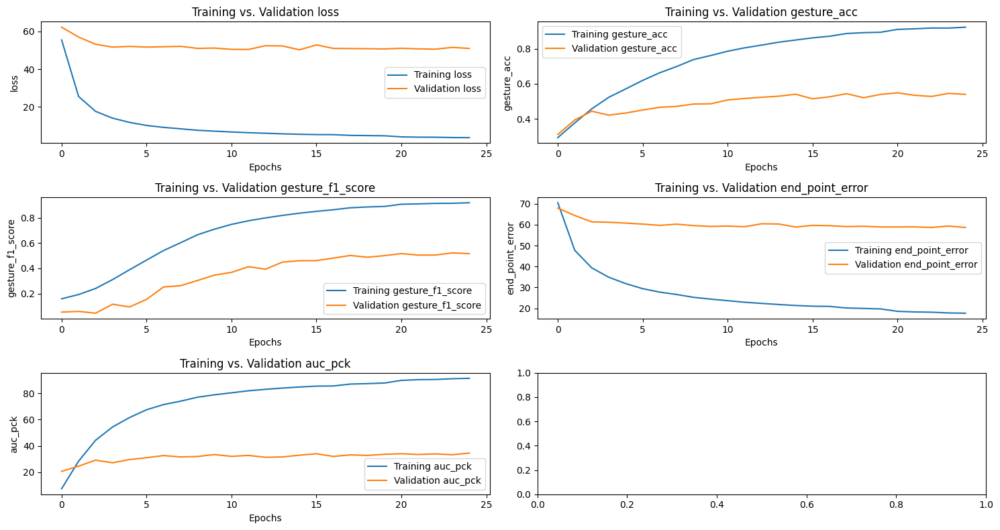

308/308 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.43333673
Gesture F1 Score:  0.3272851323089916
AucPCK :  [ 3.1628191  8.379945  14.25811   20.746466  27.458557  33.64182
 38.98098  ]
End point error  87.66900521908217
**************************************************
Validation Evaluation
Gesture Accuracy:  0.53994715
Gesture F1 Score:  0.4618308051070164
AucPCK :  [11.03883  18.408213 25.625128 32.57776  39.642204 47.997562 54.960358]
End point error  58.87582746895597
**************************************************
Worst joints : 


{'Ring_3_y': 20.303656012469578,
 'Index_3_y': 19.597534944323183,
 'Middle_3_y': 17.810822183356724,
 'Ring_3_z': 17.073323678130755,
 'Pinky_3_z': 16.587829647568128,
 'Pinky_3_y': 16.47359412482497,
 'Ring_2_y': 15.718689728840664,
 'Middle_3_z': 15.71002101679398,
 'Index_1_z': 15.590371379514943,
 'Pinky_2_z': 15.185079201148532,
 'Ring_2_z': 14.867921684940146,
 'Middle_2_y': 13.865237778281577,
 'Index_3_z': 13.67512451311308,
 'Index_2_z': 13.50979427585603,
 'Pinky_2_y': 13.2807647903684,
 'Index_2_y': 13.017915367822246,
 'Middle_1_z': 12.650145033513981,
 'Thumb_3_y': 12.38985849088292,
 'Middle_2_z': 11.950118959756482,
 'Thumb_3_z': 10.922218907143428,
 'Pinky_1_y': 10.01399858565508,
 'Ring_1_z': 9.893487768843782,
 'Pinky_1_z': 9.71532830196232,
 'Index_0_z': 9.562107726766984,
 'Thumb_2_z': 9.163566929004332,
 'Thumb_2_y': 8.881365548729425,
 'Ring_1_y': 8.561155468391071,
 'Middle_0_z': 7.7707810364717895,
 'Thumb_1_z': 7.079748857700374,
 'Thumb_0_z': 7.06336664455066

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 5
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_val(x,val=5))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  40762
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0], [-0.17972759902477264, 1.94852638...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0], [-0.19332967698574066, 1.94649302...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0], [-0.24606932699680328, 1.92807495...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0], [-0.3123517334461212, 1.910187125...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0], [-0.37292444705963135, 1.90347027...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
40757,1.680524e+12,"[[0.0, 0.0], [-0.8922566175460815, 1.634720206...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40758,1.680524e+12,"[[0.0, 0.0], [-0.9493180513381958, 1.748726248...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40759,1.680524e+12,"[[0.0, 0.0], [-0.9383652210235596, 1.757563352...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40760,1.680524e+12,"[[0.0, 0.0], [-0.9449666142463684, 1.756067395...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower5.h5')

Epoch 1/200
764/764 [==============================] - 11s 9ms/step - loss: 56.2806 - end_point_error: 70.8850 - auc_pck: 7.0166 - gesture_acc: 0.3186 - gesture_f1_score: 0.2059 - val_loss: 55.6571 - val_end_point_error: 68.3264 - val_auc_pck: 13.8030 - val_gesture_acc: 0.2353 - val_gesture_f1_score: 0.0124 - lr: 1.0000e-04
Epoch 2/200
764/764 [==============================] - 6s 8ms/step - loss: 25.8921 - end_point_error: 47.9813 - auc_pck: 28.5352 - gesture_acc: 0.3969 - gesture_f1_score: 0.2254 - val_loss: 49.3740 - val_end_point_error: 62.9348 - val_auc_pck: 21.8230 - val_gesture_acc: 0.2964 - val_gesture_f1_score: 0.0298 - lr: 1.0000e-04
Epoch 3/200
764/764 [==============================] - 6s 8ms/step - loss: 18.0854 - end_point_error: 39.8406 - auc_pck: 43.6512 - gesture_acc: 0.4887 - gesture_f1_score: 0.2969 - val_loss: 47.7679 - val_end_point_error: 61.1101 - val_auc_pck: 24.9260 - val_gesture_acc: 0.3337 - val_gesture_f1_score: 0.0668 - lr: 1.0000e-04
Epoch 4/200
764/764 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


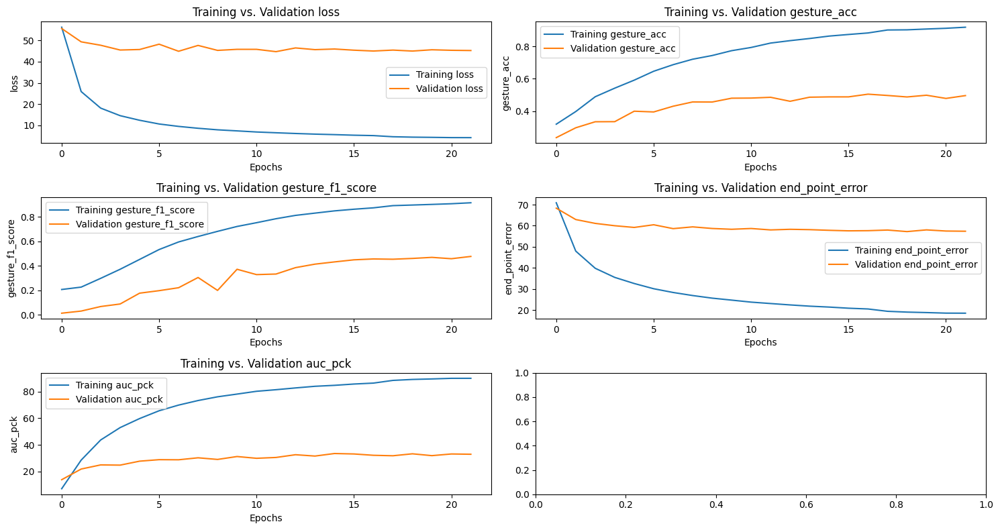

255/255 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.39955848
Gesture F1 Score:  0.23259413738760082
AucPCK :  [ 2.7839098  7.6894774 13.723326  19.462841  26.40422   33.517292
 39.686047 ]
End point error  85.644092678923
**************************************************
Validation Evaluation
Gesture Accuracy:  0.48503068
Gesture F1 Score:  0.33620451305096655
AucPCK :  [ 7.214724 13.79141  21.68098  30.25767  38.576687 47.349693 54.785275]
End point error  58.01525062905495
**************************************************
Worst joints : 


{'Index_3_y': 19.204832282455577,
 'Ring_3_y': 18.900095172990397,
 'Ring_3_z': 17.14430337816824,
 'Pinky_3_z': 16.92889136988878,
 'Middle_3_y': 16.14770087259099,
 'Index_1_z': 15.943785151867692,
 'Pinky_2_z': 15.672080936004408,
 'Middle_3_z': 15.552427233075832,
 'Pinky_3_y': 15.466526726385073,
 'Ring_2_z': 14.942436252149045,
 'Ring_2_y': 14.70674252113902,
 'Index_3_z': 13.816639213420554,
 'Index_2_z': 13.53526690821657,
 'Middle_2_y': 12.983311621428037,
 'Pinky_2_y': 12.771089116081331,
 'Index_2_y': 12.6965229890299,
 'Middle_1_z': 12.609312402834222,
 'Middle_2_z': 12.067200481197704,
 'Thumb_3_y': 11.865425044624025,
 'Thumb_3_z': 10.978924193583923,
 'Index_0_z': 9.971172838619804,
 'Pinky_1_z': 9.796794224764366,
 'Pinky_1_y': 9.484056438364625,
 'Ring_1_z': 9.440315254438024,
 'Thumb_2_z': 9.28370115803531,
 'Thumb_2_y': 8.652121645779072,
 'Ring_1_y': 7.9954532579760205,
 'Middle_0_z': 7.907981205988877,
 'Thumb_0_z': 6.997794349207685,
 'Thumb_1_z': 6.88702373479311

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, norm_skel='joint', filter_cap_img = lambda x : filter_val(x,val=0))
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  36943
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0], [-0.24507297575473785, 1.96799981...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0], [-0.31090354919433594, 1.94978010...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0], [-0.37106332182884216, 1.94293880...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0], [-0.4027317464351654, 1.946861028...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0], [-0.41742315888404846, 1.91509926...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
...,...,...,...,...,...,...,...
36938,1.680524e+12,"[[0.0, 0.0], [-0.8986856937408447, 1.683630466...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36939,1.680524e+12,"[[0.0, 0.0], [-0.8962037563323975, 1.687296748...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36940,1.680524e+12,"[[0.0, 0.0], [-0.8636006712913513, 1.697484850...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36941,1.680524e+12,"[[0.0, 0.0], [-0.8830949664115906, 1.670310616...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower.h5')

Epoch 1/200
693/693 [==============================] - 11s 9ms/step - loss: 54.3258 - end_point_error: 69.3796 - auc_pck: 8.0282 - gesture_acc: 0.3175 - gesture_f1_score: 0.1835 - val_loss: 53.4408 - val_end_point_error: 66.0558 - val_auc_pck: 17.0389 - val_gesture_acc: 0.2652 - val_gesture_f1_score: 0.0265 - lr: 1.0000e-04
Epoch 2/200
693/693 [==============================] - 6s 8ms/step - loss: 26.1540 - end_point_error: 48.4271 - auc_pck: 27.1832 - gesture_acc: 0.4091 - gesture_f1_score: 0.2473 - val_loss: 54.9482 - val_end_point_error: 65.0869 - val_auc_pck: 23.1611 - val_gesture_acc: 0.3532 - val_gesture_f1_score: 0.0491 - lr: 1.0000e-04
Epoch 3/200
693/693 [==============================] - 6s 8ms/step - loss: 18.1031 - end_point_error: 40.0677 - auc_pck: 42.6300 - gesture_acc: 0.4773 - gesture_f1_score: 0.3073 - val_loss: 50.3462 - val_end_point_error: 62.5222 - val_auc_pck: 24.8554 - val_gesture_acc: 0.4237 - val_gesture_f1_score: 0.0861 - lr: 1.0000e-04
Epoch 4/200
693/693 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


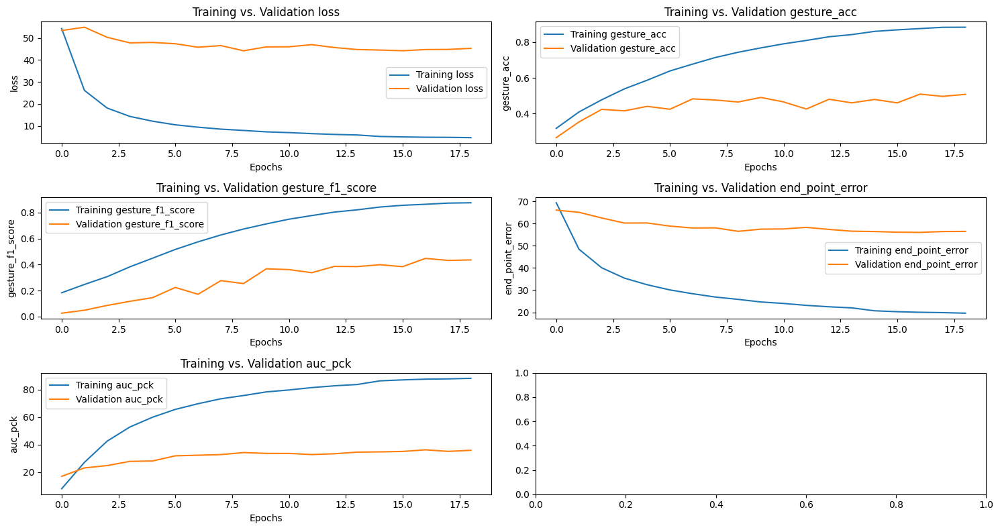

231/231 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.39829478
Gesture F1 Score:  0.1309823416989627
AucPCK :  [ 4.060089   7.7412367 15.306537  22.519962  29.286777  35.241573
 40.8445   ]
End point error  82.93431465053239
**************************************************
Validation Evaluation
Gesture Accuracy:  0.46493366
Gesture F1 Score:  0.25792627371543736
AucPCK :  [ 7.8797727 16.274033  25.73788   35.228813  44.7062    52.071487
 58.285946 ]
End point error  56.51443564564865
**************************************************
Worst joints : 


{'Ring_3_y': 18.50056030720304,
 'Index_3_y': 18.37114605941785,
 'Pinky_3_z': 16.926559041852524,
 'Ring_3_z': 16.786569944563183,
 'Index_1_z': 15.900369125033635,
 'Middle_3_y': 15.481211452249067,
 'Pinky_2_z': 15.33465878474657,
 'Pinky_3_y': 15.113983115737668,
 'Middle_3_z': 14.703766649507573,
 'Ring_2_z': 14.61788314956333,
 'Ring_2_y': 13.919811468989947,
 'Index_3_z': 13.10150719469736,
 'Middle_1_z': 12.696243926231242,
 'Index_2_z': 12.64558369308463,
 'Pinky_2_y': 12.230955028145925,
 'Middle_2_y': 12.041923513347523,
 'Index_2_y': 11.74701871882153,
 'Middle_2_z': 11.694877466646039,
 'Thumb_3_y': 10.91340568863992,
 'Index_0_z': 10.38157443827827,
 'Thumb_3_z': 9.80975647296205,
 'Ring_1_z': 9.742785780940862,
 'Pinky_1_z': 9.518039083538607,
 'Pinky_1_y': 8.855565308486007,
 'Thumb_2_z': 8.435915281577005,
 'Middle_0_z': 8.244714486626586,
 'Thumb_2_y': 8.133818534305105,
 'Ring_1_y': 7.472511389536894,
 'Thumb_0_z': 6.6979104883541964,
 'Thumb_1_z': 6.694621635129316,

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**Try with reg mode, 80/10/10, then reg on 80/10/10**

In [ ]:
model = create_skeleton_gesture_reg2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower_reg.h5')

Epoch 1/200
924/924 [==============================] - 31s 17ms/step - loss: 51.4099 - end_point_error: 65.4081 - auc_pck: 13.8742 - gesture_acc: 0.2793 - gesture_f1_score: 0.0185 - val_loss: 81.6885 - val_end_point_error: 74.1078 - val_auc_pck: 23.6000 - val_gesture_acc: 0.3056 - val_gesture_f1_score: 0.0151 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 15s 16ms/step - loss: 40.1243 - end_point_error: 57.2474 - auc_pck: 22.5025 - gesture_acc: 0.3305 - gesture_f1_score: 0.0529 - val_loss: 72.3189 - val_end_point_error: 69.6223 - val_auc_pck: 24.7614 - val_gesture_acc: 0.2987 - val_gesture_f1_score: 0.0150 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 15s 16ms/step - loss: 30.6257 - end_point_error: 49.8763 - auc_pck: 30.3190 - gesture_acc: 0.3609 - gesture_f1_score: 0.0871 - val_loss: 66.6521 - val_end_point_error: 65.9702 - val_auc_pck: 29.9488 - val_gesture_acc: 0.3838 - val_gesture_f1_score: 0.0410 - lr: 1.0000e-04
Epoch 4/200
924/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


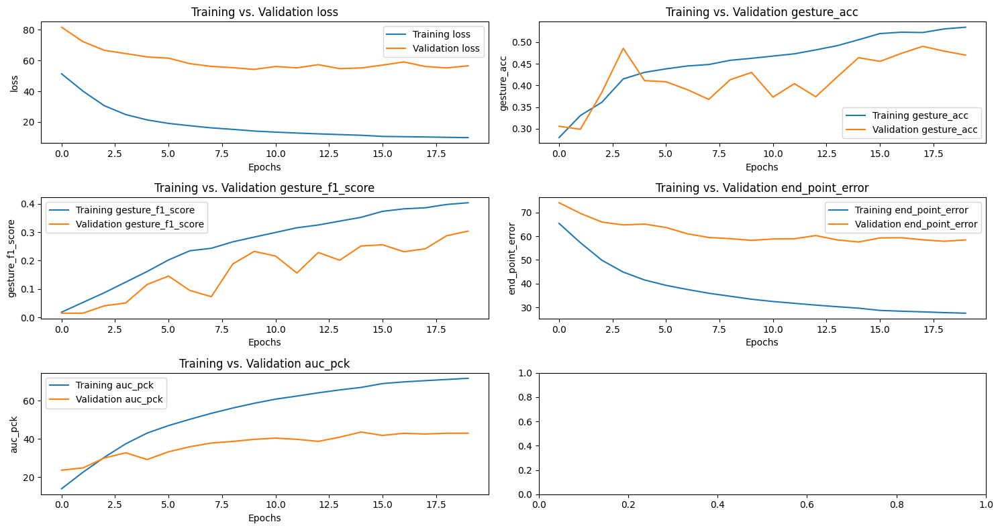

116/116 [==============================] - 0s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.37354296
Gesture F1 Score:  0.16857686534323327
AucPCK :  [ 3.9306045 10.788832  18.487396  25.210085  32.556248  39.44158
 44.537815 ]
End point error  85.3263706537309
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4277582
Gesture F1 Score:  0.2362868902024986
AucPCK :  [10.951477 21.713202 35.131474 44.40228  49.850906 55.164    61.15478 ]
End point error  58.189422048458646
**************************************************
Worst joints : 


{'Ring_3_z': 20.4390787272441,
 'Index_3_z': 19.709088984910803,
 'Middle_3_z': 17.198958911704366,
 'Pinky_3_z': 16.25965951537576,
 'Ring_2_z': 15.86055328468932,
 'Ring_3_y': 15.221499145196246,
 'Pinky_3_y': 15.142288217259305,
 'Index_3_y': 14.476902300308245,
 'Index_1_y': 14.331678954105934,
 'Middle_3_y': 14.221310580848774,
 'Middle_2_z': 13.934307717452084,
 'Pinky_2_y': 13.774267269982966,
 'Pinky_2_z': 13.618358156952716,
 'Index_2_y': 13.295103110752699,
 'Ring_2_y': 13.206963616538559,
 'Index_2_z': 13.20342492344379,
 'Thumb_3_z': 12.223981818262267,
 'Middle_1_y': 11.703872172862384,
 'Thumb_3_y': 11.489637103701197,
 'Middle_2_y': 11.18641295651259,
 'Pinky_1_z': 9.952634216332335,
 'Thumb_2_y': 9.355800991239875,
 'Pinky_1_y': 9.22454332353501,
 'Ring_1_y': 9.125377351008687,
 'Thumb_2_z': 8.911546426499367,
 'Index_0_y': 8.727143507598123,
 'Ring_1_z': 8.686691480464464,
 'Middle_0_y': 7.0463117751645346,
 'Middle_1_z': 7.037257586525685,
 'Thumb_0_y': 6.759046420794

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower80.h5')

Epoch 1/200
924/924 [==============================] - 12s 8ms/step - loss: 51.1968 - end_point_error: 67.4125 - auc_pck: 9.1519 - gesture_acc: 0.3391 - gesture_f1_score: 0.1953 - val_loss: 66.0863 - val_end_point_error: 69.9729 - val_auc_pck: 18.3575 - val_gesture_acc: 0.4614 - val_gesture_f1_score: 0.1450 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 7s 7ms/step - loss: 23.3380 - end_point_error: 45.5425 - auc_pck: 32.3681 - gesture_acc: 0.4312 - gesture_f1_score: 0.2397 - val_loss: 59.8658 - val_end_point_error: 65.1877 - val_auc_pck: 24.8580 - val_gesture_acc: 0.4297 - val_gesture_f1_score: 0.1133 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 7s 8ms/step - loss: 16.7461 - end_point_error: 38.3560 - auc_pck: 46.5046 - gesture_acc: 0.5053 - gesture_f1_score: 0.3179 - val_loss: 59.4773 - val_end_point_error: 63.7830 - val_auc_pck: 27.8180 - val_gesture_acc: 0.4304 - val_gesture_f1_score: 0.0595 - lr: 1.0000e-04
Epoch 4/200
924/924 [=

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


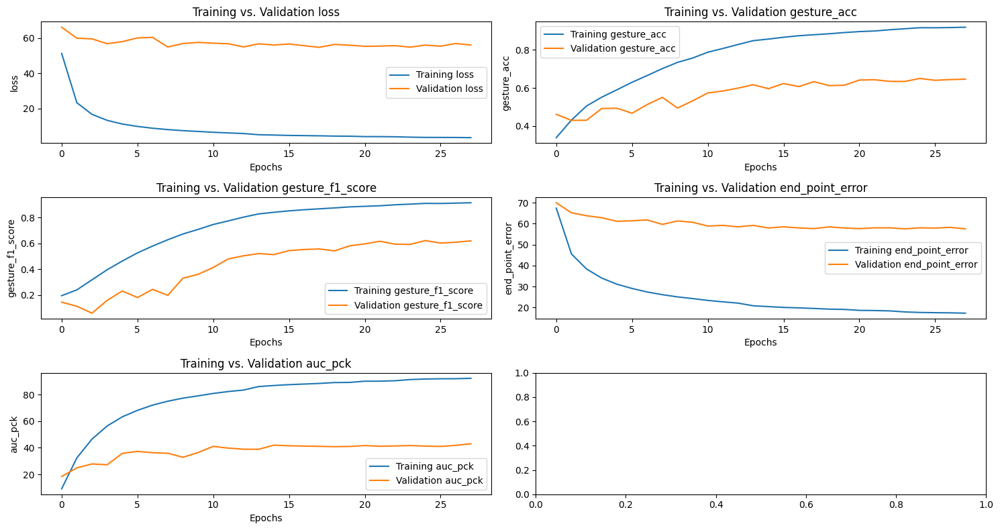

116/116 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.48983464
Gesture F1 Score:  0.4245410816930859
AucPCK :  [ 4.9878016  9.867172  16.26457   21.25237   27.188938  32.52914
 37.67959  ]
End point error  88.54103971106392
**************************************************
Validation Evaluation
Gesture Accuracy:  0.63404715
Gesture F1 Score:  0.5595023256864231
AucPCK :  [17.565737 24.423964 33.233936 42.99268  50.880997 57.061535 62.239086]
End point error  57.502388169391764
**************************************************
Worst joints : 


{'Ring_3_z': 21.06298389008397,
 'Index_3_z': 20.324348879631252,
 'Middle_3_z': 17.591470446870964,
 'Ring_3_y': 16.80881454610328,
 'Pinky_3_z': 16.64196144371226,
 'Pinky_3_y': 16.624727745743,
 'Index_1_y': 16.406143344719464,
 'Ring_2_z': 16.35648034811457,
 'Pinky_2_y': 15.395212287767428,
 'Middle_3_y': 15.235332737403247,
 'Ring_2_y': 14.64204040590998,
 'Index_3_y': 14.23242022542165,
 'Middle_2_z': 14.125494291953077,
 'Pinky_2_z': 13.902212279415028,
 'Index_2_z': 13.509244288671567,
 'Index_2_y': 13.014939437398537,
 'Middle_1_y': 12.937397767821851,
 'Middle_2_y': 11.947049810377486,
 'Thumb_3_z': 11.842066902642763,
 'Thumb_3_y': 10.807429368553816,
 'Pinky_1_y': 9.873445037239263,
 'Pinky_1_z': 9.848487154680253,
 'Ring_1_y': 9.841122033347867,
 'Index_0_y': 9.819190339960707,
 'Thumb_2_y': 8.998204779394065,
 'Thumb_2_z': 8.649748466395797,
 'Ring_1_z': 8.596178050138477,
 'Middle_0_y': 7.96651907453035,
 'Middle_1_z': 7.374515421331246,
 'Thumb_0_y': 6.878925747464152,

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

try with deeper model with regularization on 80/10/10

In [ ]:
model = create_skeleton_gesture_reg2d_model(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/filter_cap_img/mean_lower80_reg.h5')

Epoch 1/200
924/924 [==============================] - 20s 16ms/step - loss: 51.8161 - end_point_error: 65.6446 - auc_pck: 13.6972 - gesture_acc: 0.2777 - gesture_f1_score: 0.0271 - val_loss: 80.0515 - val_end_point_error: 73.9860 - val_auc_pck: 22.7148 - val_gesture_acc: 0.3344 - val_gesture_f1_score: 0.0151 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 15s 16ms/step - loss: 40.0219 - end_point_error: 57.1098 - auc_pck: 22.8887 - gesture_acc: 0.3228 - gesture_f1_score: 0.0494 - val_loss: 74.6849 - val_end_point_error: 70.9481 - val_auc_pck: 24.7648 - val_gesture_acc: 0.3754 - val_gesture_f1_score: 0.0159 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 15s 16ms/step - loss: 31.0944 - end_point_error: 50.2849 - auc_pck: 29.7231 - gesture_acc: 0.3445 - gesture_f1_score: 0.0824 - val_loss: 65.7323 - val_end_point_error: 66.5204 - val_auc_pck: 26.0635 - val_gesture_acc: 0.4212 - val_gesture_f1_score: 0.0342 - lr: 1.0000e-04
Epoch 4/200
924/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


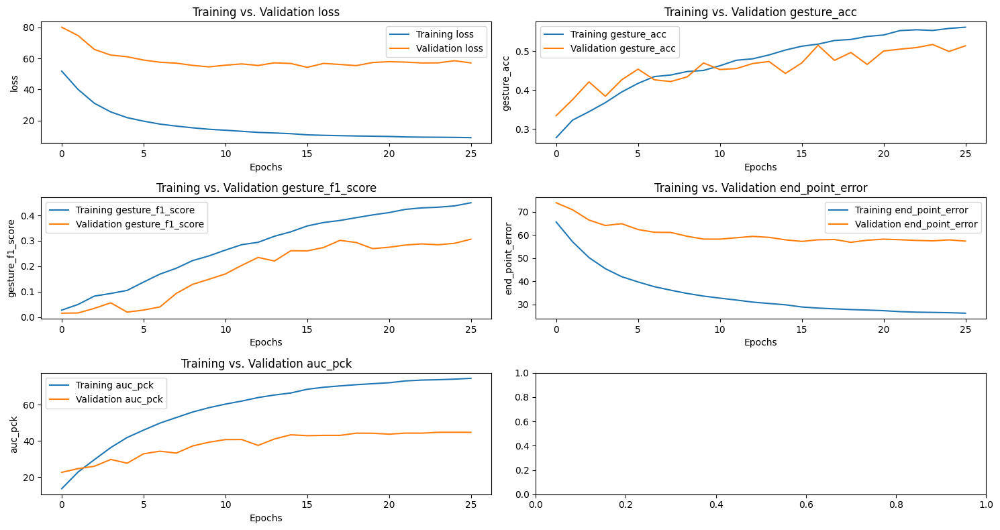

116/116 [==============================] - 0s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.45269722
Gesture F1 Score:  0.2891719405535446
AucPCK :  [ 3.7950664  8.457577  15.613988  23.881811  31.146652  38.68257
 44.26674  ]
End point error  86.30677935424218
**************************************************
Validation Evaluation
Gesture Accuracy:  0.46923286
Gesture F1 Score:  0.2618795854195621
AucPCK :  [15.288695 26.51125  38.33017  46.787746 52.317703 58.308483 63.757114]
End point error  57.19477999458449
**************************************************
Worst joints : 


{'Ring_3_z': 20.930047876585732,
 'Index_3_z': 19.197619209774114,
 'Middle_3_z': 18.13675679046091,
 'Pinky_3_z': 16.639508018903914,
 'Ring_2_z': 16.39789096390872,
 'Pinky_3_y': 15.45942269531454,
 'Ring_3_y': 15.356061485942526,
 'Middle_2_z': 14.547131861704571,
 'Pinky_2_y': 14.524356828516899,
 'Middle_3_y': 14.344787316994314,
 'Index_1_y': 14.314041237573631,
 'Index_3_y': 14.153549789931162,
 'Pinky_2_z': 13.808524968411959,
 'Ring_2_y': 13.498983615362345,
 'Thumb_3_z': 13.09833257875072,
 'Index_2_z': 13.087997223348317,
 'Index_2_y': 12.42892244869557,
 'Thumb_3_y': 11.706252105369773,
 'Middle_1_y': 11.639285087776754,
 'Middle_2_y': 11.315916271503585,
 'Pinky_1_y': 9.838845619122672,
 'Pinky_1_z': 9.621563817737602,
 'Thumb_2_y': 9.538327887207757,
 'Thumb_2_z': 9.467004821139378,
 'Ring_1_y': 9.45175390314758,
 'Index_0_y': 8.549404792393254,
 'Ring_1_z': 8.426377377979465,
 'Middle_1_z': 7.038716973221027,
 'Middle_0_y': 6.943267113179528,
 'Thumb_1_y': 6.794359736467

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

## 3d Models (alwayse use joint normalization)

### Keeping wrist

base 3d model

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint')
chili_data

Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965329342540703, 1.9027405870399752, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006504695151888, 1.9187705270010709, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7039149014654771, 1.9252372815573264, 0.76...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7089235671027683, 1.9150542333662095, 0.74...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066690632599103, 1.8860879012098815, 0.73...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.3153943945499922, -0.07197214812135938, 0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210017653788158, -0.050239470526614594, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.30962253455480937, -0.14323042079736256, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.3238865162425982, -0.14073655423866607, 1...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/base.h5')

Epoch 1/200
1518/1518 [==============================] - 18s 9ms/step - loss: 147.2792 - end_point_error: 114.7754 - auc_pck: 0.2118 - gesture_acc: 0.3078 - gesture_f1_score: 0.1639 - val_loss: 169.7555 - val_end_point_error: 117.8128 - val_auc_pck: 1.6343 - val_gesture_acc: 0.3322 - val_gesture_f1_score: 0.0700 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 12s 8ms/step - loss: 65.8765 - end_point_error: 76.4967 - auc_pck: 4.0669 - gesture_acc: 0.3982 - gesture_f1_score: 0.2143 - val_loss: 166.7879 - val_end_point_error: 116.1934 - val_auc_pck: 2.3898 - val_gesture_acc: 0.3659 - val_gesture_f1_score: 0.0907 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 12s 8ms/step - loss: 45.7850 - end_point_error: 63.2626 - auc_pck: 11.7796 - gesture_acc: 0.4504 - gesture_f1_score: 0.2728 - val_loss: 163.3733 - val_end_point_error: 113.5165 - val_auc_pck: 3.8347 - val_gesture_acc: 0.4048 - val_gesture_f1_score: 0.1921 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


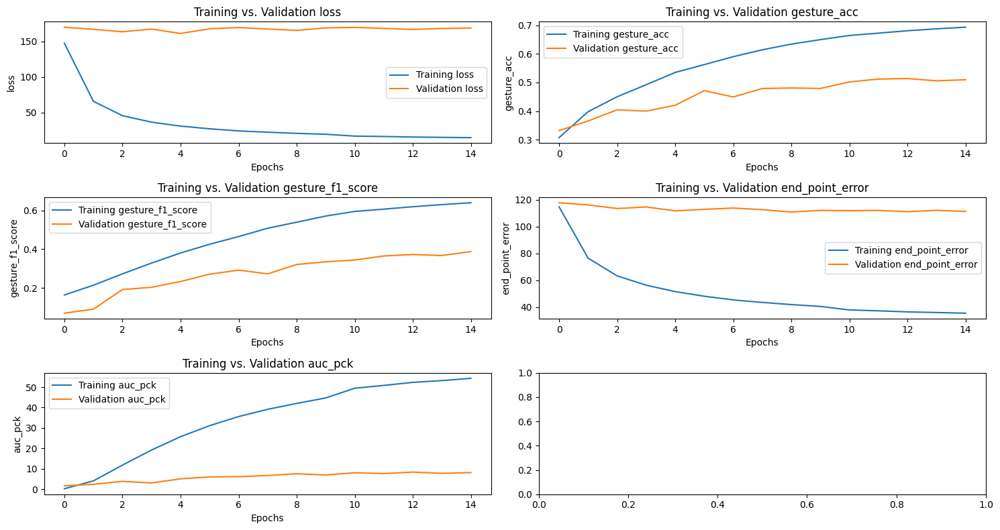

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.33034778
Gesture F1 Score:  0.1311664835867563
AucPCK :  [0.         0.03088517 0.28414357 0.9327321  2.0693064  3.860646
 6.05967   ]
End point error  150.90173484358044
**************************************************
Validation Evaluation
Gesture Accuracy:  0.42046437
Gesture F1 Score:  0.2380138404388341
AucPCK :  [ 0.04322588  0.4693096   1.5870075   3.1863651   5.903421    9.892553
 14.301594  ]
End point error  111.88655063022489
**************************************************
Worst joints : 


{'wrist_x': 45.56555273430113,
 'wrist_z': 32.76462118672667,
 'Pinky_2_x': 26.055094689865737,
 'Pinky_1_x': 24.331791824359023,
 'Thumb_3_x': 22.901330768207167,
 'Ring_2_x': 22.897235671926992,
 'Index_3_x': 21.780013900106702,
 'Middle_2_x': 21.487917936773055,
 'Pinky_3_x': 21.472711266598573,
 'Middle_3_x': 21.472251268495654,
 'Ring_3_z': 21.214942873062977,
 'Ring_1_x': 21.182373411526562,
 'Index_3_z': 21.11301268168244,
 'Index_2_x': 20.614458069870913,
 'Ring_3_x': 20.521594220202406,
 'Middle_3_z': 20.4100020490517,
 'Thumb_2_x': 18.470632133932018,
 'Pinky_3_z': 16.772425443119065,
 'Middle_1_x': 16.75839774033654,
 'Ring_2_z': 15.999463723233351,
 'Ring_3_y': 15.616336612977191,
 'Pinky_3_y': 15.56348076438962,
 'Middle_2_z': 15.003050575028448,
 'Index_1_x': 14.793462124739607,
 'Pinky_2_y': 14.528875868062391,
 'Middle_3_y': 14.282618923470263,
 'Index_2_z': 14.218749408180225,
 'Ring_2_y': 14.064183074055473,
 'Index_1_y': 14.031585821620903,
 'Index_2_y': 13.961775428

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80

In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/base_80.h5')

Epoch 1/200
2024/2024 [==============================] - 20s 8ms/step - loss: 143.9114 - end_point_error: 112.2830 - auc_pck: 0.4839 - gesture_acc: 0.3083 - gesture_f1_score: 0.1637 - val_loss: 222.7351 - val_end_point_error: 134.2083 - val_auc_pck: 1.3850 - val_gesture_acc: 0.3396 - val_gesture_f1_score: 0.0903 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 15s 8ms/step - loss: 62.1742 - end_point_error: 73.7542 - auc_pck: 5.9145 - gesture_acc: 0.4194 - gesture_f1_score: 0.2367 - val_loss: 229.6086 - val_end_point_error: 133.1134 - val_auc_pck: 3.4923 - val_gesture_acc: 0.4129 - val_gesture_f1_score: 0.1173 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 15s 8ms/step - loss: 43.7185 - end_point_error: 61.4199 - auc_pck: 14.3081 - gesture_acc: 0.4771 - gesture_f1_score: 0.3028 - val_loss: 231.6167 - val_end_point_error: 130.9259 - val_auc_pck: 5.9758 - val_gesture_acc: 0.4610 - val_gesture_f1_score: 0.1817 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


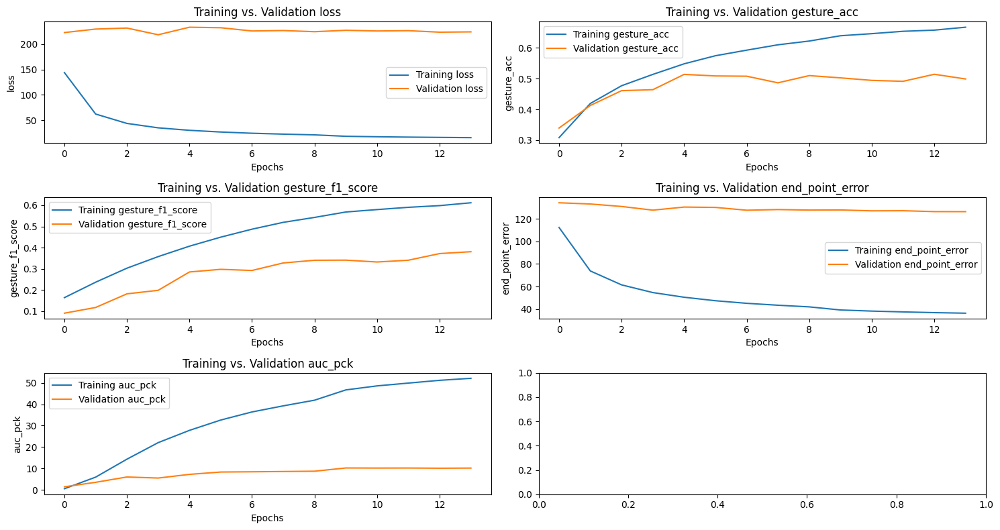

254/254 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.38861448
Gesture F1 Score:  0.08983194669146842
AucPCK :  [0.         0.04939491 0.17288218 0.7779699  2.0498888  3.6058285
 5.692764  ]
End point error  154.34089192874842
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4659175
Gesture F1 Score:  0.20308957065730868
AucPCK :  [ 0.02469745  0.43220547  1.2472215   4.087429    7.47098    10.731045
 14.509755  ]
End point error  127.37757344141899
**************************************************
Worst joints : 


{'wrist_x': 47.545550325603,
 'wrist_z': 33.36267856589836,
 'Pinky_2_x': 26.03300873559482,
 'Pinky_1_x': 24.219175699457654,
 'Thumb_3_x': 23.66956635846376,
 'Ring_2_x': 23.197859709351622,
 'Middle_3_x': 22.726735583366118,
 'Index_3_x': 22.131420909262413,
 'Ring_3_x': 21.79585701387247,
 'Middle_2_x': 21.75923976060992,
 'Pinky_3_x': 21.541029311998937,
 'Index_2_x': 21.191635143982104,
 'Middle_3_z': 20.978099636444483,
 'Ring_3_z': 20.928020245625607,
 'Ring_1_x': 20.784526357478878,
 'Index_3_z': 20.775079141608764,
 'Thumb_2_x': 19.2596219157942,
 'Middle_1_x': 16.570003532482712,
 'Pinky_3_z': 16.299745400247865,
 'Pinky_3_y': 16.112070857842735,
 'Ring_3_y': 15.928783880421745,
 'Ring_2_z': 15.599227301299324,
 'Pinky_2_y': 15.117279388977833,
 'Middle_2_z': 14.98014181489383,
 'Index_1_x': 14.979468847661936,
 'Index_1_y': 14.798683369167717,
 'Index_2_y': 14.7567495440182,
 'Index_3_y': 14.675848770207276,
 'Middle_3_y': 14.446965690582104,
 'Ring_2_y': 14.291085432087979

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base reg

In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/base_reg.h5')

Epoch 1/200
1518/1518 [==============================] - 40s 23ms/step - loss: 154.7676 - end_point_error: 115.2757 - auc_pck: 0.6463 - gesture_acc: 0.2886 - gesture_f1_score: 0.0509 - val_loss: 172.4942 - val_end_point_error: 120.0220 - val_auc_pck: 1.3481 - val_gesture_acc: 0.2533 - val_gesture_f1_score: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 33s 22ms/step - loss: 110.7775 - end_point_error: 96.5373 - auc_pck: 2.1823 - gesture_acc: 0.3349 - gesture_f1_score: 0.0755 - val_loss: 166.6597 - val_end_point_error: 115.7014 - val_auc_pck: 1.9786 - val_gesture_acc: 0.3127 - val_gesture_f1_score: 0.0628 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 33s 22ms/step - loss: 84.4401 - end_point_error: 84.0801 - auc_pck: 4.7336 - gesture_acc: 0.3883 - gesture_f1_score: 0.1435 - val_loss: 160.6195 - val_end_point_error: 111.2383 - val_auc_pck: 3.6093 - val_gesture_acc: 0.3630 - val_gesture_f1_score: 0.0953 - lr: 1.0000e-04
Epo

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


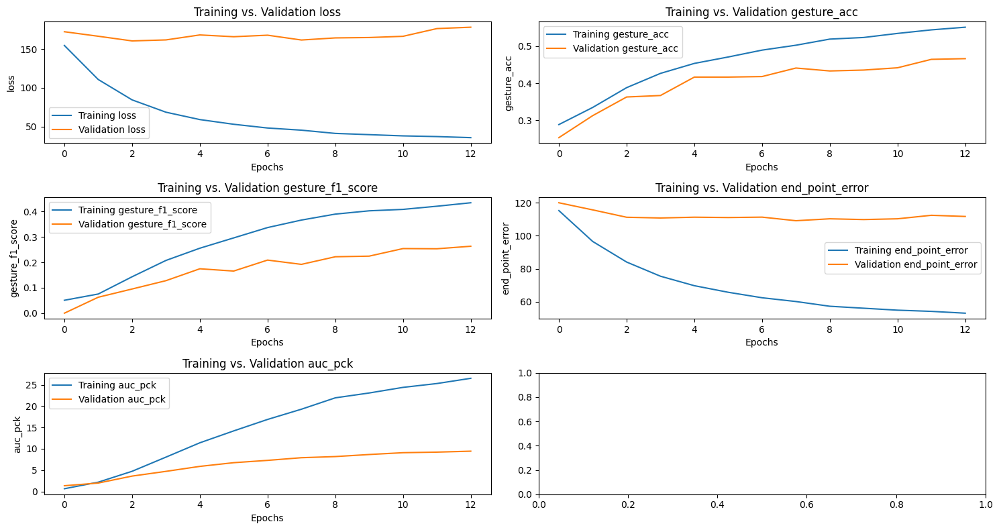

507/507 [==============================] - 2s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.3486318
Gesture F1 Score:  0.10167184657457923
AucPCK :  [0.         0.04941627 0.22237322 0.63005745 1.2045215  2.6437705
 4.6204214 ]
End point error  148.73470047356312
**************************************************
Validation Evaluation
Gesture Accuracy:  0.36278868
Gesture F1 Score:  0.0979970424786203
AucPCK :  [ 0.          0.01235025  0.3272817   1.568482    3.8285785   7.286649
 12.195875  ]
End point error  111.32451786397493
**************************************************
Worst joints : 


{'wrist_x': 42.35686765908105,
 'wrist_z': 34.730655322713794,
 'Pinky_2_x': 26.92132818577902,
 'Pinky_1_x': 25.002692285206894,
 'Ring_2_x': 22.78891532886522,
 'Thumb_3_x': 22.49477385105784,
 'Pinky_3_x': 21.866672973475392,
 'Ring_1_x': 21.388244073283676,
 'Ring_3_z': 21.32410421294225,
 'Index_3_x': 20.957780082431384,
 'Middle_3_x': 20.70540788164202,
 'Index_3_z': 20.67326257612641,
 'Middle_2_x': 20.61084256311831,
 'Index_2_x': 19.990557151911126,
 'Middle_3_z': 19.892039209462784,
 'Ring_3_x': 19.632601701856434,
 'Thumb_2_x': 17.97893497130871,
 'Pinky_3_z': 16.796603360914506,
 'Middle_1_x': 16.780065639546013,
 'Ring_2_z': 16.036570052755188,
 'Pinky_3_y': 15.988718483396479,
 'Ring_3_y': 15.85324271336083,
 'Pinky_2_y': 14.940498584097268,
 'Middle_2_z': 14.755609684044218,
 'Index_1_x': 14.38311146882311,
 'Ring_2_y': 14.354641652103155,
 'Middle_3_y': 14.258658113786392,
 'Index_1_y': 14.204920615123392,
 'Index_2_z': 13.960022805496934,
 'Thumb_3_z': 13.9062556633210

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80 reg


In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/base_80_reg.h5')

Epoch 1/200
2024/2024 [==============================] - 48s 21ms/step - loss: 160.2607 - end_point_error: 117.2511 - auc_pck: 0.5406 - gesture_acc: 0.2873 - gesture_f1_score: 0.0450 - val_loss: 235.7718 - val_end_point_error: 138.9749 - val_auc_pck: 0.7663 - val_gesture_acc: 0.2874 - val_gesture_f1_score: 0.0211 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 42s 21ms/step - loss: 113.1268 - end_point_error: 97.5002 - auc_pck: 2.2228 - gesture_acc: 0.3537 - gesture_f1_score: 0.1003 - val_loss: 223.3664 - val_end_point_error: 132.0583 - val_auc_pck: 1.7101 - val_gesture_acc: 0.4262 - val_gesture_f1_score: 0.0676 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 42s 21ms/step - loss: 83.1673 - end_point_error: 83.5193 - auc_pck: 5.0532 - gesture_acc: 0.3934 - gesture_f1_score: 0.1843 - val_loss: 219.9031 - val_end_point_error: 128.0439 - val_auc_pck: 3.5714 - val_gesture_acc: 0.4438 - val_gesture_f1_score: 0.1705 - lr: 1.0000e-04
Epoch 4

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


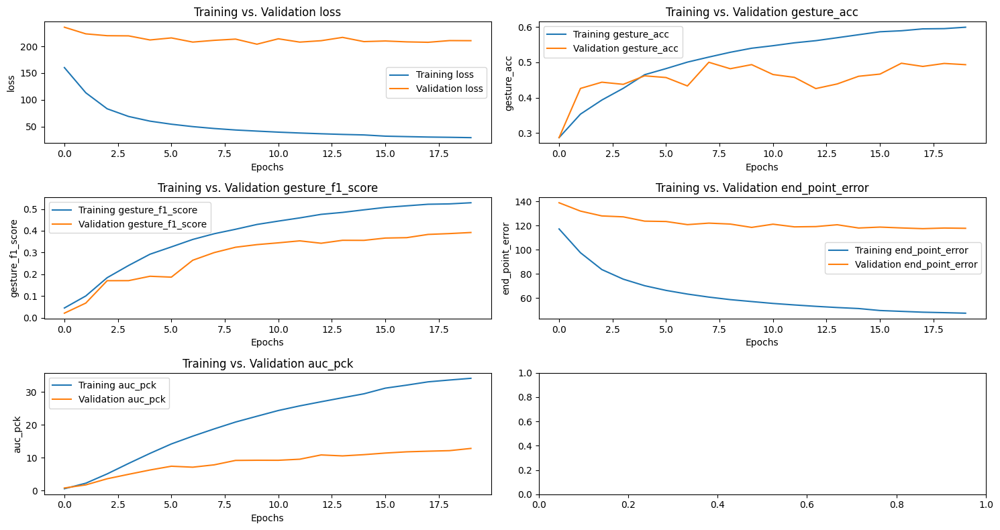

254/254 [==============================] - 1s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.40664363
Gesture F1 Score:  0.19691342658951555
AucPCK :  [0.04939491 0.4816004  0.95085204 2.3709557  3.8281057  6.087923
 8.656459  ]
End point error  152.29363167999517
**************************************************
Validation Evaluation
Gesture Accuracy:  0.495184
Gesture F1 Score:  0.3416251694020641
AucPCK :  [ 0.          0.55569273  3.3959002   8.372438   13.102001   17.522844
 21.684366  ]
End point error  118.22409322377612
**************************************************
Worst joints : 


{'wrist_x': 47.02453600624888,
 'wrist_z': 32.92196887382732,
 'Pinky_2_x': 25.62240499755387,
 'Pinky_1_x': 23.708142660715367,
 'Thumb_3_x': 23.043014620513695,
 'Ring_2_x': 22.937427634507852,
 'Middle_3_x': 22.530014098568298,
 'Index_3_x': 21.861637011750062,
 'Ring_3_x': 21.81625045875898,
 'Middle_2_x': 21.755049918376972,
 'Pinky_3_x': 21.62176503248143,
 'Index_2_x': 21.053636424543008,
 'Ring_1_x': 20.578613436476303,
 'Index_3_z': 20.464427500271754,
 'Ring_3_z': 19.709598969690738,
 'Middle_3_z': 19.62558344096502,
 'Thumb_2_x': 18.368768719943304,
 'Middle_1_x': 16.736615225333118,
 'Pinky_3_y': 16.04777049285076,
 'Ring_3_y': 16.03149373631288,
 'Pinky_3_z': 15.414462656597394,
 'Index_1_x': 15.204735091066746,
 'Thumb_3_z': 14.791762565064772,
 'Ring_2_z': 14.784170619504193,
 'Pinky_2_y': 14.746531874227633,
 'Index_3_y': 14.634651543025793,
 'Middle_3_y': 14.481049460987647,
 'Index_2_y': 14.417972103184086,
 'Middle_2_z': 14.230139675507269,
 'Ring_2_y': 14.1595803896

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

try some filterings of capactive images

In [ ]:
# try with cap_img = mean +- 2std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=2))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  78910
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.7117153526836455, 1.8843865479130026, 0.77...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7158693681056943, 1.9002758781810496, 0.76...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7191627219705117, 1.9066859083593357, 0.75...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7242157629238372, 1.8965921827286234, 0.74...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7219412848347883, 1.867879934310796, 0.726...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
78905,1.680527e+12,"[[-0.30917735697656135, -0.07300461572499328, ...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78906,1.680527e+12,"[[-0.314834407474716, -0.051462570480285116, 0...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78907,1.680527e+12,"[[-0.303354359986031, -0.14363783279426992, 0....","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78908,1.680527e+12,"[[-0.3177447163893907, -0.14116584166443805, 1...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_2_std.h5')

Epoch 1/200
1480/1480 [==============================] - 17s 9ms/step - loss: 148.1313 - end_point_error: 114.8545 - auc_pck: 0.2015 - gesture_acc: 0.2979 - gesture_f1_score: 0.1585 - val_loss: 171.7503 - val_end_point_error: 118.8753 - val_auc_pck: 1.5354 - val_gesture_acc: 0.3331 - val_gesture_f1_score: 0.0717 - lr: 1.0000e-04
Epoch 2/200
1480/1480 [==============================] - 12s 8ms/step - loss: 68.8011 - end_point_error: 78.1760 - auc_pck: 3.5699 - gesture_acc: 0.3900 - gesture_f1_score: 0.2411 - val_loss: 169.6400 - val_end_point_error: 115.9547 - val_auc_pck: 3.1219 - val_gesture_acc: 0.3299 - val_gesture_f1_score: 0.0884 - lr: 1.0000e-04
Epoch 3/200
1480/1480 [==============================] - 12s 8ms/step - loss: 47.7470 - end_point_error: 64.6237 - auc_pck: 10.7540 - gesture_acc: 0.4382 - gesture_f1_score: 0.2733 - val_loss: 168.0003 - val_end_point_error: 115.0985 - val_auc_pck: 3.7048 - val_gesture_acc: 0.4185 - val_gesture_f1_score: 0.1337 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


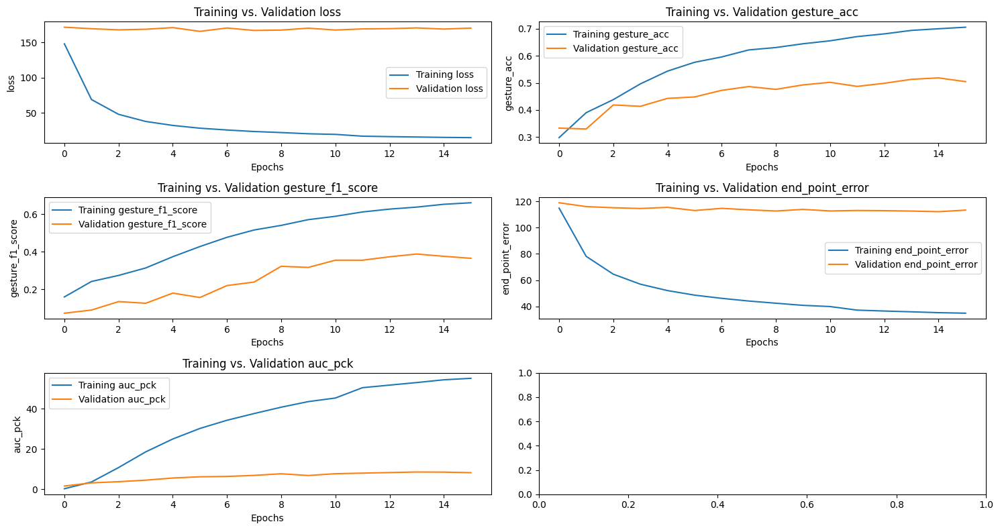

494/494 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.34888142
Gesture F1 Score:  0.1042363561598435
AucPCK :  [0.02535015 0.2915267  1.0456936  2.1104     3.6250715  5.6340704
 7.9789596 ]
End point error  147.66691335822065
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4473801
Gesture F1 Score:  0.15784654242268445
AucPCK :  [ 0.14572641  0.9820693   2.5913959   5.075081    7.850219   11.138567
 15.123868  ]
End point error  112.98071239350615
**************************************************
Worst joints : 


{'wrist_x': 42.15824565531534,
 'wrist_z': 31.150295567892048,
 'Pinky_2_x': 26.57962367194118,
 'Pinky_1_x': 24.366203518406994,
 'Ring_2_x': 22.98443890448544,
 'Thumb_3_x': 22.10804125169735,
 'Pinky_3_x': 21.98975643932279,
 'Middle_3_x': 21.530539797988293,
 'Index_3_x': 21.269310272470086,
 'Ring_1_x': 21.17202584825469,
 'Middle_2_x': 21.162005316343905,
 'Index_3_z': 20.778094956493216,
 'Ring_3_x': 20.70655980229757,
 'Index_2_x': 20.421099797430095,
 'Ring_3_z': 20.3496559416774,
 'Middle_3_z': 19.613898376515145,
 'Thumb_2_x': 17.94758163833321,
 'Middle_1_x': 16.96516195175612,
 'Pinky_3_z': 16.00825974570696,
 'Pinky_3_y': 15.784357182125012,
 'Ring_3_y': 15.674593119052476,
 'Ring_2_z': 15.3090969991475,
 'Index_1_x': 14.781205371712652,
 'Pinky_2_y': 14.721970728855432,
 'Middle_2_z': 14.525820137602265,
 'Middle_3_y': 14.189603629537542,
 'Ring_2_y': 14.13651624578491,
 'Index_2_z': 13.993641027553727,
 'Thumb_3_z': 13.990392309843315,
 'Index_3_y': 13.79942456059999,
 

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img = mean +- std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=1))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  57303
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[-0.09341767720254783, -2.694002146667003, -1...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
1,1.680001e+12,"[[-0.11371048329238656, -2.3662717444188717, -...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
2,1.680001e+12,"[[-0.12662430539048622, -1.8593659721987292, -...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
3,1.680001e+12,"[[-0.20191742726130146, -0.992517550432762, -1...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
4,1.680001e+12,"[[-0.22931436579211345, -0.7648686780684981, -...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
57298,1.680527e+12,"[[0.4719657653115352, 0.04842024960837989, -1....","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57299,1.680527e+12,"[[0.46786819677741015, 0.07077657571020865, -1...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57300,1.680527e+12,"[[0.4666427669375323, 0.045807662083380184, -1...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57301,1.680527e+12,"[[0.46906632149597777, 0.010431893154416375, -...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_std.h5')

Epoch 1/200
1074/1074 [==============================] - 14s 9ms/step - loss: 166.6141 - end_point_error: 123.0317 - auc_pck: 0.0449 - gesture_acc: 0.2978 - gesture_f1_score: 0.1832 - val_loss: 169.5738 - val_end_point_error: 118.3674 - val_auc_pck: 1.4898 - val_gesture_acc: 0.2557 - val_gesture_f1_score: 0.0377 - lr: 1.0000e-04
Epoch 2/200
1074/1074 [==============================] - 9s 8ms/step - loss: 76.8598 - end_point_error: 83.6608 - auc_pck: 1.6607 - gesture_acc: 0.3484 - gesture_f1_score: 0.2004 - val_loss: 157.0018 - val_end_point_error: 112.6569 - val_auc_pck: 3.0280 - val_gesture_acc: 0.3118 - val_gesture_f1_score: 0.0911 - lr: 1.0000e-04
Epoch 3/200
1074/1074 [==============================] - 9s 8ms/step - loss: 51.8102 - end_point_error: 68.4598 - auc_pck: 6.5981 - gesture_acc: 0.4172 - gesture_f1_score: 0.2538 - val_loss: 153.2537 - val_end_point_error: 111.4312 - val_auc_pck: 3.9383 - val_gesture_acc: 0.3692 - val_gesture_f1_score: 0.1277 - lr: 1.0000e-04
Epoch 4/200
1

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


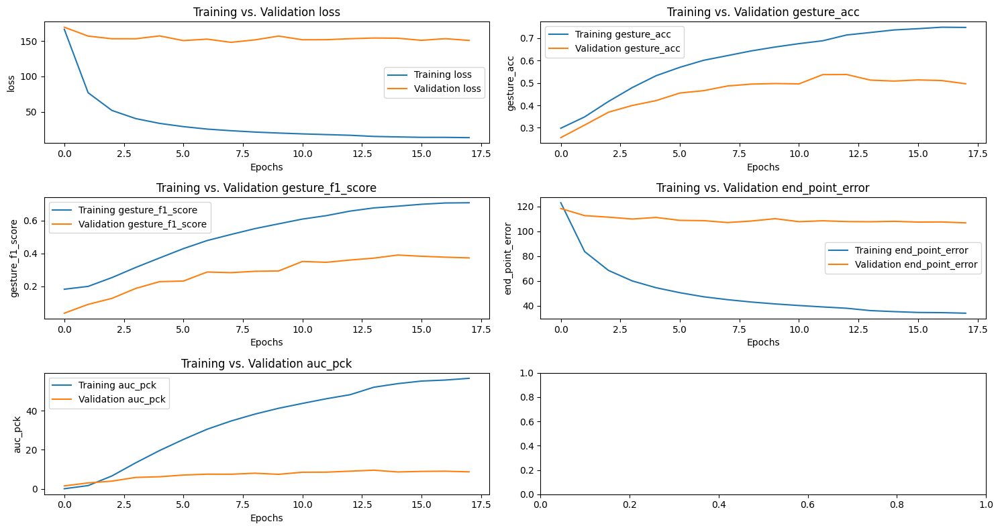

359/359 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.41742998
Gesture F1 Score:  0.18443301341505577
AucPCK :  [0.00872372 0.11340836 0.6717264  1.2125971  2.2943382  3.98674
 6.281079  ]
End point error  150.1301676571675
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4861705
Gesture F1 Score:  0.28760783716984695
AucPCK :  [ 0.59331644  1.6403456   3.0800104   5.8284616   9.53669    13.777158
 17.878021  ]
End point error  107.05244881169287
**************************************************
Worst joints : 


{'wrist_x': 42.14031817165339,
 'wrist_z': 30.929056439555367,
 'Pinky_2_x': 26.96958446066498,
 'Pinky_1_x': 25.217301440448576,
 'Ring_2_x': 22.864854666468393,
 'Thumb_3_x': 22.49029679613516,
 'Pinky_3_x': 22.47487004060214,
 'Index_3_z': 21.673116911468274,
 'Ring_3_z': 21.566050700274104,
 'Ring_1_x': 21.136221408396445,
 'Index_3_x': 20.666186597514873,
 'Middle_3_x': 20.65720065766551,
 'Middle_2_x': 20.407251354375184,
 'Ring_3_x': 20.38338136851085,
 'Middle_3_z': 20.10574332373982,
 'Index_2_x': 19.98911087303905,
 'Thumb_2_x': 18.41175724620621,
 'Pinky_3_z': 17.08660007250412,
 'Middle_1_x': 16.29536160531924,
 'Ring_2_z': 16.222163712984283,
 'Ring_3_y': 15.985002436174085,
 'Pinky_3_y': 15.812796168033097,
 'Middle_2_z': 15.211920802434355,
 'Index_1_y': 15.054585801053193,
 'Middle_3_y': 14.921410385192619,
 'Index_2_y': 14.898537533031277,
 'Index_2_z': 14.653218521557703,
 'Index_3_y': 14.625686574242764,
 'Thumb_3_z': 14.278942271620446,
 'Pinky_2_y': 14.221059971729

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 2std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=2,lower=True))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965329342540703, 1.9027405870399752, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006504695151888, 1.9187705270010709, 0.77...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7039149014654771, 1.9252372815573264, 0.76...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7089235671027683, 1.9150542333662095, 0.74...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066690632599103, 1.8860879012098815, 0.73...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.3153943945499922, -0.07197214812135938, 0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210017653788158, -0.050239470526614594, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.30962253455480937, -0.14323042079736256, ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.3238865162425982, -0.14073655423866607, 1...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower_2_std.h5')

Epoch 1/200
1518/1518 [==============================] - 17s 9ms/step - loss: 141.7892 - end_point_error: 112.3725 - auc_pck: 0.2865 - gesture_acc: 0.2948 - gesture_f1_score: 0.1481 - val_loss: 172.0160 - val_end_point_error: 118.1377 - val_auc_pck: 1.6070 - val_gesture_acc: 0.3060 - val_gesture_f1_score: 0.0069 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 12s 8ms/step - loss: 63.9858 - end_point_error: 75.3694 - auc_pck: 4.5626 - gesture_acc: 0.3821 - gesture_f1_score: 0.1901 - val_loss: 164.3233 - val_end_point_error: 115.7461 - val_auc_pck: 2.4637 - val_gesture_acc: 0.3772 - val_gesture_f1_score: 0.0716 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 12s 8ms/step - loss: 45.7635 - end_point_error: 63.2165 - auc_pck: 12.0666 - gesture_acc: 0.4623 - gesture_f1_score: 0.2716 - val_loss: 163.3678 - val_end_point_error: 113.7042 - val_auc_pck: 4.2750 - val_gesture_acc: 0.4082 - val_gesture_f1_score: 0.1500 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


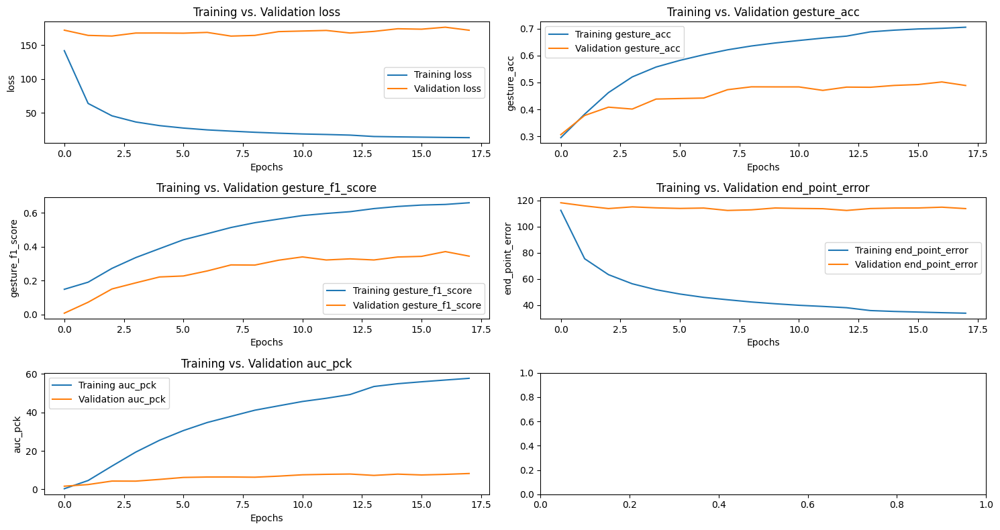

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.3706838
Gesture F1 Score:  0.17522085595199152
AucPCK :  [0.01235407 0.22855024 0.6980048  1.5319043  2.7858424  4.336278
 6.257335  ]
End point error  150.31928903374956
**************************************************
Validation Evaluation
Gesture Accuracy:  0.47215018
Gesture F1 Score:  0.29594245916363227
AucPCK :  [ 0.20377918  1.0868223   2.642954    5.038903    7.947388   11.868593
 15.925652  ]
End point error  112.36306861981143
**************************************************
Worst joints : 


{'wrist_x': 44.79802341565629,
 'wrist_z': 33.80315201939774,
 'Pinky_2_x': 26.664525223632204,
 'Pinky_1_x': 24.58829546117217,
 'Ring_2_x': 23.043915020156746,
 'Thumb_3_x': 22.78751017867968,
 'Pinky_3_x': 21.86639926640725,
 'Ring_1_x': 21.310504705446316,
 'Index_3_x': 21.2891661282737,
 'Ring_3_z': 20.928101180612227,
 'Middle_3_x': 20.86812935644836,
 'Middle_2_x': 20.8664314039496,
 'Index_3_z': 20.807654201359856,
 'Index_2_x': 20.434991080717236,
 'Ring_3_x': 20.39699060638469,
 'Middle_3_z': 19.604629954610957,
 'Thumb_2_x': 18.280242009417766,
 'Middle_1_x': 16.955864099040916,
 'Pinky_3_z': 16.418071504538503,
 'Pinky_3_y': 15.87883226241509,
 'Ring_3_y': 15.865753089707828,
 'Ring_2_z': 15.68440734471568,
 'Index_1_x': 14.873251845720018,
 'Pinky_2_y': 14.742252589332633,
 'Middle_2_z': 14.686214016263873,
 'Middle_3_y': 14.42040791219579,
 'Ring_2_y': 14.166891874722667,
 'Index_2_z': 14.105710578964771,
 'Thumb_3_z': 14.090976794686355,
 'Index_3_y': 14.025701114253293,

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=1,lower=True))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  68619
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[-0.11505748320772266, -2.732003439586708, -1...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
1,1.680001e+12,"[[-0.1354429428223852, -2.39591527094241, -1.1...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
2,1.680001e+12,"[[-0.14841572725083185, -1.8760824098711186, -...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
3,1.680001e+12,"[[-0.22405262479788596, -0.9871276575349395, -...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
4,1.680001e+12,"[[-0.25157465312224464, -0.7536732935759997, -...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
68614,1.680527e+12,"[[0.4529074046024929, 0.08035609279340399, -1....","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68615,1.680527e+12,"[[0.4487911272625865, 0.10328254894650014, -1....","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68616,1.680527e+12,"[[0.4475601023170546, 0.07767687917551298, -1....","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68617,1.680527e+12,"[[0.44999472241623645, 0.04139895893325968, -1...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower_std.h5')

Epoch 1/200
1286/1286 [==============================] - 15s 8ms/step - loss: 147.0033 - end_point_error: 114.0368 - auc_pck: 0.1753 - gesture_acc: 0.3298 - gesture_f1_score: 0.2033 - val_loss: 157.4957 - val_end_point_error: 114.1024 - val_auc_pck: 1.2449 - val_gesture_acc: 0.3247 - val_gesture_f1_score: 0.0814 - lr: 1.0000e-04
Epoch 2/200
1286/1286 [==============================] - 9s 7ms/step - loss: 62.5045 - end_point_error: 75.0974 - auc_pck: 3.8606 - gesture_acc: 0.4225 - gesture_f1_score: 0.2757 - val_loss: 161.9484 - val_end_point_error: 115.6741 - val_auc_pck: 2.4607 - val_gesture_acc: 0.3967 - val_gesture_f1_score: 0.1053 - lr: 1.0000e-04
Epoch 3/200
1286/1286 [==============================] - 9s 7ms/step - loss: 43.5134 - end_point_error: 62.4156 - auc_pck: 11.1270 - gesture_acc: 0.4793 - gesture_f1_score: 0.3255 - val_loss: 152.2104 - val_end_point_error: 110.4873 - val_auc_pck: 3.7081 - val_gesture_acc: 0.3986 - val_gesture_f1_score: 0.1656 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


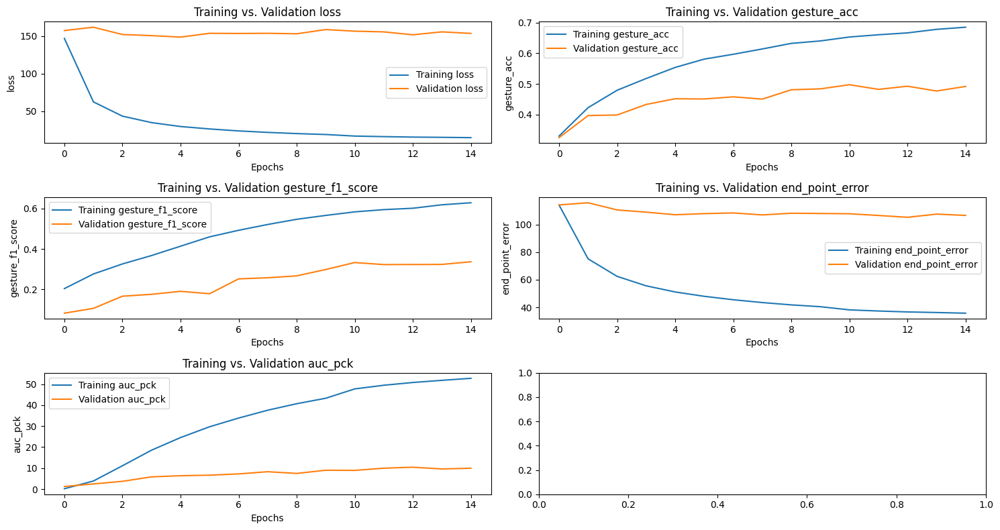

429/429 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.37974498
Gesture F1 Score:  0.15354376421090582
AucPCK :  [0.         0.18214937 0.6994536  1.5883425  2.5063753  4.3570127
 7.234973  ]
End point error  145.63708980232607
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4516035
Gesture F1 Score:  0.19290880894900816
AucPCK :  [ 0.16034986  0.5174927   2.0408163   4.3513117   7.5728865  12.594752
 17.38338   ]
End point error  107.00238195476435
**************************************************
Worst joints : 


{'wrist_x': 41.4400266115617,
 'wrist_z': 30.52156883807356,
 'Pinky_2_x': 26.15015111095137,
 'Pinky_1_x': 24.51168433294063,
 'Ring_2_x': 21.56544143379446,
 'Thumb_3_x': 21.545825166454026,
 'Ring_1_x': 21.10405226051602,
 'Pinky_3_x': 20.97487508957565,
 'Ring_3_z': 20.70410223852792,
 'Index_3_x': 20.144294493243198,
 'Index_3_z': 20.067206329520893,
 'Middle_3_x': 19.842371814401897,
 'Index_2_x': 19.287167475788035,
 'Middle_2_x': 19.276940793872086,
 'Middle_3_z': 19.091972499951048,
 'Ring_3_x': 18.88144039948813,
 'Thumb_2_x': 18.004680136836992,
 'Pinky_3_z': 16.590830669017247,
 'Ring_3_y': 16.212142014397788,
 'Middle_1_x': 16.183049630462353,
 'Pinky_3_y': 16.070763901808668,
 'Ring_2_z': 15.975828062867198,
 'Pinky_2_y': 15.209234736785119,
 'Middle_3_y': 14.994352872802402,
 'Middle_2_z': 14.54310695596496,
 'Index_1_y': 14.522480802505065,
 'Ring_2_y': 14.384647515976642,
 'Index_3_y': 14.189047937847484,
 'Index_2_y': 14.107739054301984,
 'Index_1_x': 13.9347472325908

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 5
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_val(x,val=5))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  40762
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[-0.23818410577020657, 1.3542075509082543, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
1,1.680001e+12,"[[-0.22838409781406524, 1.4135125103379784, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
2,1.680001e+12,"[[-0.21884269759617403, 1.472253611900686, -1....","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
3,1.680001e+12,"[[-0.21290955247926896, 1.5499790023344222, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
4,1.680001e+12,"[[-0.20371317754806614, 1.5936280453309708, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
40757,1.680524e+12,"[[2.16656056171086, -2.298041623699027, -2.234...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40758,1.680524e+12,"[[2.08453418556257, -2.3740077775876833, -2.32...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40759,1.680524e+12,"[[2.0867836214503703, -2.356892274790188, -2.3...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40760,1.680524e+12,"[[2.0888073398608973, -2.337257132838393, -2.3...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower_5.h5')

Epoch 1/200
764/764 [==============================] - 11s 8ms/step - loss: 152.8488 - end_point_error: 119.1076 - auc_pck: 0.0187 - gesture_acc: 0.3027 - gesture_f1_score: 0.1918 - val_loss: 145.4277 - val_end_point_error: 111.2064 - val_auc_pck: 1.3240 - val_gesture_acc: 0.3255 - val_gesture_f1_score: 0.0707 - lr: 1.0000e-04
Epoch 2/200
764/764 [==============================] - 6s 7ms/step - loss: 72.8029 - end_point_error: 82.3559 - auc_pck: 1.3118 - gesture_acc: 0.3870 - gesture_f1_score: 0.2609 - val_loss: 152.4772 - val_end_point_error: 111.9838 - val_auc_pck: 2.1635 - val_gesture_acc: 0.3375 - val_gesture_f1_score: 0.1237 - lr: 1.0000e-04
Epoch 3/200
764/764 [==============================] - 6s 7ms/step - loss: 48.8451 - end_point_error: 67.1312 - auc_pck: 6.3780 - gesture_acc: 0.4511 - gesture_f1_score: 0.3132 - val_loss: 127.0867 - val_end_point_error: 101.9547 - val_auc_pck: 4.5162 - val_gesture_acc: 0.3166 - val_gesture_f1_score: 0.1163 - lr: 1.0000e-04
Epoch 4/200
764/764

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


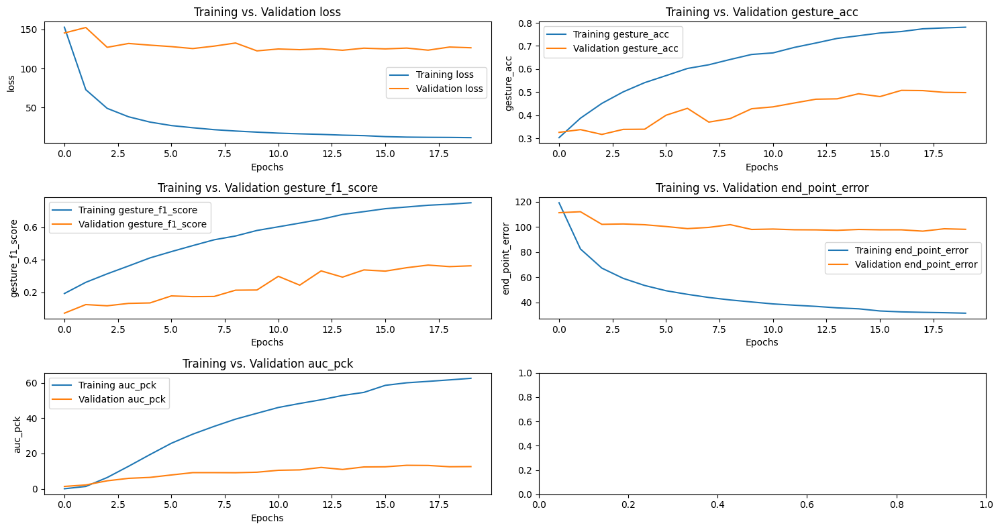

255/255 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.37343636
Gesture F1 Score:  0.1400221324372889
AucPCK :  [ 0.         0.0613196  0.5641403  2.3178809  5.015943   8.155507
 10.939416 ]
End point error  137.7193753767182
**************************************************
Validation Evaluation
Gesture Accuracy:  0.42809817
Gesture F1 Score:  0.21674297481883753
AucPCK :  [ 0.2576687  1.619632   4.539877   7.9018407 12.20859   17.177914
 21.98773  ]
End point error  97.87036332223302
**************************************************
Worst joints : 


{'wrist_x': 37.779937499497585,
 'wrist_z': 26.195974497594612,
 'Pinky_1_x': 23.759129655666328,
 'Pinky_2_x': 23.745410753422323,
 'Thumb_3_x': 22.98871792425177,
 'Thumb_2_x': 19.704860885393316,
 'Ring_3_z': 19.424641193041303,
 'Index_3_x': 19.253101729224504,
 'Ring_1_x': 19.002125375628037,
 'Index_3_z': 18.642084834399796,
 'Pinky_3_x': 18.31350382679897,
 'Ring_2_x': 18.192349214063405,
 'Middle_3_x': 18.184835868038405,
 'Index_2_x': 17.603799655375592,
 'Middle_2_x': 16.93542113970463,
 'Ring_3_y': 16.915808257083185,
 'Pinky_3_y': 16.72948681641845,
 'Middle_3_z': 16.675424003651262,
 'Ring_3_x': 16.53620230097782,
 'Pinky_3_z': 15.732914698711674,
 'Middle_3_y': 15.445824994291993,
 'Index_1_y': 15.4093676204847,
 'Pinky_2_y': 15.247731055038116,
 'Ring_2_y': 14.939243126922412,
 'Ring_2_z': 14.923606933126829,
 'Middle_1_x': 13.77504089414981,
 'Index_3_y': 13.486986789390759,
 'Index_2_y': 13.063242253107578,
 'Thumb_1_x': 13.012047111876225,
 'Thumb_0_x': 12.93720790210

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 5
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_val(x,val=5))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  40762
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[-0.23818410577020657, 1.3542075509082543, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
1,1.680001e+12,"[[-0.22838409781406524, 1.4135125103379784, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
2,1.680001e+12,"[[-0.21884269759617403, 1.472253611900686, -1....","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
3,1.680001e+12,"[[-0.21290955247926896, 1.5499790023344222, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
4,1.680001e+12,"[[-0.20371317754806614, 1.5936280453309708, -1...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
40757,1.680524e+12,"[[2.16656056171086, -2.298041623699027, -2.234...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40758,1.680524e+12,"[[2.08453418556257, -2.3740077775876833, -2.32...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40759,1.680524e+12,"[[2.0867836214503703, -2.356892274790188, -2.3...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40760,1.680524e+12,"[[2.0888073398608973, -2.337257132838393, -2.3...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower.h5')

Epoch 1/200
764/764 [==============================] - 11s 8ms/step - loss: 149.6870 - end_point_error: 117.2104 - auc_pck: 0.0538 - gesture_acc: 0.2860 - gesture_f1_score: 0.1706 - val_loss: 142.9231 - val_end_point_error: 111.5810 - val_auc_pck: 0.6958 - val_gesture_acc: 0.3287 - val_gesture_f1_score: 0.1046 - lr: 1.0000e-04
Epoch 2/200
764/764 [==============================] - 6s 8ms/step - loss: 71.1129 - end_point_error: 80.9693 - auc_pck: 1.9265 - gesture_acc: 0.3928 - gesture_f1_score: 0.2528 - val_loss: 140.9719 - val_end_point_error: 107.4844 - val_auc_pck: 3.8345 - val_gesture_acc: 0.3479 - val_gesture_f1_score: 0.0716 - lr: 1.0000e-04
Epoch 3/200
764/764 [==============================] - 6s 7ms/step - loss: 48.7957 - end_point_error: 66.8316 - auc_pck: 7.1861 - gesture_acc: 0.4677 - gesture_f1_score: 0.3149 - val_loss: 130.9826 - val_end_point_error: 103.7228 - val_auc_pck: 4.8601 - val_gesture_acc: 0.3422 - val_gesture_f1_score: 0.1224 - lr: 1.0000e-04
Epoch 4/200
764/764

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


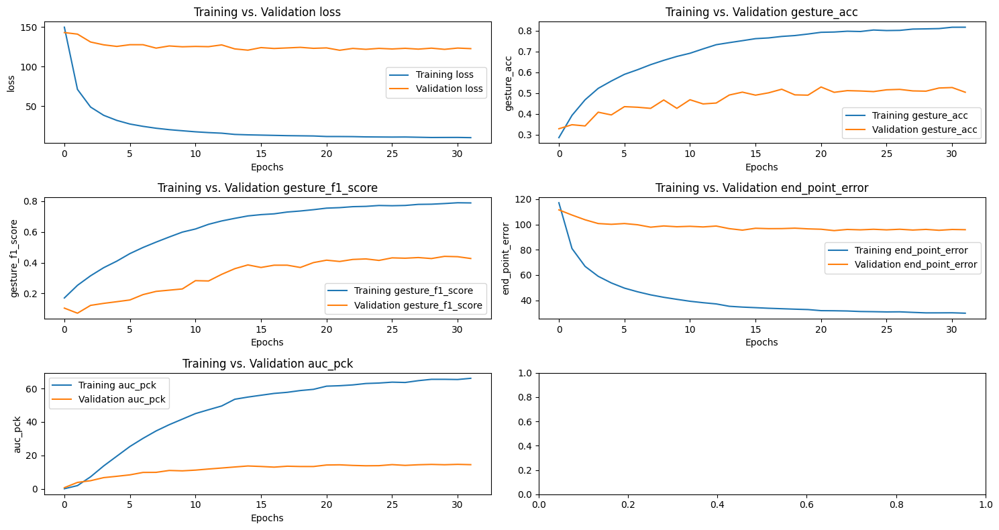

255/255 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.4195487
Gesture F1 Score:  0.27308668285246823
AucPCK :  [ 0.2575423  1.1528084  2.759382   4.181997   6.647044   9.614913
 13.183713 ]
End point error  137.3941528829788
**************************************************
Validation Evaluation
Gesture Accuracy:  0.5035583
Gesture F1 Score:  0.41067162480807157
AucPCK :  [ 2.208589   5.5828223 10.269938  14.417177  18.25767   22.515337
 27.214724 ]
End point error  95.14885899465379
**************************************************
Worst joints : 


{'wrist_x': 38.53974701251766,
 'wrist_z': 25.024748473048497,
 'Pinky_1_x': 24.256302268355338,
 'Pinky_2_x': 24.172548965010286,
 'Thumb_3_x': 23.25200309640679,
 'Ring_1_x': 19.807045283825424,
 'Index_3_x': 19.768070886653792,
 'Thumb_2_x': 19.53416290639575,
 'Index_3_z': 19.00104680774397,
 'Ring_3_z': 18.768543662493645,
 'Middle_3_x': 18.614716915770266,
 'Ring_2_x': 18.52740340261396,
 'Pinky_3_x': 18.511390807566563,
 'Index_2_x': 17.844038064855663,
 'Ring_3_y': 17.1072202970433,
 'Pinky_3_y': 17.047210631375695,
 'Middle_2_x': 16.52378672409832,
 'Ring_3_x': 16.414489095029,
 'Middle_3_z': 16.108414382317445,
 'Index_1_y': 15.70550072252171,
 'Middle_3_y': 15.61108737834719,
 'Pinky_2_y': 15.493071454024667,
 'Ring_2_y': 15.048043847092586,
 'Pinky_3_z': 15.030515472039282,
 'Ring_2_z': 14.500557680146132,
 'Middle_1_x': 14.396318897092717,
 'Index_3_y': 13.705274491212919,
 'Index_2_y': 13.674226465156638,
 'Thumb_1_x': 13.082165619806068,
 'Thumb_0_x': 13.047871664270202,

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower_reg.h5')

Epoch 1/200
764/764 [==============================] - 22s 23ms/step - loss: 162.4675 - end_point_error: 120.3596 - auc_pck: 0.2407 - gesture_acc: 0.2829 - gesture_f1_score: 0.0655 - val_loss: 158.0939 - val_end_point_error: 118.3266 - val_auc_pck: 1.1448 - val_gesture_acc: 0.2725 - val_gesture_f1_score: 0.0000e+00 - lr: 1.0000e-04
Epoch 2/200
764/764 [==============================] - 16s 21ms/step - loss: 111.3610 - end_point_error: 99.0545 - auc_pck: 1.2207 - gesture_acc: 0.3240 - gesture_f1_score: 0.0694 - val_loss: 143.6066 - val_end_point_error: 111.4458 - val_auc_pck: 1.8424 - val_gesture_acc: 0.2292 - val_gesture_f1_score: 0.0375 - lr: 1.0000e-04
Epoch 3/200
764/764 [==============================] - 16s 21ms/step - loss: 89.0640 - end_point_error: 88.3020 - auc_pck: 2.6610 - gesture_acc: 0.3515 - gesture_f1_score: 0.1150 - val_loss: 135.0002 - val_end_point_error: 105.9057 - val_auc_pck: 3.1874 - val_gesture_acc: 0.2827 - val_gesture_f1_score: 0.0444 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


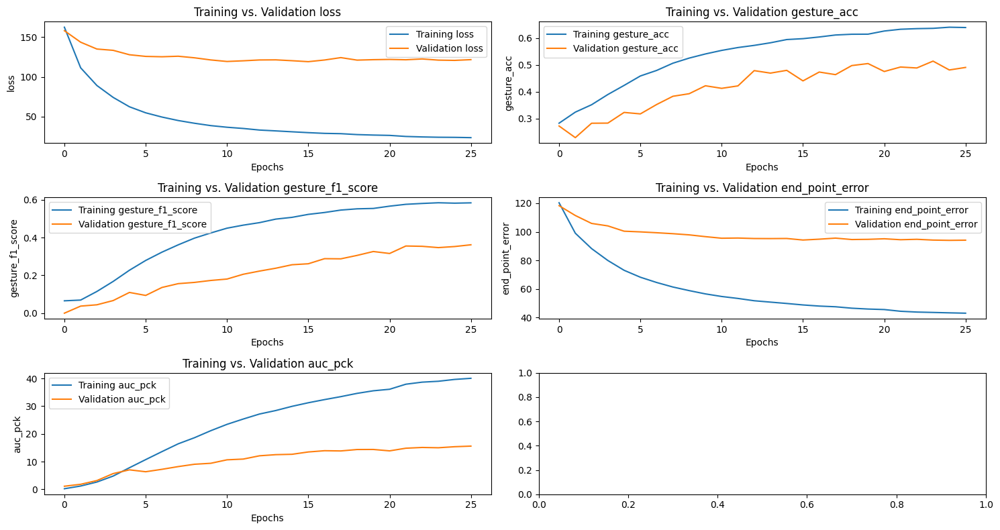

255/255 [==============================] - 1s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.32658818
Gesture F1 Score:  0.1719959969887191
AucPCK :  [ 0.          0.01226392  0.5273486   2.121658    4.8442483   8.302673
 11.6997795 ]
End point error  136.92039161302503
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4401227
Gesture F1 Score:  0.26483675832885567
AucPCK :  [ 0.5644172  2.2208588  6.834356  12.797546  18.441717  24.233128
 29.325155 ]
End point error  94.29342091744272
**************************************************
Worst joints : 


{'wrist_x': 38.43459194727564,
 'wrist_z': 26.86801477461748,
 'Pinky_2_x': 24.950539607317356,
 'Pinky_1_x': 24.872164164043006,
 'Thumb_3_x': 22.837318452361902,
 'Ring_1_x': 20.356083689196254,
 'Thumb_2_x': 19.336855352945534,
 'Index_3_x': 19.15234243342449,
 'Pinky_3_x': 19.07837934827115,
 'Ring_3_z': 18.760136858790457,
 'Ring_2_x': 18.6845364221955,
 'Index_3_z': 17.98728658767516,
 'Middle_3_x': 17.958945546830346,
 'Ring_3_y': 17.135670400999743,
 'Pinky_3_y': 17.074572385303526,
 'Index_2_x': 16.963148638157527,
 'Middle_2_x': 16.445965675836973,
 'Ring_3_x': 15.899457569502458,
 'Middle_3_z': 15.659262495980066,
 'Middle_3_y': 15.518902246444858,
 'Pinky_2_y': 15.287932900279463,
 'Pinky_3_z': 15.241596125977555,
 'Index_1_y': 15.172252991285355,
 'Ring_2_y': 15.09385724532997,
 'Middle_1_x': 14.601362956134356,
 'Ring_2_z': 14.397001983847845,
 'Index_3_y': 12.990758304779778,
 'Thumb_0_x': 12.930545319003981,
 'Thumb_1_x': 12.90142926160268,
 'Index_2_y': 12.880913391556

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower80.h5')

Epoch 1/200
1019/1019 [==============================] - 13s 9ms/step - loss: 138.8214 - end_point_error: 112.0554 - auc_pck: 0.2147 - gesture_acc: 0.3106 - gesture_f1_score: 0.1701 - val_loss: 176.3129 - val_end_point_error: 119.0929 - val_auc_pck: 2.6953 - val_gesture_acc: 0.3114 - val_gesture_f1_score: 0.0947 - lr: 1.0000e-04
Epoch 2/200
1019/1019 [==============================] - 8s 8ms/step - loss: 60.6770 - end_point_error: 74.6013 - auc_pck: 3.7982 - gesture_acc: 0.4013 - gesture_f1_score: 0.2256 - val_loss: 148.8023 - val_end_point_error: 109.4079 - val_auc_pck: 3.5626 - val_gesture_acc: 0.4465 - val_gesture_f1_score: 0.1305 - lr: 1.0000e-04
Epoch 3/200
1019/1019 [==============================] - 8s 8ms/step - loss: 42.4194 - end_point_error: 62.2102 - auc_pck: 10.5092 - gesture_acc: 0.4626 - gesture_f1_score: 0.2699 - val_loss: 150.4503 - val_end_point_error: 106.0830 - val_auc_pck: 7.3965 - val_gesture_acc: 0.5101 - val_gesture_f1_score: 0.1402 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


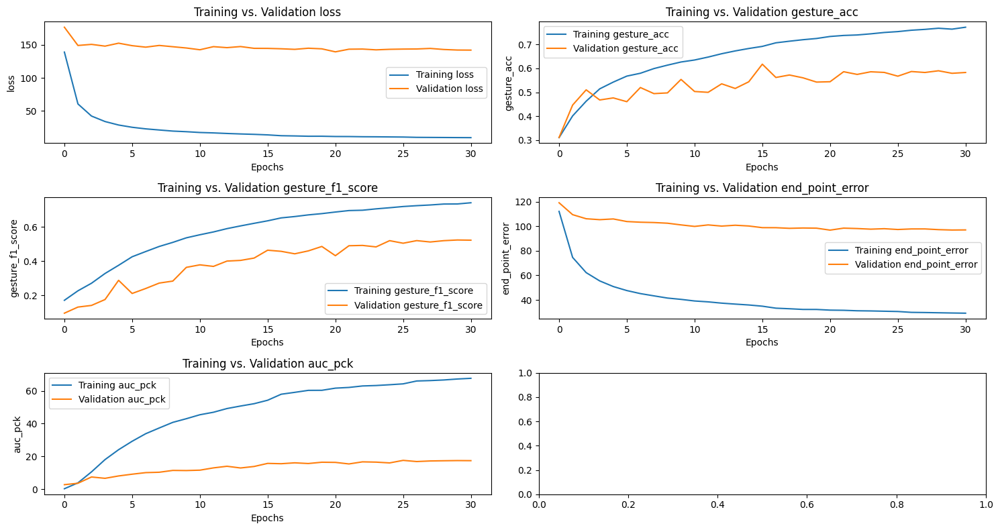

128/128 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.4378524
Gesture F1 Score:  0.25802915901158724
AucPCK :  [ 0.392253   1.2012748  2.9418974  4.5109096  6.1779847  8.408923
 10.639863 ]
End point error  142.90010026132697
**************************************************
Validation Evaluation
Gesture Accuracy:  0.544251
Gesture F1 Score:  0.43391432514171097
AucPCK :  [ 2.8193185  5.6141214 10.811474  16.131405  20.838442  26.329983
 31.649914 ]
End point error  96.79237265589055
**************************************************
Worst joints : 


{'wrist_x': 41.381455581100354,
 'wrist_z': 28.53507410792452,
 'Pinky_1_x': 24.629247776574427,
 'Pinky_2_x': 24.559406576494794,
 'Thumb_3_x': 23.25349593571602,
 'Ring_1_x': 20.139598350706684,
 'Ring_2_x': 19.907977031915998,
 'Index_3_x': 19.78398601155753,
 'Middle_3_x': 19.746069734850277,
 'Ring_3_z': 19.689461742855944,
 'Thumb_2_x': 19.637988707581595,
 'Pinky_3_x': 19.42632765678118,
 'Index_3_z': 19.04242996894467,
 'Ring_3_x': 18.04504355925202,
 'Index_2_x': 18.034386923551768,
 'Pinky_3_y': 17.784012725781867,
 'Middle_2_x': 17.66425147259807,
 'Middle_3_z': 17.439962561351493,
 'Ring_3_y': 17.347655286632147,
 'Pinky_2_y': 16.253468577138854,
 'Index_1_y': 16.222284472838794,
 'Pinky_3_z': 15.75976660739623,
 'Middle_3_y': 15.671427668673092,
 'Ring_2_y': 15.365933544540175,
 'Ring_2_z': 15.300625309507515,
 'Middle_1_x': 14.800892587656717,
 'Index_3_y': 13.90898597591867,
 'Index_2_y': 13.59935348891347,
 'Pinky_2_z': 13.44175321288368,
 'Middle_2_z': 13.4132636776586

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/keep_wrist/filter_cap_img/mean_lower80_reg.h5')

Epoch 1/200
1019/1019 [==============================] - 28s 22ms/step - loss: 155.5972 - end_point_error: 118.1419 - auc_pck: 0.2717 - gesture_acc: 0.2800 - gesture_f1_score: 0.0696 - val_loss: 191.2588 - val_end_point_error: 126.1595 - val_auc_pck: 0.5341 - val_gesture_acc: 0.4202 - val_gesture_f1_score: 0.0210 - lr: 1.0000e-04
Epoch 2/200
1019/1019 [==============================] - 21s 21ms/step - loss: 109.2367 - end_point_error: 98.3170 - auc_pck: 1.4261 - gesture_acc: 0.3477 - gesture_f1_score: 0.0948 - val_loss: 180.7701 - val_end_point_error: 121.1482 - val_auc_pck: 1.1898 - val_gesture_acc: 0.4493 - val_gesture_f1_score: 0.0406 - lr: 1.0000e-04
Epoch 3/200
1019/1019 [==============================] - 21s 21ms/step - loss: 82.1880 - end_point_error: 84.7623 - auc_pck: 3.5537 - gesture_acc: 0.3778 - gesture_f1_score: 0.1336 - val_loss: 162.3783 - val_end_point_error: 112.4177 - val_auc_pck: 3.3261 - val_gesture_acc: 0.4291 - val_gesture_f1_score: 0.0880 - lr: 1.0000e-04
Epoch 4

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


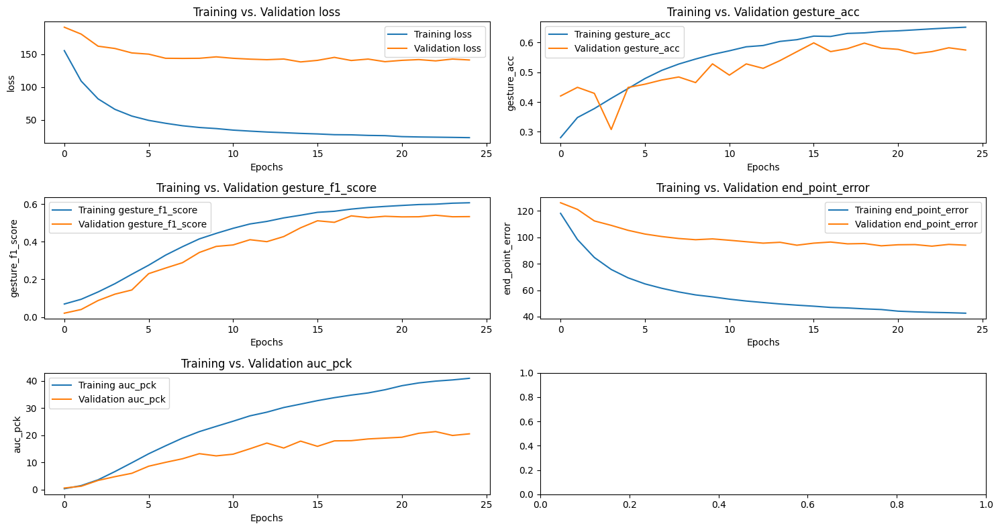

128/128 [==============================] - 1s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.47781318
Gesture F1 Score:  0.3074462014412967
AucPCK :  [ 0.07354744  0.41676882  1.7651385   4.0941405   6.8399115  10.296641
 13.826919  ]
End point error  136.25327383622258
**************************************************
Validation Evaluation
Gesture Accuracy:  0.56950235
Gesture F1 Score:  0.4764686342310985
AucPCK :  [ 0.46580043  4.4863935   9.610198   16.2785     23.167442   31.895071
 38.71047   ]
End point error  94.06348134708551
**************************************************
Worst joints : 


{'wrist_x': 39.23890707165148,
 'wrist_z': 28.556805399424693,
 'Pinky_2_x': 24.003359805054053,
 'Pinky_1_x': 23.108524468066754,
 'Thumb_3_x': 21.036457087595178,
 'Ring_2_x': 19.465162264498105,
 'Ring_1_x': 19.381576488170857,
 'Ring_3_z': 19.3427455783365,
 'Pinky_3_x': 19.163750201599065,
 'Index_3_x': 18.690938482555687,
 'Middle_3_x': 18.681795838716745,
 'Index_3_z': 18.615188491103343,
 'Thumb_2_x': 17.633466538983704,
 'Index_2_x': 17.46918788388906,
 'Ring_3_x': 17.31062434860829,
 'Middle_2_x': 17.21450370545418,
 'Middle_3_z': 16.840587534762307,
 'Pinky_3_y': 16.05500822990604,
 'Ring_3_y': 15.86975273685921,
 'Pinky_3_z': 15.352300710622682,
 'Middle_1_x': 15.042337044667326,
 'Middle_3_y': 14.808790781928067,
 'Pinky_2_y': 14.786099332145458,
 'Ring_2_z': 14.72446921648773,
 'Ring_2_y': 13.997551676440128,
 'Index_1_y': 13.971873820109785,
 'Middle_2_z': 12.939603945841132,
 'Index_3_y': 12.868456407156689,
 'Index_1_x': 12.71077748626466,
 'Index_2_y': 12.609031506622

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

### Without wrist

base 3d model

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint')
chili_data

Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1028535944022013, -0.841...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.113148903727481, -0.8568...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1247378999482407, -0.885...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1420220535753691, -0.920...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1630597053940046, -0.984...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7642775150089752, -0.5701...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7771985797608587, -0.5423...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7451183055935492, -0.6134...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7851119699330328, -0.1553...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/base.h5')

Epoch 1/200
1518/1518 [==============================] - 18s 9ms/step - loss: 115.0428 - end_point_error: 100.0843 - auc_pck: 1.3451 - gesture_acc: 0.2965 - gesture_f1_score: 0.1495 - val_loss: 138.6370 - val_end_point_error: 103.9829 - val_auc_pck: 5.3070 - val_gesture_acc: 0.3328 - val_gesture_f1_score: 0.0465 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 12s 8ms/step - loss: 49.9317 - end_point_error: 65.6673 - auc_pck: 11.1847 - gesture_acc: 0.3808 - gesture_f1_score: 0.1925 - val_loss: 137.8193 - val_end_point_error: 103.2723 - val_auc_pck: 6.6621 - val_gesture_acc: 0.3401 - val_gesture_f1_score: 0.1025 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 12s 8ms/step - loss: 35.1937 - end_point_error: 54.7627 - auc_pck: 21.8187 - gesture_acc: 0.4425 - gesture_f1_score: 0.2444 - val_loss: 132.8566 - val_end_point_error: 100.9040 - val_auc_pck: 7.2327 - val_gesture_acc: 0.3939 - val_gesture_f1_score: 0.0905 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


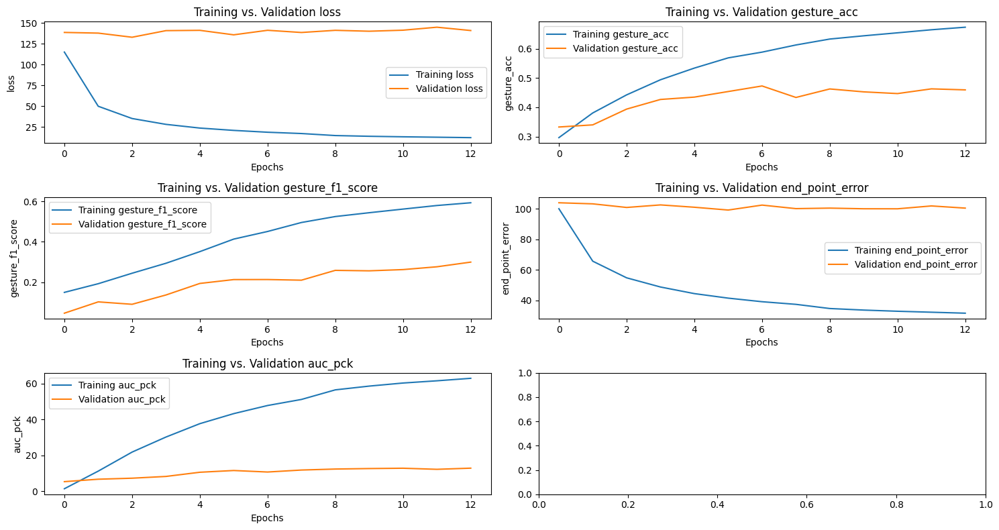

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.3404781
Gesture F1 Score:  0.05185579027155379
AucPCK :  [ 0.0555933   0.38297608  1.5195503   3.2429428   5.6149235   8.530483
 12.267589  ]
End point error  132.14397910730818
**************************************************
Validation Evaluation
Gesture Accuracy:  0.39372608
Gesture F1 Score:  0.0926945020435054
AucPCK :  [ 0.24082993  1.0806471   2.7355812   5.2179823   8.5402     13.4123745
 19.216993  ]
End point error  100.98812144595766
**************************************************
Worst joints : 


{'Pinky_2_x': 26.952759308648766,
 'Pinky_1_x': 25.2005402690535,
 'Ring_2_x': 23.24942107093837,
 'Thumb_3_x': 22.75478364493545,
 'Pinky_3_x': 22.095472725628163,
 'Middle_2_x': 21.73853232445114,
 'Ring_3_z': 21.64997938572078,
 'Ring_1_x': 21.57947038585063,
 'Middle_3_x': 21.546590804064564,
 'Index_3_x': 21.52911663252301,
 'Index_3_z': 21.305141976341453,
 'Ring_3_x': 20.908934421943965,
 'Index_2_x': 20.82862349512859,
 'Middle_3_z': 20.328002923296932,
 'Thumb_2_x': 18.062095409172706,
 'Pinky_3_z': 17.23543535015687,
 'Middle_1_x': 17.106381738870596,
 'Ring_2_z': 16.12600459512555,
 'Pinky_3_y': 15.939408818336796,
 'Ring_3_y': 15.839146023373203,
 'Middle_2_z': 15.561791856322753,
 'Pinky_2_y': 15.019625679884957,
 'Index_1_x': 14.881137673046734,
 'Thumb_3_z': 14.66633559240168,
 'Index_2_z': 14.601505269038766,
 'Middle_3_y': 14.341432094740371,
 'Ring_2_y': 14.320557901417853,
 'Index_2_y': 14.136299081809291,
 'Index_3_y': 14.08163126820166,
 'Index_1_y': 14.03805452163

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80

In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/base_80.h5')

Epoch 1/200
2024/2024 [==============================] - 20s 8ms/step - loss: 110.1783 - end_point_error: 97.0509 - auc_pck: 2.1143 - gesture_acc: 0.3086 - gesture_f1_score: 0.1436 - val_loss: 189.9756 - val_end_point_error: 120.7985 - val_auc_pck: 4.2200 - val_gesture_acc: 0.3203 - val_gesture_f1_score: 0.0590 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 15s 7ms/step - loss: 47.0380 - end_point_error: 63.2853 - auc_pck: 13.9040 - gesture_acc: 0.4133 - gesture_f1_score: 0.2124 - val_loss: 188.0547 - val_end_point_error: 117.4006 - val_auc_pck: 8.2115 - val_gesture_acc: 0.3645 - val_gesture_f1_score: 0.1076 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 15s 7ms/step - loss: 33.6920 - end_point_error: 53.0418 - auc_pck: 25.2922 - gesture_acc: 0.4691 - gesture_f1_score: 0.2787 - val_loss: 190.2957 - val_end_point_error: 114.4398 - val_auc_pck: 12.7373 - val_gesture_acc: 0.3812 - val_gesture_f1_score: 0.1734 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


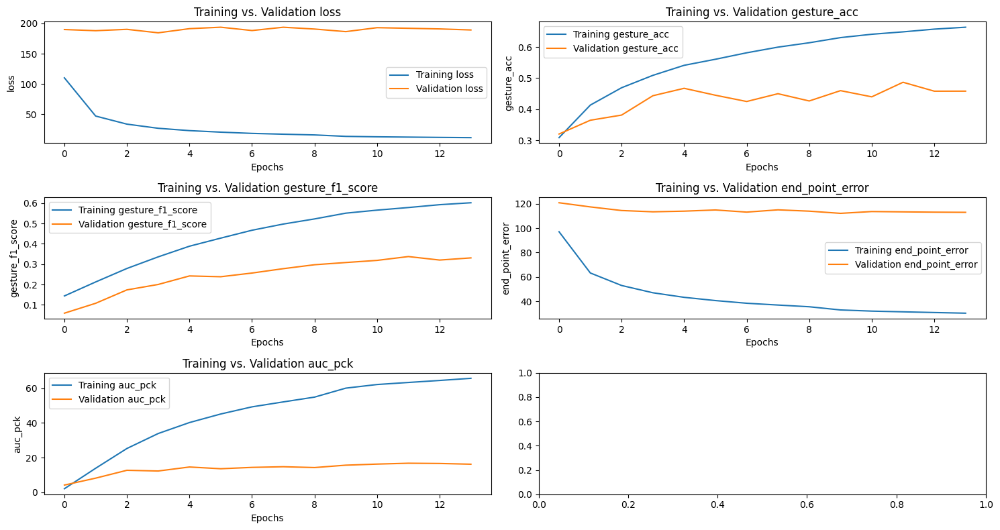

254/254 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.35453197
Gesture F1 Score:  0.13013478107759743
AucPCK :  [ 0.12348729  1.3089652   3.0995307   5.840948    8.656459   11.348481
 14.485058  ]
End point error  130.14987198591774
**************************************************
Validation Evaluation
Gesture Accuracy:  0.44504815
Gesture F1 Score:  0.2055075758352406
AucPCK :  [ 1.3213139  4.0256853  7.9278836 12.114102  16.51025   20.57298
 24.104717 ]
End point error  113.08697727744313
**************************************************
Worst joints : 


{'Pinky_2_x': 25.32871864268464,
 'Pinky_1_x': 23.383300164369846,
 'Thumb_3_x': 23.139463831955744,
 'Ring_2_x': 22.130827749123846,
 'Middle_3_x': 22.057865648511065,
 'Index_3_x': 21.9160938113971,
 'Ring_3_z': 21.174382979942994,
 'Pinky_3_x': 21.15806653172836,
 'Middle_2_x': 21.01092084147118,
 'Ring_3_x': 20.87904624720937,
 'Middle_3_z': 20.84749506302238,
 'Index_2_x': 20.79875613098793,
 'Index_3_z': 20.77475391101442,
 'Ring_1_x': 20.39713035565309,
 'Thumb_2_x': 19.08264321539561,
 'Pinky_3_z': 16.509601857556195,
 'Middle_1_x': 16.190183414394237,
 'Pinky_3_y': 15.749235519593423,
 'Ring_3_y': 15.645137198518484,
 'Ring_2_z': 15.33614367995373,
 'Index_1_x': 15.042106547293344,
 'Middle_2_z': 14.869047221474306,
 'Index_3_y': 14.724020245585578,
 'Pinky_2_y': 14.722564623979736,
 'Index_2_y': 14.688183522544819,
 'Thumb_3_z': 14.466026045266103,
 'Middle_3_y': 14.305967652452921,
 'Index_2_z': 14.263234106564438,
 'Index_1_y': 14.045898384653116,
 'Ring_2_y': 13.9425280558

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base reg

In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/base_reg.h5')

Epoch 1/200
1518/1518 [==============================] - 39s 23ms/step - loss: 119.8522 - end_point_error: 99.3260 - auc_pck: 2.9311 - gesture_acc: 0.2883 - gesture_f1_score: 0.0490 - val_loss: 142.7758 - val_end_point_error: 105.9024 - val_auc_pck: 4.4801 - val_gesture_acc: 0.3544 - val_gesture_f1_score: 0.0198 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 33s 22ms/step - loss: 85.5055 - end_point_error: 83.1120 - auc_pck: 6.9947 - gesture_acc: 0.3453 - gesture_f1_score: 0.0802 - val_loss: 134.7145 - val_end_point_error: 101.8948 - val_auc_pck: 6.3178 - val_gesture_acc: 0.3450 - val_gesture_f1_score: 0.0358 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 33s 22ms/step - loss: 64.5267 - end_point_error: 72.1707 - auc_pck: 11.7353 - gesture_acc: 0.3750 - gesture_f1_score: 0.1370 - val_loss: 134.2542 - val_end_point_error: 98.5893 - val_auc_pck: 9.3151 - val_gesture_acc: 0.3714 - val_gesture_f1_score: 0.1065 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


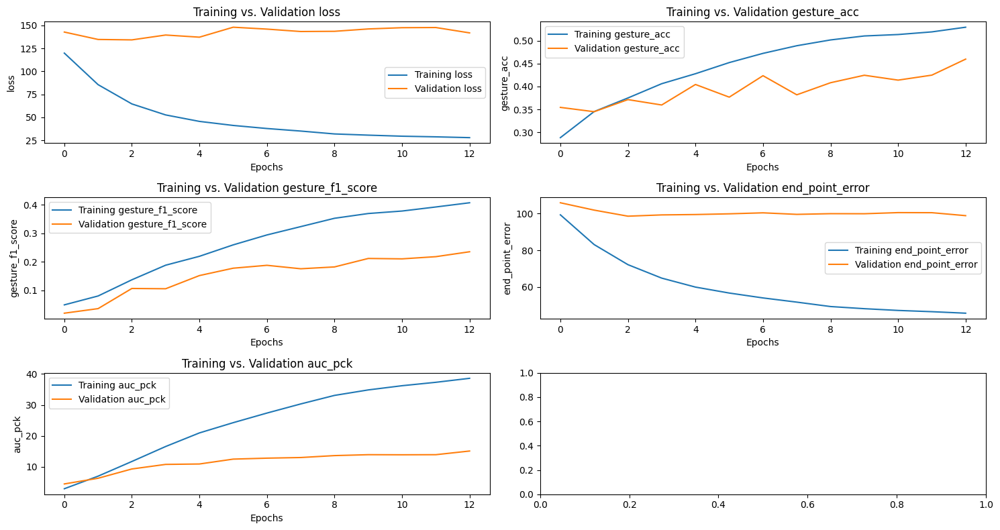

507/507 [==============================] - 2s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.33034778
Gesture F1 Score:  0.10700108022673145
AucPCK :  [ 0.04323924  0.1976651   0.77212924  2.6746557   5.157823    8.4995985
 12.372599  ]
End point error  128.0090552016607
**************************************************
Validation Evaluation
Gesture Accuracy:  0.37211314
Gesture F1 Score:  0.10936874904189997
AucPCK :  [ 0.22230455  1.0435964   3.2419415   6.6135607  11.738915   17.926392
 24.3547    ]
End point error  98.66760303128859
**************************************************
Worst joints : 


{'Pinky_2_x': 26.406341504551534,
 'Pinky_1_x': 24.679998891880963,
 'Thumb_3_x': 22.835314536549596,
 'Ring_2_x': 22.65902496712037,
 'Pinky_3_x': 21.52567535464715,
 'Ring_1_x': 21.293969527475415,
 'Index_3_x': 21.191931895615223,
 'Middle_3_x': 20.795383582213784,
 'Index_3_z': 20.48545397879696,
 'Ring_3_z': 20.348581380894863,
 'Middle_2_x': 20.30604768059233,
 'Index_2_x': 20.20857315875101,
 'Ring_3_x': 19.517657548537418,
 'Middle_3_z': 19.023849890918758,
 'Thumb_2_x': 18.18617459447284,
 'Middle_1_x': 16.656027649323565,
 'Pinky_3_z': 16.404520347145457,
 'Pinky_3_y': 15.974143693195026,
 'Ring_3_y': 15.847946502578042,
 'Ring_2_z': 15.354327977223798,
 'Pinky_2_y': 14.932370309363401,
 'Index_1_x': 14.477169177990142,
 'Middle_2_z': 14.410642652473486,
 'Ring_2_y': 14.289041992374969,
 'Middle_3_y': 14.189767980611443,
 'Thumb_3_z': 13.963302173615089,
 'Index_1_y': 13.933385685182898,
 'Index_2_z': 13.628841967534527,
 'Index_2_y': 13.459002429129201,
 'Index_3_y': 13.1622

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

base 80 reg


In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/base_80_reg.h5')

Epoch 1/200
2024/2024 [==============================] - 48s 21ms/step - loss: 124.2935 - end_point_error: 101.2079 - auc_pck: 2.7686 - gesture_acc: 0.3031 - gesture_f1_score: 0.0484 - val_loss: 207.8852 - val_end_point_error: 126.8396 - val_auc_pck: 3.0301 - val_gesture_acc: 0.3825 - val_gesture_f1_score: 0.0209 - lr: 1.0000e-04
Epoch 2/200
2024/2024 [==============================] - 42s 21ms/step - loss: 83.9483 - end_point_error: 82.2976 - auc_pck: 7.6939 - gesture_acc: 0.3505 - gesture_f1_score: 0.0951 - val_loss: 189.3819 - val_end_point_error: 118.8093 - val_auc_pck: 5.8194 - val_gesture_acc: 0.3861 - val_gesture_f1_score: 0.0546 - lr: 1.0000e-04
Epoch 3/200
2024/2024 [==============================] - 42s 21ms/step - loss: 62.1045 - end_point_error: 70.4894 - auc_pck: 13.2045 - gesture_acc: 0.3954 - gesture_f1_score: 0.1649 - val_loss: 180.5561 - val_end_point_error: 113.0986 - val_auc_pck: 8.7546 - val_gesture_acc: 0.4748 - val_gesture_f1_score: 0.1335 - lr: 1.0000e-04
Epoch 4

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


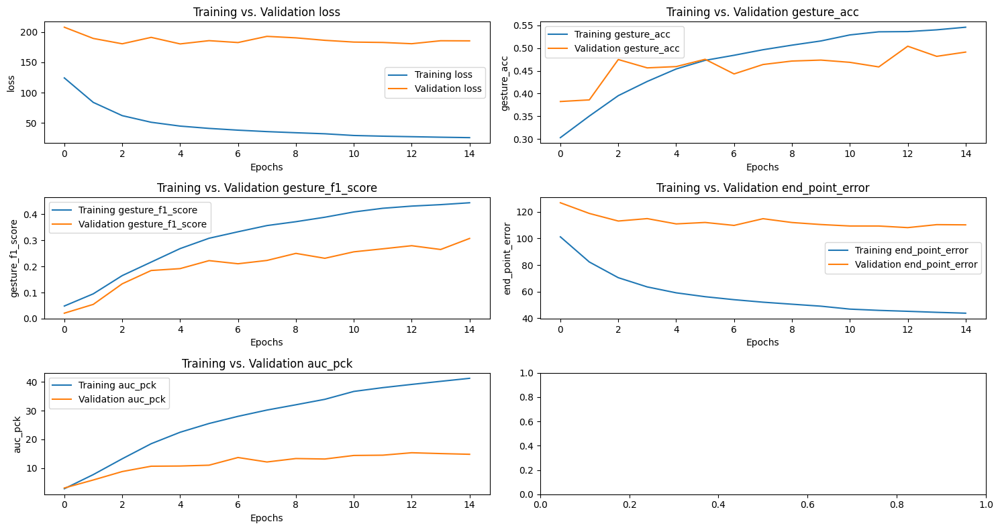

254/254 [==============================] - 1s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.41998023
Gesture F1 Score:  0.09927816067197252
AucPCK :  [ 0.09878982  0.8520623   1.6053346   3.7416644   7.693258   11.681896
 15.497653  ]
End point error  131.20037931613433
**************************************************
Validation Evaluation
Gesture Accuracy:  0.46097803
Gesture F1 Score:  0.19661863380580571
AucPCK :  [ 0.28402075  1.5806371   5.495184   10.064214   15.164238   19.177576
 23.289701  ]
End point error  110.71030689109567
**************************************************
Worst joints : 


{'Pinky_2_x': 26.529215285358543,
 'Pinky_1_x': 24.2794594594798,
 'Thumb_3_x': 23.839837813722294,
 'Ring_2_x': 23.273525966405707,
 'Middle_3_x': 22.781457442956697,
 'Index_3_x': 22.252884859531296,
 'Pinky_3_x': 22.073478538959584,
 'Middle_2_x': 21.705995684707954,
 'Ring_3_x': 21.561650353277475,
 'Index_2_x': 21.05455059287952,
 'Ring_1_x': 20.98791746248539,
 'Ring_3_z': 20.532650739225126,
 'Index_3_z': 20.49947255250902,
 'Middle_3_z': 20.32157964793315,
 'Thumb_2_x': 18.806547567336768,
 'Middle_1_x': 16.655078222807333,
 'Pinky_3_y': 16.13848272634865,
 'Ring_3_y': 16.037131662310923,
 'Pinky_3_z': 15.871907082573696,
 'Ring_2_z': 15.199241313978648,
 'Index_1_x': 15.039018091658733,
 'Pinky_2_y': 14.93230240632396,
 'Thumb_3_z': 14.847493568074544,
 'Middle_3_y': 14.597612495980242,
 'Middle_2_z': 14.572964649576035,
 'Index_3_y': 14.531996893787575,
 'Index_2_y': 14.494623092914315,
 'Ring_2_y': 14.16679788707838,
 'Index_2_z': 14.11127759862096,
 'Index_1_y': 13.61015301

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

try some filterings of capactive images

In [ ]:
# try with cap_img = mean +- 2std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=2))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  78910
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.0864900963339603, -0.868...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.0967084996219347, -0.884...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.108210925954648, -0.9131...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.125365966825506, -0.9479...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1462464672284367, -1.012...","[[-0.11938778776298703, -0.11938778776298703, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
78905,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7666935297896313, -0.5969...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78906,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7795180740916244, -0.5691...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78907,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7476774398111736, -0.6404...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304
78908,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7873723511802992, -0.1810...","[[-0.11938778776298703, -0.11938778776298703, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_2_std.h5')

Epoch 1/200
1480/1480 [==============================] - 17s 9ms/step - loss: 112.9141 - end_point_error: 99.0213 - auc_pck: 1.4921 - gesture_acc: 0.3255 - gesture_f1_score: 0.1647 - val_loss: 146.9362 - val_end_point_error: 108.0711 - val_auc_pck: 3.3379 - val_gesture_acc: 0.3403 - val_gesture_f1_score: 0.0192 - lr: 1.0000e-04
Epoch 2/200
1480/1480 [==============================] - 12s 8ms/step - loss: 49.4203 - end_point_error: 65.1782 - auc_pck: 11.7288 - gesture_acc: 0.3873 - gesture_f1_score: 0.1926 - val_loss: 142.1219 - val_end_point_error: 104.2277 - val_auc_pck: 6.7803 - val_gesture_acc: 0.3732 - val_gesture_f1_score: 0.0656 - lr: 1.0000e-04
Epoch 3/200
1480/1480 [==============================] - 12s 8ms/step - loss: 35.3297 - end_point_error: 54.7800 - auc_pck: 22.1471 - gesture_acc: 0.4443 - gesture_f1_score: 0.2398 - val_loss: 143.2674 - val_end_point_error: 102.8387 - val_auc_pck: 9.4357 - val_gesture_acc: 0.4590 - val_gesture_f1_score: 0.1051 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


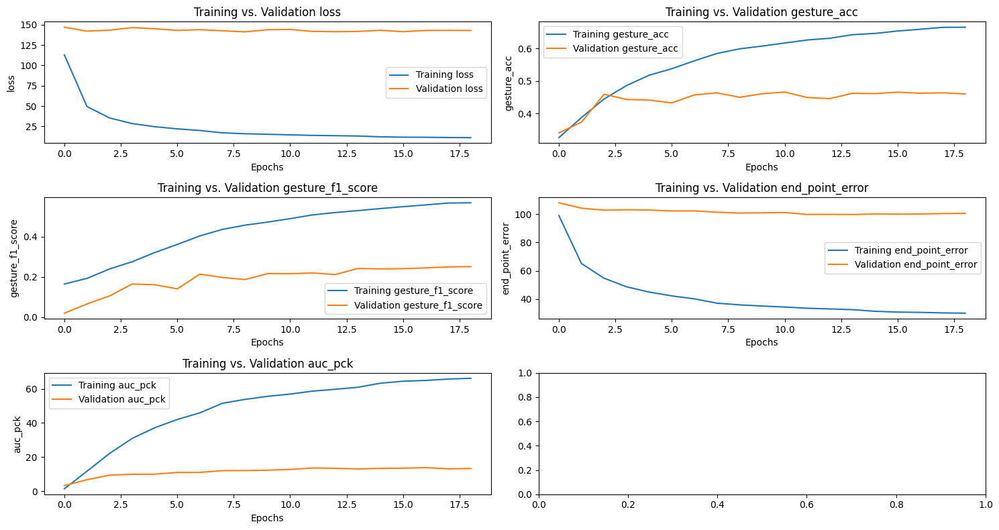

494/494 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.33126307
Gesture F1 Score:  0.12648823395669315
AucPCK :  [ 0.25983903  1.191457    2.9659674   5.2094555   7.9219213  11.230116
 14.531973  ]
End point error  131.93397217194405
**************************************************
Validation Evaluation
Gesture Accuracy:  0.44934422
Gesture F1 Score:  0.18913230025695468
AucPCK :  [ 1.4762719  3.3833873  6.513337  10.752075  15.687765  20.908571
 26.237091 ]
End point error  100.76428769944441
**************************************************
Worst joints : 


{'Pinky_2_x': 27.019674533493244,
 'Pinky_1_x': 24.76068076258211,
 'Ring_2_x': 23.548724524704888,
 'Thumb_3_x': 22.988010178455966,
 'Pinky_3_x': 22.391013543600142,
 'Middle_2_x': 21.695363670640173,
 'Index_3_x': 21.676520075965144,
 'Middle_3_x': 21.44079591817754,
 'Ring_1_x': 21.393098536983633,
 'Index_3_z': 21.325354075627995,
 'Ring_3_x': 21.097226212992737,
 'Ring_3_z': 20.990600152533318,
 'Index_2_x': 20.987822349759053,
 'Middle_3_z': 20.251649706667536,
 'Thumb_2_x': 18.496329406499054,
 'Middle_1_x': 16.872663518934736,
 'Pinky_3_z': 16.42732051704675,
 'Ring_3_y': 15.952586894039081,
 'Pinky_3_y': 15.867701147767292,
 'Ring_2_z': 15.558224387126618,
 'Pinky_2_y': 14.853570029961675,
 'Index_1_x': 14.828579421685797,
 'Middle_2_z': 14.826846937363436,
 'Middle_3_y': 14.419359348298586,
 'Thumb_3_z': 14.395114526211243,
 'Index_2_z': 14.309480199187792,
 'Ring_2_y': 14.172476428468324,
 'Index_1_y': 14.123988449003349,
 'Index_3_y': 14.0340201181859,
 'Index_2_y': 13.867

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img = mean +- std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=1))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  57303
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0, 0.0], [0.9015205595353462, -1.0264...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8889685271321265, -1.0423...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8683807128870537, -1.0774...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8444829778540496, -1.0746...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8479158843901592, -1.0412...","[[-0.11993064426264063, -0.11993064426264063, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
57298,1.680527e+12,"[[0.0, 0.0, 0.0], [0.8478517179128446, -0.7489...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57299,1.680527e+12,"[[0.0, 0.0, 0.0], [0.85938457276812, -0.746210...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57300,1.680527e+12,"[[0.0, 0.0, 0.0], [0.8707955113165033, -0.7318...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304
57301,1.680527e+12,"[[0.0, 0.0, 0.0], [0.8818332148551973, -0.7119...","[[-0.11993064426264063, -0.11993064426264063, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_std.h5')

Epoch 1/200
1074/1074 [==============================] - 14s 9ms/step - loss: 127.3821 - end_point_error: 106.3172 - auc_pck: 0.3880 - gesture_acc: 0.2962 - gesture_f1_score: 0.1647 - val_loss: 138.5716 - val_end_point_error: 104.7112 - val_auc_pck: 4.4419 - val_gesture_acc: 0.3099 - val_gesture_f1_score: 0.0236 - lr: 1.0000e-04
Epoch 2/200
1074/1074 [==============================] - 9s 8ms/step - loss: 55.4682 - end_point_error: 70.4773 - auc_pck: 6.2590 - gesture_acc: 0.3814 - gesture_f1_score: 0.2184 - val_loss: 130.0014 - val_end_point_error: 100.7818 - val_auc_pck: 7.0257 - val_gesture_acc: 0.3719 - val_gesture_f1_score: 0.1575 - lr: 1.0000e-04
Epoch 3/200
1074/1074 [==============================] - 9s 8ms/step - loss: 37.9891 - end_point_error: 57.9627 - auc_pck: 16.1017 - gesture_acc: 0.4528 - gesture_f1_score: 0.2776 - val_loss: 131.0435 - val_end_point_error: 100.7872 - val_auc_pck: 8.5565 - val_gesture_acc: 0.4156 - val_gesture_f1_score: 0.1759 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


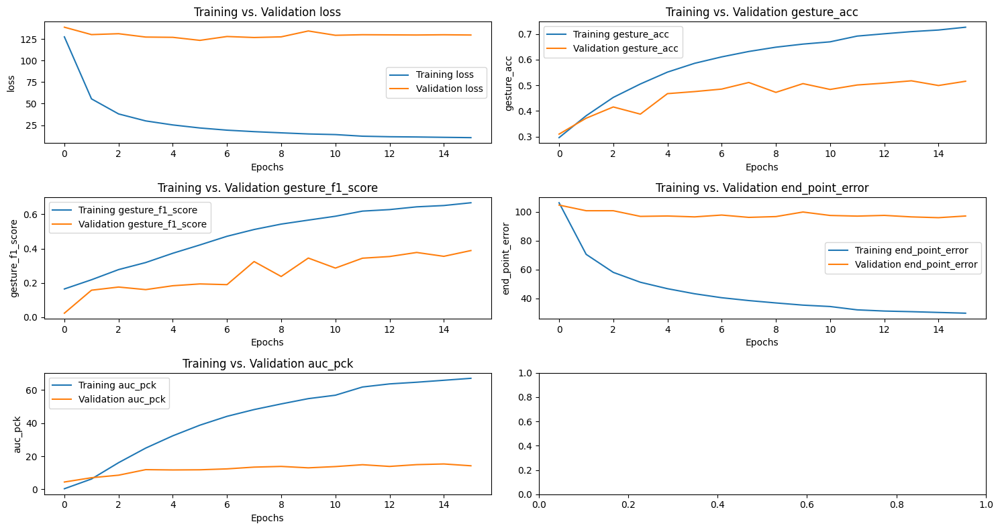

359/359 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.4117596
Gesture F1 Score:  0.1310536862167611
AucPCK :  [ 0.18319811  0.53214693  1.5353746   3.5680015   6.6387506  10.468464
 14.481375  ]
End point error  131.29455316265984
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4751767
Gesture F1 Score:  0.19672849957962352
AucPCK :  [ 0.8725242  3.2894163  7.2157755 11.124684  15.347701  19.893553
 24.858215 ]
End point error  96.46550140182123
**************************************************
Worst joints : 


{'Pinky_2_x': 27.205947695216537,
 'Pinky_1_x': 25.237988045499215,
 'Ring_2_x': 22.699364798061385,
 'Thumb_3_x': 22.334715550286603,
 'Pinky_3_x': 21.942087350369746,
 'Ring_3_z': 21.478479183164072,
 'Ring_1_x': 21.44985446056841,
 'Index_3_z': 21.200187117433128,
 'Index_3_x': 20.98048789228206,
 'Middle_3_x': 20.14223648074969,
 'Index_2_x': 19.98900907660327,
 'Middle_2_x': 19.979721911431007,
 'Ring_3_x': 19.881990166995017,
 'Middle_3_z': 19.84215772923547,
 'Thumb_2_x': 17.99100398748702,
 'Pinky_3_z': 16.735722863802096,
 'Middle_1_x': 16.457077640130645,
 'Pinky_3_y': 16.33985298624064,
 'Ring_2_z': 16.283450291911397,
 'Ring_3_y': 16.080269817179353,
 'Middle_3_y': 15.167812549861198,
 'Middle_2_z': 14.897935428089472,
 'Pinky_2_y': 14.778273010885012,
 'Index_3_y': 14.625718660771831,
 'Index_2_y': 14.479035388318984,
 'Index_1_x': 14.413098625442792,
 'Index_1_y': 14.377761647818351,
 'Ring_2_y': 14.3368592714903,
 'Index_2_z': 14.139434906809857,
 'Thumb_3_z': 13.8517604

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 2std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=2,lower=True))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1028535944022013, -0.841...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.113148903727481, -0.8568...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1247378999482407, -0.885...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1420220535753691, -0.920...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1630597053940046, -0.984...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7642775150089752, -0.5701...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7771985797608587, -0.5423...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7451183055935492, -0.6134...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0, 0.0], [0.7851119699330328, -0.1553...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower_2_std.h5')

Epoch 1/200
1518/1518 [==============================] - 17s 9ms/step - loss: 117.1719 - end_point_error: 101.2854 - auc_pck: 0.9567 - gesture_acc: 0.3122 - gesture_f1_score: 0.1657 - val_loss: 146.0875 - val_end_point_error: 111.0771 - val_auc_pck: 1.4150 - val_gesture_acc: 0.3788 - val_gesture_f1_score: 0.0735 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 12s 8ms/step - loss: 50.1686 - end_point_error: 66.1404 - auc_pck: 9.8189 - gesture_acc: 0.4126 - gesture_f1_score: 0.2300 - val_loss: 129.6608 - val_end_point_error: 100.8101 - val_auc_pck: 6.1065 - val_gesture_acc: 0.4227 - val_gesture_f1_score: 0.1044 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 12s 8ms/step - loss: 35.0369 - end_point_error: 54.7451 - auc_pck: 21.3928 - gesture_acc: 0.4750 - gesture_f1_score: 0.2785 - val_loss: 129.1475 - val_end_point_error: 98.9321 - val_auc_pck: 8.5015 - val_gesture_acc: 0.4306 - val_gesture_f1_score: 0.1146 - lr: 1.0000e-04
Epoch 4/200

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


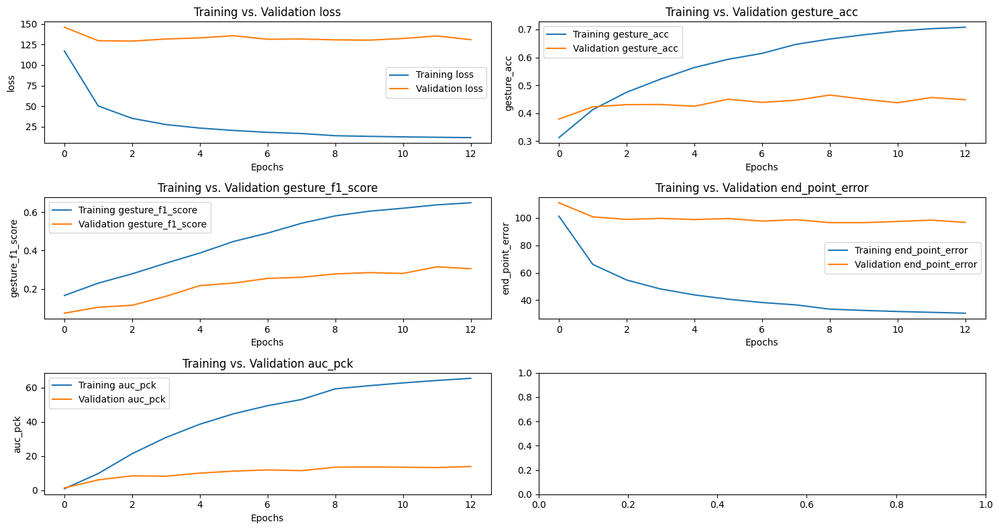

507/507 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.36129472
Gesture F1 Score:  0.10174578430377719
AucPCK :  [ 0.06794737  0.33973685  1.4145408   3.9718325   6.5044165   9.006115
 12.088455  ]
End point error  131.4399271971708
**************************************************
Validation Evaluation
Gesture Accuracy:  0.43046808
Gesture F1 Score:  0.11721609901798637
AucPCK :  [ 0.20377918  1.6117082   3.7050762   6.57651    10.435965   15.474868
 21.335062  ]
End point error  99.01509971191294
**************************************************
Worst joints : 


{'Pinky_2_x': 27.03300831937754,
 'Pinky_1_x': 24.494567067939354,
 'Ring_2_x': 23.686245553922827,
 'Thumb_3_x': 22.591146856222117,
 'Index_3_z': 22.115106911333797,
 'Pinky_3_x': 22.09311033164303,
 'Index_3_x': 22.033409022192025,
 'Middle_3_x': 21.51869571463262,
 'Ring_1_x': 21.48367969195436,
 'Middle_2_x': 21.120025274285513,
 'Ring_3_x': 21.01578288339285,
 'Index_2_x': 20.972851378229954,
 'Ring_3_z': 20.86757405294953,
 'Middle_3_z': 19.957237103866824,
 'Thumb_2_x': 18.282954695759194,
 'Middle_1_x': 16.981819062509736,
 'Pinky_3_z': 16.159891066002682,
 'Ring_3_y': 16.0541566174636,
 'Pinky_3_y': 15.811122896517169,
 'Ring_2_z': 15.453806740267417,
 'Index_1_x': 15.093578916143972,
 'Middle_2_z': 14.851670978513582,
 'Pinky_2_y': 14.79028649630961,
 'Thumb_3_z': 14.779537900838646,
 'Middle_3_y': 14.767487734894823,
 'Index_2_z': 14.755209364924692,
 'Ring_2_y': 14.314311895234383,
 'Index_2_y': 13.722713989354729,
 'Index_1_y': 13.720091839385091,
 'Index_3_y': 13.5991685

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - std
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_std(x,m=1,lower=True))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  68619
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8824812652433888, -0.9491...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8694951124848935, -0.9652...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8481952550465506, -1.0007...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0, 0.0], [0.8234710010172964, -0.9977...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0, 0.0], [0.827022636899954, -0.96409...","[[-0.13184038813697546, -0.13184038813697546, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
68614,1.680527e+12,"[[0.0, 0.0, 0.0], [0.826956251182517, -0.66873...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68615,1.680527e+12,"[[0.0, 0.0, 0.0], [0.8388879774624572, -0.6660...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68616,1.680527e+12,"[[0.0, 0.0, 0.0], [0.850693570879273, -0.65149...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304
68617,1.680527e+12,"[[0.0, 0.0, 0.0], [0.862113020706354, -0.63143...","[[-0.13184038813697546, -0.13184038813697546, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower_std.h5')

Epoch 1/200
1286/1286 [==============================] - 15s 8ms/step - loss: 114.5212 - end_point_error: 99.6312 - auc_pck: 1.2338 - gesture_acc: 0.3088 - gesture_f1_score: 0.1719 - val_loss: 126.6486 - val_end_point_error: 100.9137 - val_auc_pck: 4.2451 - val_gesture_acc: 0.3239 - val_gesture_f1_score: 0.0478 - lr: 1.0000e-04
Epoch 2/200
1286/1286 [==============================] - 10s 7ms/step - loss: 48.4409 - end_point_error: 65.0012 - auc_pck: 11.0298 - gesture_acc: 0.3972 - gesture_f1_score: 0.2033 - val_loss: 129.4460 - val_end_point_error: 102.0811 - val_auc_pck: 6.0190 - val_gesture_acc: 0.3827 - val_gesture_f1_score: 0.0666 - lr: 1.0000e-04
Epoch 3/200
1286/1286 [==============================] - 9s 7ms/step - loss: 33.4860 - end_point_error: 53.8674 - auc_pck: 22.0725 - gesture_acc: 0.4387 - gesture_f1_score: 0.2380 - val_loss: 122.9139 - val_end_point_error: 98.2541 - val_auc_pck: 8.5591 - val_gesture_acc: 0.4411 - val_gesture_f1_score: 0.1139 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


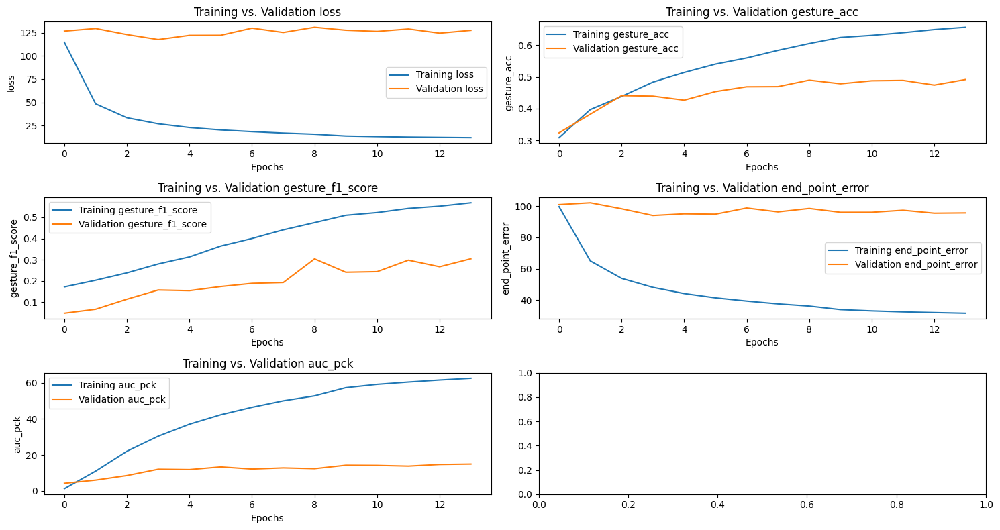

429/429 [==============================] - 1s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.37508196
Gesture F1 Score:  0.1148238733916091
AucPCK :  [ 0.10928962  0.9253188   2.5792348   5.68306     8.692167   11.723133
 14.84153   ]
End point error  131.73668394351645
**************************************************
Validation Evaluation
Gesture Accuracy:  0.43950438
Gesture F1 Score:  0.16069585578095866
AucPCK :  [ 0.42274055  2.3323617   6.450437   11.377551   16.516035   21.180758
 26.217201  ]
End point error  93.97330212161212
**************************************************
Worst joints : 


{'Pinky_2_x': 27.38491334275101,
 'Pinky_1_x': 25.923722312959153,
 'Ring_2_x': 23.559625746529534,
 'Pinky_3_x': 22.655810410742816,
 'Ring_1_x': 22.360245871025867,
 'Thumb_3_x': 22.28389522002757,
 'Ring_3_z': 21.93790351862065,
 'Index_3_x': 20.883152355869328,
 'Index_3_z': 20.430865482546785,
 'Middle_3_x': 20.386102649490045,
 'Middle_2_x': 20.240991897980322,
 'Ring_3_x': 20.07202667380666,
 'Index_2_x': 19.95742019949971,
 'Middle_3_z': 19.950636320752736,
 'Thumb_2_x': 18.029850741894105,
 'Pinky_3_z': 17.677733923251605,
 'Middle_1_x': 17.037197301787263,
 'Ring_2_z': 16.7101457555385,
 'Pinky_3_y': 16.293519814873786,
 'Ring_3_y': 16.15891064314879,
 'Middle_2_z': 15.183932495197611,
 'Middle_3_y': 15.036004918839822,
 'Pinky_2_y': 14.73893914218319,
 'Index_1_y': 14.628035976934303,
 'Ring_2_y': 14.331491871491561,
 'Index_1_x': 14.241909045072218,
 'Index_2_z': 14.146948095030842,
 'Index_3_y': 14.139485380231282,
 'Index_2_y': 14.039771717217604,
 'Pinky_2_z': 13.7191499

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean - 5
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_val(x,val=5))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  40762
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0486601679950152, -0.1797...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0515423540894262, -0.1933...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0434741753444092, -0.2460...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0301995016890315, -0.3123...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0145476449688797, -0.3729...","[[-0.15179490645255583, -0.15179490645255583, ...",3,DT,2,2803
...,...,...,...,...,...,...,...
40757,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7512727321795643, -0.8922...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40758,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7240543637611528, -0.9493...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40759,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7236173419085736, -0.9383...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304
40760,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7200337627174246, -0.9449...","[[-0.15179490645255583, -0.15179490645255583, ...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower_5.h5')

Epoch 1/200
764/764 [==============================] - 11s 8ms/step - loss: 124.1881 - end_point_error: 106.0632 - auc_pck: 0.2881 - gesture_acc: 0.2892 - gesture_f1_score: 0.1580 - val_loss: 125.2841 - val_end_point_error: 101.7633 - val_auc_pck: 3.0449 - val_gesture_acc: 0.3191 - val_gesture_f1_score: 0.0476 - lr: 1.0000e-04
Epoch 2/200
764/764 [==============================] - 6s 7ms/step - loss: 54.3928 - end_point_error: 70.1563 - auc_pck: 6.0519 - gesture_acc: 0.3868 - gesture_f1_score: 0.2099 - val_loss: 115.6771 - val_end_point_error: 96.2002 - val_auc_pck: 6.3285 - val_gesture_acc: 0.3621 - val_gesture_f1_score: 0.0385 - lr: 1.0000e-04
Epoch 3/200
764/764 [==============================] - 6s 7ms/step - loss: 37.1515 - end_point_error: 57.8430 - auc_pck: 15.4719 - gesture_acc: 0.4440 - gesture_f1_score: 0.2643 - val_loss: 116.6561 - val_end_point_error: 94.6486 - val_auc_pck: 9.0895 - val_gesture_acc: 0.3235 - val_gesture_f1_score: 0.0632 - lr: 1.0000e-04
Epoch 4/200
764/764 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


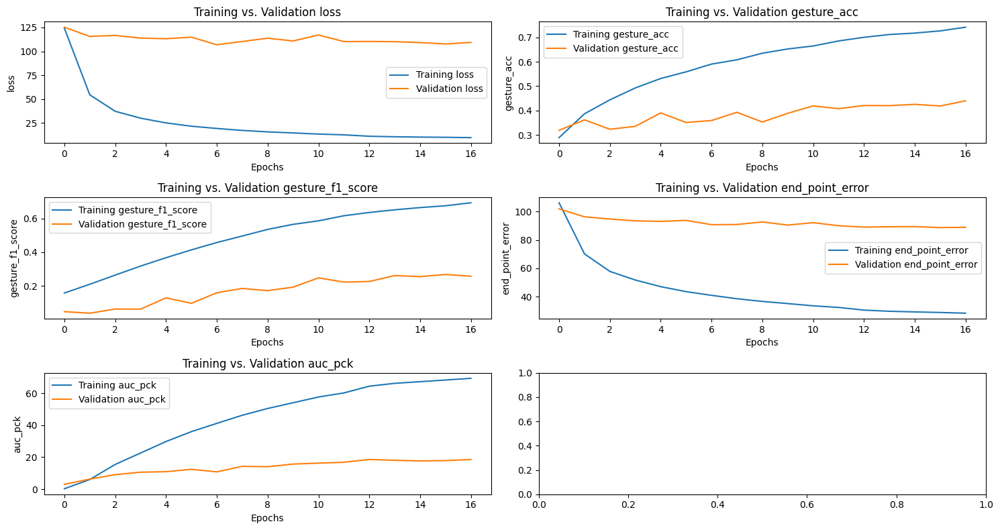

255/255 [==============================] - 1s 4ms/step
Testing Evaluation
Gesture Accuracy:  0.40765268
Gesture F1 Score:  0.1846543497707951
AucPCK :  [ 0.02452784  0.5028207   3.1272995   6.512141   10.730929   14.802551
 18.592102  ]
End point error  122.13070579511394
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3592638
Gesture F1 Score:  0.16166048255002757
AucPCK :  [ 0.1595092  1.607362   4.3190184  9.411043  14.417177  19.644173
 26.40491  ]
End point error  90.65525540531425
**************************************************
Worst joints : 


{'Pinky_2_x': 25.044452332490724,
 'Pinky_1_x': 24.758186834662318,
 'Thumb_3_x': 22.175191183660075,
 'Ring_1_x': 20.006883258335748,
 'Ring_2_x': 19.17719491922688,
 'Pinky_3_x': 19.091716610805054,
 'Ring_3_z': 18.990980079965475,
 'Thumb_2_x': 18.846758513280523,
 'Index_3_z': 18.7374854347645,
 'Index_3_x': 18.5004172371696,
 'Middle_3_x': 17.800804810569502,
 'Index_2_x': 17.280479032785887,
 'Ring_3_y': 16.98246530678482,
 'Pinky_3_y': 16.901355118461368,
 'Middle_2_x': 16.81623821107579,
 'Ring_3_x': 16.534146101792615,
 'Middle_3_z': 16.039642091681007,
 'Middle_3_y': 15.411753935256263,
 'Pinky_3_z': 15.398834025385405,
 'Index_1_y': 15.246725796705793,
 'Middle_1_x': 14.908000489814368,
 'Ring_2_y': 14.841523109725708,
 'Pinky_2_y': 14.827676419713743,
 'Ring_2_z': 14.680754237016359,
 'Index_3_y': 13.875253469478201,
 'Index_2_y': 13.659161415916937,
 'Index_2_z': 13.151218405413635,
 'Thumb_0_x': 13.103217827265278,
 'Thumb_1_x': 12.987580484452067,
 'Middle_2_z': 12.73495

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
# try with cap_img > mean
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, norm_skel='joint',filter_cap_img = lambda x : filter_val(x,val=0))
chili_data

Before removing empty cap_img :  81252  now :  80960
before filtering cap_img :  80960  now :  36943
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.680001e+12,"[[0.0, 0.0, 0.0], [1.048963732205367, -0.24506...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
1,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0355955389299696, -0.3108...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
2,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0198334154167445, -0.3710...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
3,1.680001e+12,"[[0.0, 0.0, 0.0], [1.0066586490965574, -0.4027...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
4,1.680001e+12,"[[0.0, 0.0, 0.0], [0.9898783173977508, -0.4174...","[[-0.1547267694949203, -0.1547267694949203, -0...",3,DT,2,2803
...,...,...,...,...,...,...,...
36938,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7394349637976821, -0.8986...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36939,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7400663180728413, -0.8961...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36940,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7545309596505394, -0.8635...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304
36941,1.680524e+12,"[[0.0, 0.0, 0.0], [0.7564228491394412, -0.8830...","[[-0.1547267694949203, -0.1547267694949203, -0...",6,DT,33,0304


In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower.h5')

Epoch 1/200
693/693 [==============================] - 11s 9ms/step - loss: 116.7268 - end_point_error: 102.5176 - auc_pck: 0.4286 - gesture_acc: 0.3050 - gesture_f1_score: 0.1651 - val_loss: 131.5603 - val_end_point_error: 103.6742 - val_auc_pck: 4.0764 - val_gesture_acc: 0.3118 - val_gesture_f1_score: 0.0595 - lr: 1.0000e-04
Epoch 2/200
693/693 [==============================] - 6s 8ms/step - loss: 51.9869 - end_point_error: 68.5385 - auc_pck: 6.7722 - gesture_acc: 0.3737 - gesture_f1_score: 0.1987 - val_loss: 124.4348 - val_end_point_error: 98.7031 - val_auc_pck: 7.6658 - val_gesture_acc: 0.2895 - val_gesture_f1_score: 0.0540 - lr: 1.0000e-04
Epoch 3/200
693/693 [==============================] - 6s 8ms/step - loss: 36.5247 - end_point_error: 57.2427 - auc_pck: 16.0201 - gesture_acc: 0.4203 - gesture_f1_score: 0.2205 - val_loss: 110.2750 - val_end_point_error: 93.1846 - val_auc_pck: 7.6462 - val_gesture_acc: 0.3031 - val_gesture_f1_score: 0.0190 - lr: 1.0000e-04
Epoch 4/200
693/693 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


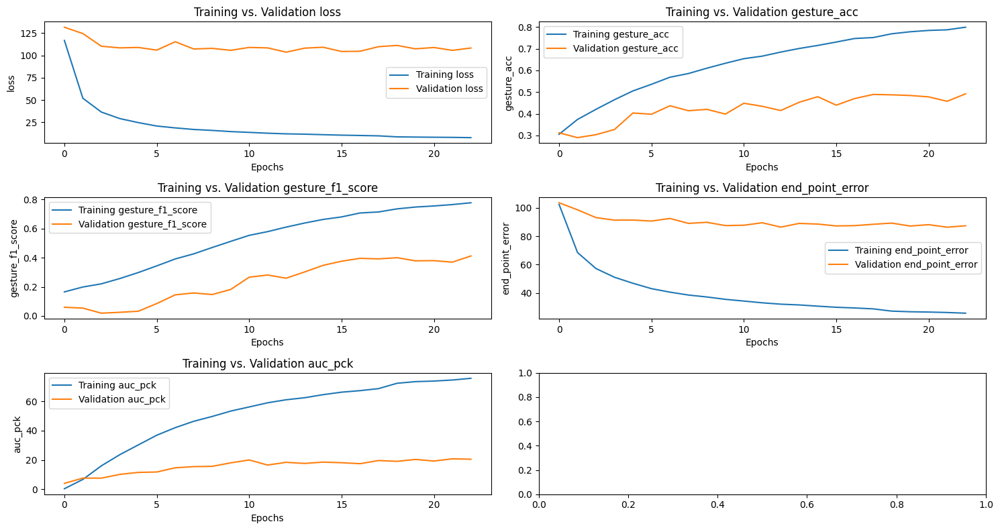

231/231 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.41033968
Gesture F1 Score:  0.16138984686811786
AucPCK :  [ 0.36540803  1.610502    4.84504     9.798348   14.7516575  18.974152
 23.128977  ]
End point error  119.67261846667446
**************************************************
Validation Evaluation
Gesture Accuracy:  0.41483888
Gesture F1 Score:  0.2620971497617865
AucPCK :  [ 2.4235039  7.067425  11.846737  18.29136   24.2215    29.623613
 35.3642   ]
End point error  86.48941518013476
**************************************************
Worst joints : 


{'Pinky_1_x': 24.144140215590294,
 'Pinky_2_x': 23.871881850726332,
 'Thumb_3_x': 22.635818661124894,
 'Ring_1_x': 19.763390281175706,
 'Thumb_2_x': 19.72137158905935,
 'Index_3_x': 19.58912871981366,
 'Middle_3_x': 18.55447565942492,
 'Pinky_3_x': 17.915189191720767,
 'Index_3_z': 17.830482214801503,
 'Ring_2_x': 17.633804473092493,
 'Ring_3_z': 17.407098305498092,
 'Index_2_x': 17.246609136606814,
 'Pinky_3_y': 17.04049828443179,
 'Ring_3_y': 17.014933439262386,
 'Middle_2_x': 16.454560419558398,
 'Ring_3_x': 16.357258555225854,
 'Index_1_y': 15.800949951100879,
 'Pinky_2_y': 15.551352096256071,
 'Middle_3_y': 15.2162225432425,
 'Ring_2_y': 15.156076208780265,
 'Middle_3_z': 14.359989292800938,
 'Middle_1_x': 14.316521800124814,
 'Pinky_3_z': 14.251889958560698,
 'Thumb_0_x': 13.377445772516065,
 'Thumb_1_x': 13.356704428300283,
 'Ring_2_z': 13.31503426834254,
 'Index_3_y': 13.15336644576377,
 'Index_2_y': 13.034254808626796,
 'Middle_1_y': 12.499097104691778,
 'Index_1_x': 12.216626

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower_reg.h5')

Epoch 1/200
693/693 [==============================] - 22s 23ms/step - loss: 127.3144 - end_point_error: 105.7210 - auc_pck: 0.7750 - gesture_acc: 0.2718 - gesture_f1_score: 0.0718 - val_loss: 132.5334 - val_end_point_error: 106.7219 - val_auc_pck: 2.0780 - val_gesture_acc: 0.3413 - val_gesture_f1_score: 0.0150 - lr: 1.0000e-04
Epoch 2/200
693/693 [==============================] - 15s 22ms/step - loss: 86.8603 - end_point_error: 86.3904 - auc_pck: 3.5843 - gesture_acc: 0.3297 - gesture_f1_score: 0.0829 - val_loss: 120.2592 - val_end_point_error: 99.6020 - val_auc_pck: 4.4786 - val_gesture_acc: 0.3510 - val_gesture_f1_score: 0.0150 - lr: 1.0000e-04
Epoch 3/200
693/693 [==============================] - 15s 22ms/step - loss: 66.6734 - end_point_error: 75.3341 - auc_pck: 7.5805 - gesture_acc: 0.3516 - gesture_f1_score: 0.1214 - val_loss: 119.7077 - val_end_point_error: 97.2001 - val_auc_pck: 7.2805 - val_gesture_acc: 0.3320 - val_gesture_f1_score: 0.0000e+00 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


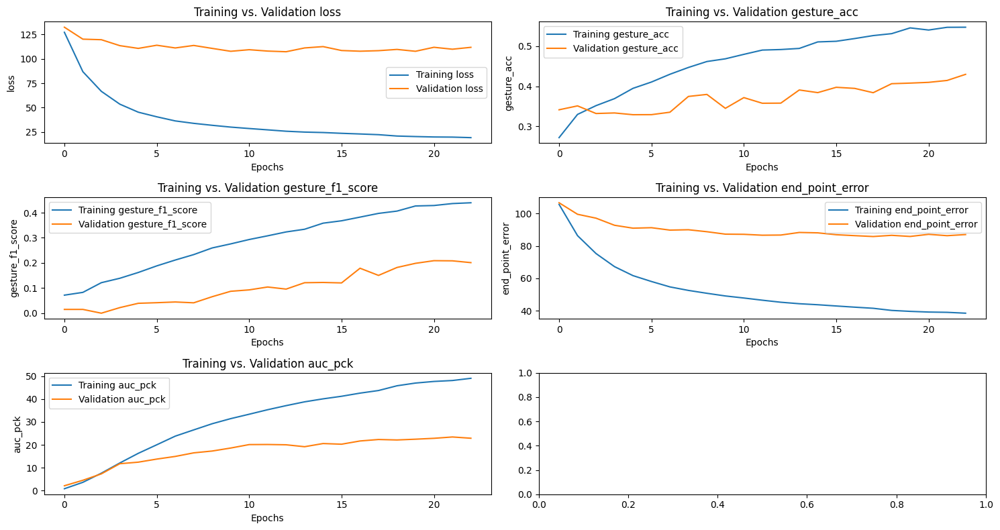

231/231 [==============================] - 1s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.3552578
Gesture F1 Score:  0.09175934053285432
AucPCK :  [ 0.73081607  2.3683853   6.469075   12.288537   17.079443   21.532007
 25.34849   ]
End point error  117.25485540361126
**************************************************
Validation Evaluation
Gesture Accuracy:  0.35783917
Gesture F1 Score:  0.09750986645806546
AucPCK :  [ 1.8683996  6.0926075 12.7538595 20.877337  27.552124  33.04901
 37.8554   ]
End point error  86.77040161129324
**************************************************
Worst joints : 


{'Pinky_1_x': 23.1469318124348,
 'Thumb_3_x': 23.010761773190097,
 'Pinky_2_x': 22.847395303110254,
 'Index_3_x': 19.302135200605786,
 'Thumb_2_x': 19.193661394441857,
 'Ring_1_x': 18.853271570712646,
 'Middle_3_x': 18.593673538545524,
 'Ring_2_x': 17.81970925598148,
 'Index_3_z': 17.766502956120675,
 'Pinky_3_x': 17.749675683348187,
 'Index_2_x': 17.445221798368934,
 'Ring_3_z': 17.40090197172262,
 'Middle_2_x': 16.97681197465622,
 'Pinky_3_y': 16.28611881743278,
 'Ring_3_x': 16.281681881663655,
 'Ring_3_y': 16.130920412018067,
 'Index_1_y': 15.198718643994804,
 'Pinky_2_y': 14.593669944789424,
 'Middle_3_y': 14.389618655764387,
 'Middle_3_z': 14.362620511318392,
 'Ring_2_y': 14.102037149048474,
 'Pinky_3_z': 13.984348805149097,
 'Middle_1_x': 13.798058602918742,
 'Ring_2_z': 13.065338217389593,
 'Index_2_y': 12.860976111430077,
 'Index_3_y': 12.785967635414126,
 'Thumb_1_x': 12.740038699001584,
 'Thumb_0_x': 12.73553956992309,
 'Index_1_x': 12.033730356057589,
 'Middle_1_y': 11.91074

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower80.h5')

Epoch 1/200
924/924 [==============================] - 12s 8ms/step - loss: 113.8433 - end_point_error: 100.9269 - auc_pck: 0.8105 - gesture_acc: 0.2833 - gesture_f1_score: 0.1431 - val_loss: 127.9272 - val_end_point_error: 101.0793 - val_auc_pck: 4.4087 - val_gesture_acc: 0.3484 - val_gesture_f1_score: 0.0188 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 7s 8ms/step - loss: 47.8234 - end_point_error: 65.7309 - auc_pck: 8.9077 - gesture_acc: 0.3735 - gesture_f1_score: 0.1813 - val_loss: 121.1034 - val_end_point_error: 97.0313 - val_auc_pck: 8.6558 - val_gesture_acc: 0.3246 - val_gesture_f1_score: 0.0593 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 7s 7ms/step - loss: 33.6742 - end_point_error: 54.9110 - auc_pck: 19.1234 - gesture_acc: 0.4449 - gesture_f1_score: 0.2295 - val_loss: 114.6500 - val_end_point_error: 91.5019 - val_auc_pck: 14.9755 - val_gesture_acc: 0.4191 - val_gesture_f1_score: 0.1023 - lr: 1.0000e-04
Epoch 4/200
924/924

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


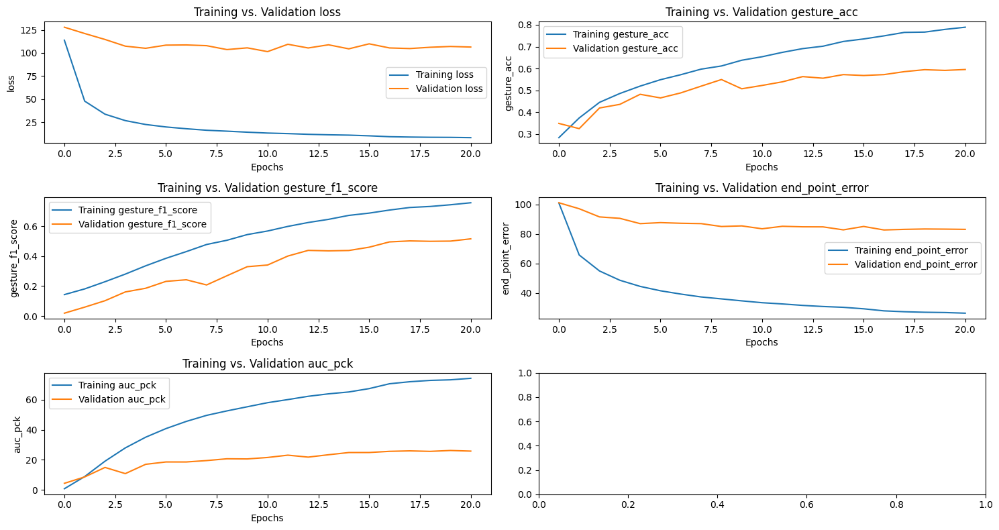

116/116 [==============================] - 0s 2ms/step
Testing Evaluation
Gesture Accuracy:  0.42965573
Gesture F1 Score:  0.23193204095639866
AucPCK :  [ 0.40661427  2.1415017   5.367308    8.837083   12.577934   16.915154
 20.981295  ]
End point error  123.88264758545884
**************************************************
Validation Evaluation
Gesture Accuracy:  0.5220927
Gesture F1 Score:  0.34458031128143357
AucPCK :  [ 4.4998646 10.056927  16.48143   21.686094  27.324476  33.261047
 38.303062 ]
End point error  83.3590480482135
**************************************************
Worst joints : 


{'Pinky_1_x': 23.34349459574911,
 'Pinky_2_x': 23.336870739220988,
 'Thumb_3_x': 22.091557632852332,
 'Ring_3_z': 20.837079427563832,
 'Index_3_z': 19.712900501733962,
 'Middle_3_x': 19.57093954431489,
 'Index_3_x': 19.226994436993056,
 'Ring_2_x': 19.195044430519683,
 'Thumb_2_x': 19.189321021089405,
 'Ring_1_x': 18.804541482600314,
 'Pinky_3_x': 18.640618369630147,
 'Index_2_x': 17.65215918583226,
 'Middle_2_x': 17.477308517120523,
 'Middle_3_z': 17.23277338748319,
 'Ring_3_x': 17.160999722004437,
 'Pinky_3_z': 16.666451992980907,
 'Ring_3_y': 16.438654823652126,
 'Pinky_3_y': 16.300530216355792,
 'Index_1_y': 16.014697396383347,
 'Ring_2_z': 15.951522662476778,
 'Pinky_2_y': 15.45473641224767,
 'Middle_3_y': 14.952728414094462,
 'Ring_2_y': 14.483908652555575,
 'Middle_1_x': 14.179337976775695,
 'Index_3_y': 14.056285058174284,
 'Pinky_2_z': 13.729214106691309,
 'Middle_2_z': 13.514728271732034,
 'Index_2_y': 13.362506145873065,
 'Index_2_z': 13.314302112648539,
 'Thumb_0_x': 13.130

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

In [ ]:
model = create_skeleton_gesture_reg3dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.8, seed)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta),
                  metrics=[un_epe(mean, std), un_pck(mean,std), compute_acc(dim2=False), compute_f1_score(dim2=False)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'3d_models/without_wrist/filter_cap_img/mean_lower80_reg.h5')

Epoch 1/200
924/924 [==============================] - 37s 22ms/step - loss: 125.2583 - end_point_error: 104.2911 - auc_pck: 1.1451 - gesture_acc: 0.3077 - gesture_f1_score: 0.0634 - val_loss: 152.1030 - val_end_point_error: 109.8914 - val_auc_pck: 3.9644 - val_gesture_acc: 0.2355 - val_gesture_f1_score: 5.2247e-04 - lr: 1.0000e-04
Epoch 2/200
924/924 [==============================] - 19s 21ms/step - loss: 84.8667 - end_point_error: 85.0752 - auc_pck: 4.4653 - gesture_acc: 0.3506 - gesture_f1_score: 0.0838 - val_loss: 135.9786 - val_end_point_error: 101.9888 - val_auc_pck: 9.3630 - val_gesture_acc: 0.4177 - val_gesture_f1_score: 0.0310 - lr: 1.0000e-04
Epoch 3/200
924/924 [==============================] - 19s 21ms/step - loss: 61.6240 - end_point_error: 72.0894 - auc_pck: 9.6967 - gesture_acc: 0.3806 - gesture_f1_score: 0.1288 - val_loss: 122.0080 - val_end_point_error: 94.4598 - val_auc_pck: 12.0955 - val_gesture_acc: 0.4781 - val_gesture_f1_score: 0.0233 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


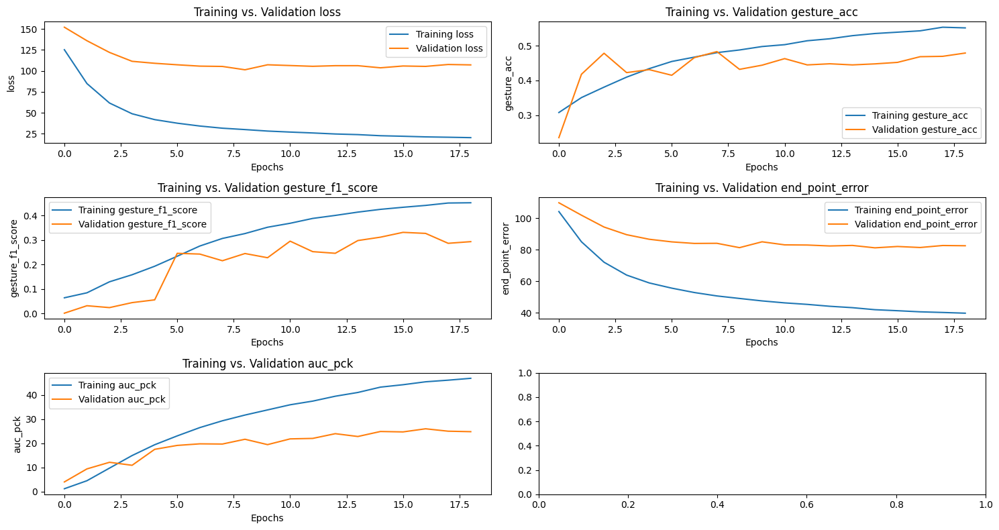

116/116 [==============================] - 1s 5ms/step
Testing Evaluation
Gesture Accuracy:  0.4185416
Gesture F1 Score:  0.11461174333423745
AucPCK :  [ 1.1656275  2.4939008  5.042017   9.812958  14.231499  19.896992
 24.125778 ]
End point error  120.42497359164061
**************************************************
Validation Evaluation
Gesture Accuracy:  0.42965573
Gesture F1 Score:  0.24624352378205266
AucPCK :  [ 3.686636  8.593115 15.857956 22.065601 28.137707 34.23692  39.60423 ]
End point error  81.29721119939194
**************************************************
Worst joints : 


{'Pinky_1_x': 23.11050041628918,
 'Pinky_2_x': 23.06483565343732,
 'Thumb_3_x': 21.72583204138416,
 'Ring_3_z': 19.518096498329886,
 'Index_3_z': 19.389961589954773,
 'Ring_1_x': 18.759860222209586,
 'Middle_3_x': 18.740439552212194,
 'Ring_2_x': 18.577082003033958,
 'Index_3_x': 18.47194727914824,
 'Thumb_2_x': 18.389235048490445,
 'Pinky_3_x': 18.211604669416083,
 'Index_2_x': 17.075812796077102,
 'Ring_3_x': 16.927082038542974,
 'Middle_2_x': 16.836769076223796,
 'Middle_3_z': 16.63420867387762,
 'Ring_3_y': 16.420197878206583,
 'Pinky_3_y': 16.266402824717545,
 'Pinky_3_z': 15.74083351680575,
 'Ring_2_z': 15.206652145739216,
 'Middle_3_y': 15.0584819548848,
 'Index_1_y': 15.013816332666927,
 'Pinky_2_y': 14.542200354252964,
 'Ring_2_y': 13.951701892396825,
 'Middle_1_x': 13.7438372325772,
 'Index_3_y': 13.431321531338918,
 'Middle_2_z': 13.199621651622538,
 'Pinky_2_z': 13.012235371044877,
 'Index_2_z': 12.98704649932588,
 'Index_2_y': 12.833307522874845,
 'Thumb_0_x': 12.318141303

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

## Comparison with other axis, and other possible normalizations for 2d models

### 2d model removing x

#### Keeping wrist

**with global scalar normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='x', norm_skel='all')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[5.1638336, 2.88067], [-0.0485416, -0.1787883...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[5.166547, 2.8755662], [-0.050436962, -0.1780...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[5.167641, 2.8692052], [-0.053913914, -0.1752...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[5.165918, 2.86145], [-0.05812578, -0.1719615...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[5.161015, 2.8528025], [-0.06594879, -0.16366...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[4.829592, 2.999549], [-0.015644057, -0.03826...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[4.8332705, 2.9953105], [-0.012277883, -0.035...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[4.8175306, 2.9963098], [-0.020904131, -0.043...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[4.817953, 3.2017353], [0.03469386, -0.066885...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_x_allNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 38s 14ms/step - loss: 683.8220 - end_point_error: 245.3538 - auc_pck: 0.0000e+00 - gesture_acc: 0.2838 - gesture_f1_score: 0.1466 - val_loss: 118.7076 - val_end_point_error: 104.7334 - val_auc_pck: 0.1030 - val_gesture_acc: 0.2647 - val_gesture_f1_score: 0.0042 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 172.0843 - end_point_error: 126.6920 - auc_pck: 0.0085 - gesture_acc: 0.3093 - gesture_f1_score: 0.0709 - val_loss: 90.1502 - val_end_point_error: 88.9621 - val_auc_pck: 1.0910 - val_gesture_acc: 0.2895 - val_gesture_f1_score: 8.3677e-04 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 98.5632 - end_point_error: 95.2986 - auc_pck: 0.5160 - gesture_acc: 0.3290 - gesture_f1_score: 0.0568 - val_loss: 83.2942 - val_end_point_error: 83.4690 - val_auc_pck: 5.1617 - val_gesture_acc: 0.3140 - val_gesture_f1_score: 0.0043 - lr: 1.0000e-04
Ep

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


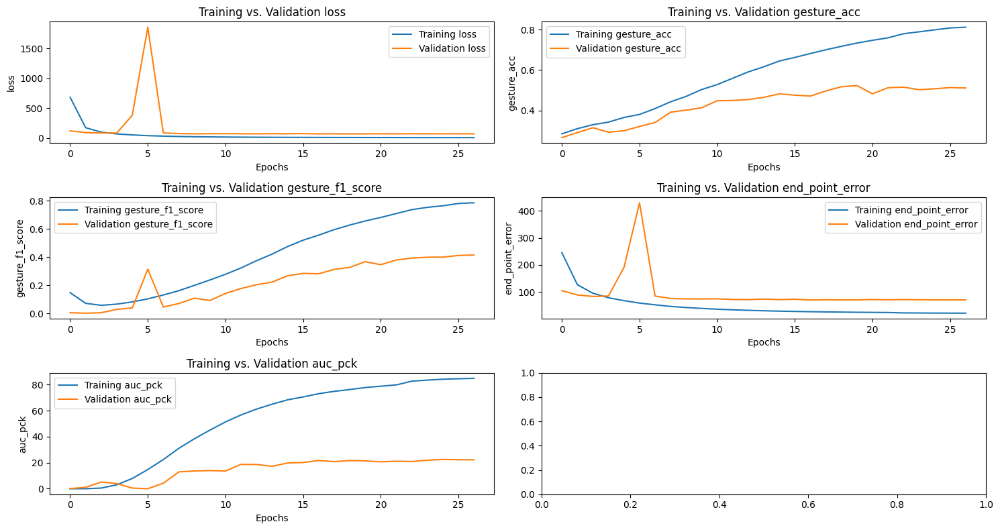

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.35765025
Gesture F1 Score:  0.17423408
AucPCK :  [ 1.0377417  2.6623015  5.627278  10.673914  15.664957  21.242819
 26.92569  ]
End point error  99.84596
**************************************************
Validation Evaluation
Gesture Accuracy:  0.47208843
Gesture F1 Score:  0.2850743
AucPCK :  [ 2.92701    7.4101524 14.239841  21.298012  28.695812  35.506977
 41.6327   ]
End point error  70.353226
**************************************************
Worst joints : 


{'wrist_z': 31.186659,
 'Ring_3_z': 21.407803,
 'Index_3_z': 21.10263,
 'Middle_3_z': 20.858183,
 'Pinky_3_z': 16.490202,
 'Pinky_3_y': 16.14343,
 'Ring_3_y': 16.077621,
 'Ring_2_z': 15.9568815,
 'Middle_2_z': 15.207666,
 'Pinky_2_y': 14.924832,
 'Middle_3_y': 14.625312,
 'Ring_2_y': 14.465326,
 'Thumb_3_z': 14.173413,
 'Index_2_z': 14.149781,
 'Index_3_y': 14.003249,
 'Index_1_y': 13.747542,
 'Index_2_y': 13.713604,
 'Pinky_2_z': 13.010706,
 'Middle_2_y': 12.223589,
 'Middle_1_y': 11.561541,
 'wrist_y': 11.231829,
 'Thumb_3_y': 11.148988,
 'Thumb_2_z': 10.026084,
 'Pinky_1_y': 9.866684,
 'Pinky_1_z': 9.489546,
 'Ring_1_y': 9.452921,
 'Thumb_2_y': 8.900529,
 'Ring_1_z': 8.43468,
 'Index_0_y': 8.295358,
 'Middle_1_z': 7.2766447,
 'Index_1_z': 6.917526,
 'Thumb_0_y': 6.752266,
 'Thumb_1_y': 6.7305374,
 'Middle_0_y': 6.708189,
 'Thumb_0_z': 5.502872,
 'Thumb_1_z': 5.487731,
 'Ring_0_y': 5.1292014,
 'Pinky_0_y': 3.7078092,
 'Pinky_0_z': 3.5684767,
 'Index_0_z': 3.0529203,
 'Ring_0_z': 2.71

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per joint normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='x', norm_skel='joint')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[1.9029354711708684, 0.7795498971441778], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[1.9189654108251444, 0.7710513558682875], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[1.9254321652576158, 0.7604587532195456], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[1.9152491172614103, 0.7475449684553396], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[1.88628278565952, 0.7331453508544011], [-0.9...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.07177722619295937, 0.9775049234994947], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.050044549014194604, 0.9704471159504442], ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.14303549750502492, 0.9721109074370231], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.14054163099406292, 1.3141819677964832], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_x_jointNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 67.7916 - end_point_error: 77.2299 - auc_pck: 5.1954 - gesture_acc: 0.2879 - gesture_f1_score: 0.1402 - val_loss: 69.1146 - val_end_point_error: 74.3895 - val_auc_pck: 11.8317 - val_gesture_acc: 0.2929 - val_gesture_f1_score: 0.0140 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 30.8989 - end_point_error: 51.7684 - auc_pck: 24.0258 - gesture_acc: 0.3619 - gesture_f1_score: 0.1736 - val_loss: 67.7561 - val_end_point_error: 72.4538 - val_auc_pck: 15.1874 - val_gesture_acc: 0.3439 - val_gesture_f1_score: 0.1336 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 21.9735 - end_point_error: 43.2872 - auc_pck: 38.1863 - gesture_acc: 0.4393 - gesture_f1_score: 0.2220 - val_loss: 67.9653 - val_end_point_error: 72.6015 - val_auc_pck: 15.4084 - val_gesture_acc: 0.4164 - val_gesture_f1_score: 0.1183 - lr: 1.0000e-04
Epoch 4/200

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


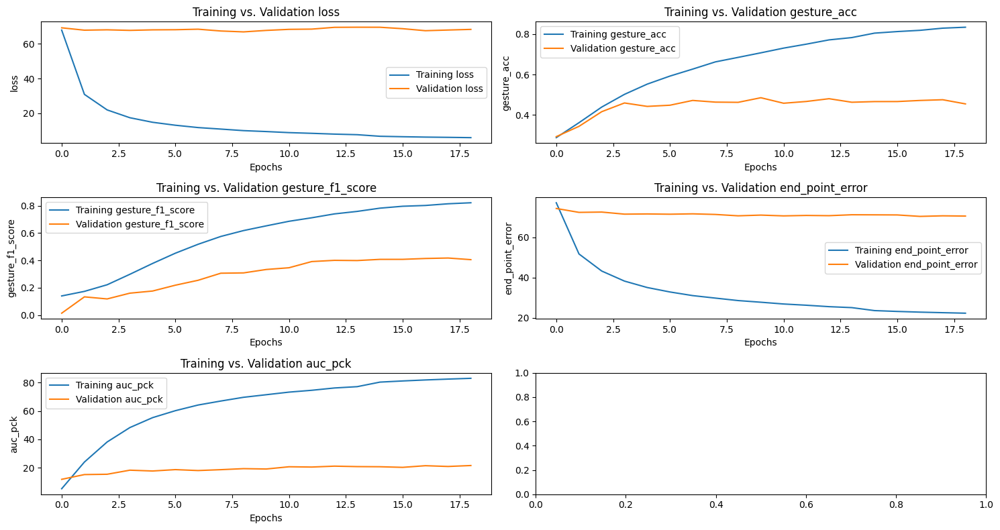

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.31576997
Gesture F1 Score:  0.18745551828535326
AucPCK :  [ 0.8400766  2.8846748  5.5902157  9.370561  13.929211  18.944962
 24.251036 ]
End point error  100.34055666724485
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4626405
Gesture F1 Score:  0.3133180394304421
AucPCK :  [ 3.322218  7.243423 12.319378 18.315426 24.626406 31.165865 38.37841 ]
End point error  70.79728211019497
**************************************************
Worst joints : 


{'wrist_z': 31.979941617446087,
 'Index_3_z': 21.466694128878597,
 'Ring_3_z': 21.34240072615443,
 'Middle_3_z': 20.541653352718267,
 'Pinky_3_z': 16.505837069978643,
 'Ring_2_z': 15.970130111252795,
 'Ring_3_y': 15.86765159878448,
 'Pinky_3_y': 15.803562003550745,
 'Middle_2_z': 15.193630138436031,
 'Pinky_2_y': 14.76486202922114,
 'Index_2_z': 14.585681791045564,
 'Middle_3_y': 14.391995700785635,
 'Ring_2_y': 14.24382874219858,
 'Thumb_3_z': 14.24319384639145,
 'Index_2_y': 13.922260843446288,
 'Index_3_y': 13.913180855676341,
 'Index_1_y': 13.872188081789195,
 'Pinky_2_z': 13.119414487244988,
 'Middle_2_y': 12.187079089098896,
 'Middle_1_y': 11.533706773868023,
 'Thumb_3_y': 11.344956117106019,
 'wrist_y': 10.786424201056438,
 'Thumb_2_z': 10.0980165632708,
 'Pinky_1_y': 9.97620083879999,
 'Pinky_1_z': 9.717883629917171,
 'Ring_1_y': 9.625279566845656,
 'Thumb_2_y': 9.03590202901165,
 'Ring_1_z': 8.68765021201094,
 'Index_0_y': 8.27987198968517,
 'Middle_1_z': 7.588726228461348,
 '

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per axis normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='x', norm_skel='axis')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[95.35883385764362, 23.165614336319447], [-9....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[95.41351286060464, 23.129924313843347], [-9....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[95.435571314497, 23.08544018246818], [-9.792...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[95.40083637952249, 23.031208137988553], [-9....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[95.30203063442369, 22.970736268859355], [-10...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[88.62298058838256, 23.996935749080144], [-9....","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[88.69711194167755, 23.9672961554275], [-8.95...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[88.37991471838535, 23.97428332576931], [-9.1...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[88.38842143377407, 25.4108267790896], [-8.00...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_x_axisNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 13ms/step - loss: 314.6115 - end_point_error: 159.0013 - auc_pck: 0.5026 - gesture_acc: 0.2807 - gesture_f1_score: 0.1898 - val_loss: 96.9320 - val_end_point_error: 87.6853 - val_auc_pck: 6.5652 - val_gesture_acc: 0.2362 - val_gesture_f1_score: 0.0553 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 87.9670 - end_point_error: 88.4574 - auc_pck: 2.7194 - gesture_acc: 0.3196 - gesture_f1_score: 0.2205 - val_loss: 86.6095 - val_end_point_error: 84.0810 - val_auc_pck: 9.1073 - val_gesture_acc: 0.3122 - val_gesture_f1_score: 0.0570 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 66.8543 - end_point_error: 77.1053 - auc_pck: 5.9518 - gesture_acc: 0.3576 - gesture_f1_score: 0.2497 - val_loss: 85.4534 - val_end_point_error: 85.4877 - val_auc_pck: 4.3586 - val_gesture_acc: 0.3375 - val_gesture_f1_score: 0.1181 - lr: 1.0000e-04
Epoch 4/200
15

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


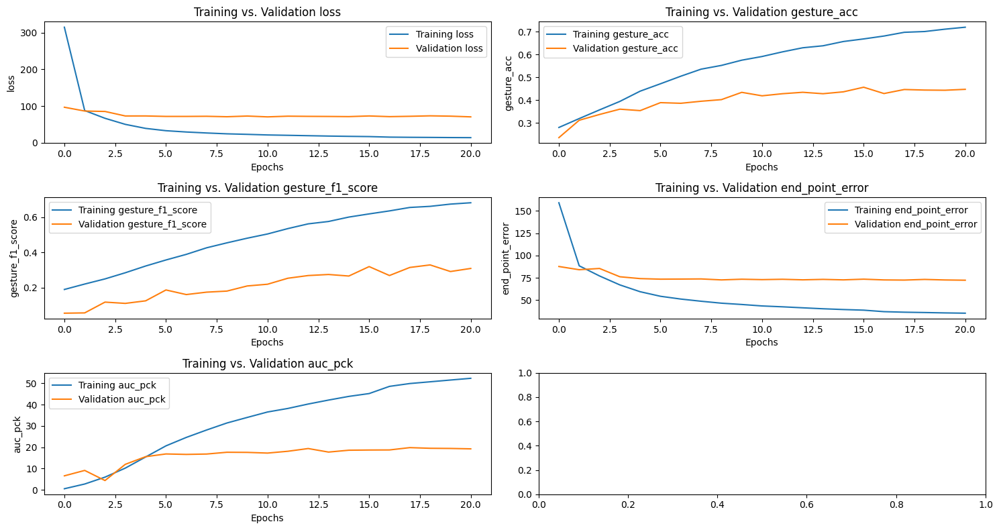

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.3404781
Gesture F1 Score:  0.14662906999258835
AucPCK :  [ 0.64241153  1.636914    4.725431    8.660202   13.2744465  18.22225
 23.021805  ]
End point error  100.85421781699692
**************************************************
Validation Evaluation
Gesture Accuracy:  0.41811782
Gesture F1 Score:  0.22182642504446776
AucPCK :  [ 1.6425837  4.4090405  8.9168825 15.524268  22.86032   29.98024
 37.526245 ]
End point error  73.04365298212191
**************************************************
Worst joints : 


{'wrist_z': 34.881300885126784,
 'Index_3_z': 20.958148770828,
 'Ring_3_z': 20.192557530813005,
 'Middle_3_z': 19.667294504410254,
 'Pinky_3_z': 16.013028645196346,
 'Ring_3_y': 15.766972691153024,
 'Pinky_3_y': 15.742393442545978,
 'Ring_2_z': 15.358656050837986,
 'Middle_2_z': 14.766525743835098,
 'Pinky_2_y': 14.704596486525247,
 'Ring_2_y': 14.445410558859784,
 'Index_2_z': 14.322587940069152,
 'Middle_3_y': 14.275948354326044,
 'Thumb_3_z': 14.156295845892712,
 'Index_3_y': 14.034361586164232,
 'Index_2_y': 13.86037726877262,
 'Index_1_y': 13.684681252646937,
 'wrist_y': 13.310997088036915,
 'Pinky_2_z': 12.88493361657987,
 'Middle_2_y': 12.240785258484118,
 'Middle_1_y': 11.502079949414096,
 'Thumb_3_y': 11.446178167153489,
 'Thumb_2_z': 10.05545923990086,
 'Pinky_1_y': 9.672048242579582,
 'Ring_1_y': 9.471001732287425,
 'Pinky_1_z': 9.434717209104065,
 'Thumb_2_y': 9.05572468961577,
 'Ring_1_z': 8.352179841832507,
 'Index_0_y': 8.117529645560928,
 'Middle_1_z': 7.214340475755742

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

#### Without wrist

**with global scalar normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='x', norm_skel='all')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.7948007, 0.7948007], [0.21528204, -0.03480...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7948007, 0.7948007], [0.21164273, -0.03344...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7948007, 0.7948007], [0.20496657, -0.02805...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7948007, 0.7948007], [0.1968793, -0.021698...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7948007, 0.7948007], [0.1818582, -0.005774...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.7948007, 0.7948007], [0.27844918, 0.235022...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.7948007, 0.7948007], [0.28491262, 0.239647...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.7948007, 0.7948007], [0.26834923, 0.225377...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.7948007, 0.7948007], [0.37510386, 0.180059...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_x_allNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 191.5832 - end_point_error: 130.3817 - auc_pck: 0.0475 - gesture_acc: 0.2948 - gesture_f1_score: 0.1384 - val_loss: 86.7550 - val_end_point_error: 89.0384 - val_auc_pck: 1.1958 - val_gesture_acc: 0.2954 - val_gesture_f1_score: 0.0011 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 62.0600 - end_point_error: 75.4851 - auc_pck: 3.3570 - gesture_acc: 0.3351 - gesture_f1_score: 0.0884 - val_loss: 85.5660 - val_end_point_error: 84.5770 - val_auc_pck: 3.7106 - val_gesture_acc: 0.3131 - val_gesture_f1_score: 0.0066 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 39.8981 - end_point_error: 59.7183 - auc_pck: 13.5377 - gesture_acc: 0.3725 - gesture_f1_score: 0.0887 - val_loss: 63.8523 - val_end_point_error: 71.1759 - val_auc_pck: 15.6206 - val_gesture_acc: 0.3110 - val_gesture_f1_score: 0.0090 - lr: 1.0000e-04
Epoch 4/200


/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


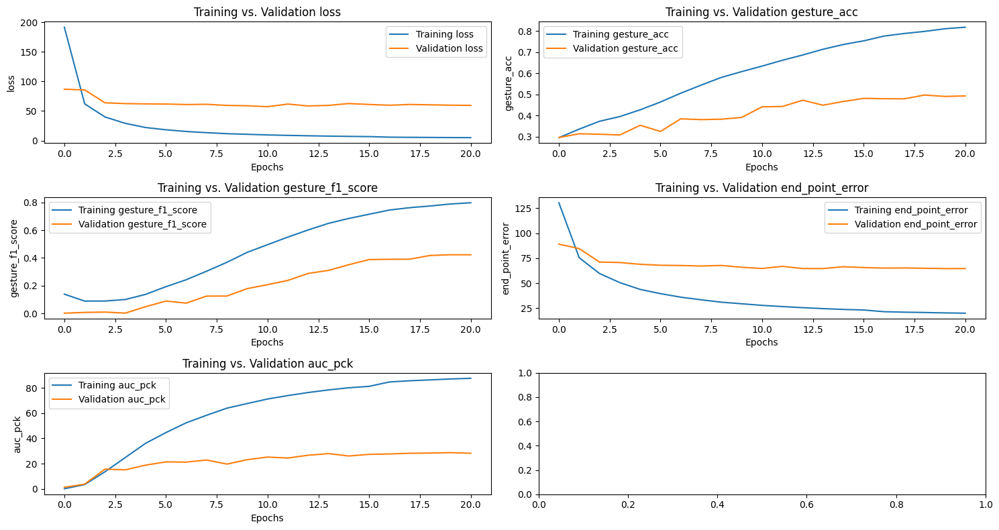

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.35536474
Gesture F1 Score:  0.1435886
AucPCK :  [ 2.2546175  6.671196  11.03836   16.640928  22.404102  28.130213
 33.22009  ]
End point error  88.55418
**************************************************
Validation Evaluation
Gesture Accuracy:  0.4408423
Gesture F1 Score:  0.21035694
AucPCK :  [ 3.865629  8.997159 16.110907 24.3053   33.092506 41.218967 48.332714]
End point error  64.78663
**************************************************
Worst joints : 


{'Index_3_z': 21.418444,
 'Ring_3_z': 20.744713,
 'Middle_3_z': 20.058382,
 'Pinky_3_z': 16.406187,
 'Ring_3_y': 15.703831,
 'Ring_2_z': 15.679658,
 'Pinky_3_y': 15.576947,
 'Middle_2_z': 15.114949,
 'Index_2_z': 14.573319,
 'Pinky_2_y': 14.50006,
 'Middle_3_y': 14.357316,
 'Index_3_y': 14.187185,
 'Index_2_y': 14.060083,
 'Thumb_3_z': 14.027881,
 'Ring_2_y': 13.912003,
 'Index_1_y': 13.7393675,
 'Pinky_2_z': 12.95018,
 'Middle_2_y': 12.061992,
 'Thumb_3_y': 11.532426,
 'Middle_1_y': 11.380612,
 'Thumb_2_z': 9.865121,
 'Pinky_1_y': 9.587774,
 'Ring_1_y': 9.450182,
 'Pinky_1_z': 9.317441,
 'Thumb_2_y': 9.211663,
 'Ring_1_z': 8.276324,
 'Index_0_y': 8.211538,
 'Middle_1_z': 7.1378903,
 'Index_1_z': 6.9266844,
 'Thumb_1_y': 6.9201126,
 'Thumb_0_y': 6.8497157,
 'Middle_0_y': 6.6345806,
 'Thumb_0_z': 5.5319324,
 'Thumb_1_z': 5.5027046,
 'Ring_0_y': 5.123675,
 'Pinky_0_y': 3.7292778,
 'Pinky_0_z': 3.6294036,
 'Index_0_z': 2.9976013,
 'Ring_0_z': 2.7429547,
 'Middle_0_z': 2.1000867,
 'wrist_z

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per joint normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='x', norm_skel='joint')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-0.8411842005698658, -0.66334736...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-0.856800939635355, -0.657283824...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-0.8854490513350487, -0.63328413...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-0.9201524691708463, -0.60498760...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-0.9846097152982555, -0.53409194...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [-0.5701268248332824, 0.537976303...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [-0.5423914319203718, 0.558567730...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [-0.6134668944488612, 0.495033001...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [-0.1553705208110349, 0.293269562...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_x_jointNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 56.0929 - end_point_error: 69.4787 - auc_pck: 9.8606 - gesture_acc: 0.3162 - gesture_f1_score: 0.1889 - val_loss: 59.6836 - val_end_point_error: 68.4058 - val_auc_pck: 15.9755 - val_gesture_acc: 0.3105 - val_gesture_f1_score: 0.0777 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 25.0393 - end_point_error: 46.1875 - auc_pck: 33.3434 - gesture_acc: 0.3943 - gesture_f1_score: 0.2185 - val_loss: 58.2533 - val_end_point_error: 66.1599 - val_auc_pck: 21.4717 - val_gesture_acc: 0.3941 - val_gesture_f1_score: 0.1171 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 17.8215 - end_point_error: 38.5725 - auc_pck: 47.8763 - gesture_acc: 0.4622 - gesture_f1_score: 0.2594 - val_loss: 56.4354 - val_end_point_error: 65.6393 - val_auc_pck: 21.5369 - val_gesture_acc: 0.4086 - val_gesture_f1_score: 0.0908 - lr: 1.0000e-04
Epoch 4/200

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


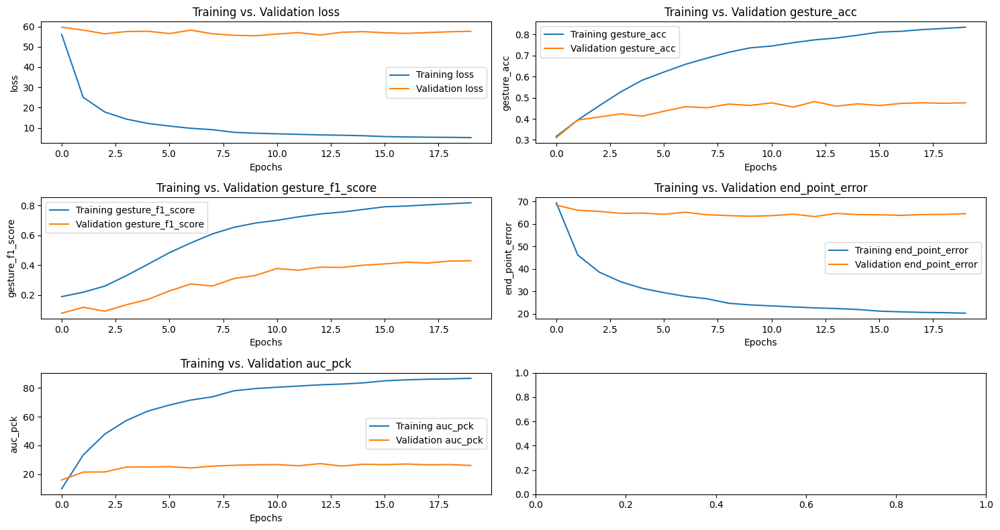

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.37513125
Gesture F1 Score:  0.22195129728021987
AucPCK :  [ 2.2916796  5.0898757  9.327321  14.53456   20.433626  26.25857
 31.935266 ]
End point error  90.717327813255
**************************************************
Validation Evaluation
Gesture Accuracy:  0.463258
Gesture F1 Score:  0.33548555446715056
AucPCK :  [ 7.280474 12.541681 19.037916 25.614426 32.74052  40.41003  47.84488 ]
End point error  63.519721491320055
**************************************************
Worst joints : 


{'Ring_3_z': 21.642727629984144,
 'Index_3_z': 21.473934981002934,
 'Middle_3_z': 21.02233207386568,
 'Pinky_3_z': 16.88398342484051,
 'Ring_2_z': 16.118528299112857,
 'Ring_3_y': 15.943733781674418,
 'Pinky_3_y': 15.904028413635965,
 'Middle_2_z': 15.432254369229566,
 'Pinky_2_y': 14.978834824156172,
 'Middle_3_y': 14.752855299988848,
 'Index_2_z': 14.60540406192538,
 'Ring_2_y': 14.498299527388752,
 'Thumb_3_z': 14.388614189149244,
 'Index_1_y': 14.181812843396036,
 'Index_3_y': 14.100464180645854,
 'Index_2_y': 13.878930741527576,
 'Pinky_2_z': 13.270842405650425,
 'Middle_2_y': 12.381586160516653,
 'Middle_1_y': 12.024522890783482,
 'Thumb_3_y': 11.360430329881417,
 'Thumb_2_z': 10.217719828242853,
 'Pinky_1_y': 10.164330553537956,
 'Ring_1_y': 10.059185695167066,
 'Pinky_1_z': 9.652389419095273,
 'Thumb_2_y': 9.047015547134539,
 'Ring_1_z': 8.67079469661091,
 'Index_0_y': 8.310995639304723,
 'Middle_1_z': 7.619977930020163,
 'Index_1_z': 7.230479074629337,
 'Middle_0_y': 6.8620339

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per axis normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='x', norm_skel='axis')
chili_data

Dimension removed from capacitive images : x
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-6.3443135120105385, 4.417280444...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-6.390200384610536, 4.4260803520...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-6.474377513157135, 4.4609106711...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-6.576347028453372, 4.5019769068...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-6.765742614099761, 4.6048665048...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [-5.547862380318592, 6.1607398239...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [-5.466367105551654, 6.1906237896...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [-5.6752090846840355, 6.098416982...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [-4.329178402638976, 5.8056013421...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_x_axisNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 50.2767 - end_point_error: 64.6883 - auc_pck: 16.1744 - gesture_acc: 0.3634 - gesture_f1_score: 0.2952 - val_loss: 57.8674 - val_end_point_error: 67.4173 - val_auc_pck: 16.9713 - val_gesture_acc: 0.3611 - val_gesture_f1_score: 0.1933 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 20.2574 - end_point_error: 41.6414 - auc_pck: 40.9849 - gesture_acc: 0.5249 - gesture_f1_score: 0.4537 - val_loss: 56.0750 - val_end_point_error: 65.3994 - val_auc_pck: 21.5351 - val_gesture_acc: 0.4207 - val_gesture_f1_score: 0.2812 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 14.6230 - end_point_error: 35.2044 - auc_pck: 54.4946 - gesture_acc: 0.6269 - gesture_f1_score: 0.5734 - val_loss: 54.4555 - val_end_point_error: 64.6867 - val_auc_pck: 22.1295 - val_gesture_acc: 0.4755 - val_gesture_f1_score: 0.3411 - lr: 1.0000e-04
Epoch 4/20

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


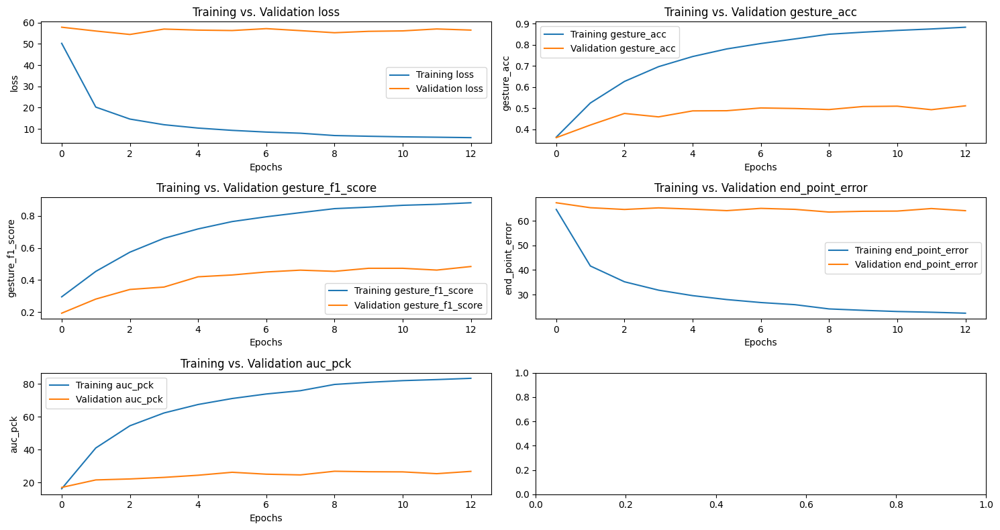

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.40595466
Gesture F1 Score:  0.25235641131825076
AucPCK :  [ 0.88949287  3.7926986   8.456359   13.867441   19.902403   25.609982
 32.13293   ]
End point error  88.79727366226352
**************************************************
Validation Evaluation
Gesture Accuracy:  0.475423
Gesture F1 Score:  0.34492611341928353
AucPCK :  [ 2.4885762  6.5332837 12.868963  20.408792  29.214525  37.575645
 45.26985  ]
End point error  64.75460149507447
**************************************************
Worst joints : 


{'Index_3_z': 21.351000935711255,
 'Ring_3_z': 20.543240161013724,
 'Middle_3_z': 19.34410019308626,
 'Pinky_3_z': 16.34452623555347,
 'Ring_3_y': 15.819829007632292,
 'Pinky_3_y': 15.769028487079638,
 'Ring_2_z': 15.416634525232562,
 'Middle_2_z': 14.78644532993632,
 'Pinky_2_y': 14.784534576955705,
 'Thumb_3_z': 14.746432056534411,
 'Index_2_z': 14.620467085117305,
 'Middle_3_y': 14.367506834948353,
 'Ring_2_y': 14.198249516513,
 'Index_1_y': 14.074628389088135,
 'Index_3_y': 13.975652812779497,
 'Index_2_y': 13.719468296489989,
 'Pinky_2_z': 12.727004794462733,
 'Middle_2_y': 12.18953723016562,
 'Middle_1_y': 11.773671741098271,
 'Thumb_3_y': 11.220014773729151,
 'Thumb_2_z': 10.349616063825527,
 'Pinky_1_y': 9.873004343893625,
 'Ring_1_y': 9.863409364064585,
 'Pinky_1_z': 9.520223850276565,
 'Thumb_2_y': 9.01081109038799,
 'Index_0_y': 8.365921545586843,
 'Ring_1_z': 8.24443188706692,
 'Middle_1_z': 7.410150966611735,
 'Index_1_z': 7.234529287610589,
 'Middle_0_y': 6.84579204825644

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

### 2d model removing y

#### Keeping wrist

**with global scalar normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='y', norm_skel='all')
chili_data

Dimension removed from capacitive images : y
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-3.448152, 2.927624], [0.3440638, -0.1168178...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[-3.4447608, 2.9225454], [0.34184945, -0.1161...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[-3.442072, 2.9162154], [0.3393569, -0.113318...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[-3.4379466, 2.9084983], [0.3356394, -0.11002...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[-3.4398034, 2.8998933], [0.3311146, -0.10177...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-4.281627, 3.0459194], [0.74564815, 0.023020...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-4.286246, 3.0417018], [0.7484272, 0.0254170...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-4.2768736, 3.042696], [0.7415273, 0.0180214...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-4.288622, 3.2471135], [0.7501292, -0.005464...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_y_allNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 670.3162 - end_point_error: 243.6064 - auc_pck: 0.0000e+00 - gesture_acc: 0.3033 - gesture_f1_score: 0.1512 - val_loss: 187.3736 - val_end_point_error: 128.4564 - val_auc_pck: 0.0053 - val_gesture_acc: 0.2978 - val_gesture_f1_score: 0.0024 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 196.6496 - end_point_error: 134.9825 - auc_pck: 0.0032 - gesture_acc: 0.3276 - gesture_f1_score: 0.0822 - val_loss: 178.7551 - val_end_point_error: 124.7245 - val_auc_pck: 0.2087 - val_gesture_acc: 0.2946 - val_gesture_f1_score: 0.0000e+00 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 114.1013 - end_point_error: 102.2218 - auc_pck: 0.2741 - gesture_acc: 0.3391 - gesture_f1_score: 0.0748 - val_loss: 167.4481 - val_end_point_error: 120.2429 - val_auc_pck: 0.6084 - val_gesture_acc: 0.2978 - val_gesture_f1_score: 0.0184 - lr: 1.0000e

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


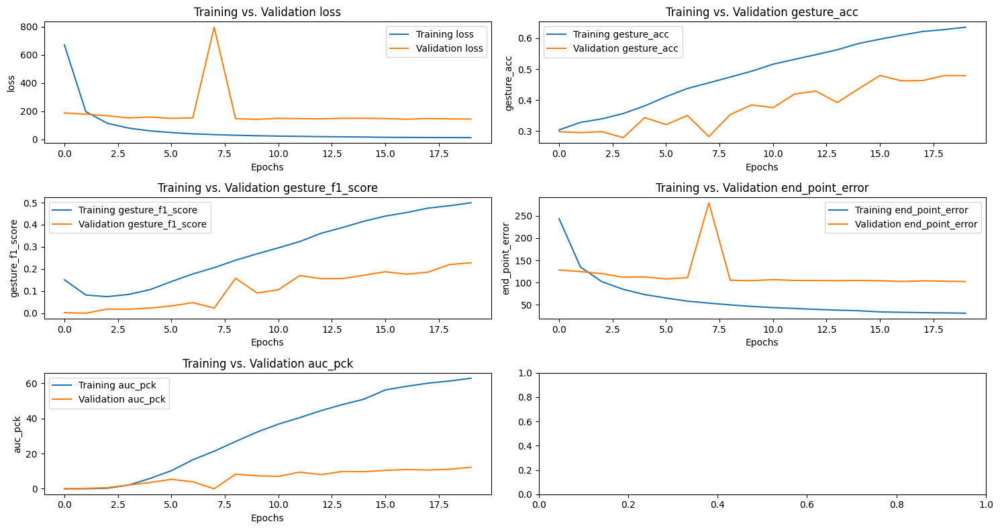

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.33998394
Gesture F1 Score:  0.057666045
AucPCK :  [0.04323924 0.23472728 0.75977516 1.7851628  3.0205696  4.725431
 7.325962  ]
End point error  136.5049
**************************************************
Validation Evaluation
Gesture Accuracy:  0.38396937
Gesture F1 Score:  0.09371504
AucPCK :  [ 0.5742868  1.6796345  3.3469186  6.490058   9.565271  13.017167
 16.821045 ]
End point error  104.47487
**************************************************
Worst joints : 


{'wrist_z': 44.353397,
 'wrist_x': 35.873047,
 'Pinky_2_z': 26.276978,
 'Pinky_1_z': 24.750204,
 'Thumb_3_z': 22.88147,
 'Ring_2_z': 22.741816,
 'Index_3_x': 21.965292,
 'Index_3_z': 21.770248,
 'Middle_2_z': 21.537958,
 'Middle_3_z': 21.366966,
 'Pinky_3_z': 21.36286,
 'Ring_1_z': 21.35606,
 'Index_2_z': 21.050688,
 'Ring_3_x': 20.853207,
 'Ring_3_z': 20.780014,
 'Middle_3_x': 20.01531,
 'Thumb_2_z': 18.556234,
 'Middle_1_z': 16.823711,
 'Pinky_3_x': 16.07392,
 'Ring_2_x': 15.7327795,
 'Middle_2_x': 15.315848,
 'Index_1_z': 15.204086,
 'Index_2_x': 14.563081,
 'Thumb_3_x': 14.487651,
 'Pinky_2_x': 12.978757,
 'Thumb_0_z': 11.858369,
 'Thumb_1_z': 11.785169,
 'Thumb_2_x': 10.14337,
 'Pinky_1_x': 9.632733,
 'Pinky_0_z': 9.273484,
 'Ring_1_x': 8.364927,
 'Ring_0_z': 7.451318,
 'Middle_1_x': 7.1701775,
 'Index_1_x': 6.762162,
 'Index_0_z': 5.8181896,
 'Thumb_1_x': 5.5525403,
 'Thumb_0_x': 5.5092297,
 'Middle_0_z': 4.4765477,
 'Pinky_0_x': 3.6513925,
 'Index_0_x': 2.9701283,
 'Ring_0_x': 2

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per joint normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='y', norm_skel='joint')
chili_data

Dimension removed from capacitive images : y
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965019597521231, 0.7795498971441778], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006194950112642, 0.7710513558682875], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7038839269599848, 0.7604587532195456], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7088925925948693, 0.7475449684553396], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066380887530944, 0.7331453508544011], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.31542536856580566, 0.9775049234994947], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210327393919355, 0.9704471159504442], [0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.3096535085733957, 0.9721109074370231], [0...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.32391749025433203, 1.3141819677964832], [...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_y_jointNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 13ms/step - loss: 130.4167 - end_point_error: 107.1446 - auc_pck: 0.5904 - gesture_acc: 0.3032 - gesture_f1_score: 0.1821 - val_loss: 140.2000 - val_end_point_error: 107.0565 - val_auc_pck: 3.1998 - val_gesture_acc: 0.3200 - val_gesture_f1_score: 0.0644 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 57.5891 - end_point_error: 71.1301 - auc_pck: 6.9307 - gesture_acc: 0.3923 - gesture_f1_score: 0.2306 - val_loss: 137.3538 - val_end_point_error: 103.6688 - val_auc_pck: 6.1435 - val_gesture_acc: 0.3616 - val_gesture_f1_score: 0.1224 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 39.2161 - end_point_error: 58.3222 - auc_pck: 16.7490 - gesture_acc: 0.4483 - gesture_f1_score: 0.2798 - val_loss: 132.7514 - val_end_point_error: 101.4196 - val_auc_pck: 8.0929 - val_gesture_acc: 0.3746 - val_gesture_f1_score: 0.1163 - lr: 1.0000e-04
Epoch 4

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


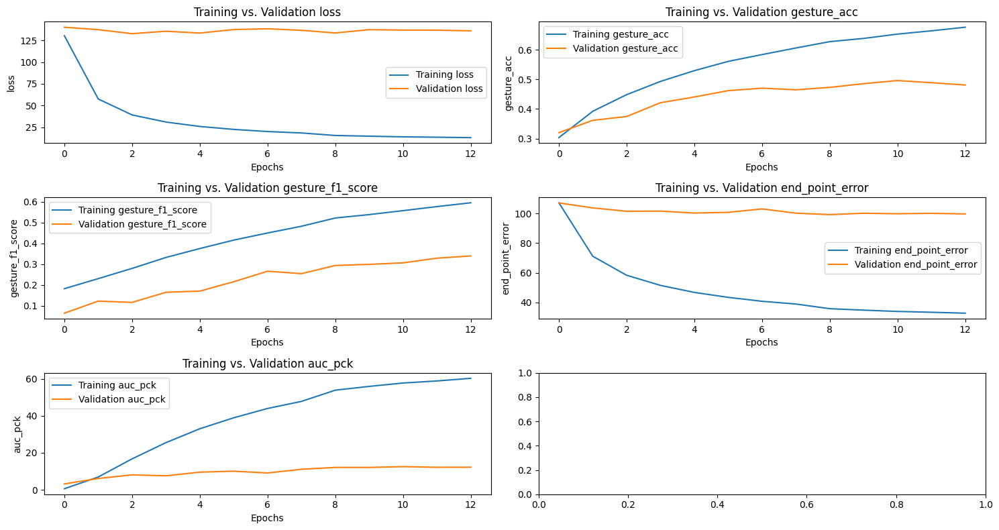

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.28272283
Gesture F1 Score:  0.09178769709779598
AucPCK :  [0.         0.04941627 0.41386127 1.3713015  3.1008708  5.114584
 7.3815556 ]
End point error  136.16926098658163
**************************************************
Validation Evaluation
Gesture Accuracy:  0.37433618
Gesture F1 Score:  0.11908616940200338
AucPCK :  [ 0.08645177  0.9015685   3.2357664   6.681487   10.4174385  15.38224
 19.680128  ]
End point error  101.52991037419618
**************************************************
Worst joints : 


{'wrist_z': 46.1453313404925,
 'wrist_x': 31.33288764251111,
 'Pinky_2_z': 27.028472851248903,
 'Pinky_1_z': 25.534993670536135,
 'Ring_2_z': 23.971698936090387,
 'Thumb_3_z': 22.261295559991513,
 'Ring_1_z': 22.170958418392157,
 'Pinky_3_z': 21.84760844943146,
 'Ring_3_x': 21.769239823179607,
 'Index_3_x': 21.498232230851464,
 'Index_3_z': 21.201693184907374,
 'Middle_3_z': 21.084157875187977,
 'Middle_2_z': 20.907828455996533,
 'Index_2_z': 20.57671412967653,
 'Ring_3_z': 20.37672992217322,
 'Middle_3_x': 20.12410019871963,
 'Thumb_2_z': 18.024892055906143,
 'Middle_1_z': 17.315035852255225,
 'Pinky_3_x': 16.67655015366826,
 'Ring_2_x': 16.05351323114412,
 'Middle_2_x': 15.010675070406306,
 'Index_1_z': 14.650000485933695,
 'Thumb_3_x': 14.346261379923307,
 'Index_2_x': 14.330915287078698,
 'Pinky_2_x': 13.044689842642063,
 'Thumb_0_z': 12.016308309488432,
 'Thumb_1_z': 11.868383993440787,
 'Thumb_2_x': 10.01460940507269,
 'Pinky_0_z': 9.596627509619305,
 'Pinky_1_x': 9.5491829343735

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per axis normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='y', norm_skel='axis')
chili_data

Dimension removed from capacitive images : y
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-23.43048991920785, 23.165614336319447], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[-23.409671600655, 23.129924313843347], [-0.1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[-23.393166584929464, 23.08544018246818], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[-23.36784269815029, 23.031208137988553], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[-23.37924150258129, 22.970736268859355], [-0...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-28.546809306270465, 23.996935749080144], [2...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-28.575160255261896, 23.9672961554275], [2.3...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-28.517626697646122, 23.97428332576931], [2....","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-28.58974559785627, 25.4108267790896], [2.34...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_y_axisNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 13ms/step - loss: 278.1225 - end_point_error: 149.8278 - auc_pck: 0.1352 - gesture_acc: 0.3055 - gesture_f1_score: 0.2159 - val_loss: 153.8119 - val_end_point_error: 114.0041 - val_auc_pck: 1.6387 - val_gesture_acc: 0.3297 - val_gesture_f1_score: 0.1051 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 96.8356 - end_point_error: 93.4454 - auc_pck: 1.3531 - gesture_acc: 0.3490 - gesture_f1_score: 0.2453 - val_loss: 138.4117 - val_end_point_error: 106.1115 - val_auc_pck: 3.9985 - val_gesture_acc: 0.3799 - val_gesture_f1_score: 0.1032 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 19s 13ms/step - loss: 65.1115 - end_point_error: 76.4957 - auc_pck: 5.0478 - gesture_acc: 0.3840 - gesture_f1_score: 0.2682 - val_loss: 138.5569 - val_end_point_error: 105.3492 - val_auc_pck: 4.8843 - val_gesture_acc: 0.3391 - val_gesture_f1_score: 0.1426 - lr: 1.0000e-04
Epoch 4/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


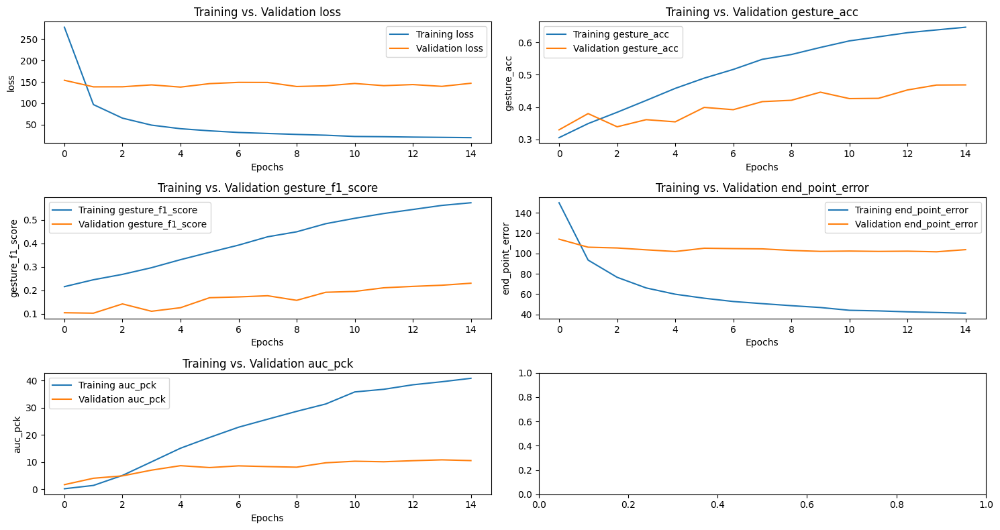

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.3086046
Gesture F1 Score:  0.1284688508686672
AucPCK :  [0.02470814 0.18531102 0.6177034  1.7295694  3.6938663  6.4673543
 9.846191  ]
End point error  137.26074658432495
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3550698
Gesture F1 Score:  0.12955681360309665
AucPCK :  [ 0.5187106  1.7846115  3.9212055  7.1137457 11.096703  15.57367
 20.507595 ]
End point error  101.92237675131629
**************************************************
Worst joints : 


{'wrist_z': 44.290414103123375,
 'wrist_x': 31.533371194650538,
 'Pinky_2_z': 27.327658989169255,
 'Pinky_1_z': 25.284091497668225,
 'Ring_2_z': 23.480004035511854,
 'Thumb_3_z': 23.407339866157646,
 'Pinky_3_z': 22.097595248386487,
 'Ring_1_z': 21.967636873484224,
 'Index_3_z': 21.90059083922747,
 'Middle_2_z': 21.222424762442195,
 'Middle_3_z': 21.15671992285421,
 'Index_2_z': 21.13932740782696,
 'Index_3_x': 21.042294493396227,
 'Ring_3_x': 21.00938955003987,
 'Ring_3_z': 20.605077642488908,
 'Middle_3_x': 19.882118663989594,
 'Thumb_2_z': 18.716128871407445,
 'Middle_1_z': 17.46803490406423,
 'Pinky_3_x': 16.937776412037636,
 'Ring_2_x': 16.007198790620848,
 'Middle_2_x': 15.152931059094911,
 'Index_1_z': 15.085997985422146,
 'Index_2_x': 14.474186839369885,
 'Thumb_3_x': 14.423492022660774,
 'Pinky_2_x': 13.406950139045223,
 'Thumb_0_z': 12.013677265735431,
 'Thumb_1_z': 11.81699091967623,
 'Pinky_1_x': 10.563753617039875,
 'Thumb_2_x': 10.053714922228206,
 'Pinky_0_z': 9.49981911

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

#### without wrist

**with global scalar normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='y', norm_skel='all')
chili_data

Dimension removed from capacitive images : y
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.3900946, 0.3900946], [0.43632802, -0.25233...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.3900946, 0.3900946], [0.4330193, -0.251280...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.3900946, 0.3900946], [0.42929482, -0.24710...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.3900946, 0.3900946], [0.42374006, -0.24218...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.3900946, 0.3900946], [0.41697896, -0.22985...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.3900946, 0.3900946], [1.0363872, -0.043384...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.3900946, 0.3900946], [1.0405397, -0.039803...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.3900946, 0.3900946], [1.0302298, -0.050854...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.3900946, 0.3900946], [1.043083, -0.0859474...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_y_allNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 336.5581 - end_point_error: 172.9703 - auc_pck: 5.8818e-04 - gesture_acc: 0.2776 - gesture_f1_score: 0.1412 - val_loss: 148.0176 - val_end_point_error: 110.3112 - val_auc_pck: 2.2401 - val_gesture_acc: 0.2967 - val_gesture_f1_score: 0.0064 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 107.2419 - end_point_error: 98.3430 - auc_pck: 0.5869 - gesture_acc: 0.3205 - gesture_f1_score: 0.0778 - val_loss: 187.7835 - val_end_point_error: 128.9393 - val_auc_pck: 0.3452 - val_gesture_acc: 0.3431 - val_gesture_f1_score: 0.1949 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 63.2412 - end_point_error: 74.8097 - auc_pck: 5.5316 - gesture_acc: 0.3458 - gesture_f1_score: 0.0589 - val_loss: 109.7456 - val_end_point_error: 94.2882 - val_auc_pck: 5.3536 - val_gesture_acc: 0.3145 - val_gesture_f1_score: 0.0179 - lr: 1.0000e-04
Epoc

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


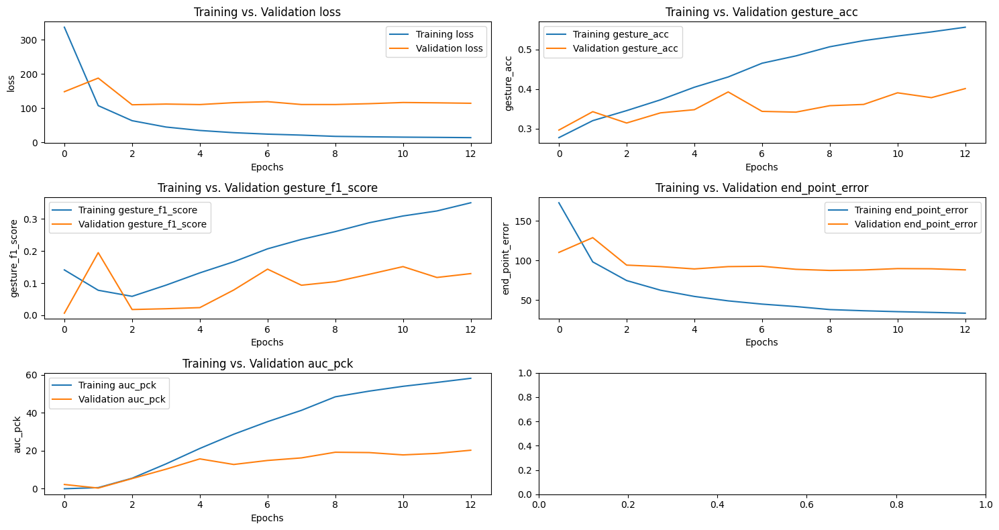

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.28062263
Gesture F1 Score:  0.01349776
AucPCK :  [0.         0.03088517 0.46945456 1.3342392  2.8167274  5.5655074
 9.833838  ]
End point error  117.5977
**************************************************
Validation Evaluation
Gesture Accuracy:  0.31326416
Gesture F1 Score:  0.018411262
AucPCK :  [ 0.          0.11115228  0.9200939   2.7973323   6.33568    10.9237995
 16.456713  ]
End point error  94.34748
**************************************************
Worst joints : 


{'Pinky_2_z': 28.150047,
 'Pinky_1_z': 24.630636,
 'Ring_2_z': 23.431208,
 'Pinky_3_z': 23.227743,
 'Index_3_x': 22.305544,
 'Thumb_3_z': 22.17574,
 'Ring_1_z': 21.802774,
 'Index_3_z': 21.489326,
 'Middle_2_z': 21.155388,
 'Ring_3_x': 20.8319,
 'Index_2_z': 20.649616,
 'Middle_3_z': 20.557356,
 'Ring_3_z': 20.237202,
 'Middle_3_x': 19.675064,
 'Thumb_2_z': 18.788517,
 'Ring_2_x': 17.9951,
 'Middle_1_z': 17.318766,
 'Index_2_x': 16.316534,
 'Pinky_3_x': 15.777231,
 'Middle_2_x': 15.62322,
 'Index_1_z': 15.222222,
 'Thumb_3_x': 14.963697,
 'Pinky_2_x': 14.8039875,
 'Thumb_0_z': 12.121207,
 'Thumb_1_z': 11.869898,
 'Thumb_2_x': 10.499255,
 'Pinky_0_z': 10.292195,
 'Pinky_1_x': 9.764341,
 'Ring_1_x': 9.174144,
 'Index_1_x': 9.161147,
 'Middle_1_x': 8.451238,
 'Ring_0_z': 8.292211,
 'Index_0_z': 6.7484818,
 'Middle_0_z': 6.557949,
 'Thumb_0_x': 5.992776,
 'Thumb_1_x': 5.658301,
 'Pinky_0_x': 3.919352,
 'Index_0_x': 3.4879396,
 'Ring_0_x': 3.2844713,
 'Middle_0_x': 2.8426538,
 'wrist_z': 2.

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per joint normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='y', norm_skel='joint')
chili_data

Dimension removed from capacitive images : y
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-1.1028495931143127, -0.66334736...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-1.1131449024395115, -0.65728382...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-1.1247338986601791, -0.63328413...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-1.1420180522871657, -0.60498760...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-1.1630557041056309, -0.53409194...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [0.764281516281753, 0.53797630388...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [0.777202581033532, 0.55856773022...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [0.745122306866482, 0.49503300107...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [0.7851159712056419, 0.2932695620...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_y_jointNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 26s 14ms/step - loss: 95.5479 - end_point_error: 90.6517 - auc_pck: 2.7919 - gesture_acc: 0.2967 - gesture_f1_score: 0.1578 - val_loss: 120.7662 - val_end_point_error: 96.6394 - val_auc_pck: 9.1170 - val_gesture_acc: 0.3089 - val_gesture_f1_score: 0.0726 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 39.2471 - end_point_error: 57.8804 - auc_pck: 18.2396 - gesture_acc: 0.3789 - gesture_f1_score: 0.2043 - val_loss: 119.5878 - val_end_point_error: 93.2786 - val_auc_pck: 13.8005 - val_gesture_acc: 0.3524 - val_gesture_f1_score: 0.0790 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 27.2414 - end_point_error: 47.7093 - auc_pck: 32.1041 - gesture_acc: 0.4192 - gesture_f1_score: 0.2351 - val_loss: 110.8252 - val_end_point_error: 89.6452 - val_auc_pck: 14.6608 - val_gesture_acc: 0.3998 - val_gesture_f1_score: 0.0608 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


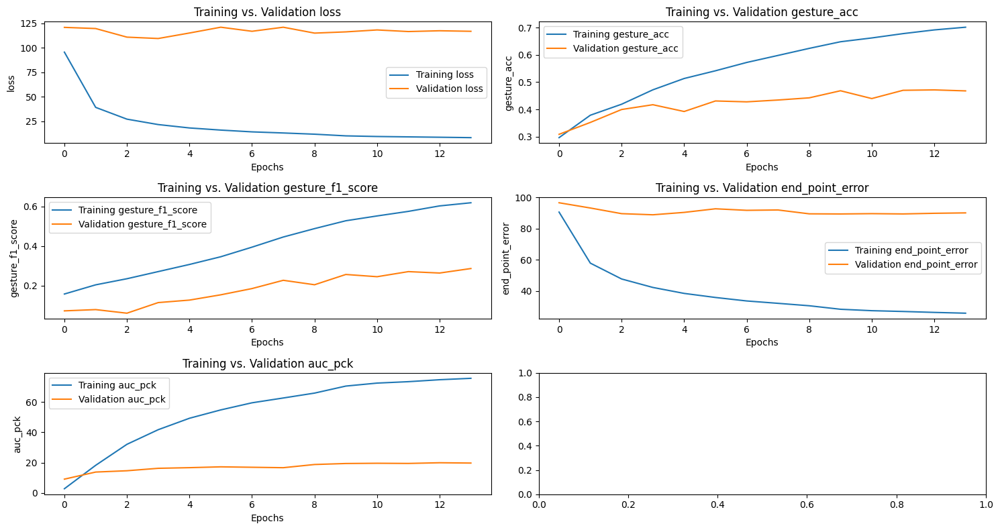

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.32373834
Gesture F1 Score:  0.07789375752931596
AucPCK :  [ 0.80919147  2.6005313   5.0836987   7.746001   11.198962   14.713695
 17.987522  ]
End point error  117.27066945930714
**************************************************
Validation Evaluation
Gesture Accuracy:  0.41719157
Gesture F1 Score:  0.11734261751527571
AucPCK :  [ 1.9328145  5.174756  10.00988   15.7898    21.829073  27.071756
 32.129185 ]
End point error  88.97300841724265
**************************************************
Worst joints : 


{'Pinky_2_z': 27.53911595551216,
 'Pinky_1_z': 25.73046703219445,
 'Ring_2_z': 23.7855051707021,
 'Thumb_3_z': 22.882885635166854,
 'Ring_3_x': 22.61481446333064,
 'Pinky_3_z': 22.525149279688616,
 'Ring_1_z': 22.334645318776264,
 'Index_3_x': 21.688717062035554,
 'Index_3_z': 21.526326953041316,
 'Middle_3_z': 21.121452490182374,
 'Middle_2_z': 20.948846526253217,
 'Index_2_z': 20.813716727592507,
 'Middle_3_x': 20.62677383092483,
 'Ring_3_z': 20.505647945140126,
 'Thumb_2_z': 18.586689641829828,
 'Pinky_3_x': 17.95323431416187,
 'Middle_1_z': 17.216427430918525,
 'Ring_2_x': 16.405375704010595,
 'Middle_2_x': 15.734992385101584,
 'Index_1_z': 14.826613144701396,
 'Index_2_x': 14.540921639889381,
 'Thumb_3_x': 14.251197065468043,
 'Pinky_2_x': 13.913667271685682,
 'Thumb_1_z': 12.160319694730187,
 'Thumb_0_z': 12.061169883846366,
 'Thumb_2_x': 9.93290117974504,
 'Pinky_1_x': 9.915427628552305,
 'Pinky_0_z': 9.727318470002125,
 'Ring_1_x': 8.642060839649671,
 'Ring_0_z': 7.588437797863

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per axis normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='y', norm_skel='axis')
chili_data

Dimension removed from capacitive images : y
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-3.6766551275070696, 4.417280444...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-3.711874294556181, 4.4260803520...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-3.75151902799107, 4.46091067115...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-3.8106462940753847, 4.501976906...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-3.8826138814796884, 4.604866504...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [2.7106034159019385, 6.1607398239...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [2.754805015248883, 6.19062378968...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [2.645061781783789, 6.09841698291...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [2.7818758881671153, 5.8056013421...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_y_axisNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 26s 14ms/step - loss: 69.5909 - end_point_error: 74.7258 - auc_pck: 11.4271 - gesture_acc: 0.3716 - gesture_f1_score: 0.3042 - val_loss: 104.1257 - val_end_point_error: 89.6093 - val_auc_pck: 10.8745 - val_gesture_acc: 0.3948 - val_gesture_f1_score: 0.2241 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 28.3362 - end_point_error: 48.7873 - auc_pck: 30.0253 - gesture_acc: 0.5060 - gesture_f1_score: 0.4389 - val_loss: 108.4801 - val_end_point_error: 90.0762 - val_auc_pck: 14.0066 - val_gesture_acc: 0.4177 - val_gesture_f1_score: 0.2903 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 21.0071 - end_point_error: 41.8796 - auc_pck: 41.6195 - gesture_acc: 0.5809 - gesture_f1_score: 0.5114 - val_loss: 103.0431 - val_end_point_error: 87.8858 - val_auc_pck: 14.9232 - val_gesture_acc: 0.4406 - val_gesture_f1_score: 0.2826 - lr: 1.0000e-04
Epoch 4

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


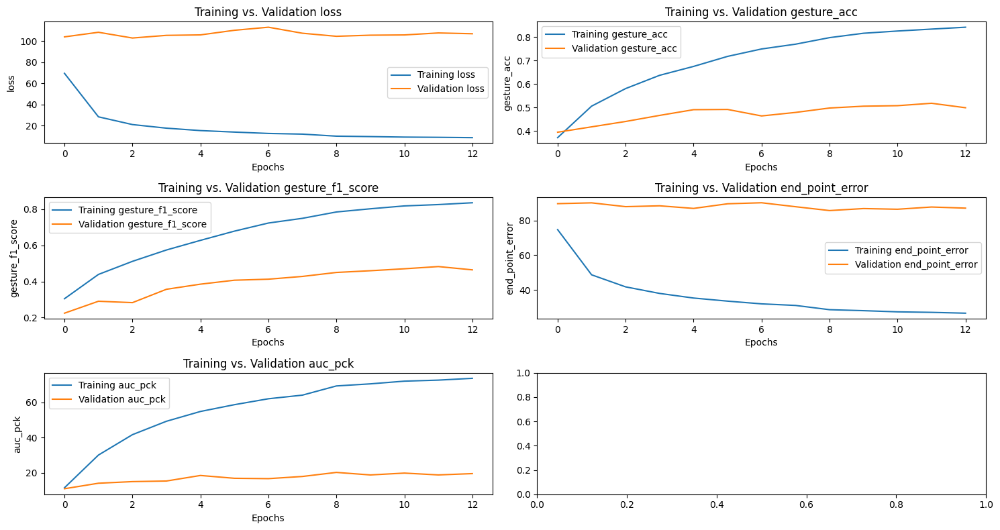

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.35517943
Gesture F1 Score:  0.19737793517115898
AucPCK :  [ 0.75977516  2.3410957   4.6760144   7.2518377  10.463895   13.966272
 17.76515   ]
End point error  113.17999926043784
**************************************************
Validation Evaluation
Gesture Accuracy:  0.44139805
Gesture F1 Score:  0.28695486086360716
AucPCK :  [ 1.4326293  4.581944   8.76868   14.017537  19.680128  25.33037
 30.19637  ]
End point error  87.98512633057352
**************************************************
Worst joints : 


{'Pinky_2_z': 25.944883646944074,
 'Pinky_1_z': 24.451442606143118,
 'Ring_2_z': 22.23960833549722,
 'Thumb_3_z': 22.231427811038653,
 'Pinky_3_z': 21.059393542237498,
 'Index_3_z': 21.03323468110441,
 'Middle_3_z': 20.881855844827932,
 'Ring_1_z': 20.879786992480263,
 'Index_3_x': 20.85445742009336,
 'Middle_2_z': 20.763870790591177,
 'Ring_3_x': 20.5299594050309,
 'Index_2_z': 20.201144104823204,
 'Ring_3_z': 20.039235722385087,
 'Middle_3_x': 19.788125700679135,
 'Thumb_2_z': 17.944191583984125,
 'Middle_1_z': 16.4182800669765,
 'Pinky_3_x': 16.253407900472258,
 'Ring_2_x': 15.976755491826777,
 'Middle_2_x': 14.76013023115566,
 'Thumb_3_x': 14.489472823702753,
 'Index_2_x': 14.477850727444592,
 'Index_1_z': 14.293486676916574,
 'Pinky_2_x': 13.218525356993991,
 'Thumb_0_z': 11.609676715313311,
 'Thumb_1_z': 11.424284410742395,
 'Thumb_2_x': 10.01351592194777,
 'Pinky_1_x': 9.523708967180758,
 'Pinky_0_z': 9.27173254641786,
 'Ring_1_x': 8.453918152467113,
 'Middle_1_x': 7.28651556756

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

### 2d model removing z

#### Keeping wrist

**with global scalar normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='z', norm_skel='all')
chili_data

Dimension removed from capacitive images : z
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-3.7177284, 4.572516], [-0.082278885, -0.399...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[-3.7144773, 4.575104], [-0.084401675, -0.401...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[-3.7118998, 4.5761485], [-0.0867912, -0.4049...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[-3.7079449, 4.5745044], [-0.09035502, -0.409...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[-3.709725, 4.569827], [-0.09469277, -0.41646...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-4.516749, 4.2536645], [0.30270436, -0.36847...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-4.5211763, 4.2571735], [0.30536854, -0.3652...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-4.5121913, 4.242159], [0.29875392, -0.37349...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-4.523454, 4.2425613], [0.3070002, -0.320455...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_z_allNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 26s 14ms/step - loss: 671.7397 - end_point_error: 244.1761 - auc_pck: 0.0000e+00 - gesture_acc: 0.2782 - gesture_f1_score: 0.1413 - val_loss: 187.7785 - val_end_point_error: 129.4192 - val_auc_pck: 0.0000e+00 - val_gesture_acc: 0.2736 - val_gesture_f1_score: 0.0410 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 191.7105 - end_point_error: 132.5192 - auc_pck: 0.0088 - gesture_acc: 0.3222 - gesture_f1_score: 0.0873 - val_loss: 149.0422 - val_end_point_error: 112.3651 - val_auc_pck: 2.1767 - val_gesture_acc: 0.3413 - val_gesture_f1_score: 0.0000e+00 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 110.4440 - end_point_error: 99.9770 - auc_pck: 0.4585 - gesture_acc: 0.3524 - gesture_f1_score: 0.0776 - val_loss: 142.0967 - val_end_point_error: 110.0249 - val_auc_pck: 2.2216 - val_gesture_acc: 0.3586 - val_gesture_f1_score: 0.0208 - lr: 1.00

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


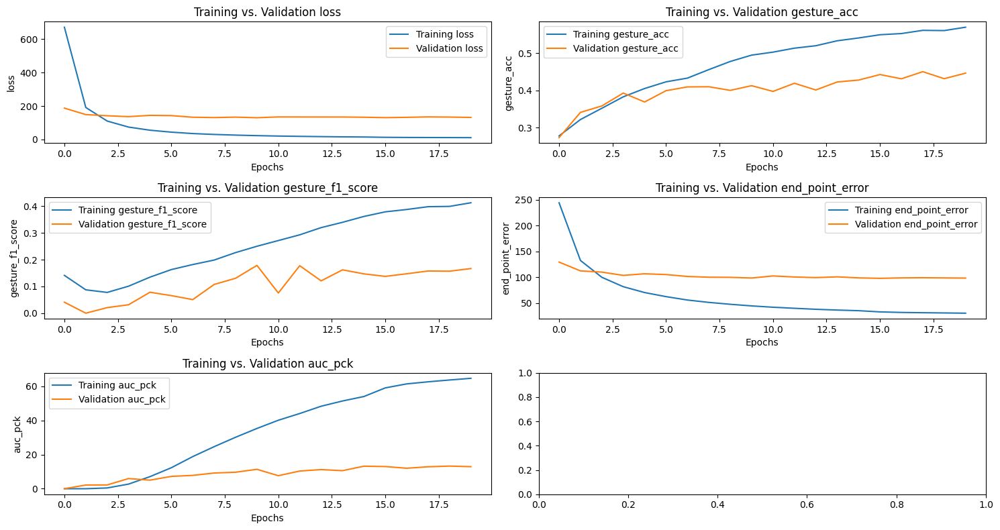

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.4139848
Gesture F1 Score:  0.104406916
AucPCK :  [ 0.32120577  1.1427512   2.6375935   4.762493    7.319785   10.365063
 13.960096  ]
End point error  127.29847
**************************************************
Validation Evaluation
Gesture Accuracy:  0.41373348
Gesture F1 Score:  0.18288732
AucPCK :  [ 0.87686795  2.4268248   5.2612076   9.849327   14.987032   20.28529
 25.639126  ]
End point error  98.68707
**************************************************
Worst joints : 


{'wrist_y': 44.107315,
 'Pinky_2_y': 26.42615,
 'Pinky_1_y': 24.929289,
 'Ring_2_y': 23.015467,
 'Thumb_3_y': 22.259401,
 'Ring_1_y': 21.729338,
 'Pinky_3_y': 21.61078,
 'Index_3_y': 21.206772,
 'Middle_3_y': 20.846998,
 'Middle_2_y': 20.679346,
 'Index_2_y': 20.294401,
 'Ring_3_y': 20.087961,
 'Thumb_2_y': 18.081787,
 'Middle_1_y': 17.443079,
 'Ring_3_x': 16.19717,
 'Pinky_3_x': 16.107481,
 'Pinky_2_x': 14.997964,
 'Index_1_y': 14.994516,
 'Middle_3_x': 14.659543,
 'Ring_2_x': 14.560881,
 'Index_1_x': 14.027861,
 'Index_2_x': 13.99992,
 'Index_3_x': 13.8730755,
 'wrist_x': 12.524575,
 'Middle_2_x': 12.126436,
 'Middle_1_x': 11.883463,
 'Thumb_1_y': 11.680588,
 'Thumb_0_y': 11.574703,
 'Thumb_3_x': 11.291312,
 'Pinky_1_x': 10.162253,
 'Ring_1_x': 9.67537,
 'Pinky_0_y': 9.341617,
 'Thumb_2_x': 9.081773,
 'Index_0_x': 8.290139,
 'Ring_0_y': 7.5463166,
 'Middle_0_x': 6.7870326,
 'Thumb_1_x': 6.745011,
 'Thumb_0_x': 6.701352,
 'Index_0_y': 5.680325,
 'Ring_0_x': 5.132957,
 'Middle_0_y': 4.

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per joint normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='z', norm_skel='joint')
chili_data

Dimension removed from capacitive images : z
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6965019597521231, 1.9029354711708684], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.7006194950112642, 1.9189654108251444], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.7038839269599848, 1.9254321652576158], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.7088925925948693, 1.9152491172614103], [-1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.7066380887530944, 1.88628278565952], [-1.1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.31542536856580566, -0.07177722619295937],...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.3210327393919355, -0.050044549014194604],...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.3096535085733957, -0.14303549750502492], ...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.32391749025433203, -0.14054163099406292],...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_z_jointNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 103.2565 - end_point_error: 95.2597 - auc_pck: 1.6927 - gesture_acc: 0.2983 - gesture_f1_score: 0.1656 - val_loss: 133.2386 - val_end_point_error: 104.0105 - val_auc_pck: 4.1367 - val_gesture_acc: 0.3310 - val_gesture_f1_score: 0.0644 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 45.0114 - end_point_error: 62.8257 - auc_pck: 12.2811 - gesture_acc: 0.3813 - gesture_f1_score: 0.2073 - val_loss: 124.5356 - val_end_point_error: 99.1748 - val_auc_pck: 8.1652 - val_gesture_acc: 0.3915 - val_gesture_f1_score: 0.1213 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 31.2958 - end_point_error: 51.8212 - auc_pck: 24.9382 - gesture_acc: 0.4431 - gesture_f1_score: 0.2619 - val_loss: 119.6209 - val_end_point_error: 97.1021 - val_auc_pck: 9.1003 - val_gesture_acc: 0.4097 - val_gesture_f1_score: 0.1330 - lr: 1.0000e-04
Epoch 4/2

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


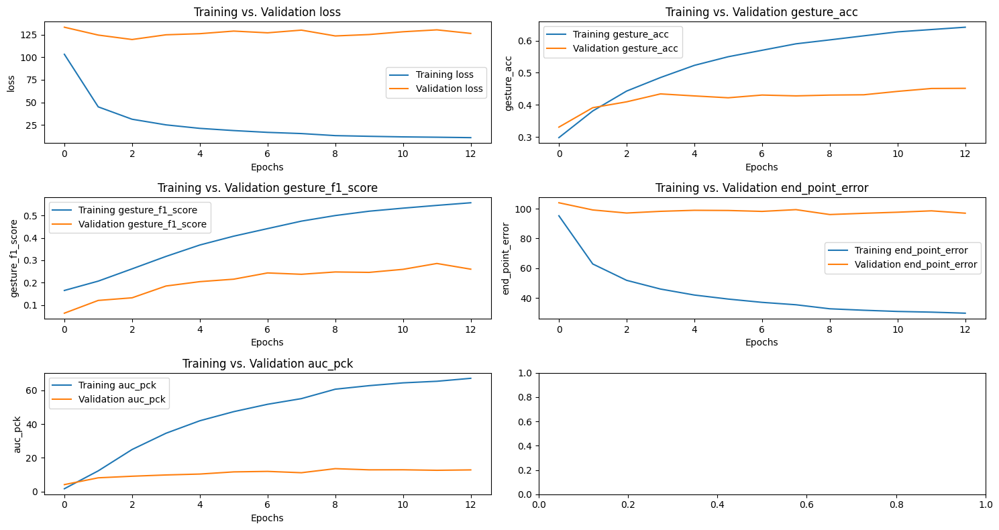

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.365248
Gesture F1 Score:  0.09012604826467764
AucPCK :  [ 0.09265551  0.57446414  1.5998518   3.0946941   5.0528135   7.616283
 11.310149  ]
End point error  128.84284845595522
**************************************************
Validation Evaluation
Gesture Accuracy:  0.40860814
Gesture F1 Score:  0.13644561462537705
AucPCK :  [ 0.21612942  1.3894035   3.7297764   7.305175   11.763616   16.864271
 22.551561  ]
End point error  97.1714692665468
**************************************************
Worst joints : 


{'wrist_y': 44.606821996319766,
 'Pinky_2_y': 27.75881970966821,
 'Pinky_1_y': 25.533772776218886,
 'Ring_2_y': 23.648812116121036,
 'Thumb_3_y': 22.786969884942685,
 'Pinky_3_y': 22.60617011649213,
 'Ring_1_y': 22.18507687639073,
 'Middle_2_y': 21.524183494264406,
 'Middle_3_y': 21.365259001805395,
 'Index_3_y': 21.35217831459595,
 'Ring_3_y': 20.91006336502279,
 'Index_2_y': 20.632635825472327,
 'Thumb_2_y': 18.235300646151895,
 'Middle_1_y': 17.112051630923013,
 'Ring_3_x': 16.06439092923516,
 'Pinky_3_x': 15.900883692810686,
 'Pinky_2_x': 14.721703340737204,
 'Index_1_y': 14.681048820188552,
 'Middle_3_x': 14.632174188000773,
 'Ring_2_x': 14.3910436231445,
 'Index_1_x': 14.262061954000034,
 'Index_2_x': 13.79677474587767,
 'Index_3_x': 13.681018715538823,
 'Middle_2_x': 12.122127306346894,
 'Middle_1_x': 11.932558450824752,
 'Thumb_0_y': 11.822997962123234,
 'Thumb_1_y': 11.745474710832163,
 'Thumb_3_x': 11.29669313209623,
 'wrist_x': 10.759990668074725,
 'Pinky_1_x': 10.0277580683

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per axis normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=True, data_path = data_path_chili, dim2=True, dim_to_remove='z', norm_skel='axis')
chili_data

Dimension removed from capacitive images : z
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-23.43048991920785, 95.35883385764362], [-0....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[-23.409671600655, 95.41351286060464], [-0.16...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[-23.393166584929464, 95.435571314497], [-0.1...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[-23.36784269815029, 95.40083637952249], [-0....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[-23.37924150258129, 95.30203063442369], [-0....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-28.546809306270465, 88.62298058838256], [2....","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-28.575160255261896, 88.69711194167755], [2....","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-28.517626697646122, 88.37991471838535], [2....","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-28.58974559785627, 88.38842143377407], [2.3...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/keep_wrist/vary_axis_norm/remove_z_axisNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 26s 14ms/step - loss: 408.5958 - end_point_error: 182.9162 - auc_pck: 0.1193 - gesture_acc: 0.2975 - gesture_f1_score: 0.2242 - val_loss: 154.7033 - val_end_point_error: 112.9328 - val_auc_pck: 3.1910 - val_gesture_acc: 0.3492 - val_gesture_f1_score: 0.1327 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 117.7545 - end_point_error: 102.2798 - auc_pck: 1.3002 - gesture_acc: 0.3472 - gesture_f1_score: 0.2664 - val_loss: 141.8168 - val_end_point_error: 106.7269 - val_auc_pck: 5.1898 - val_gesture_acc: 0.3813 - val_gesture_f1_score: 0.1856 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 88.8077 - end_point_error: 88.7191 - auc_pck: 3.2073 - gesture_acc: 0.3790 - gesture_f1_score: 0.2966 - val_loss: 142.7196 - val_end_point_error: 108.4604 - val_auc_pck: 3.6700 - val_gesture_acc: 0.3842 - val_gesture_f1_score: 0.2250 - lr: 1.0000e-04
Epoch 

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


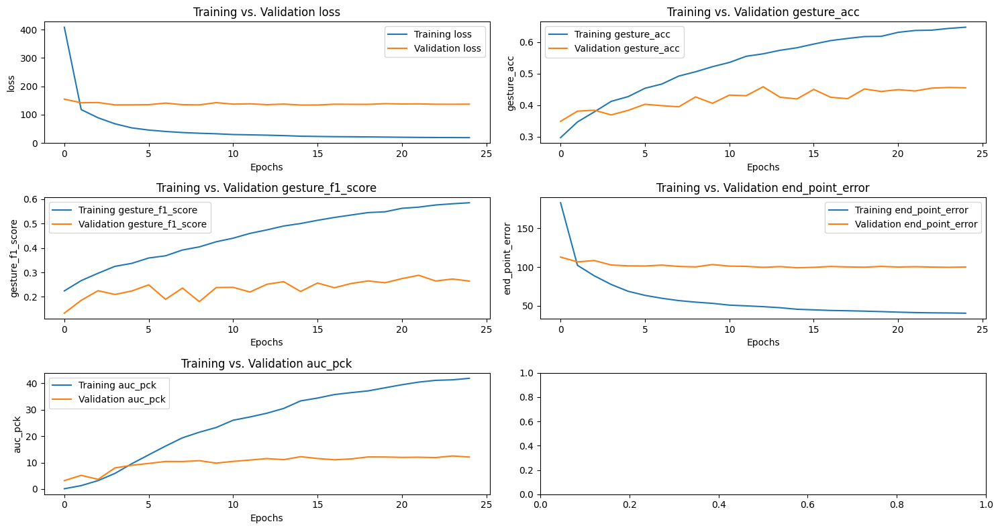

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.35258508
Gesture F1 Score:  0.16859256052580743
AucPCK :  [ 0.48798564  1.3960096   3.1688185   5.707579    8.147508   10.698623
 13.614182  ]
End point error  127.84679526252093
**************************************************
Validation Evaluation
Gesture Accuracy:  0.42064962
Gesture F1 Score:  0.22555342820441499
AucPCK :  [ 1.6178832  4.1126347  7.132271  11.041126  15.647771  20.7299
 25.385946 ]
End point error  99.17825702465112
**************************************************
Worst joints : 


{'wrist_y': 44.53485597197318,
 'Pinky_2_y': 26.921103134796756,
 'Pinky_1_y': 24.99864678935806,
 'Ring_2_y': 22.806964222228682,
 'Thumb_3_y': 22.766661137754003,
 'Pinky_3_y': 22.07187473644833,
 'Ring_1_y': 21.583179611304782,
 'Index_3_y': 21.514196192653813,
 'Middle_3_y': 20.805717902086467,
 'Middle_2_y': 20.763058525036772,
 'Index_2_y': 20.28094617759429,
 'Ring_3_y': 20.1307168221612,
 'Thumb_2_y': 18.359571734696637,
 'Middle_1_y': 17.019345634305147,
 'Pinky_3_x': 15.857512578139762,
 'Ring_3_x': 15.84893266670523,
 'Pinky_2_x': 14.890779635226234,
 'Index_1_y': 14.724249458253325,
 'Ring_2_x': 14.401702551448237,
 'wrist_x': 14.366110513651956,
 'Middle_3_x': 14.333343408091848,
 'Index_1_x': 14.131553403762938,
 'Index_2_x': 13.813100845974695,
 'Index_3_x': 13.80951775475781,
 'Middle_1_x': 12.013469684217974,
 'Thumb_0_y': 11.88236437450161,
 'Middle_2_x': 11.86572220229276,
 'Thumb_1_y': 11.7631217911543,
 'Thumb_3_x': 11.235951590386737,
 'Pinky_1_x': 10.035375339574

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

#### without wrist

**with global scalar normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='z', norm_skel='all')
chili_data

Dimension removed from capacitive images : z
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-0.31013864, -0.31013864], [-0.22389555, -1....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[-0.31013864, -0.31013864], [-0.23006757, -1....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[-0.31013864, -0.31013864], [-0.23701514, -1....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[-0.31013864, -0.31013864], [-0.24737696, -1....","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[-0.31013864, -0.31013864], [-0.259989, -1.19...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[-0.31013864, -0.31013864], [0.8954455, -1.05...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[-0.31013864, -0.31013864], [0.9031916, -1.04...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[-0.31013864, -0.31013864], [0.8839596, -1.07...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[-0.31013864, -0.31013864], [0.90793574, -0.9...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_z_allNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 26s 14ms/step - loss: 125.1498 - end_point_error: 105.8369 - auc_pck: 0.5016 - gesture_acc: 0.2998 - gesture_f1_score: 0.1611 - val_loss: 117.1162 - val_end_point_error: 96.7535 - val_auc_pck: 6.4376 - val_gesture_acc: 0.3542 - val_gesture_f1_score: 0.0582 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 46.7957 - end_point_error: 64.4790 - auc_pck: 10.1329 - gesture_acc: 0.3671 - gesture_f1_score: 0.1375 - val_loss: 105.1265 - val_end_point_error: 90.8151 - val_auc_pck: 9.4270 - val_gesture_acc: 0.3780 - val_gesture_f1_score: 0.0372 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 31.0382 - end_point_error: 51.8803 - auc_pck: 23.9348 - gesture_acc: 0.4280 - gesture_f1_score: 0.1811 - val_loss: 105.3934 - val_end_point_error: 88.8233 - val_auc_pck: 13.5989 - val_gesture_acc: 0.3671 - val_gesture_f1_score: 0.0805 - lr: 1.0000e-04
Epoch 4/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


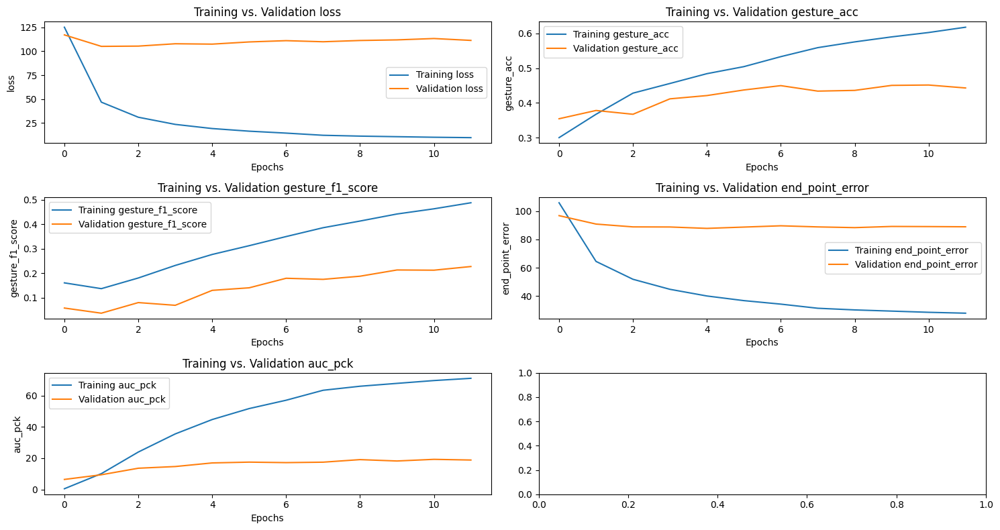

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.3502996
Gesture F1 Score:  0.054621838
AucPCK :  [ 0.364445   1.2168757  2.4275742  5.2072396  8.660202  12.317005
 15.578479 ]
End point error  113.807014
**************************************************
Validation Evaluation
Gesture Accuracy:  0.37686798
Gesture F1 Score:  0.038364217
AucPCK :  [ 0.33345684  1.5437816   3.9829566   7.3978014  11.94887    17.481783
 23.422255  ]
End point error  90.8677
**************************************************
Worst joints : 


{'Pinky_2_y': 26.318727,
 'Pinky_1_y': 24.601648,
 'Ring_2_y': 22.843748,
 'Thumb_3_y': 22.352488,
 'Index_3_y': 21.701056,
 'Pinky_3_y': 21.558992,
 'Ring_1_y': 21.175207,
 'Middle_3_y': 20.984419,
 'Middle_2_y': 20.913715,
 'Ring_3_y': 20.70903,
 'Index_2_y': 20.316975,
 'Thumb_2_y': 18.98423,
 'Middle_1_y': 16.858774,
 'Ring_3_x': 16.261515,
 'Index_1_x': 16.082678,
 'Pinky_3_x': 16.009346,
 'Index_1_y': 14.845818,
 'Pinky_2_x': 14.674445,
 'Index_2_x': 14.464761,
 'Middle_3_x': 14.333132,
 'Index_3_x': 14.055027,
 'Ring_2_x': 13.993891,
 'Middle_1_x': 12.613596,
 'Thumb_1_y': 12.343038,
 'Middle_2_x': 12.268726,
 'Thumb_3_x': 12.195222,
 'Thumb_0_y': 11.953041,
 'Index_0_x': 11.102373,
 'Pinky_1_x': 10.247629,
 'Thumb_2_x': 9.912973,
 'Ring_1_x': 9.834555,
 'Pinky_0_y': 9.770162,
 'Middle_0_x': 7.9083085,
 'Ring_0_y': 7.6199794,
 'Thumb_0_x': 7.2849116,
 'Thumb_1_x': 7.246033,
 'Ring_0_x': 6.0958867,
 'Index_0_y': 5.9906144,
 'Middle_0_y': 4.7512846,
 'Pinky_0_x': 4.234096,
 'wrist

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per joint normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='z', norm_skel='joint')
chili_data

Dimension removed from capacitive images : z
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-1.1028495931143127, -0.84118420...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-1.1131449024395115, -0.85680093...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-1.1247338986601791, -0.88544905...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-1.1420180522871657, -0.92015246...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-1.1630557041056309, -0.98460971...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [0.764281516281753, -0.5701268248...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [0.777202581033532, -0.5423914319...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [0.745122306866482, -0.6134668944...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [0.7851159712056419, -0.155370520...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_z_jointNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 25s 14ms/step - loss: 87.5058 - end_point_error: 87.0538 - auc_pck: 3.5323 - gesture_acc: 0.2884 - gesture_f1_score: 0.1496 - val_loss: 110.2462 - val_end_point_error: 91.7902 - val_auc_pck: 11.1167 - val_gesture_acc: 0.3708 - val_gesture_f1_score: 0.0316 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 36.0475 - end_point_error: 55.4999 - auc_pck: 20.8793 - gesture_acc: 0.3734 - gesture_f1_score: 0.1614 - val_loss: 104.2356 - val_end_point_error: 88.3473 - val_auc_pck: 14.4046 - val_gesture_acc: 0.3683 - val_gesture_f1_score: 0.0450 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 19s 13ms/step - loss: 24.7301 - end_point_error: 45.4314 - auc_pck: 35.7008 - gesture_acc: 0.4358 - gesture_f1_score: 0.2215 - val_loss: 102.2863 - val_end_point_error: 87.6947 - val_auc_pck: 14.9760 - val_gesture_acc: 0.4196 - val_gesture_f1_score: 0.0802 - lr: 1.0000e-04
Epoch 4/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


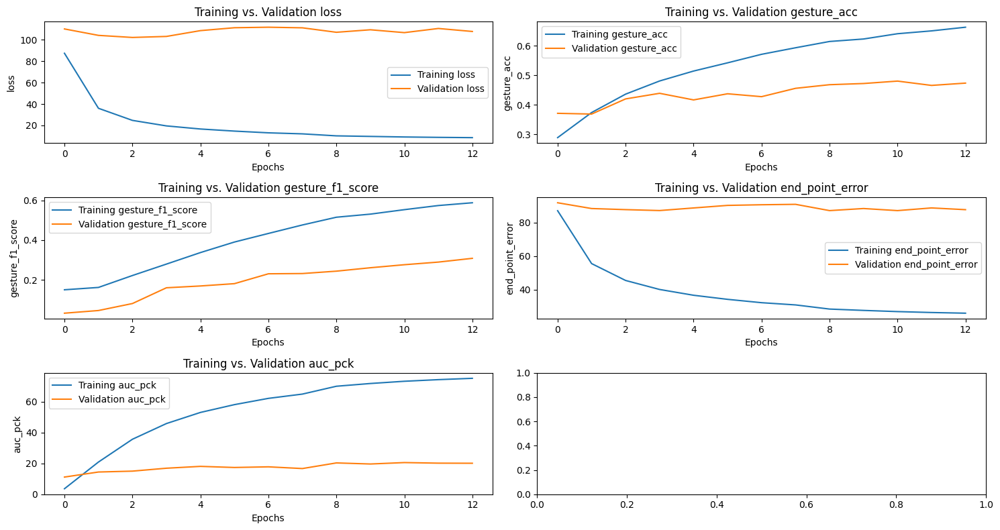

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.32657978
Gesture F1 Score:  0.06448978533860386
AucPCK :  [ 0.51887083  1.9457657   4.4104023   7.461857   11.180431   14.744579
 18.969671  ]
End point error  111.88295852186354
**************************************************
Validation Evaluation
Gesture Accuracy:  0.41855007
Gesture F1 Score:  0.08226336444205397
AucPCK :  [ 1.6425837  4.452266   8.101766  13.023342  19.06879   26.05286
 32.221813 ]
End point error  87.78111860962798
**************************************************
Worst joints : 


{'Pinky_2_y': 26.6197880775098,
 'Pinky_1_y': 24.614737062492377,
 'Ring_2_y': 23.272666214780646,
 'Thumb_3_y': 22.52976468667832,
 'Pinky_3_y': 22.24724022753392,
 'Middle_3_y': 21.36059308847643,
 'Index_3_y': 21.29113883346142,
 'Middle_2_y': 21.28434135863256,
 'Ring_3_y': 20.9332179380554,
 'Index_2_y': 20.89845528988851,
 'Ring_1_y': 20.794066863713716,
 'Thumb_2_y': 18.1532526149672,
 'Middle_1_y': 16.406708999172327,
 'Pinky_3_x': 15.766927895248037,
 'Ring_3_x': 15.693094042463004,
 'Pinky_2_x': 14.80051528217715,
 'Index_1_y': 14.684898964259677,
 'Middle_3_x': 14.488456314238586,
 'Index_1_x': 14.197225798585702,
 'Ring_2_x': 14.040207382963544,
 'Index_3_x': 13.886826178429539,
 'Index_2_x': 13.780201236438165,
 'Middle_2_x': 11.956651848074015,
 'Middle_1_x': 11.91024077920306,
 'Thumb_0_y': 11.793347552127436,
 'Thumb_1_y': 11.776827532903784,
 'Thumb_3_x': 11.535247376239127,
 'Pinky_1_x': 9.87439252301072,
 'Ring_1_x': 9.807681041238233,
 'Pinky_0_y': 9.153989746296832

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

**with per axis normalization**

In [ ]:
chili_data, mean, std, skeleton_cols = read_data(keep_wrist=False, data_path = data_path_chili, dim2=True, dim_to_remove='z', norm_skel='axis')
chili_data

Dimension removed from capacitive images : z
Before removing empty cap_img :  81252  now :  80960
Unique Timestamps :  True


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0], [-3.6766551275070696, -6.34431351...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0], [-3.711874294556181, -6.390200384...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0], [-3.75151902799107, -6.4743775131...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0], [-3.8106462940753847, -6.57634702...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0], [-3.8826138814796884, -6.76574261...","[[-0.12300033638379174, -0.12300033638379174, ...",1,DQ,1,2803
...,...,...,...,...,...,...,...
80955,1.680527e+12,"[[0.0, 0.0], [2.7106034159019385, -5.547862380...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80956,1.680527e+12,"[[0.0, 0.0], [2.754805015248883, -5.4663671055...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80957,1.680527e+12,"[[0.0, 0.0], [2.645061781783789, -5.6752090846...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304
80958,1.680527e+12,"[[0.0, 0.0], [2.7818758881671153, -4.329178402...","[[-0.12300033638379174, -0.12300033638379174, ...",3,LT,35,0304


In [ ]:
model = create_skeleton_gesture_2dmodel(41, 72, 1)


data=load_data(chili_data, 'time', 0.6, seed, dim2=True)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor= 0.5, patience = 5, min_lr=1e-7)
alpha, beta = 0.4 , 0.6
model.compile(optimizer=optimizer, loss = unw_loss(mean, std, alpha, beta, dim2=True),
                  metrics=[un_epe(mean, std, dim2=True), un_pck(mean,std, dim2=True), compute_acc(dim2=True), compute_f1_score(dim2=True)])

history = model.fit(data['train']['X'], data['train']['y'] , validation_data=(data['valid']['X'], data['valid']['y']),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/without_wrist/vary_axis_norm/remove_z_axisNorm.h5')

Epoch 1/200
1518/1518 [==============================] - 26s 14ms/step - loss: 56.2588 - end_point_error: 67.1945 - auc_pck: 16.5955 - gesture_acc: 0.3853 - gesture_f1_score: 0.3156 - val_loss: 98.1628 - val_end_point_error: 85.8403 - val_auc_pck: 14.2549 - val_gesture_acc: 0.4153 - val_gesture_f1_score: 0.2804 - lr: 1.0000e-04
Epoch 2/200
1518/1518 [==============================] - 20s 13ms/step - loss: 23.2299 - end_point_error: 43.5713 - auc_pck: 39.6055 - gesture_acc: 0.5301 - gesture_f1_score: 0.4674 - val_loss: 104.5909 - val_end_point_error: 88.0384 - val_auc_pck: 15.2948 - val_gesture_acc: 0.4405 - val_gesture_f1_score: 0.3303 - lr: 1.0000e-04
Epoch 3/200
1518/1518 [==============================] - 20s 13ms/step - loss: 17.5504 - end_point_error: 37.7158 - auc_pck: 50.6594 - gesture_acc: 0.6139 - gesture_f1_score: 0.5540 - val_loss: 101.6080 - val_end_point_error: 86.3156 - val_auc_pck: 17.1140 - val_gesture_acc: 0.4555 - val_gesture_f1_score: 0.3648 - lr: 1.0000e-04
Epoch 4/

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


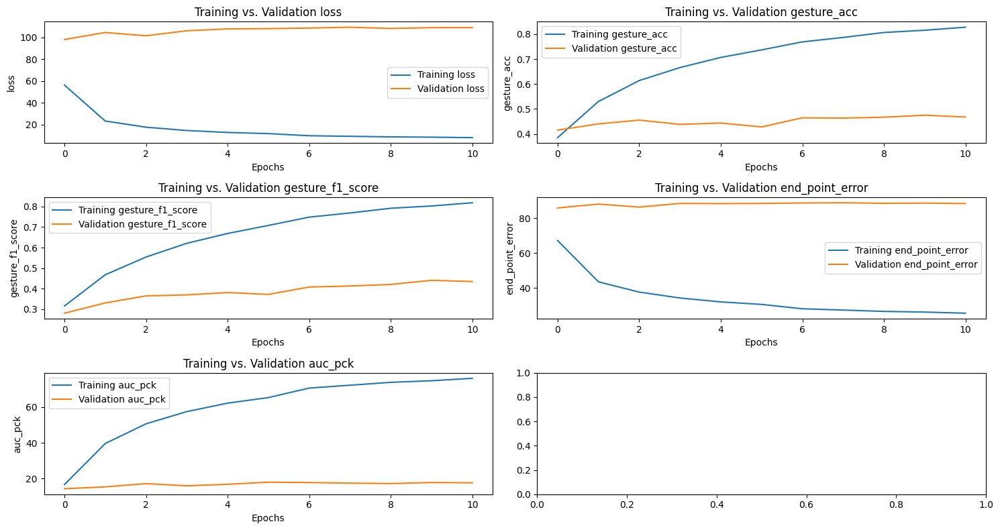

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.35561183
Gesture F1 Score:  0.19255810233254628
AucPCK :  [ 0.4200383  1.5133733  3.9533014  7.115943  10.587436  14.250417
 18.759651 ]
End point error  111.1869216912036
**************************************************
Validation Evaluation
Gesture Accuracy:  0.41515377
Gesture F1 Score:  0.2838871981932037
AucPCK :  [ 0.98184514  3.1863651   6.755588   11.967395   18.469803   25.336546
 33.27158   ]
End point error  85.88425649865967
**************************************************
Worst joints : 


{'Pinky_2_y': 26.380204829174332,
 'Pinky_1_y': 25.02779966288197,
 'Thumb_3_y': 22.39390424557857,
 'Ring_2_y': 22.312416099326615,
 'Pinky_3_y': 21.655162651400257,
 'Index_3_y': 21.09653098620078,
 'Ring_1_y': 21.08992568079879,
 'Middle_3_y': 20.560594191138993,
 'Middle_2_y': 20.20805337291683,
 'Index_2_y': 20.048131745087414,
 'Ring_3_y': 19.63130734104847,
 'Thumb_2_y': 18.38145108471859,
 'Pinky_3_x': 16.537511673863104,
 'Middle_1_y': 16.290337244904215,
 'Ring_3_x': 16.236918352830564,
 'Index_1_x': 15.118581789475886,
 'Pinky_2_x': 14.915771228136826,
 'Middle_3_x': 14.74621255037321,
 'Ring_2_x': 14.474753307228692,
 'Index_1_y': 14.310878155509375,
 'Index_2_x': 13.729333302144415,
 'Index_3_x': 13.48647914220284,
 'Middle_1_x': 12.012518458516832,
 'Middle_2_x': 11.833777355531174,
 'Thumb_0_y': 11.818544581048206,
 'Thumb_1_y': 11.751981159584023,
 'Thumb_3_x': 11.273317448753671,
 'Pinky_0_y': 10.006011551096195,
 'Ring_1_x': 9.937640391494782,
 'Pinky_1_x': 9.90063821

In [ ]:
plot_training(history)
epe_max= evaluate(model, data, mean, std, dim2=True)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

2d model removing y

In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x[:,::2].astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, True, norm='all')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
print(chili_data.iloc[0].skeleton.shape)
chili_data.head()

False
81007
(21, 2)


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-3.4481826, 2.927532], [0.3439966, -0.116880...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[-3.4447913, 2.9224534], [0.3417823, -0.11617...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[-3.4421027, 2.9161234], [0.33928975, -0.1133...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[-3.4379773, 2.9084065], [0.3355723, -0.11008...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[-3.439834, 2.8998015], [0.33104753, -0.10183...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_2d_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train,dim=2)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid,dim=2)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test,dim=2)

optimizer = Adam(learning_rate=0.00001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 4, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'2d_models/normalized/80_all2dw_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 24s 13ms/step - loss: 1206.3540 - gesture_loss: 1.5364 - skeleton_loss: 1206.0471 - gesture_accuracy: 0.2745 - skeleton_end_point_error: 266.9268 - skeleton_auc_pck: 0.0000e+00 - val_loss: 427.0199 - val_gesture_loss: 1.5063 - val_skeleton_loss: 426.7189 - val_gesture_accuracy: 0.2419 - val_skeleton_end_point_error: 156.3055 - val_skeleton_auc_pck: 0.0000e+00 - lr: 1.0000e-05
Epoch 2/200
1519/1519 [==============================] - 19s 13ms/step - loss: 507.1623 - gesture_loss: 1.4416 - skeleton_loss: 506.8742 - gesture_accuracy: 0.2887 - skeleton_end_point_error: 173.2811 - skeleton_auc_pck: 0.0000e+00 - val_loss: 299.6271 - val_gesture_loss: 1.4420 - val_skeleton_loss: 299.3384 - val_gesture_accuracy: 0.2394 - val_skeleton_end_point_error: 126.2915 - val_skeleton_auc_pck: 0.2650 - lr: 1.0000e-05
Epoch 3/200
1519/1519 [==============================] - 19s 12ms/step - loss: 350.8542 - gesture_loss: 1.3914 - skeleton_loss: 350.57

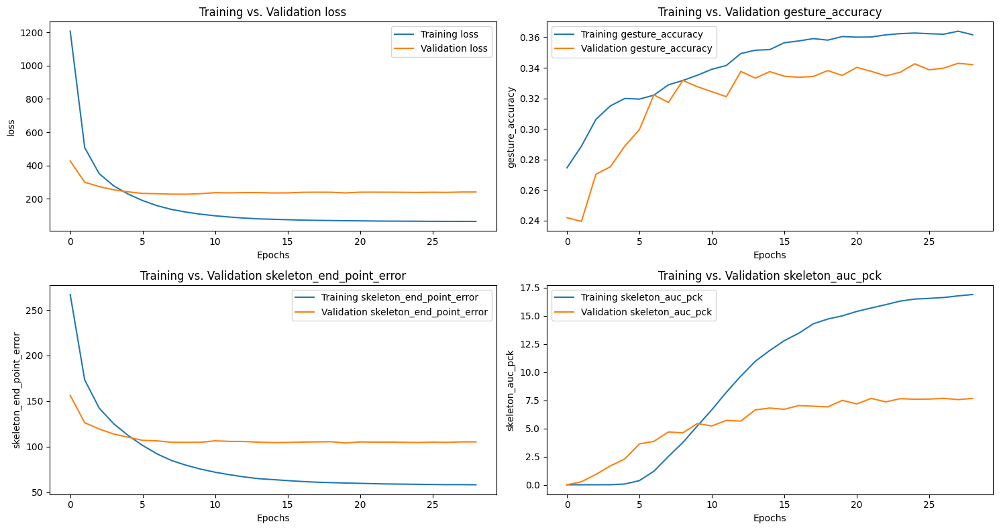

507/507 [==============================] - 1s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.3092300098716683
Gesture F1 Score:  0.23409079070374153
Mean Error:  0.25483862
AucPCK :  [0.         0.         0.03701876 0.18509379 0.4935834  1.8385983
 3.8993092 ]
End point error  143.55022
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3316874459943217
Gesture F1 Score:  0.24726524013957166
Mean Error:  0.18841572
AucPCK :  [1.2344155e-02 3.5180843e-01 1.2591038e+00 3.2465127e+00 5.7894087e+00
 8.6902847e+00 1.2911985e+01]
End point error  104.8025
**************************************************
Worst joints : 


{'wrist_x': 6122.2993,
 'wrist_z': 4616.5386,
 'Pinky_2_x': 2993.043,
 'Thumb_3_x': 2852.5532,
 'Pinky_1_x': 2804.5647,
 'Ring_2_x': 2724.3018,
 'Index_3_z': 2699.2505,
 'Middle_3_x': 2677.2883,
 'Ring_3_z': 2641.333,
 'Index_3_x': 2593.2883,
 'Pinky_3_x': 2590.3645,
 'Middle_2_x': 2559.9773,
 'Middle_3_z': 2528.9248,
 'Ring_3_x': 2514.6736,
 'Ring_1_x': 2438.1055,
 'Thumb_2_x': 2416.9084,
 'Index_2_x': 2415.8762,
 'Ring_2_z': 2148.4333,
 'Pinky_3_z': 2123.7407,
 'Middle_2_z': 2018.84,
 'Thumb_3_z': 1999.1696,
 'Middle_1_x': 1990.636,
 'Index_2_z': 1974.1415,
 'Pinky_2_z': 1855.0845,
 'Index_1_x': 1724.8285,
 'Thumb_1_x': 1597.9762,
 'Thumb_0_x': 1571.4679,
 'Thumb_2_z': 1404.0044,
 'Pinky_1_z': 1372.4016,
 'Ring_1_z': 1234.5797,
 'Index_1_z': 1154.8317,
 'Pinky_0_x': 1106.4319,
 'Middle_1_z': 1088.52,
 'Ring_0_x': 918.60675,
 'Thumb_0_z': 784.2711,
 'Thumb_1_z': 776.2622,
 'Index_0_x': 733.6718,
 'Middle_0_x': 575.639,
 'Pinky_0_z': 533.193,
 'Index_0_z': 468.54483,
 'Ring_0_z': 398.5

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
worst = {skeleton_2dcols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

63 norm with first joint


In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, True, norm='63')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
chili_data.head()

False
81007


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.6967525974637492, 1.902575548759282, 0.779...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[0.7008708231165359, 1.9186038164028003, 0.77...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[0.7041358024177217, 1.9250698963172628, 0.76...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[0.7091453078634906, 1.9148879104688983, 0.74...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[0.7068904260054928, 1.8859246002145045, 0.73...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.00001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 20, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'normalized/80_63w_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 25s 14ms/step - loss: 221.6634 - gesture_loss: 1.4103 - skeleton_loss: 221.3812 - gesture_accuracy: 0.2564 - skeleton_end_point_error: 106.2098 - skeleton_auc_pck: 0.9734 - val_loss: 278.8267 - val_gesture_loss: 1.3655 - val_skeleton_loss: 278.5537 - val_gesture_accuracy: 0.2903 - val_skeleton_end_point_error: 117.9722 - val_skeleton_auc_pck: 1.6290 - lr: 1.0000e-05
Epoch 2/200
1519/1519 [==============================] - 20s 13ms/step - loss: 176.5920 - gesture_loss: 1.4015 - skeleton_loss: 176.3117 - gesture_accuracy: 0.2806 - skeleton_end_point_error: 95.0021 - skeleton_auc_pck: 1.9662 - val_loss: 276.6352 - val_gesture_loss: 1.3343 - val_skeleton_loss: 276.3684 - val_gesture_accuracy: 0.3366 - val_skeleton_end_point_error: 116.9416 - val_skeleton_auc_pck: 2.1828 - lr: 1.0000e-05
Epoch 3/200
1519/1519 [==============================] - 20s 13ms/step - loss: 147.8459 - gesture_loss: 1.3840 - skeleton_loss: 147.5691 - gesture_ac

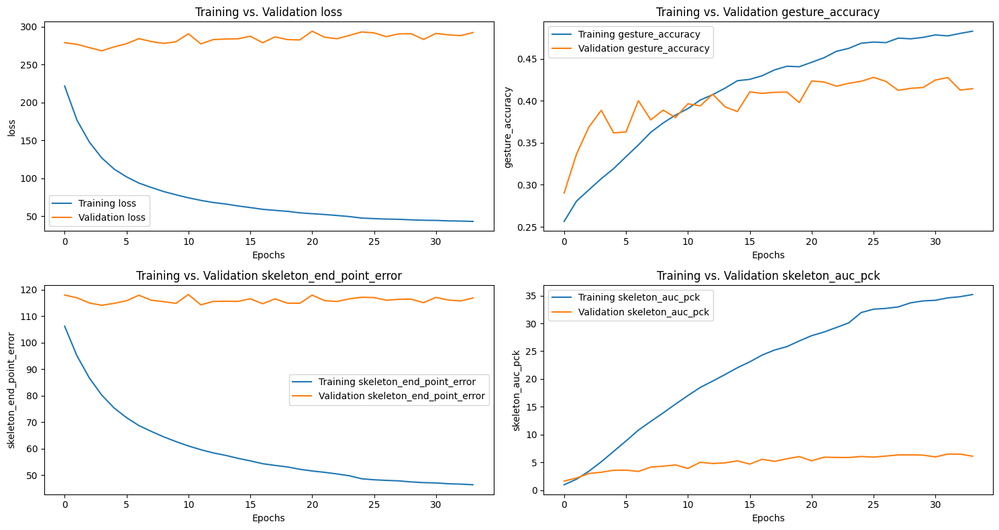

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.3325518262586377
Gesture F1 Score:  0.2940232242262827
Mean Error:  0.9003406075700956
AucPCK :  [0.         0.         0.19743338 0.54294175 0.99950635 1.9496546
 3.0602171 ]
End point error  160.71679895827683
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3887174422910752
Gesture F1 Score:  0.3430342426175905
Mean Error:  0.6709792811451027
AucPCK :  [0.0000000e+00 6.1720777e-03 3.4563634e-01 1.6788051e+00 3.6044934e+00
 6.7090483e+00 1.0245648e+01]
End point error  114.1196202023665
**************************************************
Worst joints : 


{'wrist_x': 6279.212901592506,
 'wrist_z': 4502.293953543224,
 'Pinky_2_x': 3012.91359709779,
 'Thumb_3_x': 2915.668844983418,
 'Pinky_1_x': 2827.574263122689,
 'Ring_2_x': 2740.0485144741724,
 'Index_3_z': 2715.159657900013,
 'Index_3_x': 2678.184240448541,
 'Middle_3_x': 2672.570264673485,
 'Ring_3_z': 2632.023528911282,
 'Pinky_3_x': 2624.850293125784,
 'Middle_2_x': 2608.348468903213,
 'Ring_3_x': 2596.2738385754337,
 'Middle_3_z': 2553.789941136589,
 'Index_2_x': 2483.5451060367473,
 'Ring_1_x': 2444.858836514315,
 'Thumb_2_x': 2425.959338669498,
 'Ring_2_z': 2254.9822856198507,
 'Pinky_3_z': 2243.7348603464325,
 'Middle_2_z': 2141.583766791576,
 'Pinky_3_y': 2097.4635306535833,
 'Ring_3_y': 2085.473392121295,
 'Thumb_3_z': 2055.510809524453,
 'Index_2_z': 2030.743723084011,
 'Middle_1_x': 1991.2797164200094,
 'Index_1_y': 1920.8388591852204,
 'Pinky_2_z': 1917.5516544521663,
 'Index_3_y': 1911.9735426206737,
 'Middle_3_y': 1899.9605196575085,
 'Index_2_y': 1884.185783532884,
 'Ri

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

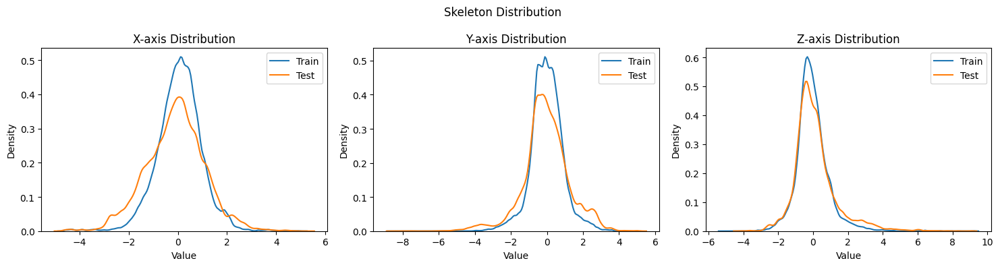

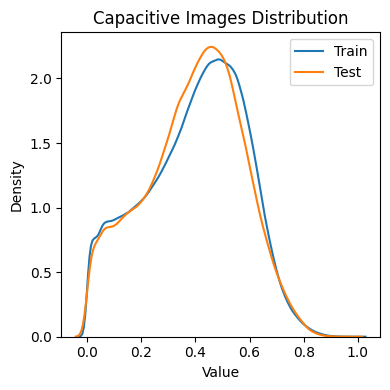

Percentage of zeroes in capactive train data 98.02703453722052
Percentage of zeroes in capacitive test data 98.60544292757834


In [ ]:
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,X_train,X_test)

63 norm without first joint

In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, False, norm='63')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
chili_data.head()

False
81007


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1023827896101446, -0.841...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.1126764675713752, -0.856...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.124263627434313, -0.8853...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.141545042265936, -0.9200...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0, 0.0], [-1.162579360520924, -0.9844...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.000001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 20, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'normalized/80_63wout_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 25s 13ms/step - loss: 212.7153 - gesture_loss: 1.3786 - skeleton_loss: 212.4397 - gesture_accuracy: 0.2741 - skeleton_end_point_error: 100.5240 - skeleton_auc_pck: 3.7311 - val_loss: 253.7791 - val_gesture_loss: 1.3983 - val_skeleton_loss: 253.4995 - val_gesture_accuracy: 0.1972 - val_skeleton_end_point_error: 110.6399 - val_skeleton_auc_pck: 2.8952 - lr: 1.0000e-06
Epoch 2/200
1519/1519 [==============================] - 19s 13ms/step - loss: 195.9993 - gesture_loss: 1.3859 - skeleton_loss: 195.7221 - gesture_accuracy: 0.2796 - skeleton_end_point_error: 97.3888 - skeleton_auc_pck: 3.4333 - val_loss: 246.4113 - val_gesture_loss: 1.4119 - val_skeleton_loss: 246.1289 - val_gesture_accuracy: 0.2182 - val_skeleton_end_point_error: 109.0965 - val_skeleton_auc_pck: 3.2050 - lr: 1.0000e-06
Epoch 3/200
1519/1519 [==============================] - 19s 13ms/step - loss: 186.3815 - gesture_loss: 1.3992 - skeleton_loss: 186.1018 - gesture_ac

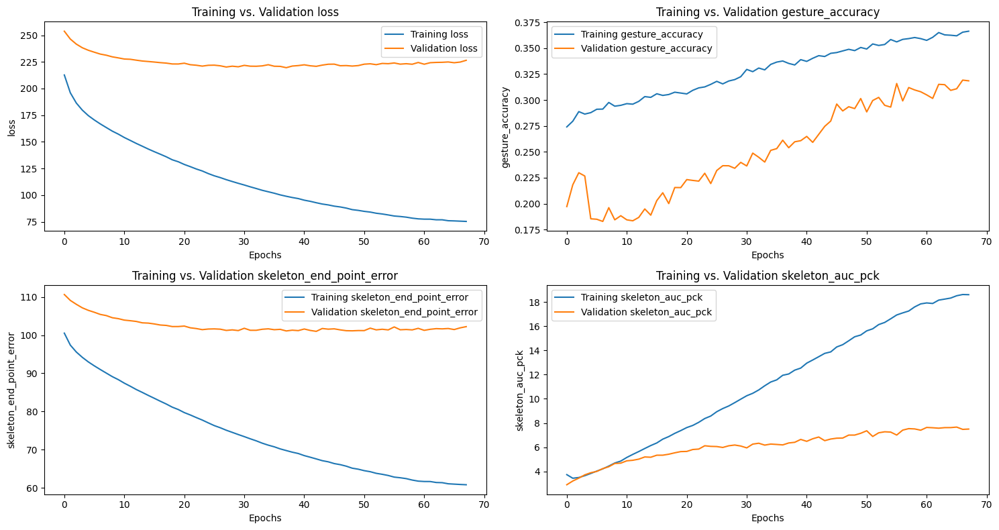

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.30651530108588354
Gesture F1 Score:  0.2877849846135513
Mean Error:  0.8558876378429
AucPCK :  [0.         0.30848965 0.45656464 1.5054294  3.097236   6.219151
 9.921027  ]
End point error  135.56525242660754
**************************************************
Validation Evaluation
Gesture Accuracy:  0.2539809900012344
Gesture F1 Score:  0.2279188950259026
Mean Error:  0.6456718583807493
AucPCK :  [ 0.03086039  0.75299346  1.9997531   4.1970124   7.4496975  12.251574
 17.763239  ]
End point error  101.0851148914537
**************************************************
Worst joints : 


{'Pinky_2_x': 3074.0057912974157,
 'Thumb_3_x': 2921.388516270235,
 'Pinky_1_x': 2863.0201888639704,
 'Ring_2_x': 2749.2942219004663,
 'Index_3_z': 2706.701914329696,
 'Middle_3_x': 2706.654249079498,
 'Index_3_x': 2669.287849869083,
 'Ring_3_z': 2657.7813056545715,
 'Pinky_3_x': 2592.6347055186425,
 'Middle_2_x': 2562.2034921950612,
 'Ring_3_x': 2561.504186826088,
 'Middle_3_z': 2536.927265458575,
 'Ring_1_x': 2488.316072137727,
 'Index_2_x': 2483.451406624984,
 'Thumb_2_x': 2379.931797552313,
 'Pinky_3_z': 2204.61858737458,
 'Ring_2_z': 2188.0916273508433,
 'Ring_3_y': 2093.749838560281,
 'Pinky_3_y': 2082.8466939853993,
 'Middle_2_z': 2059.5468221515707,
 'Thumb_3_z': 2022.7803978778784,
 'Index_2_z': 2018.5614415898165,
 'Middle_1_x': 2004.8911989562766,
 'Index_1_y': 1992.325433486629,
 'Middle_3_y': 1948.367371271617,
 'Pinky_2_z': 1909.595297548423,
 'Index_2_y': 1866.9337741993895,
 'Index_3_y': 1859.7008367141693,
 'Pinky_2_y': 1840.9076047885187,
 'Ring_2_y': 1828.28906709528

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

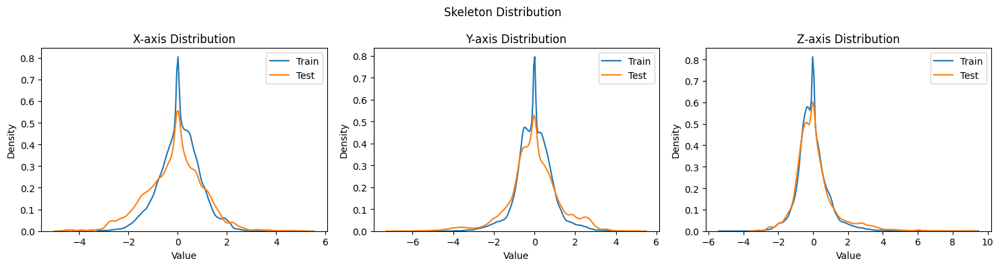

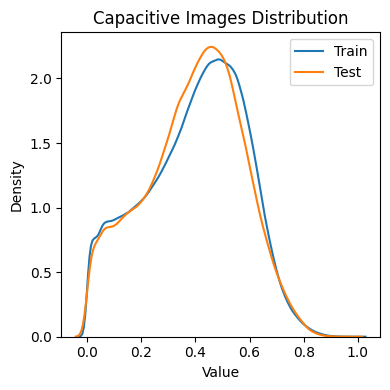

Percentage of zeroes in capactive train data 98.02703453722052
Percentage of zeroes in capacitive test data 98.60544292757834


In [ ]:
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,X_train,X_test)

3 norm keep wrist

In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, True, norm='3')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
chili_data.head()

False
81007


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-23.434024451055656, 95.3081006541642, 23.16...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[-23.41320337081247, 95.3627503354978, 23.130...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[-23.396696165585308, 95.38479696053939, 23.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[-23.371368919421798, 95.35008065218143, 23.0...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[-23.382769235981065, 95.25132789168528, 22.9...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 20, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'normalized/80_3w_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 26s 14ms/step - loss: 938.1465 - gesture_loss: 1.7079 - skeleton_loss: 937.8047 - gesture_accuracy: 0.2826 - skeleton_end_point_error: 218.5300 - skeleton_auc_pck: 0.0029 - val_loss: 391.9857 - val_gesture_loss: 1.4870 - val_skeleton_loss: 391.6883 - val_gesture_accuracy: 0.3048 - val_skeleton_end_point_error: 146.0982 - val_skeleton_auc_pck: 0.0396 - lr: 1.0000e-04
Epoch 2/200
1519/1519 [==============================] - 20s 13ms/step - loss: 292.6864 - gesture_loss: 1.5153 - skeleton_loss: 292.3835 - gesture_accuracy: 0.3206 - skeleton_end_point_error: 126.0487 - skeleton_auc_pck: 0.1073 - val_loss: 307.7354 - val_gesture_loss: 1.4225 - val_skeleton_loss: 307.4511 - val_gesture_accuracy: 0.3181 - val_skeleton_end_point_error: 125.1117 - val_skeleton_auc_pck: 0.6560 - lr: 1.0000e-04
Epoch 3/200
1519/1519 [==============================] - 20s 13ms/step - loss: 200.1220 - gesture_loss: 1.4227 - skeleton_loss: 199.8375 - gesture_a

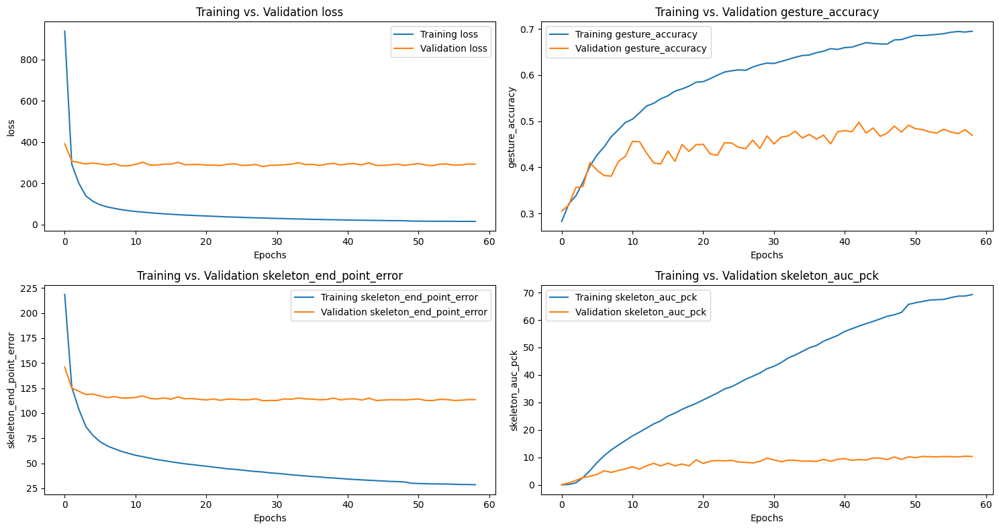

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.24679170779861798
Gesture F1 Score:  0.23211636561145454
Mean Error:  2.318282739512488
AucPCK :  [0.07403751 0.23445213 0.46890426 1.0488648  2.1470878  3.4674234
 5.2443237 ]
End point error  161.3671388210133
**************************************************
Validation Evaluation
Gesture Accuracy:  0.44080977657079373
Gesture F1 Score:  0.4388869238286965
Mean Error:  1.636892293791527
AucPCK :  [ 0.82705843  2.5305517   4.4130354   7.381805   10.585113   14.504382
 19.176645  ]
End point error  112.47276300271893
**************************************************


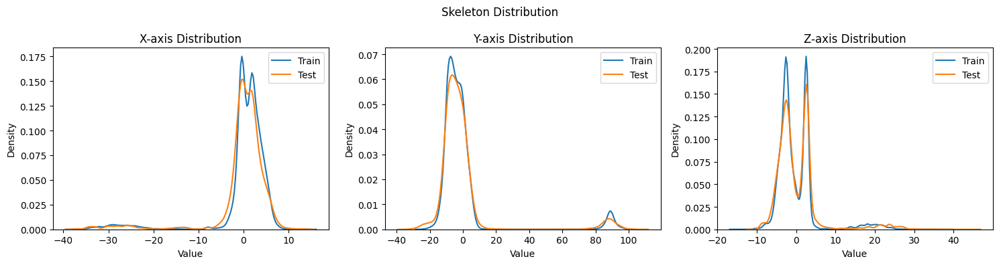

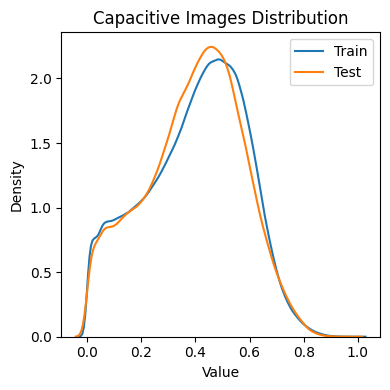

Percentage of zeroes in capactive train data 98.02703453722052
Percentage of zeroes in capacitive test data 98.60544292757834
Worst joints : 


{'wrist_x': 6175.679939042278,
 'wrist_z': 4635.443867629191,
 'Pinky_2_x': 3111.360891153303,
 'Thumb_3_x': 2993.559988477055,
 'Pinky_1_x': 2922.9341836107787,
 'Ring_2_x': 2871.187805613582,
 'Middle_3_x': 2806.4667990387793,
 'Index_3_z': 2767.687557132815,
 'Index_3_x': 2729.5579383808895,
 'Middle_2_x': 2710.1735142434927,
 'Pinky_3_x': 2698.284975137748,
 'Ring_3_x': 2696.8684128465497,
 'Ring_3_z': 2665.5114938063207,
 'Middle_3_z': 2627.2286352471024,
 'Index_2_x': 2559.969229611899,
 'Ring_1_x': 2537.9002998856195,
 'Thumb_2_x': 2482.4894915432387,
 'Pinky_3_z': 2219.543566473676,
 'Ring_3_y': 2215.2944168628565,
 'Ring_2_z': 2203.3368215651108,
 'Pinky_3_y': 2164.9445686119525,
 'Middle_1_x': 2084.846958703667,
 'Middle_2_z': 2080.6605344286577,
 'Middle_3_y': 2024.163057190047,
 'Index_2_z': 2023.1073394889013,
 'Thumb_3_z': 2004.571681031129,
 'Ring_2_y': 1967.0066041297746,
 'Index_1_y': 1941.3339041262773,
 'Index_3_y': 1933.4790212021264,
 'Pinky_2_y': 1918.937822283607

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,X_train,X_test)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

3 norm without wrist

In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, False, norm='3')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
chili_data.head()

False
81007


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.0, 0.0, 0.0], [-3.677941778313757, -6.3425...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[0.0, 0.0, 0.0], [-3.713162509770819, -6.3884...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[0.0, 0.0, 0.0], [-3.752809004193866, -6.4726...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[0.0, 0.0, 0.0], [-3.8119388966652554, -6.574...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[0.0, 0.0, 0.0], [-3.8839096808136984, -6.763...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 20, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'normalized/80_3wout_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 25s 14ms/step - loss: 175.3862 - gesture_loss: 1.6486 - skeleton_loss: 175.0565 - gesture_accuracy: 0.3114 - skeleton_end_point_error: 93.5830 - skeleton_auc_pck: 4.3531 - val_loss: 231.6148 - val_gesture_loss: 1.3911 - val_skeleton_loss: 231.3366 - val_gesture_accuracy: 0.3527 - val_skeleton_end_point_error: 103.3043 - val_skeleton_auc_pck: 6.6802 - lr: 1.0000e-04
Epoch 2/200
1519/1519 [==============================] - 20s 13ms/step - loss: 74.6180 - gesture_loss: 1.3024 - skeleton_loss: 74.3575 - gesture_accuracy: 0.4087 - skeleton_end_point_error: 60.8690 - skeleton_auc_pck: 18.0057 - val_loss: 233.4068 - val_gesture_loss: 1.3872 - val_skeleton_loss: 233.1293 - val_gesture_accuracy: 0.3753 - val_skeleton_end_point_error: 101.6721 - val_skeleton_auc_pck: 9.5650 - lr: 1.0000e-04
Epoch 3/200
1519/1519 [==============================] - 20s 13ms/step - loss: 52.5229 - gesture_loss: 1.1754 - skeleton_loss: 52.2878 - gesture_accura

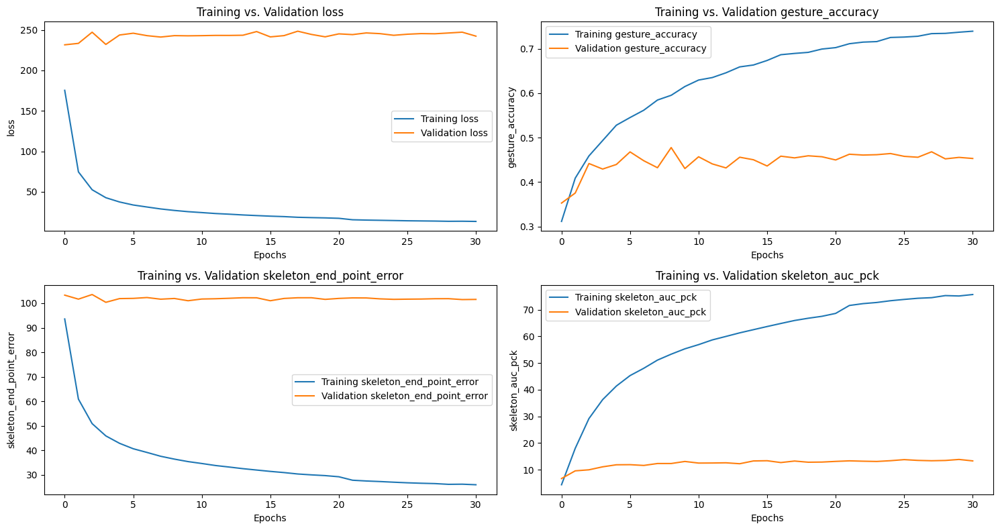

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.23790720631786771
Gesture F1 Score:  0.2187394944024247
Mean Error:  3.5732973929737084
AucPCK :  [0.23445213 1.3943732  2.3075025  3.0478776  4.775419   6.6510363
 9.254689  ]
End point error  136.07495223113352
**************************************************
Validation Evaluation
Gesture Accuracy:  0.35267250956672014
Gesture F1 Score:  0.3229004487359658
Mean Error:  2.6872104934808974
AucPCK :  [ 0.06789285  0.56783116  2.0429575   4.4809284   8.480434   13.029255
 18.115047  ]
End point error  103.29041914059817
**************************************************


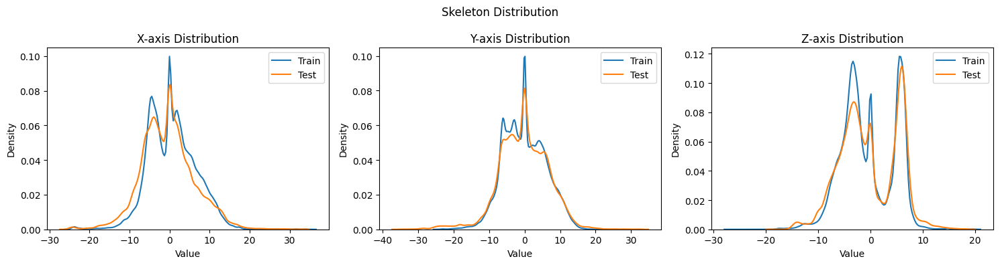

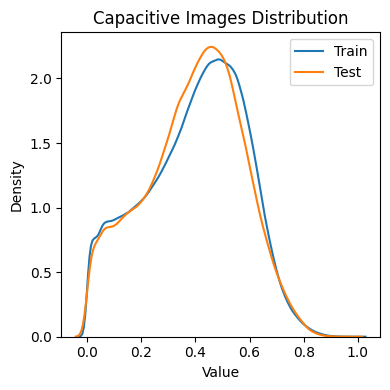

Percentage of zeroes in capactive train data 98.02703453722052
Percentage of zeroes in capacitive test data 98.60544292757834
Worst joints : 


{'Thumb_3_x': 3046.755831628947,
 'Pinky_2_x': 2976.3907906828995,
 'Middle_3_x': 2803.8027276844236,
 'Pinky_1_x': 2797.2231184347734,
 'Index_3_x': 2773.028680064004,
 'Ring_2_x': 2769.441003717495,
 'Index_3_z': 2648.6073694839433,
 'Ring_3_z': 2641.2028162569163,
 'Middle_2_x': 2612.0993068829453,
 'Pinky_3_x': 2566.1598880012257,
 'Ring_3_x': 2565.755135260781,
 'Thumb_2_x': 2560.229610675994,
 'Index_2_x': 2520.275734034216,
 'Middle_3_z': 2517.9504379365194,
 'Ring_1_x': 2434.585835807142,
 'Pinky_3_z': 2180.511524692866,
 'Pinky_3_y': 2146.238042067592,
 'Ring_2_z': 2133.8919009019737,
 'Ring_3_y': 2092.0298216391525,
 'Middle_2_z': 2045.834123421283,
 'Middle_1_x': 1994.718715246513,
 'Index_2_z': 1990.6934132637712,
 'Thumb_3_z': 1987.5462344908967,
 'Index_1_y': 1958.7742868528546,
 'Pinky_2_z': 1937.202024921101,
 'Middle_3_y': 1922.4137848805367,
 'Ring_2_y': 1874.7352474309043,
 'Pinky_2_y': 1868.762638068789,
 'Index_3_y': 1854.3464282352886,
 'Index_2_y': 1847.891361082

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,X_train,X_test)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

all_norm without wrist

In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, False, norm='all')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
chili_data.head()

False
81007


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[0.3258354, 0.3258354, 0.3258354], [0.3796917...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[0.3258354, 0.3258354, 0.3258354], [0.3758375...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[0.3258354, 0.3258354, 0.3258354], [0.3714989...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[0.3258354, 0.3258354, 0.3258354], [0.3650283...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[0.3258354, 0.3258354, 0.3258354], [0.3571524...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 20, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'normalized/80_1wout_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 25s 14ms/step - loss: 244.1323 - gesture_loss: 1.3731 - skeleton_loss: 243.8582 - gesture_accuracy: 0.3122 - skeleton_end_point_error: 108.8329 - skeleton_auc_pck: 2.9101 - val_loss: 232.9076 - val_gesture_loss: 1.3602 - val_skeleton_loss: 232.6357 - val_gesture_accuracy: 0.3156 - val_skeleton_end_point_error: 103.4470 - val_skeleton_auc_pck: 5.3084 - lr: 1.0000e-04
Epoch 2/200
1519/1519 [==============================] - 20s 13ms/step - loss: 75.4775 - gesture_loss: 1.3117 - skeleton_loss: 75.2152 - gesture_accuracy: 0.3496 - skeleton_end_point_error: 62.2051 - skeleton_auc_pck: 14.7143 - val_loss: 235.8226 - val_gesture_loss: 1.3310 - val_skeleton_loss: 235.5565 - val_gesture_accuracy: 0.3413 - val_skeleton_end_point_error: 104.6244 - val_skeleton_auc_pck: 8.0119 - lr: 1.0000e-04
Epoch 3/200
1519/1519 [==============================] - 20s 13ms/step - loss: 55.7104 - gesture_loss: 1.2774 - skeleton_loss: 55.4548 - gesture_accur

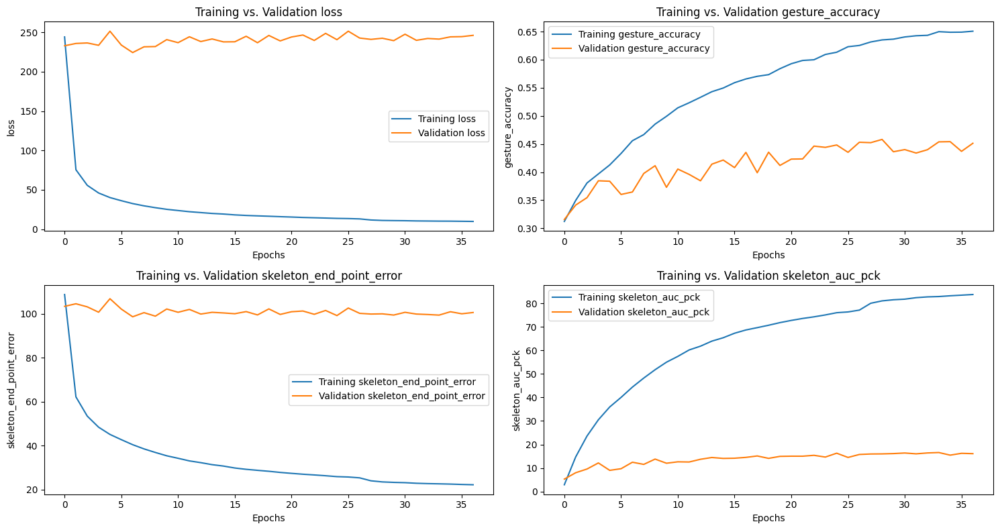

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.3325518262586377
Gesture F1 Score:  0.3015192067302506
Mean Error:  0.35788286
AucPCK :  [ 0.45656464  1.2462981   2.9615006   5.454097    7.959033   10.550345
 13.758637  ]
End point error  136.31796
**************************************************
Validation Evaluation
Gesture Accuracy:  0.3645846191828169
Gesture F1 Score:  0.3505126118579689
Mean Error:  0.25565547
AucPCK :  [ 1.3887174  3.50574    6.8756948 10.9492655 16.059746  21.676336
 26.897913 ]
End point error  98.68186
**************************************************


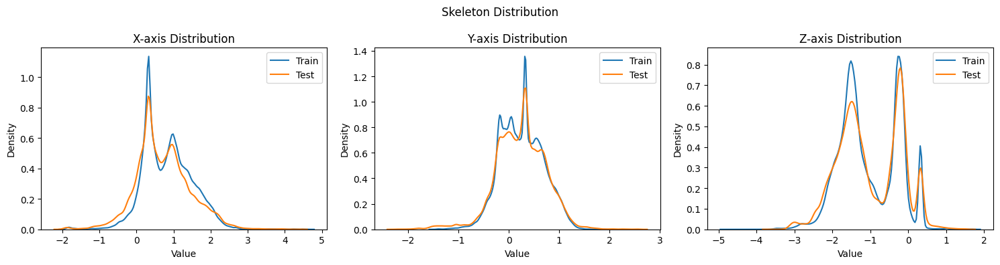

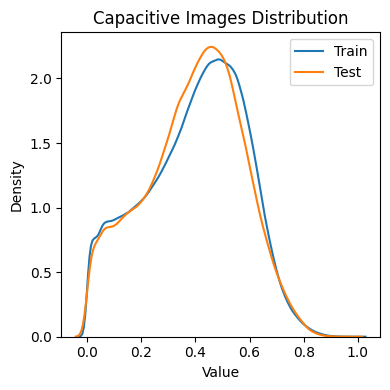

Percentage of zeroes in capactive train data 98.02703453722052
Percentage of zeroes in capacitive test data 98.60544292757834
Worst joints : 


{'Pinky_2_x': 3189.9072,
 'Pinky_1_x': 3022.5796,
 'Ring_2_x': 2857.7505,
 'Thumb_3_x': 2854.6025,
 'Index_3_z': 2825.159,
 'Ring_3_z': 2739.5225,
 'Pinky_3_x': 2701.2788,
 'Middle_3_x': 2688.1946,
 'Middle_3_z': 2668.2268,
 'Ring_3_x': 2614.5312,
 'Ring_1_x': 2604.1487,
 'Index_3_x': 2598.782,
 'Middle_2_x': 2596.6365,
 'Index_2_x': 2453.937,
 'Thumb_2_x': 2412.1343,
 'Ring_2_z': 2256.08,
 'Pinky_3_z': 2242.0012,
 'Ring_3_y': 2223.285,
 'Pinky_3_y': 2222.0854,
 'Middle_1_x': 2124.7954,
 'Middle_2_z': 2119.4885,
 'Index_2_z': 2074.8972,
 'Thumb_3_z': 2065.476,
 'Middle_3_y': 2040.7253,
 'Ring_2_y': 1966.5707,
 'Pinky_2_y': 1951.1091,
 'Index_1_y': 1929.7799,
 'Pinky_2_z': 1925.1438,
 'Index_3_y': 1919.0566,
 'Index_2_y': 1893.1694,
 'Index_1_x': 1803.762,
 'Middle_2_y': 1788.0847,
 'Thumb_3_y': 1607.2441,
 'Thumb_1_x': 1599.5441,
 'Thumb_0_x': 1598.2178,
 'Middle_1_y': 1445.0972,
 'Thumb_2_z': 1437.4678,
 'Pinky_1_z': 1347.8168,
 'Index_0_y': 1295.8293,
 'Ring_1_z': 1250.7571,
 'Pinky_

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,X_train,X_test)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

all_norm with wrist

In [ ]:
files = glob.glob(data_path_chili+'*.pkl')
chili_data = pd.concat([pd.read_pickle(fp) for fp in files], ignore_index=True)
chili_data=chili_data.loc[~chili_data.cap_img.apply(lambda x :not x.any())].reset_index(drop=True)
chili_data['skeleton']= chili_data['skeleton'].apply(lambda x : x.astype(np.float32))
max_cap = np.max(chili_data['cap_img'].apply(lambda x : np.max(x)))
chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : x/max_cap)
#meancap = np.mean(np.concatenate(chili_data['skeleton'].values))
#stdcap = np.std(nsp.concatenate(chili_data['skeleton'].values))
#chili_data['cap_img']= chili_data['cap_img'].apply(lambda x : (x-meancap)/stdcap)
## Normalize
chili_data, mean, std = joint_norm(chili_data, True, norm='all')
print(chili_data.Timestamp.is_unique)
chili_data = chili_data.sort_values(by=['Timestamp']).reset_index(drop=True)
print(len(chili_data))
chili_data.head()

False
81007


,Timestamp,skeleton,cap_img,trial,gesture,subject,day
0,1.679995e+12,"[[-3.5045605, 4.8862944, 2.6818254], [0.175008...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
1,1.679995e+12,"[[-3.5012696, 4.888914, 2.6768975], [0.1728603...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
2,1.679995e+12,"[[-3.4986608, 4.889971, 2.6707556], [0.1704418...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
3,1.679995e+12,"[[-3.494658, 4.8883066, 2.6632676], [0.1668347...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803
4,1.679995e+12,"[[-3.4964597, 4.883573, 2.6549182], [0.1624443...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...",1,DQ,1,2803


In [ ]:
model = create_skeleton_gesture_model(41, 72, 1)

train = chili_data.groupby(['subject','trial']).apply(lambda x: x.head(round(0.8*len(x)))).reset_index(drop=True)
valid = train.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.25*len(x)))).reset_index(drop=True)
train = train.groupby(['subject','trial']).apply(lambda x: x.head(round(0.75*len(x)))).reset_index(drop=True)
train,valid = shuffle(train,random_state=42),shuffle(valid,random_state=42)
test = shuffle(chili_data.groupby(['subject','trial']).apply(lambda x: x.tail(round(0.1*len(x)))).reset_index(drop=True),random_state=42)
train.gesture = pd.Categorical(train.gesture, categories=chili_data.gesture.unique())
valid.gesture = pd.Categorical(valid.gesture, categories=chili_data.gesture.unique())
test.gesture = pd.Categorical(test.gesture, categories=chili_data.gesture.unique())
X_train, y_train_skeleton, y_train_gesture = data_multiload(train)
X_valid, y_valid_skeleton, y_valid_gesture = data_multiload(valid)
X_test, y_test_skeleton, y_test_gesture = data_multiload(test)

optimizer = Adam(learning_rate=0.0001)
early_stop = EarlyStopping(monitor='val_skeleton_loss', patience=30, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_skeleton_loss', factor= 0.5, patience = 20, min_lr=1e-7)
beta = 0.2
model.compile(optimizer=optimizer, loss={'skeleton': un_skeloss(mean,std), 'gesture': 'categorical_crossentropy'},
                  loss_weights={'skeleton': 1.0, 'gesture': beta},
                  metrics={'skeleton': [un_epe(mean,std), un_pck(mean,std)], 'gesture': 'accuracy'})


history = model.fit(X_train, {'skeleton': y_train_skeleton, 'gesture': y_train_gesture},
                    validation_data=(X_valid, {'skeleton': y_valid_skeleton, 'gesture': y_valid_gesture}),
                    epochs=200, batch_size=32, callbacks=[reduce_lr, early_stop])

model.save(chili_models+'normalized/80_1w_Norm7ms_beta0.2.h5')

Epoch 1/200
1519/1519 [==============================] - 26s 14ms/step - loss: 628.4477 - gesture_loss: 1.3876 - skeleton_loss: 628.1704 - gesture_accuracy: 0.3009 - skeleton_end_point_error: 173.7252 - skeleton_auc_pck: 0.0535 - val_loss: 284.2772 - val_gesture_loss: 1.3566 - val_skeleton_loss: 284.0058 - val_gesture_accuracy: 0.3503 - val_skeleton_end_point_error: 118.2915 - val_skeleton_auc_pck: 1.6968 - lr: 1.0000e-04
Epoch 2/200
1519/1519 [==============================] - 20s 13ms/step - loss: 153.9778 - gesture_loss: 1.3355 - skeleton_loss: 153.7109 - gesture_accuracy: 0.3461 - skeleton_end_point_error: 91.0856 - skeleton_auc_pck: 1.3928 - val_loss: 277.1660 - val_gesture_loss: 1.3330 - val_skeleton_loss: 276.8995 - val_gesture_accuracy: 0.3614 - val_skeleton_end_point_error: 115.4824 - val_skeleton_auc_pck: 3.1928 - lr: 1.0000e-04
Epoch 3/200
1519/1519 [==============================] - 20s 13ms/step - loss: 106.3182 - gesture_loss: 1.3122 - skeleton_loss: 106.0557 - gesture_ac

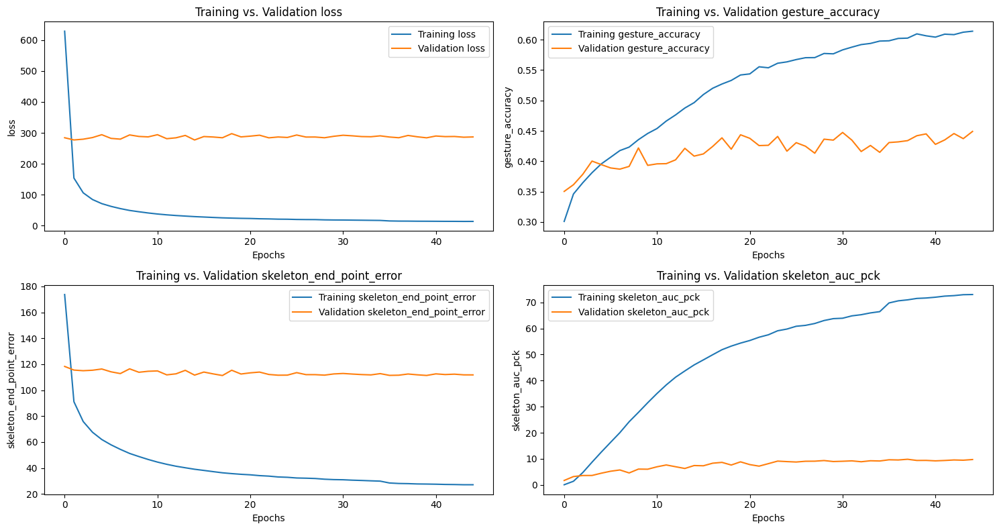

507/507 [==============================] - 2s 3ms/step
Testing Evaluation
Gesture Accuracy:  0.2998519249753208
Gesture F1 Score:  0.28786596473342735
Mean Error:  0.22558993
AucPCK :  [0.         0.04935835 0.37018758 0.9378085  1.9990127  3.8746297
 5.330701  ]
End point error  161.93475
**************************************************
Validation Evaluation
Gesture Accuracy:  0.40840636958400195
Gesture F1 Score:  0.3965239845052231
Mean Error:  0.15757845
AucPCK :  [ 0.61103565  1.7652141   3.6044934   6.585607    9.480311   12.89347
 16.985558  ]
End point error  111.59928
**************************************************


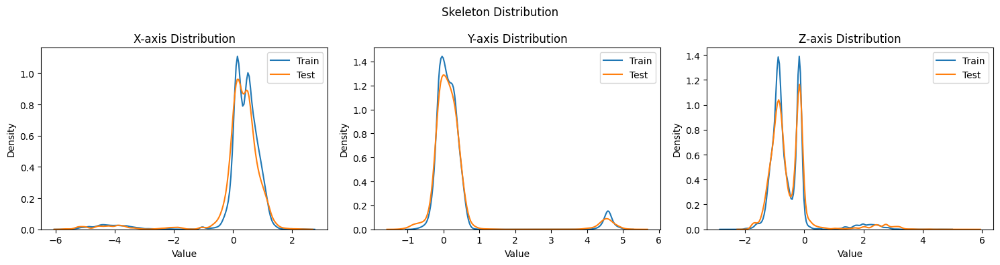

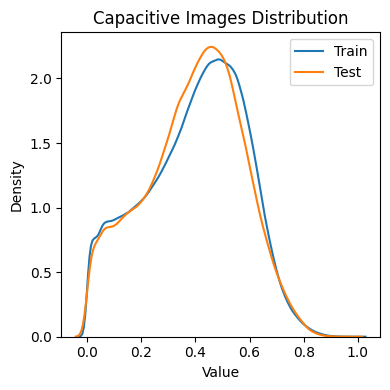

Percentage of zeroes in capactive train data 98.02703453722052
Percentage of zeroes in capacitive test data 98.60544292757834
Worst joints : 


{'wrist_x': 6268.7217,
 'wrist_z': 4510.4624,
 'Pinky_2_x': 3060.5647,
 'Thumb_3_x': 3004.6558,
 'Pinky_1_x': 2901.9211,
 'Ring_2_x': 2860.275,
 'Index_3_z': 2804.365,
 'Middle_3_x': 2802.4287,
 'Index_3_x': 2754.6304,
 'Middle_2_x': 2735.9585,
 'Ring_3_z': 2665.9436,
 'Ring_3_x': 2662.3318,
 'Middle_3_z': 2657.3948,
 'Pinky_3_x': 2630.0579,
 'Index_2_x': 2609.1353,
 'Ring_1_x': 2538.0566,
 'Thumb_2_x': 2491.4338,
 'Ring_2_z': 2253.4023,
 'Pinky_3_z': 2220.336,
 'Ring_3_y': 2204.4329,
 'Pinky_3_y': 2176.7983,
 'Middle_2_z': 2129.9954,
 'Middle_1_x': 2094.2869,
 'Thumb_3_z': 2078.8816,
 'Index_2_z': 2051.3083,
 'Middle_3_y': 1991.8234,
 'Ring_2_y': 1968.4164,
 'Index_1_y': 1946.6324,
 'Pinky_2_z': 1942.162,
 'Pinky_2_y': 1932.9395,
 'Index_3_y': 1926.3994,
 'Index_2_y': 1902.5114,
 'Index_1_x': 1853.5277,
 'Middle_2_y': 1752.0244,
 'Thumb_1_x': 1640.991,
 'Thumb_0_x': 1637.5393,
 'Thumb_3_y': 1573.4073,
 'wrist_y': 1495.972,
 'Thumb_2_z': 1452.7656,
 'Middle_1_y': 1434.4373,
 'Pinky_1_z

In [ ]:
plot_training(history)
epe_max=evaluate(model,X_test,X_valid,y_test_gesture,y_test_skeleton,y_valid_gesture,y_valid_skeleton)
plot_skel_cap_distribs(y_train_skeleton,y_test_skeleton,X_train,X_test)
worst = {skeleton_cols[x[0]] : x[1] for x in zip(epe_max.indices.numpy(),epe_max.values.numpy())}
print('Worst joints : ')
worst

# Create partial model from touchpose

In [ ]:
model_eth = get_eth_model('TouchPose_crossGestures',65,model_path)
model = create_skeleton_gesture_model(41, 72, 1)

In [ ]:
print(model_eth.input)
print(model_eth.output)

KerasTensor(type_spec=TensorSpec(shape=(None, 41, 72, 1), dtype=tf.float32, name='input_25'), name='input_25', description="created by layer 'input_25'")
KerasTensor(type_spec=TensorSpec(shape=(None, 41, 72, 1), dtype=tf.float32, name=None), name='regression_depth/BiasAdd:0', description="created by layer 'regression_depth'")


In [ ]:
print(model.input)
print(model.output)

KerasTensor(type_spec=TensorSpec(shape=(None, 41, 72, 1), dtype=tf.float32, name='input_2'), name='input_2', description="created by layer 'input_2'")
KerasTensor(type_spec=TensorSpec(shape=(None, 63), dtype=tf.float32, name=None), name='regression/BiasAdd:0', description="created by layer 'regression'")


In [ ]:
print(len(model.layers))

19


In [ ]:
print(len(model_eth.layers))

26


In [ ]:
match = []
for depth_layer, skel_layer, pos in zip(model_eth.layers,model.layers,range(len(model.layers))):
    match.append((depth_layer.name , skel_layer.name, pos ))
match

[('input_25', 'input_1', 0),
 ('conv2d_336', 'conv2d', 1),
 ('conv2d_337', 'conv2d_1', 2),
 ('max_pooling2d_72', 'max_pooling2d', 3),
 ('conv2d_338', 'conv2d_2', 4),
 ('conv2d_339', 'conv2d_3', 5),
 ('max_pooling2d_73', 'max_pooling2d_1', 6),
 ('conv2d_340', 'conv2d_4', 7),
 ('conv2d_341', 'conv2d_5', 8),
 ('max_pooling2d_74', 'max_pooling2d_2', 9),
 ('conv2d_342', 'conv2d_6', 10),
 ('conv2d_343', 'flatten', 11),
 ('up_sampling2d_72', 'dense', 12),
 ('concatenate_72', 'activation', 13),
 ('conv2d_344', 'batch_normalization', 14),
 ('conv2d_345', 'dropout', 15),
 ('up_sampling2d_73', 'dense_1', 16),
 ('concatenate_73', 'gesture', 17),
 ('conv2d_346', 'skeleton', 18)]

In [ ]:
match = [ (''.join([ xi for xi in x[0] if not (xi.isdigit() or xi== '_')]),''.join([ xi for xi in x[1] if not (xi.isdigit() or xi== '_')]),x[2]) for x in match]
match

[('input', 'input', 0),
 ('convd', 'convd', 1),
 ('convd', 'convd', 2),
 ('maxpoolingd', 'maxpoolingd', 3),
 ('convd', 'convd', 4),
 ('convd', 'convd', 5),
 ('maxpoolingd', 'maxpoolingd', 6),
 ('convd', 'convd', 7),
 ('convd', 'convd', 8),
 ('maxpoolingd', 'maxpoolingd', 9),
 ('convd', 'convd', 10),
 ('convd', 'flatten', 11),
 ('upsamplingd', 'dense', 12),
 ('concatenate', 'activation', 13),
 ('convd', 'batchnormalization', 14),
 ('convd', 'dropout', 15),
 ('upsamplingd', 'dense', 16),
 ('concatenate', 'gesture', 17),
 ('convd', 'skeleton', 18)]

In [ ]:
good_match = [x for x in match if x[0]==x[1]]
good_match

[('input', 'input', 0),
 ('convd', 'convd', 1),
 ('convd', 'convd', 2),
 ('maxpoolingd', 'maxpoolingd', 3),
 ('convd', 'convd', 4),
 ('convd', 'convd', 5),
 ('maxpoolingd', 'maxpoolingd', 6),
 ('convd', 'convd', 7),
 ('convd', 'convd', 8),
 ('maxpoolingd', 'maxpoolingd', 9),
 ('convd', 'convd', 10)]

In [ ]:
for i in range(len(good_match)):
    pos = match[i][2]
    model.layers[pos].set_weights(model_eth.layers[pos].get_weights())

In [ ]:
model.save(chili_models+'partialModels/multi_model_partial.h5')